# Compare AI vs Human Research Proposals — Style-Controlled (Rephrased)

This notebook mirrors `compare_proposals_baseline.ipynb` but uses proposals rephrased by `gemini-2.0-flash` into a standardized neutral academic style, removing stylistic fingerprints before analysis.

**Data sources:**
- `data/ai-proposals/rephrased/ai_proposals_rephrased_*.csv`
- `data/human-proposals/rephrased/human_proposals_rephrased_y*.json`

All analyses (diversity, novelty, thematic, style baseline) are identical to the baseline notebook.

# Setup and Imports

In [84]:
import sys
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NLP and embeddings
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from scipy.spatial.distance import cdist
from tqdm import tqdm

# Statistics
from scipy import stats
from scipy.stats import mannwhitneyu
import itertools

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")
print(f"✓ Working directory: {os.getcwd()}")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

# Visualization: 2D Embedding Space with UMAP
# Install umap-learn if not already installed
try:
    import umap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'umap-learn'])
    import umap

# Ensure output directory exists
RESULTS_DIR = Path('../results')
FIGURES_DIR = RESULTS_DIR / 'figures' / 'rephrased' / 'minimal'
TABLES_DIR = RESULTS_DIR / 'tables' / 'rephrased' / 'minimal'
REPHRASED_EMBEDDINGS_FILE = Path('../data/embeddings/rephrased/proposal_embeddings_human_ai_rephrased_minimal.pkl')
ABSTRACT_EMBEDDINGS_FILE = Path('../data/embeddings/rephrased/proposal_embeddings_section1_only_minimal.pkl')
LITERATURE_EMBEDDINGS_FILE = Path('../data/embeddings/literature/relevant_literature_embeddings.pkl')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPHRASED_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)
ABSTRACT_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)
LITERATURE_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)


✓ Imports successful
✓ Working directory: /Users/eveyhuang/Documents/NICO/human-AI-proposal/style-controlled comparison
✓ PyTorch version: 2.9.1
✓ CUDA available: False


## Helper Functions

In [85]:
# Define DISTINCT colors for each group
colors = {
    'Human': '#DC143C',  # Crimson red (PROMINENT)
    'claude-opus-4-5': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#FF8C00',  # Dark orange
}

In [86]:
def retrieve_embeddings(path_to_embeddings):
    with open(path_to_embeddings, 'rb') as f:
        embeddings_data = pickle.load(f)
    return embeddings_data

In [87]:
def cliffs_delta(group1, group2):
    """
    Calculate Cliff's Delta effect size.

    Interpretation:
    - |δ| < 0.147: negligible
    - |δ| < 0.33: small
    - |δ| < 0.474: medium
    - |δ| ≥ 0.474: large
    """
    x = np.asarray(group1)
    y = np.asarray(group2)
    n1, n2 = len(x), len(y)

    dominance = 0
    for xi in x:
        dominance += np.sum(xi > y)
        dominance -= np.sum(xi < y)

    return dominance / (n1 * n2)


def interpret_cliffs_delta(delta):
    """Interpret Cliff's Delta magnitude."""
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return "negligible"
    if abs_delta < 0.33:
        return "small"
    if abs_delta < 0.474:
        return "medium"
    return "large"


def permutation_test(group1, group2, n_permutations=10000, random_state=42):
    """
    Permutation test for difference in means (group1 - group2).
    Returns p-value, observed difference, and null distribution.
    """
    rng = np.random.default_rng(random_state)

    group1 = np.asarray(group1)
    group2 = np.asarray(group2)
    obs_diff = np.mean(group1) - np.mean(group2)

    combined = np.concatenate([group1, group2])
    n1 = len(group1)

    perm_diffs = np.empty(n_permutations, dtype=float)
    for i in range(n_permutations):
        perm = rng.permutation(combined)
        perm_diffs[i] = np.mean(perm[:n1]) - np.mean(perm[n1:])

    p_value = (np.sum(np.abs(perm_diffs) >= abs(obs_diff)) + 1) / (n_permutations + 1)
    return p_value, obs_diff, perm_diffs


def bootstrap_mean_diff_ci(group1, group2, n_boot=5000, random_state=42, alpha=0.05):
    """Bootstrap CI for mean(group1) - mean(group2)."""
    rng = np.random.default_rng(random_state)
    g1 = np.asarray(group1)
    g2 = np.asarray(group2)

    boots = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        b1 = rng.choice(g1, size=len(g1), replace=True)
        b2 = rng.choice(g2, size=len(g2), replace=True)
        boots[i] = np.mean(b1) - np.mean(b2)

    lo = np.quantile(boots, alpha / 2)
    hi = np.quantile(boots, 1 - alpha / 2)
    return lo, hi, boots


def run_group_comparison(group1, group2, n_permutations=10000, n_boot=5000, random_state=42):
    """Unified comparison with MW, Cliff's delta, permutation p, and bootstrap CI."""
    u_stat, p_value_mw = mannwhitneyu(group1, group2, alternative='two-sided')
    delta = cliffs_delta(group1, group2)
    delta_interp = interpret_cliffs_delta(delta)
    p_value_perm, obs_diff, _ = permutation_test(
        group1, group2, n_permutations=n_permutations, random_state=random_state
    )
    ci_low, ci_high, _ = bootstrap_mean_diff_ci(
        group1, group2, n_boot=n_boot, random_state=random_state
    )

    return {
        'u_stat': u_stat,
        'p_value_mw': p_value_mw,
        'delta': delta,
        'delta_interp': delta_interp,
        'p_value_perm': p_value_perm,
        'obs_diff_mean': obs_diff,
        'obs_diff_median': np.median(group1) - np.median(group2),
        'ci_low': ci_low,
        'ci_high': ci_high,
    }


def apply_multiple_testing(results_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm'):
    """Apply multiple-testing correction to selected p-value columns."""
    from statsmodels.stats.multitest import multipletests

    out = results_df.copy()
    for col in p_cols:
        if col in out.columns:
            _, p_adj, _, _ = multipletests(out[col].values, method=method)
            out[f'{col}_adj_{method}'] = p_adj
    return out


def proposal_mean_pairwise_distances(embeddings):
    """Per-proposal diversity proxy: mean cosine distance to all other proposals in same group."""
    dist_matrix = cosine_distances(embeddings)
    np.fill_diagonal(dist_matrix, np.nan)
    return np.nanmean(dist_matrix, axis=1)


print("✓ Helper functions defined")
print("  - Added proposal-level pairwise diversity metric (mean distance-to-others)")
print("  - Added bootstrap 95% CI for mean differences")
print("  - Added Holm multiple-testing adjustment helper")


✓ Helper functions defined
  - Added proposal-level pairwise diversity metric (mean distance-to-others)
  - Added bootstrap 95% CI for mean differences
  - Added Holm multiple-testing adjustment helper


## Load Data

In [88]:
# Load AI proposals
ai_proposals_path = Path('../data/ai-proposals/rephrased/v3-minimal')
ai_files = sorted(ai_proposals_path.glob('ai_proposals_rephrased_*.csv'))

if not ai_files:
    raise FileNotFoundError("No AI proposal files found. Run gen_proposals.ipynb first.")

# Use the most recent file
ai_df = pd.read_csv(ai_files[-1])
print(f"✓ Loaded AI proposals from: {ai_files[-1].name}")
print(f"  Shape: {ai_df.shape}")
print(f"  Models: {ai_df['model'].value_counts().to_dict()}")

# Load human proposals
human_proposals_path = Path('../data/human-proposals/rephrased')
human_files = list(human_proposals_path.glob('*.json'))

human_proposals = []
for file in human_files:
    with open(file, 'r') as f:
        data = json.load(f)
        
        # Handle different JSON structures
        if isinstance(data, list):
            # Case 1: JSON is a flat list of proposals
            for proposal in data:
                proposal['source_file'] = file.name
                human_proposals.append(proposal)
        elif 'proposals' in data:
            # Case 2: JSON has a 'proposals' key (most common structure)
            for proposal in data['proposals']:
                proposal['source_file'] = file.name
                human_proposals.append(proposal)
        else:
            # Case 3: JSON is a single proposal object
            data['source_file'] = file.name
            human_proposals.append(data)

human_df = pd.DataFrame(human_proposals)
print(f"\n✓ Loaded human proposals from {len(human_files)} files")
print(f"  Total proposals: {len(human_df)}")
print(f"  Source files: {human_df['source_file'].unique().tolist()}")

✓ Loaded AI proposals from: ai_proposals_rephrased_minimal_20260318_104301.csv
  Shape: (69, 11)
  Models: {'gpt-5.2': 23, 'gemini-3-pro-preview': 23, 'claude-opus-4-5': 23}

✓ Loaded human proposals from 2 files
  Total proposals: 23
  Source files: ['human_proposals_rephrased_y2_20260314_141835.json', 'human_proposals_rephrased_y1_20260314_141835.json']


## Prepare Proposal Texts

Combine all sections of proposals into full text for embedding.

In [89]:
# Both AI and human proposals now share a unified "standardized_text" field
# produced by rephrase_proposals.py — no per-group field-concatenation needed.
ai_df["full_text"] = ai_df["standardized_text"].fillna("").astype(str)
human_df["full_text"] = human_df["standardized_text"].fillna("").astype(str)

# Add group labels
ai_df["group"] = "AI"
human_df["group"] = "Human"

print(f"✓ Using standardized_text as full_text for all proposals")
print(f"  AI avg length: {ai_df["full_text"].str.len().mean():.0f} characters")
print(f"  Human avg length: {human_df["full_text"].str.len().mean():.0f} characters")

✓ Using standardized_text as full_text for all proposals
  AI avg length: 2192 characters
  Human avg length: 2138 characters


## Generate Embeddings with BioLinkBERT (ONLY RUN ONCE; retrieve saved embedding for repeated analysis)

Using **BioLinkBERT-large** (state-of-the-art biomedical model) with chunking to handle long proposals.

**Why BioLinkBERT?**
- Pretrained on PubMed with citation links
- State-of-the-art on biomedical NLP benchmarks
- Outperforms PubMedBERT on all tasks

**Why Chunking?**
- Proposals are ~15-20k characters (but BioLinkBERT max is 512 tokens ≈ 2.5k chars)
- Without chunking: only first 15% of proposal is embedded
- With chunking: 100% of proposal text is embedded and averaged

In [90]:
# Load BioLinkBERT model (state-of-the-art for biomedical tasks)
# BioLinkBERT was pretrained on PubMed with citation links
# Paper: https://arxiv.org/abs/2203.15827
# GitHub: https://github.com/michiyasunaga/LinkBERT
model_name = "michiyasunaga/BioLinkBERT-large"  # 340M params, best performance

print(f"Loading BioLinkBERT model: {model_name}")
print("Note: BioLinkBERT outperforms PubMedBERT on all biomedical benchmarks")
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Use 'embedding_model' so loops like "for model in ai_models" don't overwrite it
embedding_model = AutoModel.from_pretrained(model_name)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embedding_model = embedding_model.to(device)
embedding_model.eval()

print(f"✓ Model loaded on: {device}")
print(f"✓ Model parameters: {sum(p.numel() for p in embedding_model.parameters()):,}")

Loading BioLinkBERT model: michiyasunaga/BioLinkBERT-large
Note: BioLinkBERT outperforms PubMedBERT on all biomedical benchmarks
✓ Model loaded on: cpu
✓ Model parameters: 333,475,840


In [91]:
def get_embeddings_with_chunking(texts, chunk_size=400, overlap=50, batch_size=8):
    """
    Generate embeddings for long texts using chunking approach.
    
    This handles proposals that are longer than the 512 token limit by:
    1. Splitting each proposal into overlapping chunks (~400 words each)
    2. Embedding each chunk with BioLinkBERT
    3. Averaging chunk embeddings to get one embedding per proposal
    
    This ensures we use 100% of the proposal text, not just the first 15%.
    
    Args:
        texts: List of text strings (full proposals)
        chunk_size: Number of words per chunk (default: 400 ≈ 500 tokens)
        overlap: Number of overlapping words between chunks (default: 50)
        batch_size: Batch size for processing chunks
    
    Returns:
        numpy array of embeddings (shape: [n_texts, embedding_dim])
    """
    from tqdm import tqdm
    all_doc_embeddings = []
    
    for text in tqdm(texts, desc="Embedding proposals"):
        # Split text into words
        words = text.split()
        
        # Create overlapping chunks
        chunks = []
        for i in range(0, len(words), chunk_size - overlap):
            chunk_words = words[i:i + chunk_size]
            if len(chunk_words) > 10:  # Skip very small chunks
                chunks.append(' '.join(chunk_words))
        
        if not chunks:  # Handle empty text
            chunks = [text if text else "empty"]
        
        # Embed each chunk in batches
        chunk_embeddings = []
        with torch.no_grad():
            for j in range(0, len(chunks), batch_size):
                batch_chunks = chunks[j:j+batch_size]
                
                # Tokenize
                encoded = tokenizer(
                    batch_chunks,
                    padding=True,
                    truncation=True,
                    max_length=512,
                    return_tensors='pt'
                ).to(device)
                
                # Get embeddings
                outputs = embedding_model(**encoded)
                
                # Use [CLS] token embedding (first token)
                cls_embeddings = outputs.last_hidden_state[:, 0, :]
                chunk_embeddings.append(cls_embeddings.cpu().numpy())
        
        # Average all chunk embeddings for this document
        all_chunk_embeds = np.vstack(chunk_embeddings)
        doc_embedding = all_chunk_embeds.mean(axis=0)
        all_doc_embeddings.append(doc_embedding)
    
    return np.vstack(all_doc_embeddings)

print("✓ Chunked embedding function defined")
print("  Splits each proposal into ~400-word chunks with 50-word overlap")
print("  Embeds each chunk, then averages to get one embedding per proposal")
print("  This uses 100% of proposal text instead of just 15%!")

✓ Chunked embedding function defined
  Splits each proposal into ~400-word chunks with 50-word overlap
  Embeds each chunk, then averages to get one embedding per proposal
  This uses 100% of proposal text instead of just 15%!


In [92]:
# Generate embeddings (or load an existing cache if already saved)
embeddings_file = REPHRASED_EMBEDDINGS_FILE
legacy_embedding_files = sorted(embeddings_file.parent.glob('proposal_embeddings_[0-9]*.pkl'))
rephrased_embeddings_were_generated = False

if embeddings_file.exists():
    embeddings_to_load = embeddings_file
elif legacy_embedding_files:
    embeddings_to_load = legacy_embedding_files[-1]
else:
    embeddings_to_load = None

if embeddings_to_load is not None:
    print(f"✓ Loading cached embeddings from: {embeddings_to_load}")
    embeddings_data = retrieve_embeddings(str(embeddings_to_load))
    ai_embeddings = embeddings_data['ai_embeddings']
    human_embeddings = embeddings_data['human_embeddings']
    ai_metadata = embeddings_data.get('ai_metadata', ai_df[['model', 'title', 'group']].to_dict('records'))
    human_metadata = embeddings_data.get('human_metadata', human_df[['proposal_title', 'group', 'source_file']].to_dict('records'))
    print(f"  AI:    {ai_embeddings.shape}")
    print(f"  Human: {human_embeddings.shape}")

    if embeddings_to_load != embeddings_file:
        canonical_payload = {
            'ai_embeddings': ai_embeddings,
            'human_embeddings': human_embeddings,
            'ai_metadata': ai_metadata,
            'human_metadata': human_metadata,
            'model_name': embeddings_data.get('model_name', model_name),
            'timestamp': embeddings_data.get('timestamp', datetime.now().isoformat()),
        }
        with open(embeddings_file, 'wb') as f:
            pickle.dump(canonical_payload, f)
        print(f"✓ Canonicalized embeddings cache to: {embeddings_file}")
else:
    print("No cached embeddings found — generating now (this takes a few minutes)...")

    print("Embedding AI proposals...")
    ai_embeddings = get_embeddings_with_chunking(ai_df['full_text'].tolist())
    print(f"✓ AI embeddings shape: {ai_embeddings.shape}")

    print("\nEmbedding human proposals...")
    human_embeddings = get_embeddings_with_chunking(human_df['full_text'].tolist())
    print(f"✓ Human embeddings shape: {human_embeddings.shape}")

    ai_metadata = ai_df[['model', 'title', 'group']].to_dict('records')
    human_metadata = human_df[['proposal_title', 'group', 'source_file']].to_dict('records')
    rephrased_embeddings_were_generated = True

    embeddings_data = {
        'ai_embeddings': ai_embeddings,
        'human_embeddings': human_embeddings,
        'ai_metadata': ai_metadata,
        'human_metadata': human_metadata,
        'model_name': model_name,
        'timestamp': datetime.now().isoformat(),
    }

    with open(embeddings_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    print(f"\n✓ Saved embeddings to: {embeddings_file}")
    print(f"  File size: {embeddings_file.stat().st_size / 1024 / 1024:.2f} MB")


✓ Loading cached embeddings from: ../data/embeddings/rephrased/proposal_embeddings_human_ai_rephrased_minimal.pkl
  AI:    (69, 1024)
  Human: (23, 1024)


In [93]:
# Save: proposal metadata (title + group)
import pandas as pd; from pathlib import Path
out_dir = TABLES_DIR; out_dir.mkdir(parents=True, exist_ok=True)
rows = ([{'title': r.get('proposal_title', r.get('title','')), 'group': 'Human'} for r in human_metadata]
      + [{'title': r.get('title', r.get('proposal_title','')), 'group': r.get('model','AI')} for r in ai_metadata])
pd.DataFrame(rows).to_csv(out_dir/'proposal_metadata.csv', index=False)
print(f"Saved proposal_metadata.csv  ({len(rows)} rows)")


Saved proposal_metadata.csv  (92 rows)


# PART I: DIVERSITY

## Analysis 1.1: Within-Group Pairwise Diversity

Compare pairwise cosine distances within each group:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**

This analysis reveals which AI models produce more diverse proposals and how each compares to human diversity.

In [94]:
def compute_pairwise_distances(embeddings):
    """Compute pairwise cosine distances within a group (upper triangle only)."""
    dist_matrix = cosine_distances(embeddings)
    n = len(embeddings)
    indices = np.triu_indices(n, k=1)
    return dist_matrix[indices]

print("="*85)
print("COMPUTING PAIRWISE DISTANCES FOR ALL GROUPS")
print("="*85)

ai_pairwise = compute_pairwise_distances(ai_embeddings)
human_pairwise = compute_pairwise_distances(human_embeddings)

ai_models = sorted(ai_df['model'].unique())
model_pairwise = {}
model_embeddings_dict = {}

for model in ai_models:
    model_mask = ai_df['model'] == model
    model_embeds = ai_embeddings[model_mask]
    model_embeddings_dict[model] = model_embeds
    model_pairwise[model] = compute_pairwise_distances(model_embeds) if len(model_embeds) > 1 else np.array([])

print()
print(f"{'GROUP':<35} {'N':<8} {'Pairs':<10} {'Mean':<10} {'Median':<10} {'Std':<10}")
print("-"*85)
print(f"{'Human':<35} {len(human_embeddings):<8} {len(human_pairwise):<10} {human_pairwise.mean():<10.4f} {np.median(human_pairwise):<10.4f} {human_pairwise.std():<10.4f}")

print()
for model in ai_models:
    if len(model_pairwise[model]) > 0:
        n_proposals = len(model_embeddings_dict[model])
        n_pairs = len(model_pairwise[model])
        mean_dist = model_pairwise[model].mean()
        median_dist = np.median(model_pairwise[model])
        std_dist = model_pairwise[model].std()
        print(f"{model:<35} {n_proposals:<8} {n_pairs:<10} {mean_dist:<10.4f} {median_dist:<10.4f} {std_dist:<10.4f}")

print()
print(f"{'All AI (combined)':<35} {len(ai_embeddings):<8} {len(ai_pairwise):<10} {ai_pairwise.mean():<10.4f} {np.median(ai_pairwise):<10.4f} {ai_pairwise.std():<10.4f}")

human_pairwise_proposal_means = proposal_mean_pairwise_distances(human_embeddings)
ai_pairwise_proposal_means = proposal_mean_pairwise_distances(ai_embeddings)
model_pairwise_proposal_means = {
    model: proposal_mean_pairwise_distances(model_embeddings_dict[model])
    for model in ai_models
    if len(model_embeddings_dict[model]) > 1
}

print()
print("="*85)
print("PROPOSAL-LEVEL PAIRWISE DIVERSITY (USED FOR INFERENCE)")
print("="*85)
print(f"{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Std':<10}")
print("-"*85)
print(f"{'Human':<35} {len(human_pairwise_proposal_means):<8} {human_pairwise_proposal_means.mean():<10.4f} {np.median(human_pairwise_proposal_means):<10.4f} {human_pairwise_proposal_means.std():<10.4f}")
for model in ai_models:
    if model in model_pairwise_proposal_means:
        vals = model_pairwise_proposal_means[model]
        print(f"{model:<35} {len(vals):<8} {vals.mean():<10.4f} {np.median(vals):<10.4f} {vals.std():<10.4f}")
print(f"{'All AI (combined)':<35} {len(ai_pairwise_proposal_means):<8} {ai_pairwise_proposal_means.mean():<10.4f} {np.median(ai_pairwise_proposal_means):<10.4f} {ai_pairwise_proposal_means.std():<10.4f}")

print("="*85)
print("💡 Pairwise upper-triangle values are descriptive only (dependence across pairs).")
print("💡 Inference below uses proposal-level mean distance-to-others (one value per proposal).")
print("💡 Higher values = higher within-group diversity.")


COMPUTING PAIRWISE DISTANCES FOR ALL GROUPS

GROUP                               N        Pairs      Mean       Median     Std       
-------------------------------------------------------------------------------------
Human                               23       253        0.3637     0.2232     0.3231    

claude-opus-4-5                     23       253        0.1443     0.0366     0.2434    
gemini-3-pro-preview                23       253        0.1598     0.0440     0.2628    
gpt-5.2                             23       253        0.0303     0.0300     0.0064    

All AI (combined)                   69       2346       0.1136     0.0391     0.2133    

PROPOSAL-LEVEL PAIRWISE DIVERSITY (USED FOR INFERENCE)
GROUP                               N        Mean       Median     Std       
-------------------------------------------------------------------------------------
Human                               23       0.3637     0.2693     0.1508    
claude-opus-4-5                    

In [95]:
# DIAGNOSTIC: Verify pairwise distance calculations and Cliff's Delta
print("="*85)
print("DIAGNOSTIC CHECK: Pairwise Distances and Statistical Tests")
print("="*85)

# Show actual mean values
print("\n1. ACTUAL MEAN PAIRWISE DISTANCES:")
print("-"*85)
print(f"Human:                         {human_pairwise.mean():.6f}")
for model in ai_models:
    if model in model_pairwise and len(model_pairwise[model]) > 0:
        print(f"{model:<30} {model_pairwise[model].mean():.6f}")
print(f"All AI (combined):             {ai_pairwise.mean():.6f}")

# Manually verify Cliff's Delta calculation for gemini
print("\n2. MANUAL CLIFF'S DELTA VERIFICATION (gemini vs human):")
print("-"*85)
if 'gemini-3-pro-preview' in model_pairwise:
    gemini_dist = model_pairwise['gemini-3-pro-preview']
    
    # Calculate Cliff's Delta manually
    n1, n2 = len(gemini_dist), len(human_pairwise)
    dominance = 0
    for x in gemini_dist:
        for y in human_pairwise:
            if x > y:
                dominance += 1
            elif x < y:
                dominance -= 1
    
    delta_manual = dominance / (n1 * n2)
    
    print(f"Gemini pairwise distances: n={len(gemini_dist)}, mean={gemini_dist.mean():.6f}")
    print(f"Human pairwise distances:  n={len(human_pairwise)}, mean={human_pairwise.mean():.6f}")
    print(f"\nDifference in means: {gemini_dist.mean() - human_pairwise.mean():.6f}")
    print(f"Cliff's Delta (manual calculation): {delta_manual:.4f}")
    print(f"\nInterpretation:")
    if delta_manual > 0:
        print(f"  → Positive δ means Gemini values tend to be HIGHER than Human")
        print(f"  → Gemini proposals are MORE diverse")
    else:
        print(f"  → Negative δ means Human values tend to be HIGHER than Gemini")
        print(f"  → Human proposals are MORE diverse")
    
    # Show distribution statistics
    print(f"\n3. DISTRIBUTION DETAILS:")
    print("-"*85)
    print(f"Gemini: min={gemini_dist.min():.6f}, max={gemini_dist.max():.6f}, "
          f"q25={np.percentile(gemini_dist, 25):.6f}, q75={np.percentile(gemini_dist, 75):.6f}")
    print(f"Human:  min={human_pairwise.min():.6f}, max={human_pairwise.max():.6f}, "
          f"q25={np.percentile(human_pairwise, 25):.6f}, q75={np.percentile(human_pairwise, 75):.6f}")
    
    # Count how many pairs fall into different ranges
    print(f"\n4. DISTRIBUTION OVERLAP:")
    print("-"*85)
    gemini_above_human_mean = (gemini_dist > human_pairwise.mean()).sum()
    human_above_gemini_mean = (human_pairwise > gemini_dist.mean()).sum()
    print(f"Gemini pairs above human mean: {gemini_above_human_mean}/{len(gemini_dist)} ({gemini_above_human_mean/len(gemini_dist)*100:.1f}%)")
    print(f"Human pairs above gemini mean: {human_above_gemini_mean}/{len(human_pairwise)} ({human_above_gemini_mean/len(human_pairwise)*100:.1f}%)")
    
print("\n" + "="*85)
print("KEY INSIGHT:")
print("Cliff's Delta looks at ALL pairwise comparisons, not just means.")
print("A negative δ means the MAJORITY of individual comparisons favor the second group.")
print("="*85)

print("\n" + "="*85)
print("EXPLANATION OF THE PARADOX:")
print("="*85)
if "gemini-3-pro-preview" in model_pairwise:
    gemini_dist = model_pairwise["gemini-3-pro-preview"]
    print(f"\nGemini mean ({gemini_dist.mean():.4f}) > Human mean ({human_pairwise.mean():.4f})")
    print(f"BUT Gemini median ({np.median(gemini_dist):.4f}) < Human median ({np.median(human_pairwise):.4f})")
    print(f"\nThis means:")
    print(f"  ✓ Gemini has extreme outliers (max={gemini_dist.max():.3f}) pulling mean UP")
    print(f"  ✓ But MOST Gemini pairs have LOW distances (Q75={np.percentile(gemini_dist, 75):.3f})")
    print(f"  ✓ Human pairs are more CONSISTENTLY diverse (Q25-Q75: {np.percentile(human_pairwise, 25):.3f}-{np.percentile(human_pairwise, 75):.3f})")
    print(f"\n  → Cliffs Delta correctly identifies that TYPICAL Gemini pairs are less diverse")
    print(f"  → The few outliers do not represent typical diversity")
print("="*85)

print("\n" + "="*85)
print("EXPLANATION OF THE PARADOX:")
print("="*85)
if "gemini-3-pro-preview" in model_pairwise:
    gemini_dist = model_pairwise["gemini-3-pro-preview"]
    print(f"\nGemini mean ({gemini_dist.mean():.4f}) > Human mean ({human_pairwise.mean():.4f})")
    print(f"BUT Gemini median ({np.median(gemini_dist):.4f}) < Human median ({np.median(human_pairwise):.4f})")
    print(f"\nThis means:")
    print(f"  ✓ Gemini has extreme outliers (max={gemini_dist.max():.3f}) pulling mean UP")
    print(f"  ✓ But MOST Gemini pairs have LOW distances (Q75={np.percentile(gemini_dist, 75):.3f})")
    print(f"  ✓ Human pairs are more CONSISTENTLY diverse (Q25-Q75: {np.percentile(human_pairwise, 25):.3f}-{np.percentile(human_pairwise, 75):.3f})")
    print(f"\n  → Cliffs Delta correctly identifies that TYPICAL Gemini pairs are less diverse")
    print(f"  → The few outliers do not represent typical diversity")
print("="*85)


DIAGNOSTIC CHECK: Pairwise Distances and Statistical Tests

1. ACTUAL MEAN PAIRWISE DISTANCES:
-------------------------------------------------------------------------------------
Human:                         0.363712
claude-opus-4-5                0.144304
gemini-3-pro-preview           0.159841
gpt-5.2                        0.030301
All AI (combined):             0.113609

2. MANUAL CLIFF'S DELTA VERIFICATION (gemini vs human):
-------------------------------------------------------------------------------------
Gemini pairwise distances: n=253, mean=0.159841
Human pairwise distances:  n=253, mean=0.363712

Difference in means: -0.203870
Cliff's Delta (manual calculation): -0.4913

Interpretation:
  → Negative δ means Human values tend to be HIGHER than Gemini
  → Human proposals are MORE diverse

3. DISTRIBUTION DETAILS:
-------------------------------------------------------------------------------------
Gemini: min=0.023977, max=0.778052, q25=0.037544, q75=0.053026
Human:  min

In [96]:
print("="*85)
print("STATISTICAL TESTS: Pairwise Diversity (Proposal-level inference)")
print("="*85)
print("Primary estimand: mean difference in proposal-level pairwise diversity (AI - Human).")

comparison_specs = [('All AI', ai_pairwise_proposal_means)] + [
    (model, model_pairwise_proposal_means[model])
    for model in ai_models
    if model in model_pairwise_proposal_means
]

comparison_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_pairwise_proposal_means, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    comparison_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals are MORE diverse than human proposals")
    else:
        print(f"  → Human proposals are MORE diverse than {group_name} proposals")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

comparison_df = pd.DataFrame(comparison_results)
comparison_df = apply_multiple_testing(comparison_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
comparison_results = comparison_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Pairwise Diversity (Proposal-level) with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in comparison_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )

print("="*85)
print("💡 Positive mean-diff/δ = AI more diverse; Negative = Human more diverse")


STATISTICAL TESTS: Pairwise Diversity (Proposal-level inference)
Primary estimand: mean difference in proposal-level pairwise diversity (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 91, p-value: 2.4530e-10
Cliff's Delta:
  δ = -0.8853 (large effect)
  → Human proposals are MORE diverse than All AI proposals
Primary mean difference (AI - Human):
  Observed difference: -0.2501
  Bootstrap 95% CI: [-0.3230, -0.1826]
  Permutation p-value: 0.0001

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 45, p-value: 1.4999e-06
Cliff's Delta:
  δ = -0.8299 (large effect)
  → Human proposals are MORE diver

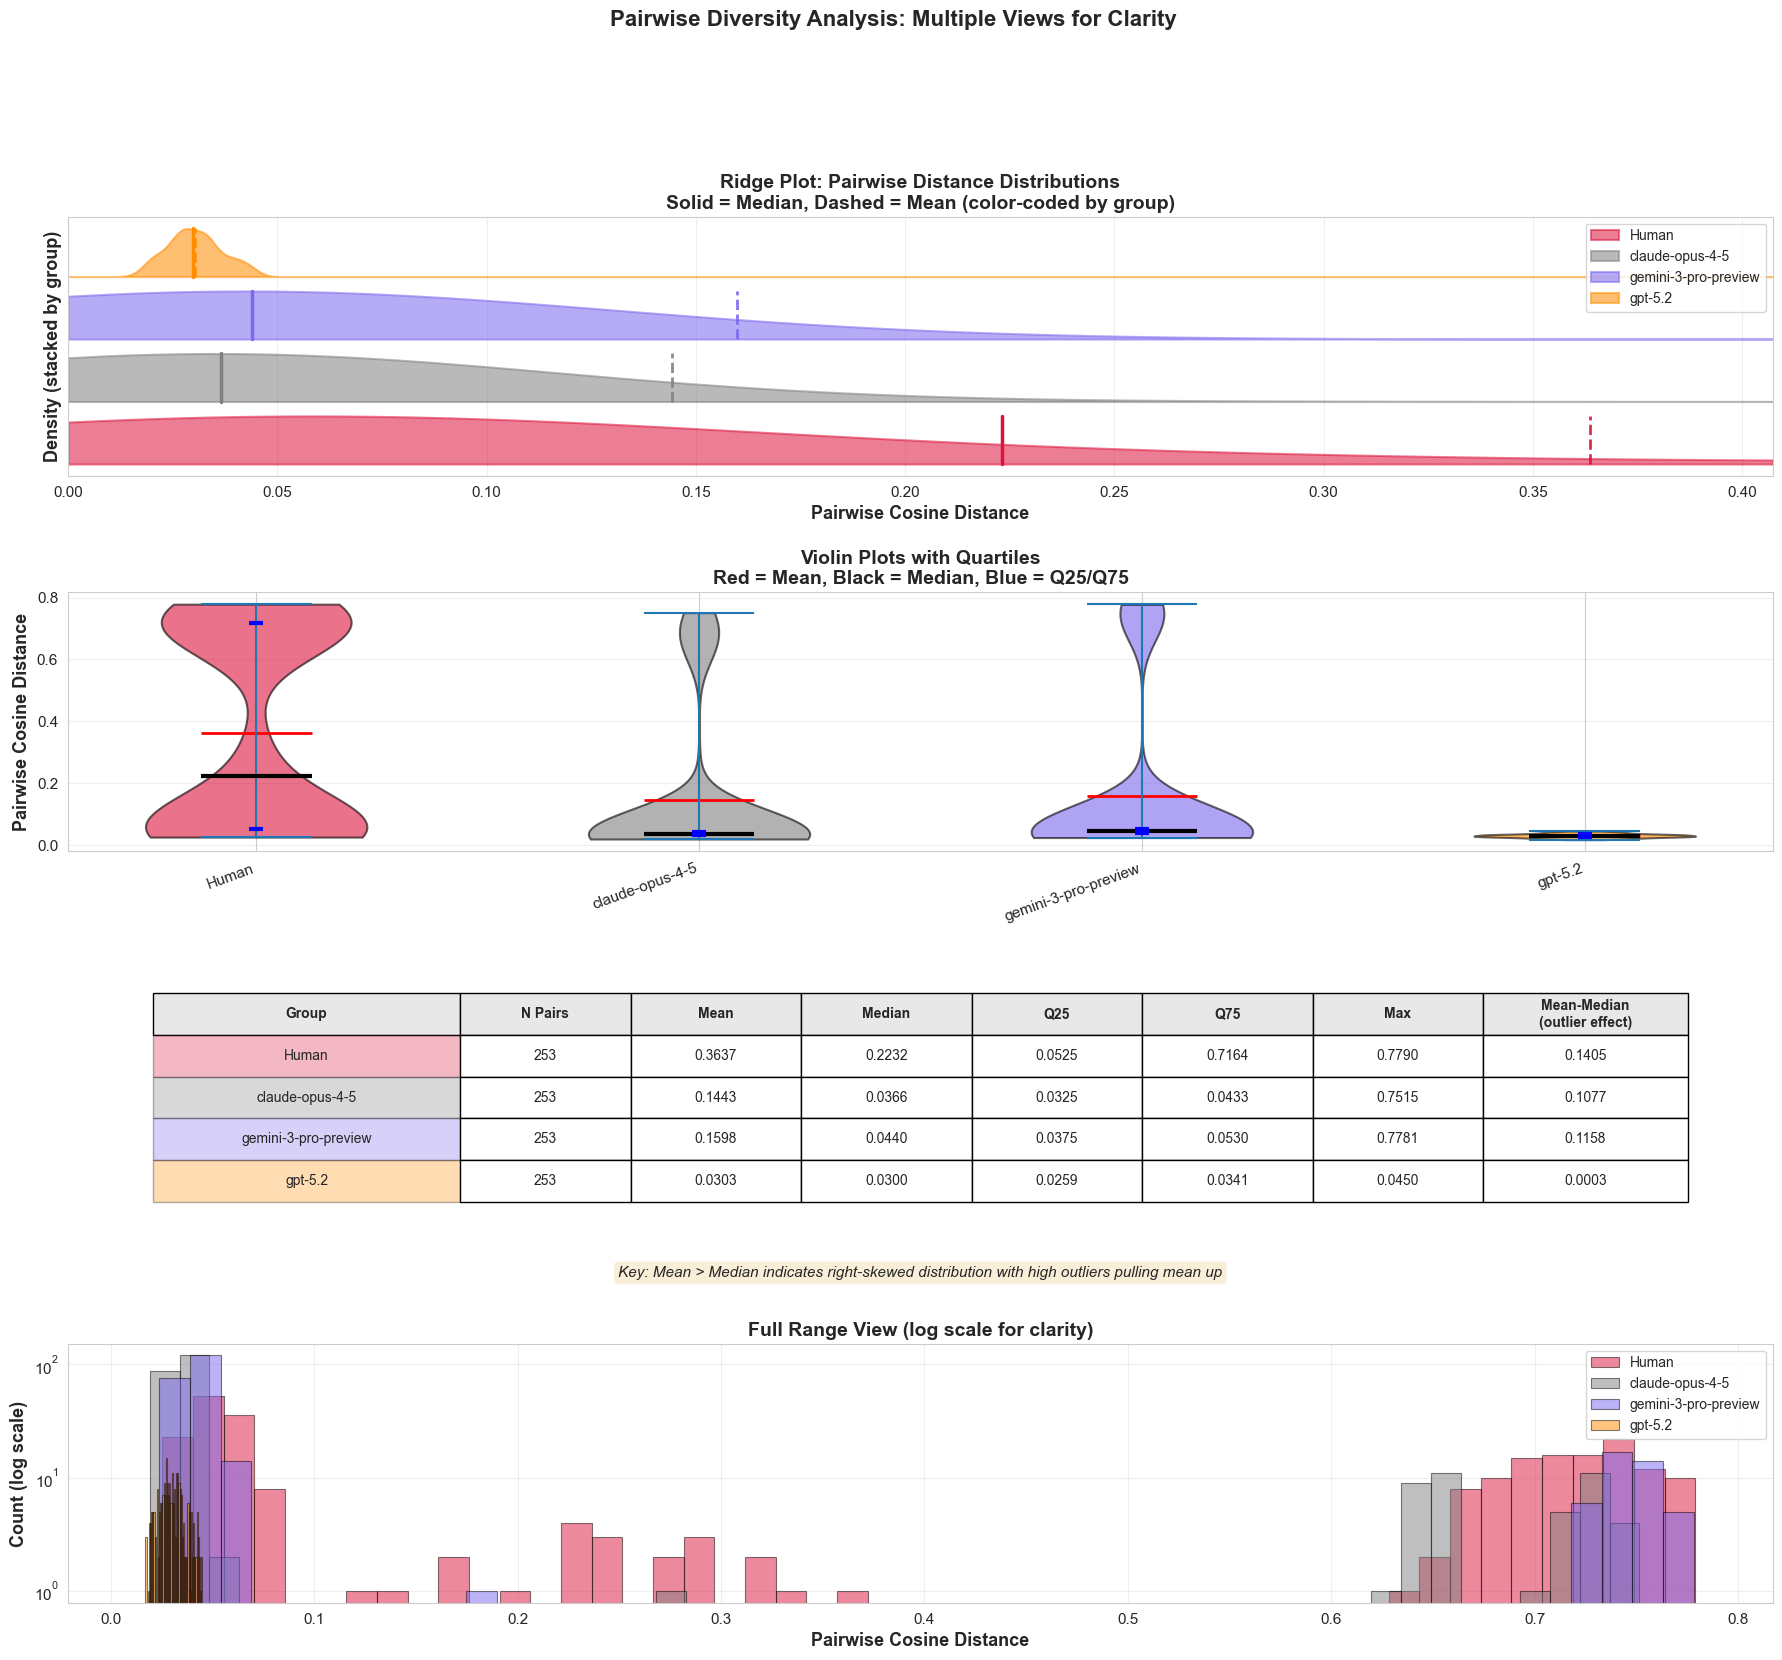

✓ Figure saved to: results/figures/rephrased/pairwise_diversity_by_model.png


In [174]:
# Visualization: Improved distribution comparison for all groups
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# Layout: 4 rows — ridge plot (full width), violin (full width),
#         summary table (full width), log-scale histogram (full width, new row)
fig = plt.figure(figsize=(22, 18))
gs = fig.add_gridspec(4, 1, hspace=0.45)

# Define DISTINCT colors for each group
colors = {
    'Human': '#DC143C',  # Crimson red (PROMINENT)
    'claude-opus-4-6': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#FF8C00',  # Dark orange
}

group_order = ['Human'] + [m for m in ai_models if len(model_pairwise[m]) > 0]

# ── PANEL 1 (Row 0, full width): Ridge plot — x-range covers ALL group medians/means
# Determine x-limit: at least 0.2, but extend to fit the furthest median or mean + margin
all_stats = []
for group in group_order:
    d = human_pairwise if group == 'Human' else model_pairwise[group]
    all_stats += [float(np.median(d)), float(np.mean(d))]
x_limit = max(0.2, max(all_stats) * 1.12)   # 12% margin past the furthest stat line

ax1 = fig.add_subplot(gs[0])
RIDGE_HEIGHT = 1.0   # normalized peak height for every group (equal visual weight)
RIDGE_GAP    = 0.3   # gap between ridges
offset = 0

for idx, group in enumerate(group_order):
    data = human_pairwise if group == 'Human' else model_pairwise[group]
    grp_color = colors.get(group, 'gray')

    if len(data) > 1:
        kde = gaussian_kde(data)
        x_range = np.linspace(0, x_limit, 500)
        density = kde(x_range)
        # Normalize so every ridge peaks at RIDGE_HEIGHT (equal visual weight)
        density_norm = density / density.max() * RIDGE_HEIGHT

        ax1.fill_between(x_range, offset + density_norm, offset,
                         color=grp_color, alpha=0.55,
                         edgecolor=grp_color, linewidth=1.5, label=group)

        ridge_top = offset + RIDGE_HEIGHT

        # Median — solid line spanning full ridge height
        median_val = float(np.median(data))
        ax1.plot([median_val, median_val], [offset, ridge_top],
                 color=grp_color, linestyle='-', linewidth=2.5, alpha=1.0, zorder=5)

        # Mean — dashed line spanning full ridge height
        mean_val = float(np.mean(data))
        ax1.plot([mean_val, mean_val], [offset, ridge_top],
                 color=grp_color, linestyle='--', linewidth=2.0, alpha=0.9, zorder=5)

        offset += RIDGE_HEIGHT + RIDGE_GAP

ax1.set_xlabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax1.set_ylabel('Density (stacked by group)', fontsize=13, fontweight='bold')
ax1.set_title('Ridge Plot: Pairwise Distance Distributions\nSolid = Median, Dashed = Mean (color-coded by group)',
              fontsize=14, fontweight='bold')
ax1.set_xlim(0, x_limit)
ax1.set_yticks([])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(alpha=0.3, axis='x')

# ── PANEL 2 (Row 1, full width): Violin plots with quartile annotations
ax3 = fig.add_subplot(gs[1])

box_data = []
for dist, label in [(human_pairwise, 'Human')] + [(model_pairwise[m], m) for m in ai_models if len(model_pairwise[m]) > 0]:
    for val in dist:
        box_data.append({'Distance': val, 'Group': label})

box_df = pd.DataFrame(box_data)
palette_list = [colors.get(g, 'gray') for g in group_order]

# Create violin plot
parts = ax3.violinplot([box_df[box_df['Group']==g]['Distance'].values for g in group_order],
                       positions=range(len(group_order)),
                       showmeans=True, showmedians=True, showextrema=True)

# Color the violins
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(palette_list[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

# Enhance median and mean lines
parts['cmedians'].set_edgecolor('black')
parts['cmedians'].set_linewidth(3)
parts['cmeans'].set_edgecolor('red')
parts['cmeans'].set_linewidth(2)

# Add quartile markers
for idx, group in enumerate(group_order):
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    q25, q75 = np.percentile(data, [25, 75])
    ax3.scatter([idx, idx], [q25, q75], color='blue', s=100, zorder=3, marker='_', linewidths=3)

ax3.set_xticks(range(len(group_order)))
ax3.set_xticklabels(group_order, fontsize=11, rotation=20, ha='right')
ax3.set_ylabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax3.set_title('Violin Plots with Quartiles\nRed = Mean, Black = Median, Blue = Q25/Q75', 
              fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3, axis='y')

# ── PANEL 3 (Row 2, full width): Statistical summary table
ax4 = fig.add_subplot(gs[2])
ax4.axis('off')

# Create summary statistics
summary_data = []
for group in group_order:
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    summary_data.append([
        group,
        f"{len(data)}",
        f"{data.mean():.4f}",
        f"{np.median(data):.4f}",
        f"{np.percentile(data, 25):.4f}",
        f"{np.percentile(data, 75):.4f}",
        f"{data.max():.4f}",
        f"{data.mean() - np.median(data):.4f}"
    ])

# Create table
table = ax4.table(cellText=summary_data,
                 colLabels=['Group', 'N Pairs', 'Mean', 'Median', 'Q25', 'Q75', 'Max', 'Mean-Median\n(outlier effect)'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.18, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color code the header
for i in range(8):
    table[(0, i)].set_facecolor('#E8E8E8')
    table[(0, i)].set_text_props(weight='bold')

# Color code the groups
for i, group in enumerate(group_order):
    table[(i+1, 0)].set_facecolor(colors.get(group, 'gray'))
    table[(i+1, 0)].set_alpha(0.3)

ax4.text(0.5, -0.15, 
         'Key: Mean > Median indicates right-skewed distribution with high outliers pulling mean up',
         ha='center', va='top', transform=ax4.transAxes, fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── PANEL 4 (Row 3, full width): Full-range histogram with log-scale y-axis
ax2 = fig.add_subplot(gs[3])
for group in group_order:
    data = human_pairwise if group == 'Human' else model_pairwise[group]
    ax2.hist(data, bins=50, alpha=0.5, label=group,
             color=colors.get(group, 'gray'), edgecolor='black', linewidth=0.8)

ax2.set_xlabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax2.set_ylabel('Count (log scale)', fontsize=13, fontweight='bold')
ax2.set_title('Full Range View (log scale for clarity)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle('Pairwise Diversity Analysis: Multiple Views for Clarity', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig(FIGURES_DIR / 'pairwise_diversity_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/rephrased/pairwise_diversity_by_model.png")


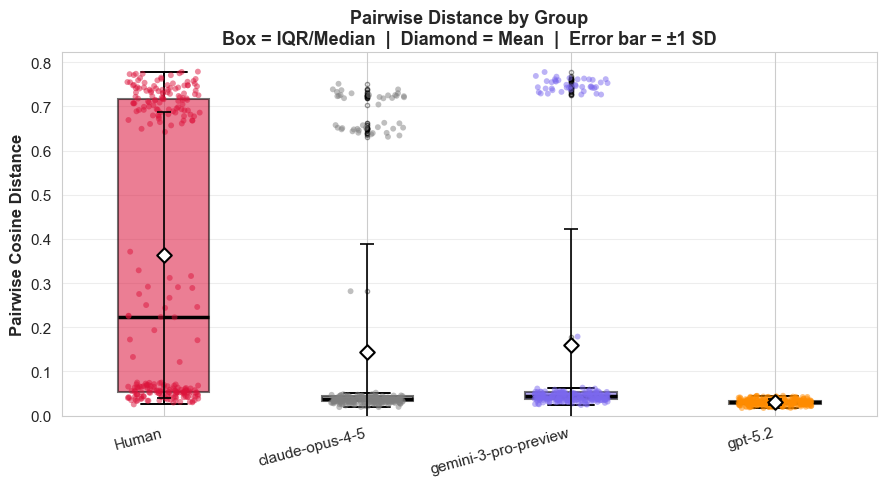

Group                            N     Mean   Median       SD      Min      Max
------------------------------------------------------------------------
Human                          253   0.3637   0.2232   0.3238   0.0254   0.7790
claude-opus-4-5                253   0.1443   0.0366   0.2439   0.0192   0.7515
gemini-3-pro-preview           253   0.1598   0.0440   0.2633   0.0240   0.7781
gpt-5.2                        253   0.0303   0.0300   0.0064   0.0171   0.0450


In [175]:
# Box plot summary: mean, median, SD per group for pairwise distances
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5))

box_arrays = []
for group in group_order:
    d = human_pairwise if group == 'Human' else model_pairwise[group]
    box_arrays.append(d)

# Box plot (shows median, IQR, whiskers)
bp = ax.boxplot(box_arrays, positions=range(len(group_order)),
                patch_artist=True, widths=0.45,
                medianprops=dict(color='black', linewidth=2.5),
                whiskerprops=dict(linewidth=1.4),
                capprops=dict(linewidth=1.4),
                flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'))

for patch, group in zip(bp['boxes'], group_order):
    patch.set_facecolor(colors.get(group, 'gray'))
    patch.set_alpha(0.55)
    patch.set_linewidth(1.5)

# Overlay individual points (jittered)
rng = np.random.default_rng(42)
for i, (group, d) in enumerate(zip(group_order, box_arrays)):
    jitter = rng.uniform(-0.18, 0.18, size=len(d))
    ax.scatter(i + jitter, d,
               color=colors.get(group, 'gray'), s=18, alpha=0.5,
               edgecolors='none', zorder=3)

# Mean markers (diamond)
for i, d in enumerate(box_arrays):
    ax.scatter(i, np.mean(d), marker='D', s=55,
               color='white', edgecolors='black', linewidths=1.5, zorder=5)

# SD error bars around the mean
for i, d in enumerate(box_arrays):
    m, s = np.mean(d), np.std(d, ddof=1)
    ax.errorbar(i, m, yerr=s, fmt='none',
                ecolor='black', elinewidth=1.2, capsize=5, capthick=1.2, zorder=4)

ax.set_xticks(range(len(group_order)))
ax.set_xticklabels(group_order, fontsize=11, rotation=15, ha='right')
ax.set_ylabel('Pairwise Cosine Distance', fontsize=12, fontweight='bold')
ax.set_title('Pairwise Distance by Group\nBox = IQR/Median  |  Diamond = Mean  |  Error bar = ±1 SD',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.35)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pairwise_diversity_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"{'Group':<28} {'N':>5}  {'Mean':>7}  {'Median':>7}  {'SD':>7}  {'Min':>7}  {'Max':>7}")
print('-' * 72)
for group, d in zip(group_order, box_arrays):
    print(f"{group:<28} {len(d):>5}  {np.mean(d):>7.4f}  {np.median(d):>7.4f}"
          f"  {np.std(d, ddof=1):>7.4f}  {d.min():>7.4f}  {d.max():>7.4f}")

## Analysis 1.2: Centroid Dispersion Metric

Measure how scattered proposals are from their group center.

Compares:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**


In [98]:
def compute_centroid_distances(embeddings):
    """
    Compute distances from each proposal to its group centroid.
    """
    # Compute centroid (mean embedding)
    centroid = embeddings.mean(axis=0, keepdims=True)
    
    # Compute cosine distances to centroid
    distances = cosine_distances(embeddings, centroid).flatten()
    
    return distances, centroid

# Compute centroid distances for all groups
print("="*85)
print("COMPUTING CENTROID DISPERSION FOR ALL GROUPS")
print("="*85)

# Overall groups
ai_centroid_dists, ai_centroid = compute_centroid_distances(ai_embeddings)
human_centroid_dists, human_centroid = compute_centroid_distances(human_embeddings)

# Individual AI models
model_centroid_dists = {}
model_centroids = {}

for model in ai_models:
    if len(model_embeddings_dict[model]) > 0:
        dists, centroid = compute_centroid_distances(model_embeddings_dict[model])
        model_centroid_dists[model] = dists
        model_centroids[model] = centroid

# Print statistics table
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Std':<10} {'Variance':<10}")
print("-"*90)

# Human baseline
print(f"{'Human':<35} {len(human_embeddings):<8} {human_centroid_dists.mean():<10.4f} {np.median(human_centroid_dists):<10.4f} {human_centroid_dists.std():<10.4f} {human_centroid_dists.var():<10.4f}")

print()  # Blank line separator

# Individual AI models
for model in ai_models:
    if model in model_centroid_dists:
        dists = model_centroid_dists[model]
        n_proposals = len(model_embeddings_dict[model])
        print(f"{model:<35} {n_proposals:<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.std():<10.4f} {dists.var():<10.4f}")

print()  # Blank line separator

# All AI combined
print(f"{'All AI (combined)':<35} {len(ai_embeddings):<8} {ai_centroid_dists.mean():<10.4f} {np.median(ai_centroid_dists):<10.4f} {ai_centroid_dists.std():<10.4f} {ai_centroid_dists.var():<10.4f}")

print("="*90)
print("\n💡 INTERPRETATION:")
print("   - Higher variance = more dispersed proposals (higher diversity)")
print("   - Lower variance = proposals cluster tightly around center")
print("="*90)


COMPUTING CENTROID DISPERSION FOR ALL GROUPS

GROUP                               N        Mean       Median     Std        Variance  
------------------------------------------------------------------------------------------
Human                               23       0.1927     0.0887     0.1672     0.0279    

claude-opus-4-5                     23       0.0716     0.0205     0.1652     0.0273    
gemini-3-pro-preview                23       0.0797     0.0249     0.1779     0.0317    
gpt-5.2                             23       0.0146     0.0150     0.0034     0.0000    

All AI (combined)                   69       0.0577     0.0209     0.1497     0.0224    

💡 INTERPRETATION:
   - Higher variance = more dispersed proposals (higher diversity)
   - Lower variance = proposals cluster tightly around center


In [99]:
# Save: centroid distances
import pandas as pd, numpy as np; from pathlib import Path
out_dir = TABLES_DIR; out_dir.mkdir(parents=True, exist_ok=True)
rows = [{'title': r.get('proposal_title', r.get('title','')), 'group': 'Human', 'centroid_dist': human_centroid_dists[i]}
        for i, r in enumerate(human_metadata)]
# Use model_centroid_dists.keys() — ai_models_local not yet defined at this point in the notebook
models_local = list(dict.fromkeys(r.get('model','AI') for r in ai_metadata))
mc = {m: 0 for m in models_local}
for r in ai_metadata:
    m = r.get('model','AI'); k = mc.get(m,0)
    rows.append({'title': r.get('title', r.get('proposal_title','')), 'group': m,
                 'centroid_dist': model_centroid_dists[m][k] if m in model_centroid_dists and k < len(model_centroid_dists[m]) else np.nan})
    mc[m] = k+1
pd.DataFrame(rows).to_csv(out_dir/'centroid_distances.csv', index=False)
print(f"Saved centroid_distances.csv  ({len(rows)} rows)")


Saved centroid_distances.csv  (92 rows)


In [100]:
print("="*85)
print("STATISTICAL TESTS: Centroid Dispersion (All Groups vs Human)")
print("="*85)
print("Primary estimand: mean difference in centroid distance (AI - Human).")

comparison_specs = [('All AI', ai_centroid_dists)] + [
    (model, model_centroid_dists[model])
    for model in ai_models
    if model in model_centroid_dists
]

centroid_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_centroid_dists, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    centroid_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals are MORE dispersed from center")
    else:
        print(f"  → Human proposals are MORE dispersed from center")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

centroid_df = pd.DataFrame(centroid_results)
centroid_df = apply_multiple_testing(centroid_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
centroid_comparison_results = centroid_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Centroid Dispersion with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in centroid_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )
print("="*85)
print("💡 Positive mean-diff/δ = AI more dispersed; Negative = Human more dispersed")


STATISTICAL TESTS: Centroid Dispersion (All Groups vs Human)
Primary estimand: mean difference in centroid distance (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 92, p-value: 2.6005e-10
Cliff's Delta:
  δ = -0.8841 (large effect)
  → Human proposals are MORE dispersed from center
Primary mean difference (AI - Human):
  Observed difference: -0.1351
  Bootstrap 95% CI: [-0.2151, -0.0615]
  Permutation p-value: 0.0009

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 46, p-value: 1.6738e-06
Cliff's Delta:
  δ = -0.8261 (large effect)
  → Human proposals are MORE dispersed from center
Primary mea

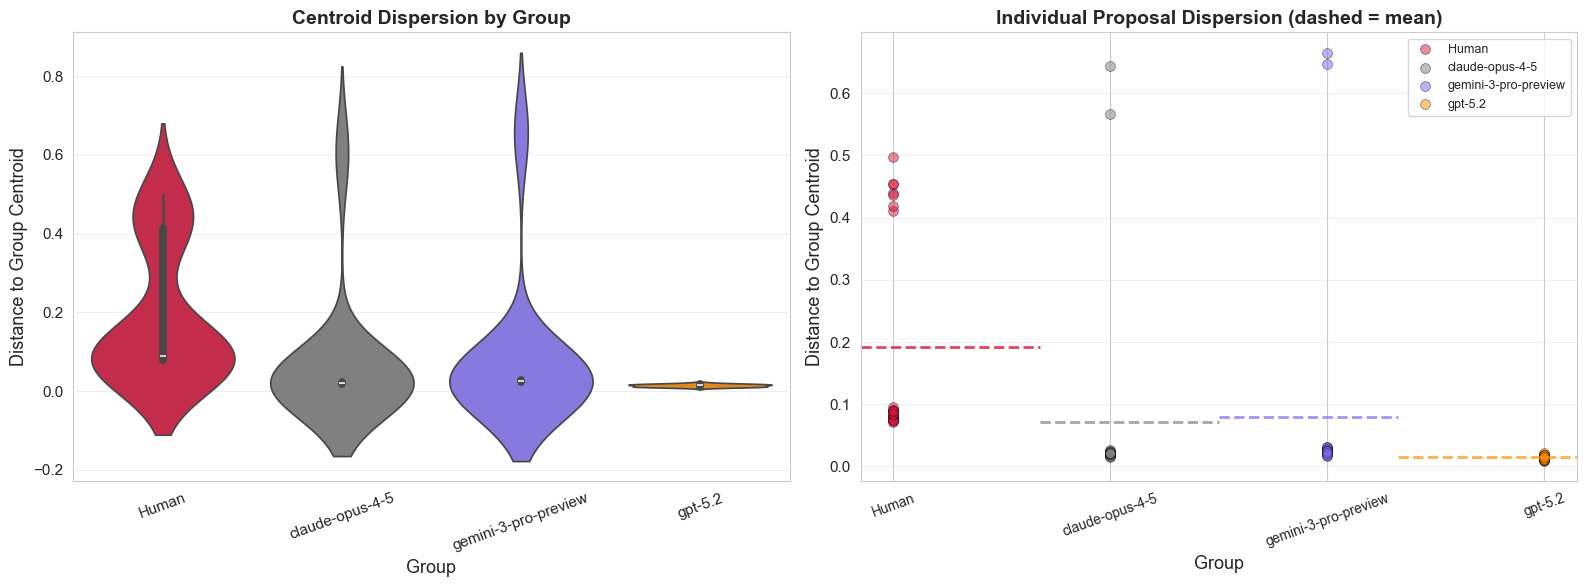

✓ Figure saved to: results/figures/rephrased/centroid_dispersion_by_model.png


In [101]:
# Visualization: Centroid dispersion for all groups
fig, axes = plt.subplots(1, 2, figsize=(16, 6))



# LEFT PANEL: Violin plots
violin_data = []
for dist, label in [(human_centroid_dists, 'Human')] + [(model_centroid_dists[m], m) for m in ai_models if m in model_centroid_dists]:
    for val in dist:
        violin_data.append({'Distance to Centroid': val, 'Group': label})

violin_df = pd.DataFrame(violin_data)
group_order = ['Human'] + [m for m in ai_models if m in model_centroid_dists]
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.violinplot(data=violin_df, x='Group', y='Distance to Centroid', ax=axes[0], palette=palette_list, order=group_order)
axes[0].set_ylabel('Distance to Group Centroid', fontsize=13)
axes[0].set_xlabel('Group', fontsize=13)
axes[0].set_title('Centroid Dispersion by Group', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

# RIGHT PANEL: Scatter plot showing individual proposals
offset = 0
x_positions = {}

# Human
x_positions['Human'] = 0
axes[1].scatter([0]*len(human_centroid_dists), human_centroid_dists, 
               alpha=0.5, label='Human', color=colors['Human'], s=50, edgecolors='black', linewidth=0.5)
axes[1].axhline(human_centroid_dists.mean(), xmin=0/len(group_order), xmax=1/len(group_order), 
               color=colors['Human'], linestyle='--', linewidth=2, alpha=0.8)

offset = 1
# Individual AI models
for i, model in enumerate([m for m in ai_models if m in model_centroid_dists]):
    x_positions[model] = offset
    axes[1].scatter([offset]*len(model_centroid_dists[model]), model_centroid_dists[model], 
                   alpha=0.5, label=model, color=colors.get(model, 'gray'), s=50, edgecolors='black', linewidth=0.5)
    axes[1].axhline(model_centroid_dists[model].mean(), 
                   xmin=offset/len(group_order), xmax=(offset+1)/len(group_order),
                   color=colors.get(model, 'gray'), linestyle='--', linewidth=2, alpha=0.7)
    offset += 1

axes[1].set_xticks(range(len(group_order)))
axes[1].set_xticklabels(group_order, rotation=20, fontsize=10)
axes[1].set_ylabel('Distance to Group Centroid', fontsize=13)
axes[1].set_xlabel('Group', fontsize=13)
axes[1].set_title('Individual Proposal Dispersion (dashed = mean)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'centroid_dispersion_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/rephrased/centroid_dispersion_by_model.png")


## Analysis 1.3: Nearest-Neighbor Outlier Detection (Between Group)

Identify "lone wolf" ideas far from everything else.

Compares:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**


In [102]:
# Combine all embeddings for global nearest-neighbor analysis
all_embeddings = np.vstack([human_embeddings, ai_embeddings])
n_human = len(human_embeddings)
n_ai = len(ai_embeddings)

# Build per-row labels aligned to embedding order (avoid assuming contiguous blocks by model)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == n_ai:
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == n_ai and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels = np.array((['Human'] * n_human) + ai_model_labels)
ai_models_local = [m for m in sorted(list(dict.fromkeys(ai_model_labels))) if m is not None]

# Compute full distance matrix
print("="*85)
print("COMPUTING NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS")
print("="*85)

all_distances = cosine_distances(all_embeddings)
np.fill_diagonal(all_distances, np.inf)
nn_distances = all_distances.min(axis=1)

# Split by group
human_nn_dists = nn_distances[labels == 'Human']
ai_nn_dists = nn_distances[labels != 'Human']

# Extract per-model NN distances using label masks
model_nn_dists = {m: nn_distances[labels == m] for m in ai_models_local}

# Print statistics table
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
print("-"*85)

print(f"{'Human':<35} {len(human_nn_dists):<8} {human_nn_dists.mean():<10.4f} {np.median(human_nn_dists):<10.4f} {human_nn_dists.min():<10.4f} {human_nn_dists.max():<10.4f}")
print()

for model in ai_models_local:
    dists = model_nn_dists[model]
    print(f"{model:<35} {len(dists):<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.min():<10.4f} {dists.max():<10.4f}")

print()
print(f"{'All AI (combined)':<35} {len(ai_nn_dists):<8} {ai_nn_dists.mean():<10.4f} {np.median(ai_nn_dists):<10.4f} {ai_nn_dists.min():<10.4f} {ai_nn_dists.max():<10.4f}")

print("="*85)
print("\n💡 INTERPRETATION:")
print("   - Higher mean NN distance = more isolated proposals (outliers)")
print("   - Lower mean NN distance = proposals cluster together")
print("="*85)


COMPUTING NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.0648     0.0327     0.0191     0.1946    

claude-opus-4-5                     23       0.0330     0.0201     0.0113     0.2045    
gemini-3-pro-preview                23       0.0349     0.0244     0.0162     0.1684    
gpt-5.2                             23       0.0193     0.0191     0.0113     0.0271    

All AI (combined)                   69       0.0291     0.0210     0.0113     0.2045    

💡 INTERPRETATION:
   - Higher mean NN distance = more isolated proposals (outliers)
   - Lower mean NN distance = proposals cluster together


In [103]:
# Identify outliers (top 10% of NN distances)
threshold = np.percentile(nn_distances, 90)
outliers = nn_distances > threshold

human_outliers = int(outliers[labels == 'Human'].sum())
ai_outliers = int(outliers[labels != 'Human'].sum())

# Per-model outlier detection (do NOT slice by contiguous blocks)
model_outliers = {m: int(outliers[labels == m].sum()) for m in ai_models_local}

print("\n" + "="*85)
print("OUTLIER DETECTION (Top 10% Nearest-Neighbor Distance)")
print("="*85)
print(f"Threshold distance: {threshold:.4f}")
print()

print(f"{'GROUP':<35} {'Outliers':<15} {'Total':<10} {'Percentage':<15}")
print("-"*85)

print(f"{'Human':<35} {human_outliers:<15} {n_human:<10} {human_outliers/n_human*100:<15.1f}%")
print()

for model in ai_models_local:
    n_model = int((labels == model).sum())
    print(f"{model:<35} {model_outliers[model]:<15} {n_model:<10} {model_outliers[model]/n_model*100:<15.1f}%")

print()
print(f"{'All AI (combined)':<35} {ai_outliers:<15} {n_ai:<10} {ai_outliers/n_ai*100:<15.1f}%")

print("="*85)



OUTLIER DETECTION (Top 10% Nearest-Neighbor Distance)
Threshold distance: 0.1215

GROUP                               Outliers        Total      Percentage     
-------------------------------------------------------------------------------------
Human                               5               23         21.7           %

claude-opus-4-5                     2               23         8.7            %
gemini-3-pro-preview                2               23         8.7            %
gpt-5.2                             0               23         0.0            %

All AI (combined)                   4               69         5.8            %


In [104]:
# Save: NN distances + outlier flags
import pandas as pd, numpy as np; from pathlib import Path
out_dir = TABLES_DIR; out_dir.mkdir(parents=True, exist_ok=True)
rows = [{'title': r.get('proposal_title', r.get('title','')), 'group': 'Human',
         'nn_dist': human_nn_dists[i], 'is_outlier': bool(outliers[i])}
        for i, r in enumerate(human_metadata)]
mc = {m: 0 for m in ai_models_local}
for j, r in enumerate(ai_metadata):
    m = r.get('model','AI'); k = mc.get(m,0)
    rows.append({'title': r.get('title', r.get('proposal_title','')), 'group': m,
                 'nn_dist': model_nn_dists[m][k] if m in model_nn_dists and k < len(model_nn_dists[m]) else np.nan,
                 'is_outlier': bool(outliers[len(human_metadata)+j])})
    mc[m] = k+1
df = pd.DataFrame(rows); df['threshold'] = threshold
df.to_csv(out_dir/'nn_distances.csv', index=False)
print(f"Saved nn_distances.csv  ({len(df)} rows, threshold={threshold:.4f})")
print(df.groupby('group')[['nn_dist','is_outlier']].agg({'nn_dist':'mean','is_outlier':'sum'}))


Saved nn_distances.csv  (92 rows, threshold=0.1215)
                       nn_dist  is_outlier
group                                     
Human                 0.064810           5
claude-opus-4-5       0.033025           2
gemini-3-pro-preview  0.034942           2
gpt-5.2               0.019256           0


In [105]:
# Find nearest neighbor's group for each proposal
nn_indices = all_distances.argmin(axis=1)
nn_labels = labels[nn_indices]

# Determine if NN is from same or different group
human_nn_same_group = int((nn_labels[labels == 'Human'] == 'Human').sum())
human_nn_diff_group = int(n_human - human_nn_same_group)

ai_nn_same_group = int((nn_labels[labels != 'Human'] != 'Human').sum())
ai_nn_diff_group = int(n_ai - ai_nn_same_group)

# Per-model nearest neighbor group analysis (mask-based)
model_nn_analysis = {}
for model in ai_models_local:
    mask = labels == model
    total = int(mask.sum())
    nn_from_human = int((nn_labels[mask] == 'Human').sum())
    nn_from_same_model = int((nn_labels[mask] == model).sum())
    nn_from_other_ai = int(total - nn_from_human - nn_from_same_model)

    model_nn_analysis[model] = {
        'from_human': nn_from_human,
        'from_same_model': nn_from_same_model,
        'from_other_ai': nn_from_other_ai,
        'total': total
    }

print("\n" + "="*85)
print("NEAREST NEIGHBOR GROUP ANALYSIS")
print("="*85)

print(f"\n{'Human proposals:':<50}")
print(f"  NN from same group (human): {human_nn_same_group} ({human_nn_same_group/n_human*100:.1f}%)")
print(f"  NN from different group (AI): {human_nn_diff_group} ({human_nn_diff_group/n_human*100:.1f}%)")

print(f"\n{'All AI proposals (combined):':<50}")
print(f"  NN from same group (AI): {ai_nn_same_group} ({ai_nn_same_group/n_ai*100:.1f}%)")
print(f"  NN from different group (human): {ai_nn_diff_group} ({ai_nn_diff_group/n_ai*100:.1f}%)")

print("\n" + "-"*85)
print("Per-Model NN Group Breakdown:")
print("-"*85)

for model in ai_models_local:
    data = model_nn_analysis[model]
    print(f"\n{model}:")
    print(f"  NN from Human: {data['from_human']} ({data['from_human']/data['total']*100:.1f}%)")
    print(f"  NN from same model: {data['from_same_model']} ({data['from_same_model']/data['total']*100:.1f}%)")
    print(f"  NN from other AI models: {data['from_other_ai']} ({data['from_other_ai']/data['total']*100:.1f}%)")

print("\n" + "="*85)
print("\n💡 INTERPRETATION:")
print("   - High 'NN from same model' = model produces similar proposals")
print("   - High 'NN from Human' = model proposals resemble human work")
print("="*85)



NEAREST NEIGHBOR GROUP ANALYSIS

Human proposals:                                  
  NN from same group (human): 8 (34.8%)
  NN from different group (AI): 15 (65.2%)

All AI proposals (combined):                      
  NN from same group (AI): 65 (94.2%)
  NN from different group (human): 4 (5.8%)

-------------------------------------------------------------------------------------
Per-Model NN Group Breakdown:
-------------------------------------------------------------------------------------

claude-opus-4-5:
  NN from Human: 2 (8.7%)
  NN from same model: 9 (39.1%)
  NN from other AI models: 12 (52.2%)

gemini-3-pro-preview:
  NN from Human: 2 (8.7%)
  NN from same model: 2 (8.7%)
  NN from other AI models: 19 (82.6%)

gpt-5.2:
  NN from Human: 0 (0.0%)
  NN from same model: 17 (73.9%)
  NN from other AI models: 6 (26.1%)


💡 INTERPRETATION:
   - High 'NN from same model' = model produces similar proposals
   - High 'NN from Human' = model proposals resemble human work


In [106]:
print("="*85)
print("STATISTICAL TESTS: Nearest-Neighbor Distances (All Groups vs Human)")
print("="*85)
print("Primary estimand: mean difference in NN distance (AI - Human).")

comparison_specs = [('All AI', ai_nn_dists)] + [
    (model, model_nn_dists[model])
    for model in ai_models
    if model in model_nn_dists
]

nn_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_nn_dists, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    nn_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals have MORE unique/outlier ideas")
    else:
        print(f"  → Human proposals have MORE unique/outlier ideas")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

nn_df = pd.DataFrame(nn_results)
nn_df = apply_multiple_testing(nn_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
nn_comparison_results = nn_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Nearest-Neighbor Distances with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in nn_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )
print("="*85)
print("💡 Positive mean-diff/δ = AI more outlier-prone; Negative = Human more outlier-prone")


STATISTICAL TESTS: Nearest-Neighbor Distances (All Groups vs Human)
Primary estimand: mean difference in NN distance (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 262, p-value: 1.6821e-06
Cliff's Delta:
  δ = -0.6698 (large effect)
  → Human proposals have MORE unique/outlier ideas
Primary mean difference (AI - Human):
  Observed difference: -0.0357
  Bootstrap 95% CI: [-0.0611, -0.0130]
  Permutation p-value: 0.0011

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 94, p-value: 1.8746e-04
Cliff's Delta:
  δ = -0.6446 (large effect)
  → Human proposals have MORE unique/outlier ideas
Primary m

In [107]:
import numpy as np
import pandas as pd

print("\n" + "="*85)
print("UNADJUSTED NN OUTLIERS: TITLES + AUTHOR")
print("="*85)

required = ['outliers', 'threshold', 'n_human']
missing = [v for v in required if v not in globals()]
if missing:
    print(f"⚠️ Missing variables: {missing}")
    print("Run the unadjusted NN + outlier detection cells first.")
else:
    outlier_indices = np.where(outliers)[0]
    n_total = int(len(outliers))
    n_ai = int(n_total - n_human)

    # NN distances (unadjusted)
    nn_d = np.asarray(nn_distances) if 'nn_distances' in globals() else None

    # Prefer metadata saved alongside embeddings (aligned with embedding order)
    use_meta = ('ai_metadata' in globals()) and ('human_metadata' in globals())
    if use_meta:
        if len(human_metadata) != n_human or len(ai_metadata) != n_ai:
            print("⚠️ Metadata lengths do not match embedding counts; falling back to df lookup.")
            use_meta = False

    rows = []
    for idx in outlier_indices:
        if idx < n_human:
            who = 'Human'
            model = 'Human'
            if use_meta:
                rec = human_metadata[idx]
                title = rec.get('proposal_title', rec.get('title', ''))
            else:
                title = human_df.iloc[idx].get('proposal_title', human_df.iloc[idx].get('title', '')) if 'human_df' in globals() else ''
        else:
            ai_idx = int(idx - n_human)
            who = 'AI'
            if use_meta:
                rec = ai_metadata[ai_idx]
                model = str(rec.get('model', 'AI'))
                title = str(rec.get('title', ''))
            else:
                model = str(ai_df.iloc[ai_idx].get('model', 'AI')) if 'ai_df' in globals() else 'AI'
                title = str(ai_df.iloc[ai_idx].get('title', '')) if 'ai_df' in globals() else ''

        rows.append({
            'global_index': int(idx),
            'who': who,
            'model': model,
            'nn_distance': float(nn_d[idx]) if nn_d is not None else np.nan,
            'title': title
        })

    out_df = pd.DataFrame(rows).sort_values('nn_distance', ascending=False)

    print(f"Outlier threshold (90th percentile): {threshold:.4f}")
    print(f"Total outliers: {len(out_df)} / {n_total} ({len(out_df)/n_total*100:.1f}%)")
    print("Outliers by source (model):")
    print(out_df['model'].value_counts().to_string())

    with pd.option_context('display.max_colwidth', 140):
        display(out_df.reset_index(drop=True))



UNADJUSTED NN OUTLIERS: TITLES + AUTHOR
Outlier threshold (90th percentile): 0.1215
Total outliers: 9 / 92 (9.8%)
Outliers by source (model):
model
Human                   5
claude-opus-4-5         2
gemini-3-pro-preview    2


,global_index,who,model,nn_distance,title
0,77,AI,claude-opus-4-5,0.204479,Integration of Structural and Proteomic Data for Decoding Cargo Recognition Networks in Autophagy Receptors
1,11,Human,Human,0.194564,Impact of Heat Wave Stress on Cytokinetic Bottlenecks in Cellular Division
2,4,Human,Human,0.170727,Integrative Multi-Omics Synthesis for the Identification of Shared Molecular Mechanisms in Mammalian Hibernation
3,58,AI,gemini-3-pro-preview,0.168442,Emergent Immune Evasion Mechanisms Mediated by Bulky Glycan Shields in the Glycocalyx
4,22,Human,Human,0.163903,Intelligent Metadata Compilation for Enhanced Reusability and Discoverability of Mass Spectrometry-Based Proteomics Data
5,48,AI,gemini-3-pro-preview,0.141495,Mapping Transient Metabolons through Integrated Interactomics to Elucidate the Emergence of Metabolic Channeling
6,14,Human,Human,0.132835,Synthesis of Gene Expression Data for the Construction of a Bacterial Cell State Atlas
7,10,Human,Human,0.123305,Discovery and Functional Characterization of Bacterial Organelles via Integrated Omics Data Mining and Refinement
8,75,AI,claude-opus-4-5,0.123305,Decoding Signaling Fidelity through Integrated Phosphoproteomics and Structural Analysis of Kinase-Substrate Networks


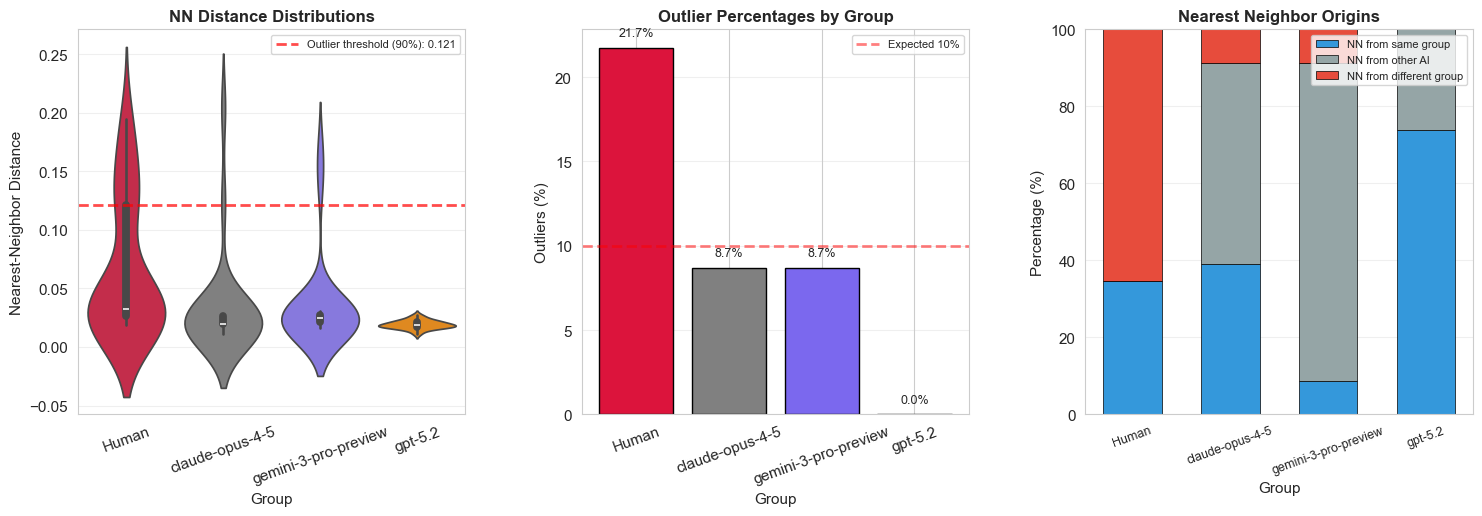

✓ Figure saved to: results/figures/rephrased/nearest_neighbor_by_model.png


In [108]:
# Visualization: Nearest-neighbor analysis by group
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# # Color scheme
# colors = {
#     'Human': 'steelblue',
#     'claude-opus-4-6': '#E74C3C',
#     'gemini-3-pro-preview': '#9B59B6',
#     'gpt-5.2': '#F39C12',
#     'All AI': 'coral'
# }

# 1. NN distance distributions by group
ax1 = fig.add_subplot(gs[0, 0])
nn_data = []
for dist, label in [(human_nn_dists, 'Human')] + [(model_nn_dists[m], m) for m in ai_models if m in model_nn_dists]:
    for val in dist:
        nn_data.append({'NN Distance': val, 'Group': label})

nn_df = pd.DataFrame(nn_data)
group_order = ['Human'] + [m for m in ai_models if m in model_nn_dists]
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.violinplot(data=nn_df, x='Group', y='NN Distance', ax=ax1, palette=palette_list, order=group_order)
ax1.axhline(threshold, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Outlier threshold (90%): {threshold:.3f}')
ax1.set_ylabel('Nearest-Neighbor Distance', fontsize=11)
ax1.set_xlabel('Group', fontsize=11)
ax1.set_title('NN Distance Distributions', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3, axis='y')

# 2. Outlier counts by group
ax2 = fig.add_subplot(gs[0, 1])
outlier_data = []
outlier_data.append({'Group': 'Human', 'Outliers': human_outliers, 'Total': n_human, 'Percentage': human_outliers/n_human*100})

for model in ai_models:
    if model in model_outliers:
        n_model = len(model_embeddings_dict[model])
        outlier_data.append({
            'Group': model,
            'Outliers': model_outliers[model],
            'Total': n_model,
            'Percentage': model_outliers[model]/n_model*100
        })

outlier_df = pd.DataFrame(outlier_data)
bars = ax2.bar(outlier_df['Group'], outlier_df['Percentage'], color=[colors.get(g, 'gray') for g in outlier_df['Group']], 
               edgecolor='black', linewidth=1)
ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected 10%')
ax2.set_ylabel('Outliers (%)', fontsize=11)
ax2.set_xlabel('Group', fontsize=11)
ax2.set_title('Outlier Percentages by Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=20)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (bar, pct) in enumerate(zip(bars, outlier_df['Percentage'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# 3. NN Group Analysis - Stacked bar chart
ax3 = fig.add_subplot(gs[0, 2])

# Prepare data for stacked bars
groups = ['Human'] + [m for m in ai_models if m in model_nn_analysis]
nn_from_human_pcts = [human_nn_diff_group/n_human*100]  # For human, this is NN from AI
nn_from_same_pcts = [human_nn_same_group/n_human*100]  # For human, this is NN from human
nn_from_other_ai_pcts = [0]  # Human doesn't have this category

for model in [m for m in ai_models if m in model_nn_analysis]:
    data = model_nn_analysis[model]
    nn_from_human_pcts.append(data['from_human']/data['total']*100)
    nn_from_same_pcts.append(data['from_same_model']/data['total']*100)
    nn_from_other_ai_pcts.append(data['from_other_ai']/data['total']*100)

x_pos = np.arange(len(groups))
width = 0.6

# Adjust labels for Human
p1 = ax3.bar(x_pos, nn_from_same_pcts, width, label='NN from same group', color='#3498db', edgecolor='black', linewidth=0.5)
p2 = ax3.bar(x_pos, nn_from_other_ai_pcts, width, bottom=nn_from_same_pcts, label='NN from other AI', color='#95a5a6', edgecolor='black', linewidth=0.5)
bottom = np.array(nn_from_same_pcts) + np.array(nn_from_other_ai_pcts)
p3 = ax3.bar(x_pos, nn_from_human_pcts, width, bottom=bottom, label='NN from different group', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax3.set_ylabel('Percentage (%)', fontsize=11)
ax3.set_xlabel('Group', fontsize=11)
ax3.set_title('Nearest Neighbor Origins', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(groups, rotation=20, fontsize=9)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(alpha=0.3, axis='y')
ax3.set_ylim([0, 100])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nearest_neighbor_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/rephrased/nearest_neighbor_by_model.png")


### Embedding Space Visualization

Visualize all proposals in 2D space using UMAP dimensionality reduction to see:
- **Clustering patterns**: How proposals group together
- **Outliers**: Unique proposals far from others (highlighted in magenta)
- **Group separation**: How Human vs AI proposals distribute in semantic space
- **Model characteristics**: Whether different AI models produce distinctly clustered proposals

**Color coding**: Human proposals in bright red for easy identification, AI models in muted colors.


VISUALIZING PROPOSALS IN 2D EMBEDDING SPACE

Reducing embeddings to 2D using UMAP...
✓ UMAP completed: 92 proposals reduced to 2D


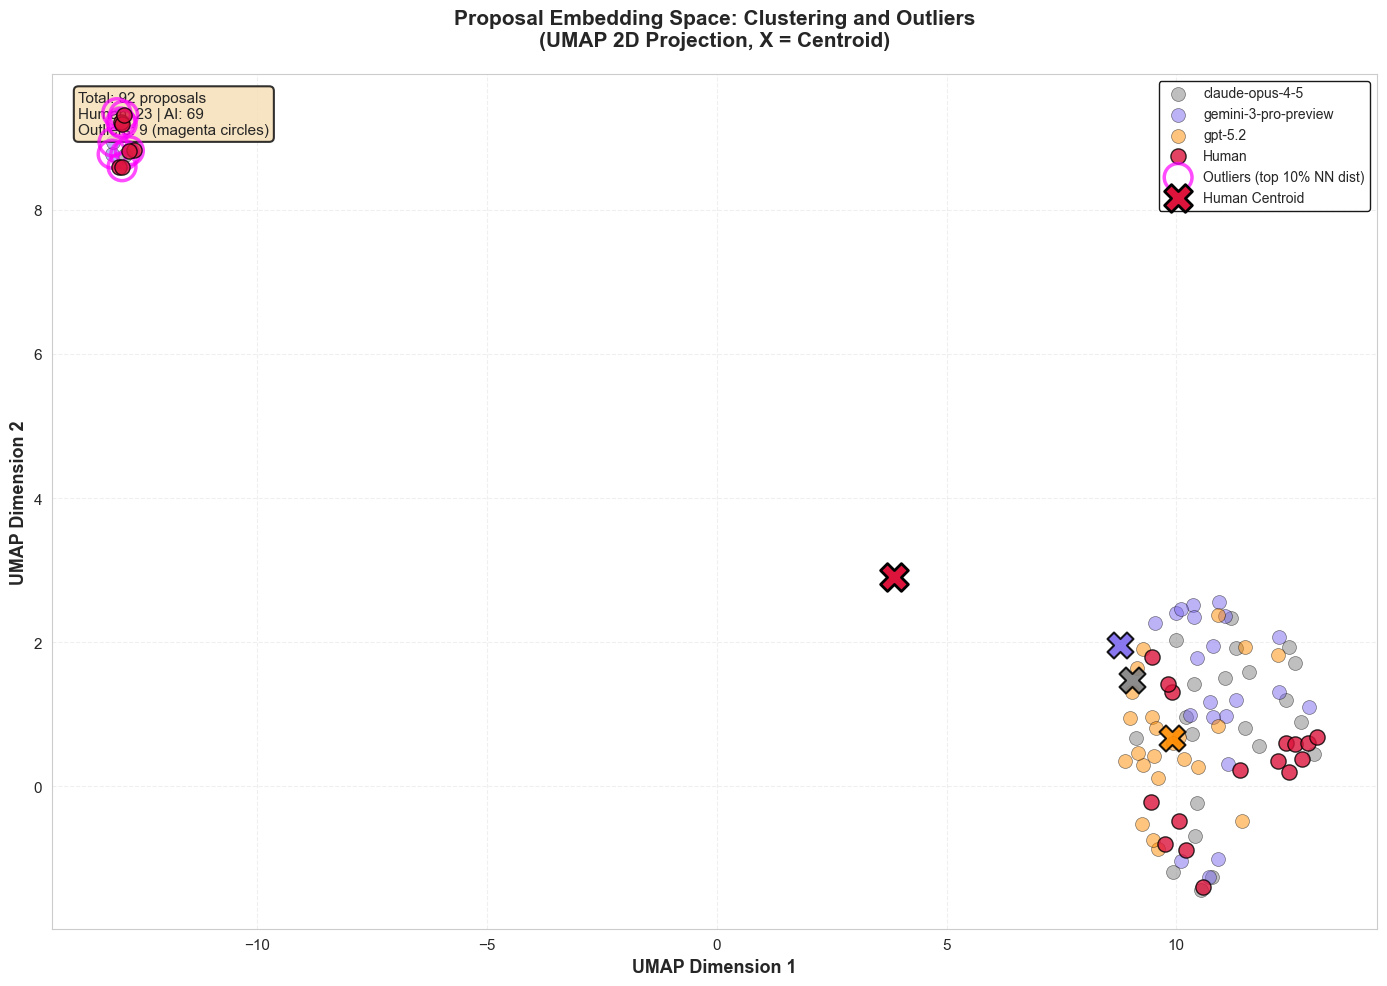


✓ Figure saved to: results/figures/rephrased/embedding_space_2d.png

💡 INTERPRETATION:
   - Clusters = similar proposals
   - Outliers (magenta circles) = unique/distant proposals
   - X markers = group centroids
   - Distance between groups shows overall similarity


In [109]:


print("\n" + "="*85)
print("VISUALIZING PROPOSALS IN 2D EMBEDDING SPACE")
print("="*85)

# Apply UMAP dimensionality reduction
print("\nReducing embeddings to 2D using UMAP...")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

# Combine all embeddings for UMAP
all_embeddings_umap = np.vstack([human_embeddings, ai_embeddings])
embeddings_2d = reducer.fit_transform(all_embeddings_umap)

# Split back into groups
human_2d = embeddings_2d[:n_human]
ai_2d = embeddings_2d[n_human:]

# Build labels aligned to embedding order (avoid assuming contiguous model blocks)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels_umap = np.array((['Human'] * n_human) + ai_model_labels)
ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

print(f"✓ UMAP completed: {len(embeddings_2d)} proposals reduced to 2D")

# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot AI models first (so human is on top) — mask-based by label
for model in ai_models_local:
    mask = labels_umap == model
    if mask.any():
        pts = embeddings_2d[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'),
                   label=model,
                   s=100,
                   alpha=0.5,
                   edgecolors='black',
                   linewidth=0.5)

# Plot human proposals on top (bright red)
ax.scatter(human_2d[:, 0], human_2d[:, 1],
          c=colors['Human'],
          label='Human',
          s=120,
          alpha=0.8,
          edgecolors='black',
          linewidth=1.0,
          marker='o',
          zorder=10)  # Ensure human points are on top

# Highlight outliers with a circle
outlier_indices = np.where(outliers)[0]
outlier_coords = embeddings_2d[outlier_indices]

ax.scatter(outlier_coords[:, 0], outlier_coords[:, 1],
          s=400,
          facecolors='none',
          edgecolors='magenta',
          linewidth=2.5,
          alpha=0.7,
          label=f'Outliers (top 10% NN dist)',
          zorder=5)

# Calculate and plot centroids for each group
human_centroid_2d = human_2d.mean(axis=0)
ax.scatter(human_centroid_2d[0], human_centroid_2d[1],
          c=colors['Human'],
          s=400,
          marker='X',
          edgecolors='black',
          linewidth=2,
          alpha=1.0,
          zorder=15,
          label='Human Centroid')

for model in ai_models_local:
    mask = labels_umap == model
    if mask.any():
        model_centroid_2d = embeddings_2d[mask].mean(axis=0)
        ax.scatter(model_centroid_2d[0], model_centroid_2d[1],
                   c=colors.get(model, '#808080'),
                   s=350,
                   marker='X',
                   edgecolors='black',
                   linewidth=1.5,
                   alpha=0.9,
                   zorder=12)

# Labels and formatting
ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
ax.set_title('Proposal Embedding Space: Clustering and Outliers\n(UMAP 2D Projection, X = Centroid)',
            fontsize=15, fontweight='bold', pad=20)

# Legend
ax.legend(loc='best', fontsize=10, framealpha=0.9, edgecolor='black')

# Grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add text annotation with key insights
textstr = f'Total: {len(embeddings_2d)} proposals\n'
textstr += f'Human: {n_human} | AI: {n_ai}\n'
textstr += f'Outliers: {len(outlier_indices)} (magenta circles)'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
       verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'embedding_space_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/rephrased/embedding_space_2d.png")
print("\n💡 INTERPRETATION:")
print("   - Clusters = similar proposals")
print("   - Outliers (magenta circles) = unique/distant proposals")
print("   - X markers = group centroids")
print("   - Distance between groups shows overall similarity")
print("="*85)



ALTERNATIVE VIEW: t-SNE Projection (metadata-aligned)

Reducing embeddings to 2D using t-SNE...
(This may take a minute...)


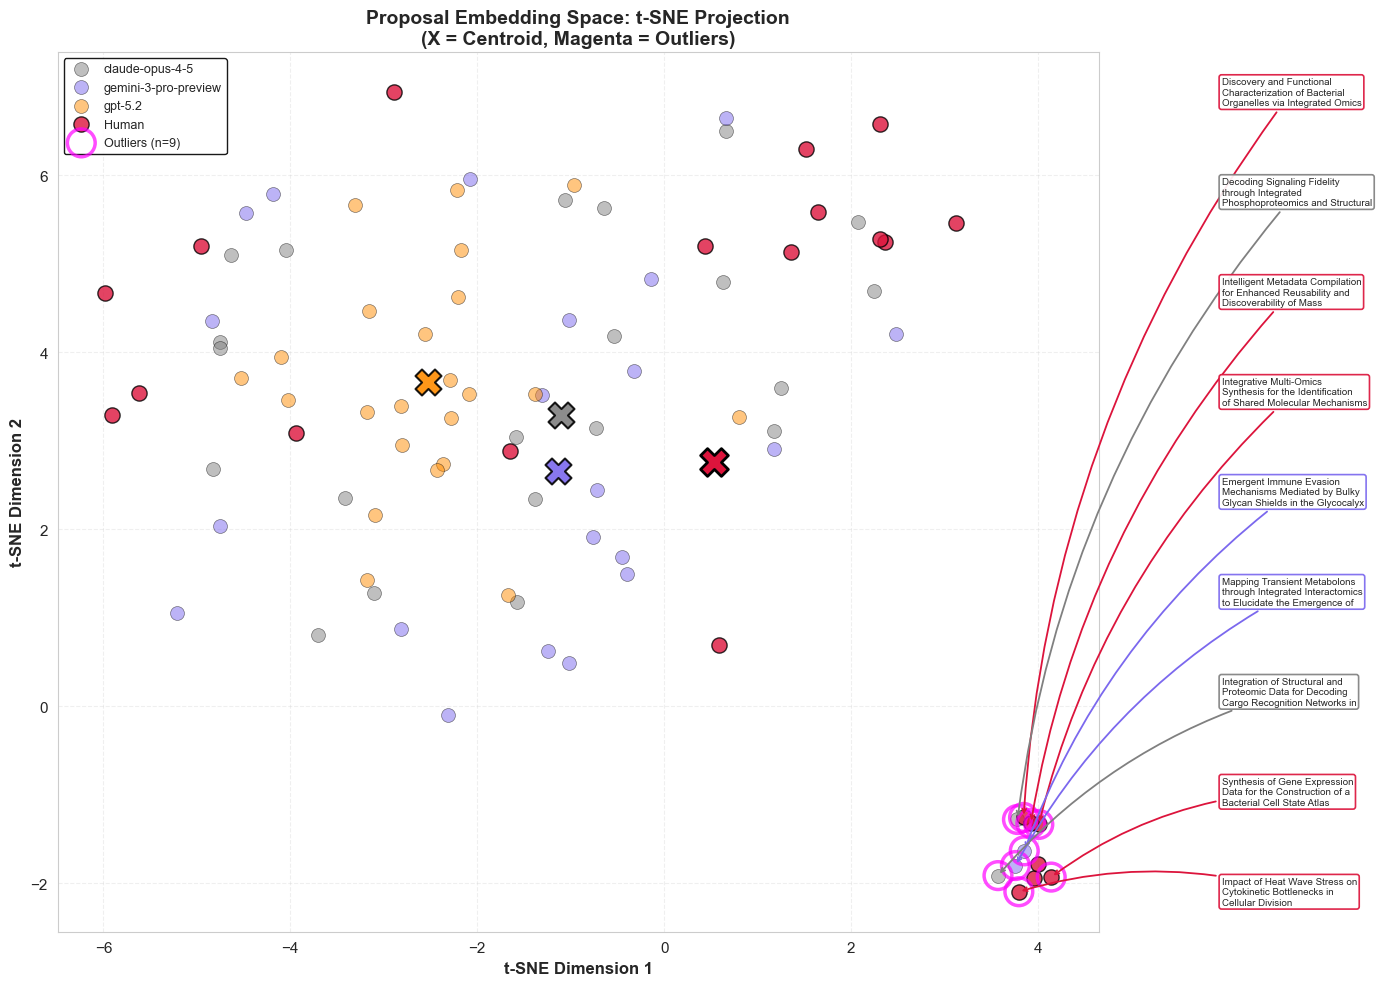


✓ Figure saved to: ../results/figures/rephrased/minimal/embedding_space_tsne.png


In [168]:
# Alternative visualization: t-SNE (complementary to UMAP)
from sklearn.manifold import TSNE

print("\n" + "="*85)
print("ALTERNATIVE VIEW: t-SNE Projection (metadata-aligned)")
print("="*85)

# Build labels aligned to embedding order (same approach as UMAP cell)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels_tsne = np.array((['Human'] * n_human) + ai_model_labels)
ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

# Apply t-SNE dimensionality reduction
print("\nReducing embeddings to 2D using t-SNE...")
print("(This may take a minute...)")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    metric='cosine',
    random_state=42,
    n_iter=1000,
    verbose=0
)

embeddings_2d_tsne = tsne.fit_transform(all_embeddings_umap)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

for model in ai_models_local:
    mask = labels_tsne == model
    if mask.any():
        pts = embeddings_2d_tsne[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'),
                   label=model,
                   s=100,
                   alpha=0.5,
                   edgecolors='black',
                   linewidth=0.5)

# Human
mask_h = labels_tsne == 'Human'
pts_h = embeddings_2d_tsne[mask_h]
ax.scatter(pts_h[:, 0], pts_h[:, 1],
           c=colors['Human'],
           label='Human',
           s=120,
           alpha=0.8,
           edgecolors='black',
           linewidth=1.0,
           marker='o',
           zorder=10)

# Highlight the same outliers (computed from NN distances)
outlier_indices = np.where(outliers)[0]
outlier_coords_plot = embeddings_2d_tsne[outlier_indices]
ax.scatter(outlier_coords_plot[:, 0], outlier_coords_plot[:, 1],
           s=400,
           facecolors='none',
           edgecolors='magenta',
           linewidth=2.5,
           alpha=0.7,
           label=f'Outliers (n={len(outlier_indices)})',
           zorder=12)

# Build a title lookup aligned to the embedding order (human first, then AI)
all_titles_tsne = []
for r in (human_metadata if 'human_metadata' in globals() else []):
    all_titles_tsne.append(r.get('proposal_title', r.get('title', '')))
for r in (ai_metadata if 'ai_metadata' in globals() else []):
    all_titles_tsne.append(r.get('title', r.get('proposal_title', '')))

# ── Stacked, non-overlapping labels with arrows ───────────────────────────────
# Collect (point_x, point_y, title, group) for each outlier, sorted by point y (top→bottom)
outlier_info = sorted(
    [(embeddings_2d_tsne[idx][0],
      embeddings_2d_tsne[idx][1],
      all_titles_tsne[idx] if idx < len(all_titles_tsne) else '',
      labels_tsne[idx])
     for idx in outlier_indices],
    key=lambda p: -p[1]   # descending y so top outlier gets top label
)

# Place label column just past the right edge of all data
x_data_max = embeddings_2d_tsne[:, 0].max()
x_data_min = embeddings_2d_tsne[:, 0].min()
x_label_col = x_data_max + (x_data_max - x_data_min) * 0.18

# Spread labels evenly across the full vertical range of the plot
y_data_max = embeddings_2d_tsne[:, 1].max()
y_data_min = embeddings_2d_tsne[:, 1].min()
n_out = len(outlier_info)
y_label_positions = [
    y_data_max - i * (y_data_max - y_data_min) / max(n_out - 1, 1)
    for i in range(n_out)
]

def wrap_title(title, max_chars=32):
    words = title.split()
    lines, line = [], []
    for w in words:
        line.append(w)
        if len(' '.join(line)) > max_chars:
            lines.append(' '.join(line[:-1]))
            line = [w]
    if line:
        lines.append(' '.join(line))
    return '\n'.join(lines[:3])

for (px, py, title, grp), y_lab in zip(outlier_info, y_label_positions):
    grp_color = colors.get(grp, '#808080')
    ax.annotate(
        wrap_title(title),
        xy=(px, py),                      # tip of arrow → actual point
        xytext=(x_label_col, y_lab),      # label position in stacked column
        fontsize=7,
        verticalalignment='center',
        zorder=20,
        arrowprops=dict(
            arrowstyle='->',
            color=grp_color,
            lw=1.3,
            connectionstyle='arc3,rad=0.15',   # slight curve to reduce crossing
        ),
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor=grp_color,
            linewidth=1.2,
            alpha=0.92,
        ),
    )

# Centroids
centroid_h = pts_h.mean(axis=0)
ax.scatter(centroid_h[0], centroid_h[1],
           c=colors['Human'],
           s=400,
           marker='X',
           edgecolors='black',
           linewidth=2,
           alpha=1.0,
           zorder=15)

for model in ai_models_local:
    mask = labels_tsne == model
    if mask.any():
        c2d = embeddings_2d_tsne[mask].mean(axis=0)
        ax.scatter(c2d[0], c2d[1],
                   c=colors.get(model, '#808080'),
                   s=350,
                   marker='X',
                   edgecolors='black',
                   linewidth=1.5,
                   alpha=0.9,
                   zorder=14)

ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('Proposal Embedding Space: t-SNE Projection\n(X = Centroid, Magenta = Outliers)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')

plt.tight_layout()
out_path = FIGURES_DIR / 'embedding_space_tsne.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved to: {out_path}")
print("="*85)


# PART II: NOVELTY

Can AI create more novel proposals than teams of human scientists?

We'll compare how far proposals are from existing literature (PubMed corpus).

## Step 1: Load Literature Corpus

Load the 350 PubMed abstracts from `data/literature/call-relevant-corpus.json`.

In [111]:
import json

# Load literature corpus
print("="*85)
print("LOADING LITERATURE CORPUS")
print("="*85)

with open('../data/literature/call-relevant-corpus.json', 'r') as f:
    corpus_data = json.load(f)

articles = corpus_data['articles']
print(f"\n✓ Loaded {len(articles)} PubMed articles")
print(f"  Search queries: {len(corpus_data['search_queries'])}")

# Extract title and abstract for each article
corpus_texts = []
for article in articles:
    title = article.get('title', '')
    abstract = article.get('abstract', '')
    # Combine title and abstract (same format as we'll use for proposals)
    text = f"Title: {title}\n\nAbstract: {abstract}"
    corpus_texts.append(text)

print(f"\n✓ Prepared {len(corpus_texts)} literature texts")
print(f"  Average length: {np.mean([len(t) for t in corpus_texts]):.0f} characters")
print("="*85)

LOADING LITERATURE CORPUS

✓ Loaded 600 PubMed articles
  Search queries: 14

✓ Prepared 600 literature texts
  Average length: 1312 characters


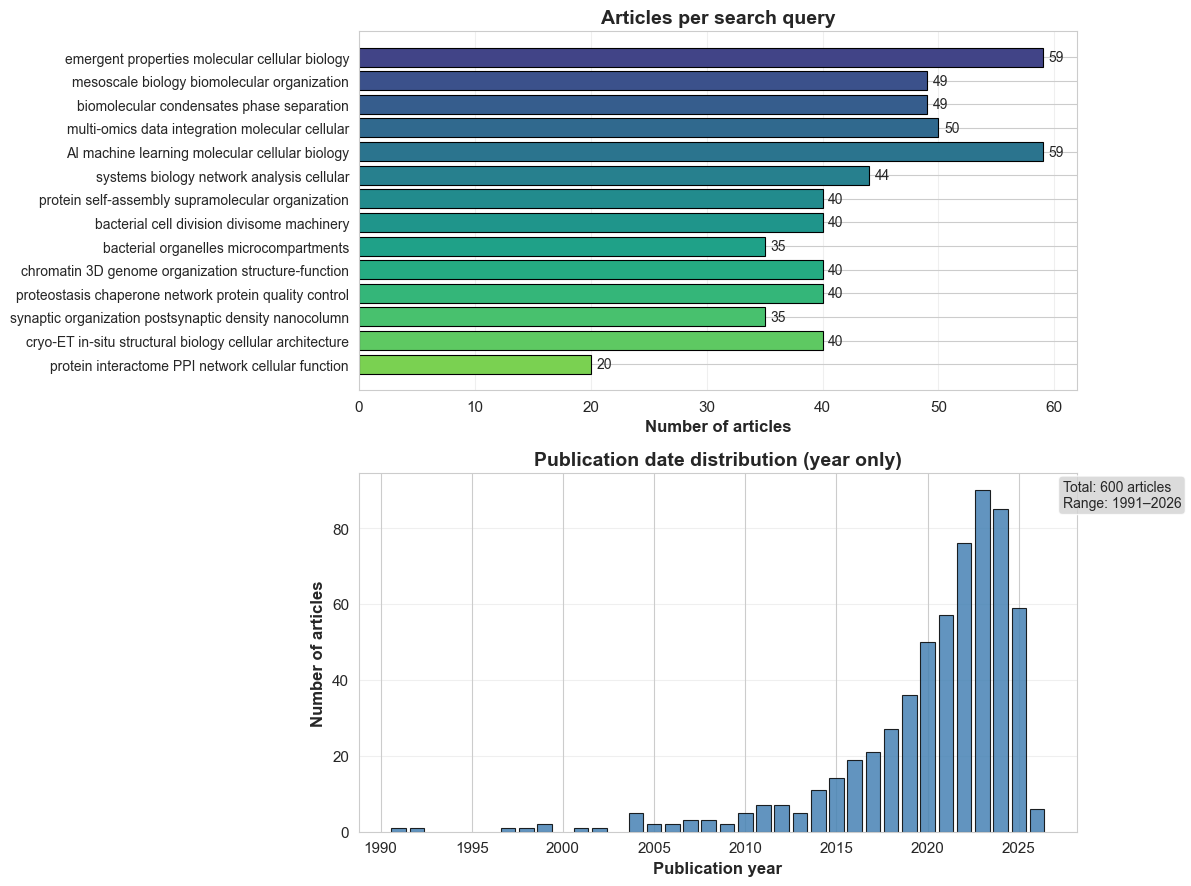

✓ Figure saved to: results/figures/rephrased/literature_corpus_overview.png

SEARCH TERMS (QUERIES) USED PER CATEGORY

• emergent properties molecular cellular biology (n=59 articles):
  ("emergent properties" OR "emergence") AND ("molecular biology" OR "cellular biology" OR "cell biology")

• mesoscale biology biomolecular organization (n=49 articles):
  ("mesoscale" OR "mesoscopic") AND ("protein" OR "biomolecular" OR "cellular" OR "organelle")

• biomolecular condensates phase separation (n=49 articles):
  ("biomolecular condensates" OR "phase separation") AND ("cell biology" OR "molecular biology")

• multi-omics data integration molecular cellular (n=50 articles):
  ("multi-omics" OR "multiomics" OR "integrative omics") AND ("data integration" OR "data synthesis") AND ("molecular" OR "cellular")

• AI machine learning molecular cellular biology (n=59 articles):
  ("machine learning" OR "artificial intelligence" OR "deep learning") AND ("molecular biology" OR "cell biology" OR "pro

In [112]:
# Visualize literature corpus: articles per query + publication year distribution
import re

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# --- Panel 1: Articles per search query ---
ax1 = axes[0]
queries = corpus_data['search_queries']
labels = [q['label'] for q in queries]
counts = [q['new_unique_added'] for q in queries]
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.8, len(labels)))
bars = ax1.barh(range(len(labels)), counts, color=colors_bar, edgecolor='black', linewidth=0.8)
ax1.set_yticks(range(len(labels)))
ax1.set_yticklabels(labels, fontsize=10, ha='right')
ax1.set_xlabel('Number of articles', fontsize=12, fontweight='bold')
ax1.set_title('Articles per search query', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
for bar, c in zip(bars, counts):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(c), va='center', fontsize='10')

# --- Panel 2: Publication year distribution ---
ax2 = axes[1]
def parse_year(pub_date):
    if not pub_date or not isinstance(pub_date, str):
        return None
    m = re.match(r'(\d{4})', pub_date.strip())
    return int(m.group(1)) if m else None

years = [parse_year(a.get('publication_date')) for a in articles]
years = [y for y in years if y is not None]
year_counts = pd.Series(years).value_counts().sort_index()

ax2.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='black', linewidth=0.8, alpha=0.85)
ax2.set_xlabel('Publication year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of articles', fontsize=12, fontweight='bold')
ax2.set_title('Publication date distribution (year only)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
if years:
    ax2.text(0.98, 0.98, f'Total: {len(years)} articles\nRange: {min(years)}–{max(years)}', transform=ax2.transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'literature_corpus_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figure saved to: results/figures/rephrased/literature_corpus_overview.png')

# Print search terms (queries) used for each category
print('\n' + '='*85)
print('SEARCH TERMS (QUERIES) USED PER CATEGORY')
print('='*85)
for q in queries:
    print(f"\n• {q['label']} (n={q['new_unique_added']} articles):")
    print(f"  {q['query']}")
print('='*85)

## Step 2: Embed Literature Corpus 

Embed all 350 abstracts using BioLinkBERT-Large (same model used for proposals).

In [113]:
# Embed literature corpus using the same chunking approach
print("="*85)
print("EMBEDDING LITERATURE CORPUS")
print("="*85)
print("Using BioLinkBERT-Large with chunking (same as proposals)")
print()

# Check if embeddings already exist
literature_embeddings_file = LITERATURE_EMBEDDINGS_FILE

if literature_embeddings_file.exists():
    print(f"✓ Loading cached literature embeddings from {literature_embeddings_file}")
    with open(literature_embeddings_file, 'rb') as f:
        literature_data = pickle.load(f)
        literature_embeddings = literature_data['embeddings']
    print(f"✓ Loaded {len(literature_embeddings)} embeddings")
else:
    print("Embedding literature corpus (this will take a few minutes)...")
    literature_embeddings = get_embeddings_with_chunking(corpus_texts)
    print(f"✓ Literature embeddings shape: {literature_embeddings.shape}")
    
    # Cache for future use
    literature_embeddings_file.parent.mkdir(parents=True, exist_ok=True)
    with open(literature_embeddings_file, 'wb') as f:
        pickle.dump({
            'embeddings': literature_embeddings,
            'model_name': model_name,
            'timestamp': datetime.now().isoformat()
        }, f)
    print(f"✓ Cached embeddings to: {literature_embeddings_file}")

print("="*85)

EMBEDDING LITERATURE CORPUS
Using BioLinkBERT-Large with chunking (same as proposals)

✓ Loading cached literature embeddings from ../data/embeddings/literature/relevant_literature_embeddings.pkl
✓ Loaded 600 embeddings


## Step 3: Re-embed Proposals Using Section 1 Only (Abstract Equivalent)

For a fair comparison with literature (which has only title + abstract), re-embed proposals using only **title + Section 1** (`SCIENTIFIC BACKGROUND AND RESEARCH QUESTION`). This 3-sentence section covers domain, gap, and research question — the same information carried by a PubMed abstract.

In [114]:
import re

def extract_background_section(standardized_text):
    """Extract the Scientific Background and Research Question section
    from standardized_text as an abstract-equivalent for literature comparison.
    This section (3 sentences) covers domain, gap, and research question --
    matching the title+abstract format used for PubMed literature embeddings."""
    match = re.search(
        r"SCIENTIFIC BACKGROUND AND RESEARCH QUESTION\s*\n(.*?)(?=\nMETHODOLOGY AND ANALYTICAL APPROACH)",
        standardized_text, re.DOTALL | re.IGNORECASE
    )
    if match:
        return match.group(1).strip()
    return standardized_text  # fallback: use full standardized text


# Re-embed proposals using title + Section 1 (background) only.
# Section 1 ~ abstract: 3 sentences on domain, gap, and research question.
# This matches the title+abstract format used for PubMed literature embeddings.
print("="*85)
print("RE-EMBEDDING PROPOSALS (TITLE + BACKGROUND SECTION AS ABSTRACT EQUIVALENT)")
print("="*85)

abstract_embeddings_file = ABSTRACT_EMBEDDINGS_FILE

if abstract_embeddings_file.exists():
    print(f"\n✓ Loading cached section-1 embeddings from {abstract_embeddings_file}")
    with open(abstract_embeddings_file, "rb") as f:
        abstract_data = pickle.load(f)
        ai_embeddings_abstract = abstract_data["ai_embeddings"]
        human_embeddings_abstract = abstract_data["human_embeddings"]
    print(f"✓ Loaded embeddings: AI {ai_embeddings_abstract.shape}, Human {human_embeddings_abstract.shape}")
else:
    ai_abstracts_only = []
    for idx, row in ai_df.iterrows():
        title = row["title"]
        background = extract_background_section(row.get("standardized_text", ""))
        text = f"Title: {title}\n\nAbstract: {background}"
        ai_abstracts_only.append(text)

    human_abstracts_only = []
    for idx, row in human_df.iterrows():
        title = row.get("proposal_title", row.get("title", ""))
        background = extract_background_section(row.get("standardized_text", ""))
        text = f"Title: {title}\n\nAbstract: {background}"
        human_abstracts_only.append(text)

    print(f"\nPrepared {len(ai_abstracts_only)} AI abstract-equivalents")
    print(f"Prepared {len(human_abstracts_only)} human abstract-equivalents")
    print(f"Average length - AI: {np.mean([len(t) for t in ai_abstracts_only]):.0f} chars")
    print(f"Average length - Human: {np.mean([len(t) for t in human_abstracts_only]):.0f} chars")

    print("\nEmbedding AI abstract-equivalents...")
    ai_embeddings_abstract = get_embeddings_with_chunking(ai_abstracts_only)
    print(f"✓ AI abstract embeddings shape: {ai_embeddings_abstract.shape}")

    print("\nEmbedding human abstract-equivalents...")
    human_embeddings_abstract = get_embeddings_with_chunking(human_abstracts_only)
    print(f"✓ Human abstract embeddings shape: {human_embeddings_abstract.shape}")

    # Cache for future use
    abstract_embeddings_file.parent.mkdir(parents=True, exist_ok=True)
    with open(abstract_embeddings_file, "wb") as f:
        pickle.dump({
            "ai_embeddings": ai_embeddings_abstract,
            "human_embeddings": human_embeddings_abstract,
            "model_name": model_name,
            "timestamp": datetime.now().isoformat()
        }, f)
    print(f"\n✓ Cached embeddings to: {abstract_embeddings_file}")

print("="*85)


RE-EMBEDDING PROPOSALS (TITLE + BACKGROUND SECTION AS ABSTRACT EQUIVALENT)

✓ Loading cached section-1 embeddings from ../data/embeddings/rephrased/proposal_embeddings_section1_only_minimal.pkl
✓ Loaded embeddings: AI (69, 1024), Human (23, 1024)


## Step 4: Compute Novelty Scores

For each proposal, find k=10 nearest neighbors in literature corpus and compute novelty score.

In [115]:
from sklearn.metrics.pairwise import cosine_distances

# Compute novelty scores
print("="*85)
print("COMPUTING NOVELTY SCORES")
print("="*85)
print("Novelty = Mean distance to 10 nearest neighbors in literature corpus")
print("Higher score = farther from existing work = more novel")
print()

k = 10  # Number of nearest neighbors

def compute_novelty_scores(proposal_embeddings, literature_embeddings, k=10):
    """
    Compute novelty score for each proposal as mean distance to k-NN in literature.
    
    Args:
        proposal_embeddings: Embeddings of proposals (n_proposals, embedding_dim)
        literature_embeddings: Embeddings of literature corpus (n_articles, embedding_dim)
        k: Number of nearest neighbors
        
    Returns:
        novelty_scores: Array of novelty scores (n_proposals,)
        nearest_neighbor_indices: Array of k-NN indices for each proposal (n_proposals, k)
    """
    # Compute distances from each proposal to all literature articles
    distances = cosine_distances(proposal_embeddings, literature_embeddings)
    
    # For each proposal, find k nearest neighbors
    nearest_neighbor_indices = np.argsort(distances, axis=1)[:, :k]
    
    # Novelty score = mean distance to k-NN
    novelty_scores = np.array([
        distances[i, nearest_neighbor_indices[i]].mean()
        for i in range(len(proposal_embeddings))
    ])
    
    return novelty_scores, nearest_neighbor_indices

# Compute novelty for AI proposals
print("Computing novelty scores for AI proposals...")
ai_novelty_scores, ai_nn_indices = compute_novelty_scores(
    ai_embeddings_abstract, literature_embeddings, k=k
)

# Compute novelty for Human proposals
print("Computing novelty scores for human proposals...")
human_novelty_scores, human_nn_indices = compute_novelty_scores(
    human_embeddings_abstract, literature_embeddings, k=k
)

# Split AI novelty by model (mask-based; do NOT assume contiguous blocks)
if 'ai_df' not in globals() or 'model' not in ai_df.columns:
    raise RuntimeError("ai_df with a 'model' column is required to split AI novelty scores by model")

ai_models = sorted(ai_df['model'].astype(str).unique().tolist())
ai_model_series = ai_df['model'].astype(str).values

model_novelty_scores = {m: ai_novelty_scores[ai_model_series == m] for m in ai_models}

# Display statistics
print(f"\n{'='*85}")
print("NOVELTY SCORE STATISTICS")
print(f"{'='*85}")
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
print("-"*85)

# Human
print(f"{'Human':<35} {len(human_novelty_scores):<8} {human_novelty_scores.mean():<10.4f} {np.median(human_novelty_scores):<10.4f} {human_novelty_scores.min():<10.4f} {human_novelty_scores.max():<10.4f}")

print()  # Blank line

# Individual AI models
for model in ai_models:
    if model in model_novelty_scores:
        scores = model_novelty_scores[model]
        print(f"{model:<35} {len(scores):<8} {scores.mean():<10.4f} {np.median(scores):<10.4f} {scores.min():<10.4f} {scores.max():<10.4f}")

print()  # Blank line

# All AI combined
print(f"{'All AI (combined)':<35} {len(ai_novelty_scores):<8} {ai_novelty_scores.mean():<10.4f} {np.median(ai_novelty_scores):<10.4f} {ai_novelty_scores.min():<10.4f} {ai_novelty_scores.max():<10.4f}")

print("="*85)
print("\n💡 INTERPRETATION:")
print("   - Higher novelty score = more distant from existing literature")
print("   - Lower novelty score = more similar to published work")
print("="*85)

COMPUTING NOVELTY SCORES
Novelty = Mean distance to 10 nearest neighbors in literature corpus
Higher score = farther from existing work = more novel

Computing novelty scores for AI proposals...
Computing novelty scores for human proposals...

NOVELTY SCORE STATISTICS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.1081     0.1047     0.0797     0.1560    

claude-opus-4-5                     23       0.0954     0.0947     0.0788     0.1166    
gemini-3-pro-preview                23       0.0978     0.0972     0.0802     0.1207    
gpt-5.2                             23       0.1060     0.1059     0.0831     0.1333    

All AI (combined)                   69       0.0997     0.0976     0.0788     0.1333    

💡 INTERPRETATION:
   - Higher novelty score = more distant from existing literature
   - Lower novelty scor

## Step 4b: Literature-Normalized Novelty Scores

Raw k-NN distances to literature are **corpus-relative**: a score of 0.15 vs 0.10 means one proposal is farther, but neither score is interpretable against an absolute standard — it depends entirely on how densely the corpus covers the topic.

**Normalization approach:** Compute the same k=10 NN distance for each article *against the rest of the corpus* (excluding self). This gives a baseline distribution representing 'how spread out the literature itself is'. Proposal novelty scores are then expressed as **z-scores** relative to that baseline:

$$z = \frac{\text{novelty}_{\text{proposal}} - \mu_{\text{lit}}}{\sigma_{\text{lit}}}$$

Interpretation:
- **z > 0**: proposal is farther from its nearest literature than the typical inter-article gap → genuinely novel relative to the corpus density
- **z ≈ 0**: proposal sits at the same distance as a typical article in the corpus
- **z < 0**: proposal is closer to literature than articles are to each other → highly similar to existing work

A **ratio score** (raw novelty / literature mean) is also reported: >1 = farther from literature than articles are from each other; <1 = closer.

In [116]:
from sklearn.metrics.pairwise import cosine_distances
import numpy as np

print("="*85)
print("COMPUTING LITERATURE-NORMALIZED NOVELTY SCORES")
print("="*85)

k = 10  # same k as raw novelty

# ── Within-literature baseline: k-NN distance for each article vs. the rest ──
print(f"Computing within-literature {k}-NN distances (baseline)...")
lit_dist_matrix = cosine_distances(literature_embeddings, literature_embeddings)
np.fill_diagonal(lit_dist_matrix, np.inf)  # exclude self-distance

lit_knn_indices = np.argsort(lit_dist_matrix, axis=1)[:, :k]
lit_baseline_knn = np.array([
    lit_dist_matrix[i, lit_knn_indices[i]].mean()
    for i in range(len(literature_embeddings))
])

lit_baseline_mean = lit_baseline_knn.mean()
lit_baseline_std  = lit_baseline_knn.std()

print(f"\nLiterature baseline (within-corpus k-NN distances):")
print(f"  Mean:   {lit_baseline_mean:.4f}")
print(f"  Std:    {lit_baseline_std:.4f}")
print(f"  Min:    {lit_baseline_knn.min():.4f}")
print(f"  Max:    {lit_baseline_knn.max():.4f}")

# ── Normalized scores ─────────────────────────────────────────────────────────
# Z-score: (proposal_novelty - lit_mean) / lit_std
# Ratio  : proposal_novelty  / lit_mean

human_novelty_z     = (human_novelty_scores - lit_baseline_mean) / lit_baseline_std
ai_novelty_z        = (ai_novelty_scores    - lit_baseline_mean) / lit_baseline_std

human_novelty_ratio = human_novelty_scores / lit_baseline_mean
ai_novelty_ratio    = ai_novelty_scores    / lit_baseline_mean

model_novelty_z     = {m: (model_novelty_scores[m] - lit_baseline_mean) / lit_baseline_std
                       for m in ai_models}
model_novelty_ratio = {m: model_novelty_scores[m] / lit_baseline_mean
                       for m in ai_models}

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print("="*85)
print("NORMALIZED NOVELTY SUMMARY")
print("="*85)
print(f"  z-score > 0 → more novel than typical inter-article gap in corpus")
print(f"  ratio   > 1 → farther from literature than articles are from each other")
print()
print(f"{'GROUP':<35} {'N':<6} {'Raw mean':<12} {'z-score':<12} {'Ratio':<10}")
print("-"*85)

print(f"  Literature (baseline){'':14} {len(literature_embeddings):<6} "
      f"{lit_baseline_mean:<12.4f} {'0.00':>12} {'1.00':>10}")
print()

groups = [("Human", human_novelty_scores, human_novelty_z, human_novelty_ratio)] + [
    (m, model_novelty_scores[m], model_novelty_z[m], model_novelty_ratio[m])
    for m in ai_models
]
for name, raw, z, r in groups:
    print(f"  {name:<33} {len(raw):<6} {raw.mean():<12.4f} {z.mean():<12.4f} {r.mean():<10.4f}")

print()
all_ai_z   = ai_novelty_z
all_ai_r   = ai_novelty_ratio
print(f"  {'All AI (combined)':<33} {len(ai_novelty_z):<6} "
      f"{ai_novelty_scores.mean():<12.4f} {all_ai_z.mean():<12.4f} {all_ai_r.mean():<10.4f}")
print("="*85)
print("\n💡 z-score interpretation: number of literature SDs above/below the corpus mean")
print("   Ratio interpretation: proposal distance as multiple of mean inter-article distance")


COMPUTING LITERATURE-NORMALIZED NOVELTY SCORES
Computing within-literature 10-NN distances (baseline)...

Literature baseline (within-corpus k-NN distances):
  Mean:   0.1108
  Std:    0.0625
  Min:    0.0238
  Max:    0.3975

NORMALIZED NOVELTY SUMMARY
  z-score > 0 → more novel than typical inter-article gap in corpus
  ratio   > 1 → farther from literature than articles are from each other

GROUP                               N      Raw mean     z-score      Ratio     
-------------------------------------------------------------------------------------
  Literature (baseline)               600    0.1108               0.00       1.00

  Human                             23     0.1081       -0.0427      0.9759    
  claude-opus-4-5                   23     0.0954       -0.2465      0.8610    
  gemini-3-pro-preview              23     0.0978       -0.2073      0.8831    
  gpt-5.2                           23     0.1060       -0.0760      0.9571    

  All AI (combined)              

In [117]:
print("="*85)
print("STATISTICAL TESTS: Literature-Normalized Novelty (z-score) — All Groups vs Human")
print("="*85)
print("Same Mann-Whitney + Cliff's delta + permutation test as raw novelty.")
print("Primary estimand: mean difference in z-score (AI - Human).")
print()

comparison_specs_z = [("All AI", ai_novelty_z)] + [
    (model, model_novelty_z[model]) for model in ai_models
]

novelty_z_results = []

for group_name, vals in comparison_specs_z:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human  (z-score novelty)")
    print("-"*85)

    res = run_group_comparison(vals, human_novelty_z,
                               n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    novelty_z_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    direction = "MORE novel" if res['delta'] > 0 else "LESS novel"
    print(f"  → {group_name} proposals are {direction} than human proposals (relative to corpus density)")
    print("Primary mean z-score difference (AI - Human):")
    print(f"  Observed: {res['obs_diff_mean']:.4f}  |  "
          f"95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]  |  "
          f"Perm p: {res['p_value_perm']:.4f}")

novelty_z_df = pd.DataFrame(novelty_z_results)
novelty_z_df = apply_multiple_testing(novelty_z_df,
                                      p_cols=('p_value_mw', 'p_value_perm'), method='holm')

print()
print("="*85)
print("SUMMARY: Normalized Novelty (z-score) with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Δz':<12} {'95% CI':<25} "
      f"{'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in novelty_z_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} "
        f"{row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )
print("="*85)
print("💡 Positive Δz = AI more novel relative to corpus density; Negative = Human more novel")


STATISTICAL TESTS: Literature-Normalized Novelty (z-score) — All Groups vs Human
Same Mann-Whitney + Cliff's delta + permutation test as raw novelty.
Primary estimand: mean difference in z-score (AI - Human).


-------------------------------------------------------------------------------------
Comparison: All AI vs Human  (z-score novelty)
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 567, p-value: 4.1566e-02
Cliff's Delta:
  δ = -0.2854 (small effect)
  → All AI proposals are LESS novel than human proposals (relative to corpus density)
Primary mean z-score difference (AI - Human):
  Observed: -0.1339  |  95% CI: [-0.2578, -0.0137]  |  Perm p: 0.0146

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human  (z-score novelty)
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic

VISUALIZING: Raw vs Literature-Normalized Novelty Scores


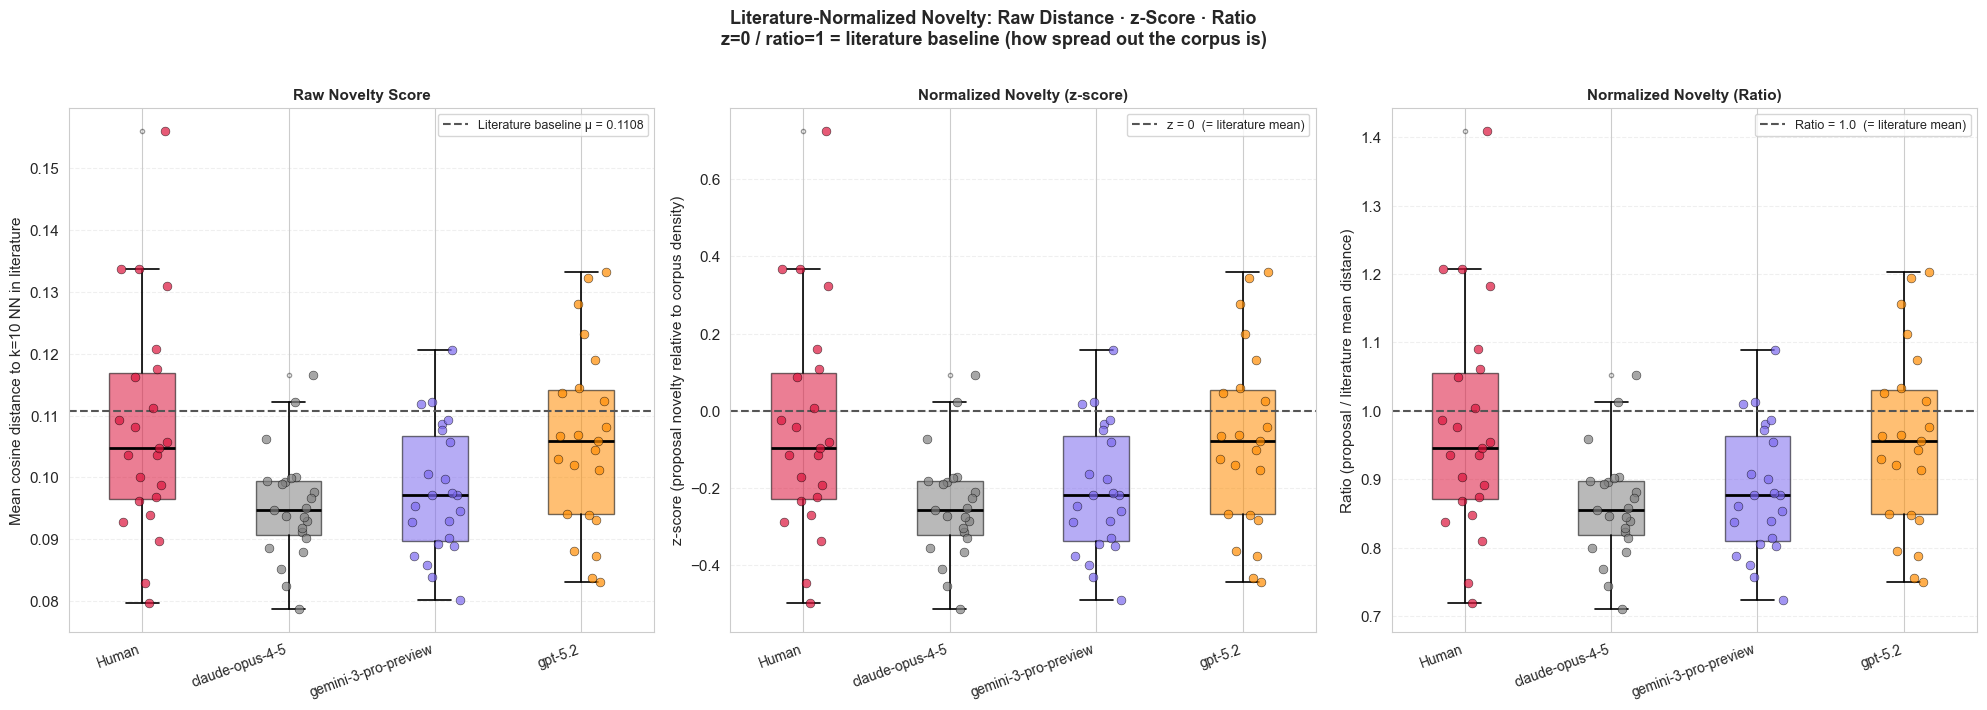


✓ Figure saved to: ../results/figures/rephrased/minimal/novelty_normalized_comparison.png


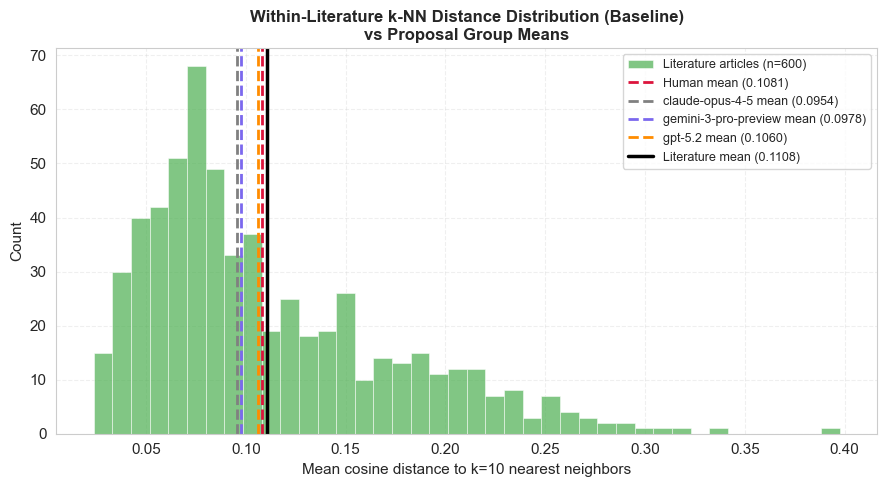

✓ Figure saved to: ../results/figures/rephrased/minimal/novelty_literature_baseline_distribution.png


In [118]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("="*85)
print("VISUALIZING: Raw vs Literature-Normalized Novelty Scores")
print("="*85)

group_order = ['Human'] + [m for m in ai_models if m in model_novelty_scores]

# Build data containers
raw_data   = {g: (human_novelty_scores if g == 'Human' else model_novelty_scores[g])
               for g in group_order}
z_data     = {g: (human_novelty_z      if g == 'Human' else model_novelty_z[g])
               for g in group_order}
ratio_data = {g: (human_novelty_ratio  if g == 'Human' else model_novelty_ratio[g])
               for g in group_order}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    'Literature-Normalized Novelty: Raw Distance · z-Score · Ratio\n'
    'z=0 / ratio=1 = literature baseline (how spread out the corpus is)',
    fontsize=13, fontweight='bold', y=1.01
)

def _boxstrip(ax, data_dict, ylabel, title, ref_line=None, ref_label=None):
    """Box + strip plot for a dict of group→scores."""
    positions = list(range(len(group_order)))
    box_data  = [data_dict[g] for g in group_order]
    grp_colors = [colors.get(g, '#808080') for g in group_order]

    bp = ax.boxplot(box_data, positions=positions, widths=0.45,
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))

    for patch, col in zip(bp['boxes'], grp_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.55)

    for i, (g, col) in enumerate(zip(group_order, grp_colors)):
        jitter = np.random.default_rng(42).uniform(-0.18, 0.18, size=len(data_dict[g]))
        ax.scatter(i + jitter, data_dict[g], color=col,
                   s=40, alpha=0.7, edgecolors='black', linewidths=0.4, zorder=3)

    if ref_line is not None:
        ax.axhline(ref_line, color='#555555', linestyle='--', linewidth=1.5,
                   label=ref_label or f'Baseline = {ref_line}')
        ax.legend(fontsize=9, loc='upper right')

    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, rotation=20, ha='right', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')

_boxstrip(axes[0], raw_data,
          ylabel='Mean cosine distance to k=10 NN in literature',
          title='Raw Novelty Score',
          ref_line=lit_baseline_mean,
          ref_label=f'Literature baseline μ = {lit_baseline_mean:.4f}')

_boxstrip(axes[1], z_data,
          ylabel='z-score (proposal novelty relative to corpus density)',
          title='Normalized Novelty (z-score)',
          ref_line=0.0,
          ref_label='z = 0  (= literature mean)')

_boxstrip(axes[2], ratio_data,
          ylabel='Ratio (proposal / literature mean distance)',
          title='Normalized Novelty (Ratio)',
          ref_line=1.0,
          ref_label='Ratio = 1.0  (= literature mean)')

plt.tight_layout()
out_path = FIGURES_DIR / 'novelty_normalized_comparison.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Figure saved to: {out_path}")

# ── Supplementary: within-literature baseline distribution ───────────────────
fig2, ax = plt.subplots(figsize=(9, 5))
ax.hist(lit_baseline_knn, bins=40, color='#4CAF50', alpha=0.7, edgecolor='white', linewidth=0.5,
        label=f'Literature articles (n={len(lit_baseline_knn)})')

for g in group_order:
    raw_vals = raw_data[g]
    ax.axvline(np.mean(raw_vals), color=colors.get(g, 'grey'), linewidth=2,
               linestyle='--', label=f'{g} mean ({np.mean(raw_vals):.4f})')

ax.axvline(lit_baseline_mean, color='black', linewidth=2.5, linestyle='-',
           label=f'Literature mean ({lit_baseline_mean:.4f})')

ax.set_xlabel('Mean cosine distance to k=10 nearest neighbors', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Within-Literature k-NN Distance Distribution (Baseline)\n'
             'vs Proposal Group Means', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
out_path2 = FIGURES_DIR / 'novelty_literature_baseline_distribution.png'
plt.savefig(out_path2, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to: {out_path2}")
print("="*85)


## Step 5: Statistical Tests for Novelty

Compare novelty scores between groups using statistical tests.

In [119]:
print("="*85)
print("STATISTICAL TESTS: Novelty Scores (All Groups vs Human)")
print("="*85)
print("Primary estimand: mean difference in novelty score (AI - Human).")

comparison_specs = [('All AI', ai_novelty_scores)] + [
    (model, model_novelty_scores[model])
    for model in ai_models
    if model in model_novelty_scores
]

novelty_results = []

for group_name, vals in comparison_specs:
    print()
    print("-"*85)
    print(f"Comparison: {group_name} vs Human")
    print("-"*85)

    res = run_group_comparison(vals, human_novelty_scores, n_permutations=10000, n_boot=5000, random_state=42)
    res['group'] = group_name
    novelty_results.append(res)

    print("Mann-Whitney U Test:")
    print(f"  U-statistic: {res['u_stat']:,.0f}, p-value: {res['p_value_mw']:.4e}")
    print("Cliff's Delta:")
    print(f"  δ = {res['delta']:.4f} ({res['delta_interp']} effect)")
    if res['delta'] > 0:
        print(f"  → {group_name} proposals are MORE novel than human proposals")
    else:
        print(f"  → Human proposals are MORE novel than {group_name} proposals")

    print("Primary mean difference (AI - Human):")
    print(f"  Observed difference: {res['obs_diff_mean']:.4f}")
    print(f"  Bootstrap 95% CI: [{res['ci_low']:.4f}, {res['ci_high']:.4f}]")
    print(f"  Permutation p-value: {res['p_value_perm']:.4f}")

novelty_df = pd.DataFrame(novelty_results)
novelty_df = apply_multiple_testing(novelty_df, p_cols=('p_value_mw', 'p_value_perm'), method='holm')
novelty_comparison_results = novelty_df.to_dict('records')

print()
print("="*85)
print("SUMMARY: Novelty Scores with Holm correction")
print("="*85)
print(f"{'Group':<30} {'δ':<10} {'Mean Diff':<12} {'95% CI':<25} {'MW p':<12} {'MW p(Holm)':<12} {'Perm p(Holm)'}")
print("-"*85)
for _, row in novelty_df.iterrows():
    ci_txt = f"[{row['ci_low']:.4f}, {row['ci_high']:.4f}]"
    print(
        f"{row['group']:<30} {row['delta']:<10.4f} {row['obs_diff_mean']:<12.4f} "
        f"{ci_txt:<25} {row['p_value_mw']:<12.4e} {row['p_value_mw_adj_holm']:<12.4e} {row['p_value_perm_adj_holm']:.4e}"
    )
print("="*85)
print("💡 Positive mean-diff/δ = AI more novel; Negative = Human more novel")


STATISTICAL TESTS: Novelty Scores (All Groups vs Human)
Primary estimand: mean difference in novelty score (AI - Human).

-------------------------------------------------------------------------------------
Comparison: All AI vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 567, p-value: 4.1566e-02
Cliff's Delta:
  δ = -0.2854 (small effect)
  → Human proposals are MORE novel than All AI proposals
Primary mean difference (AI - Human):
  Observed difference: -0.0084
  Bootstrap 95% CI: [-0.0161, -0.0009]
  Permutation p-value: 0.0146

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------
Mann-Whitney U Test:
  U-statistic: 138, p-value: 5.6381e-03
Cliff's Delta:
  δ = -0.4783 (large effect)
  → Human proposals are MORE novel than claude-opus-4-5 proposa

## Step 6: Visualize Novelty Results

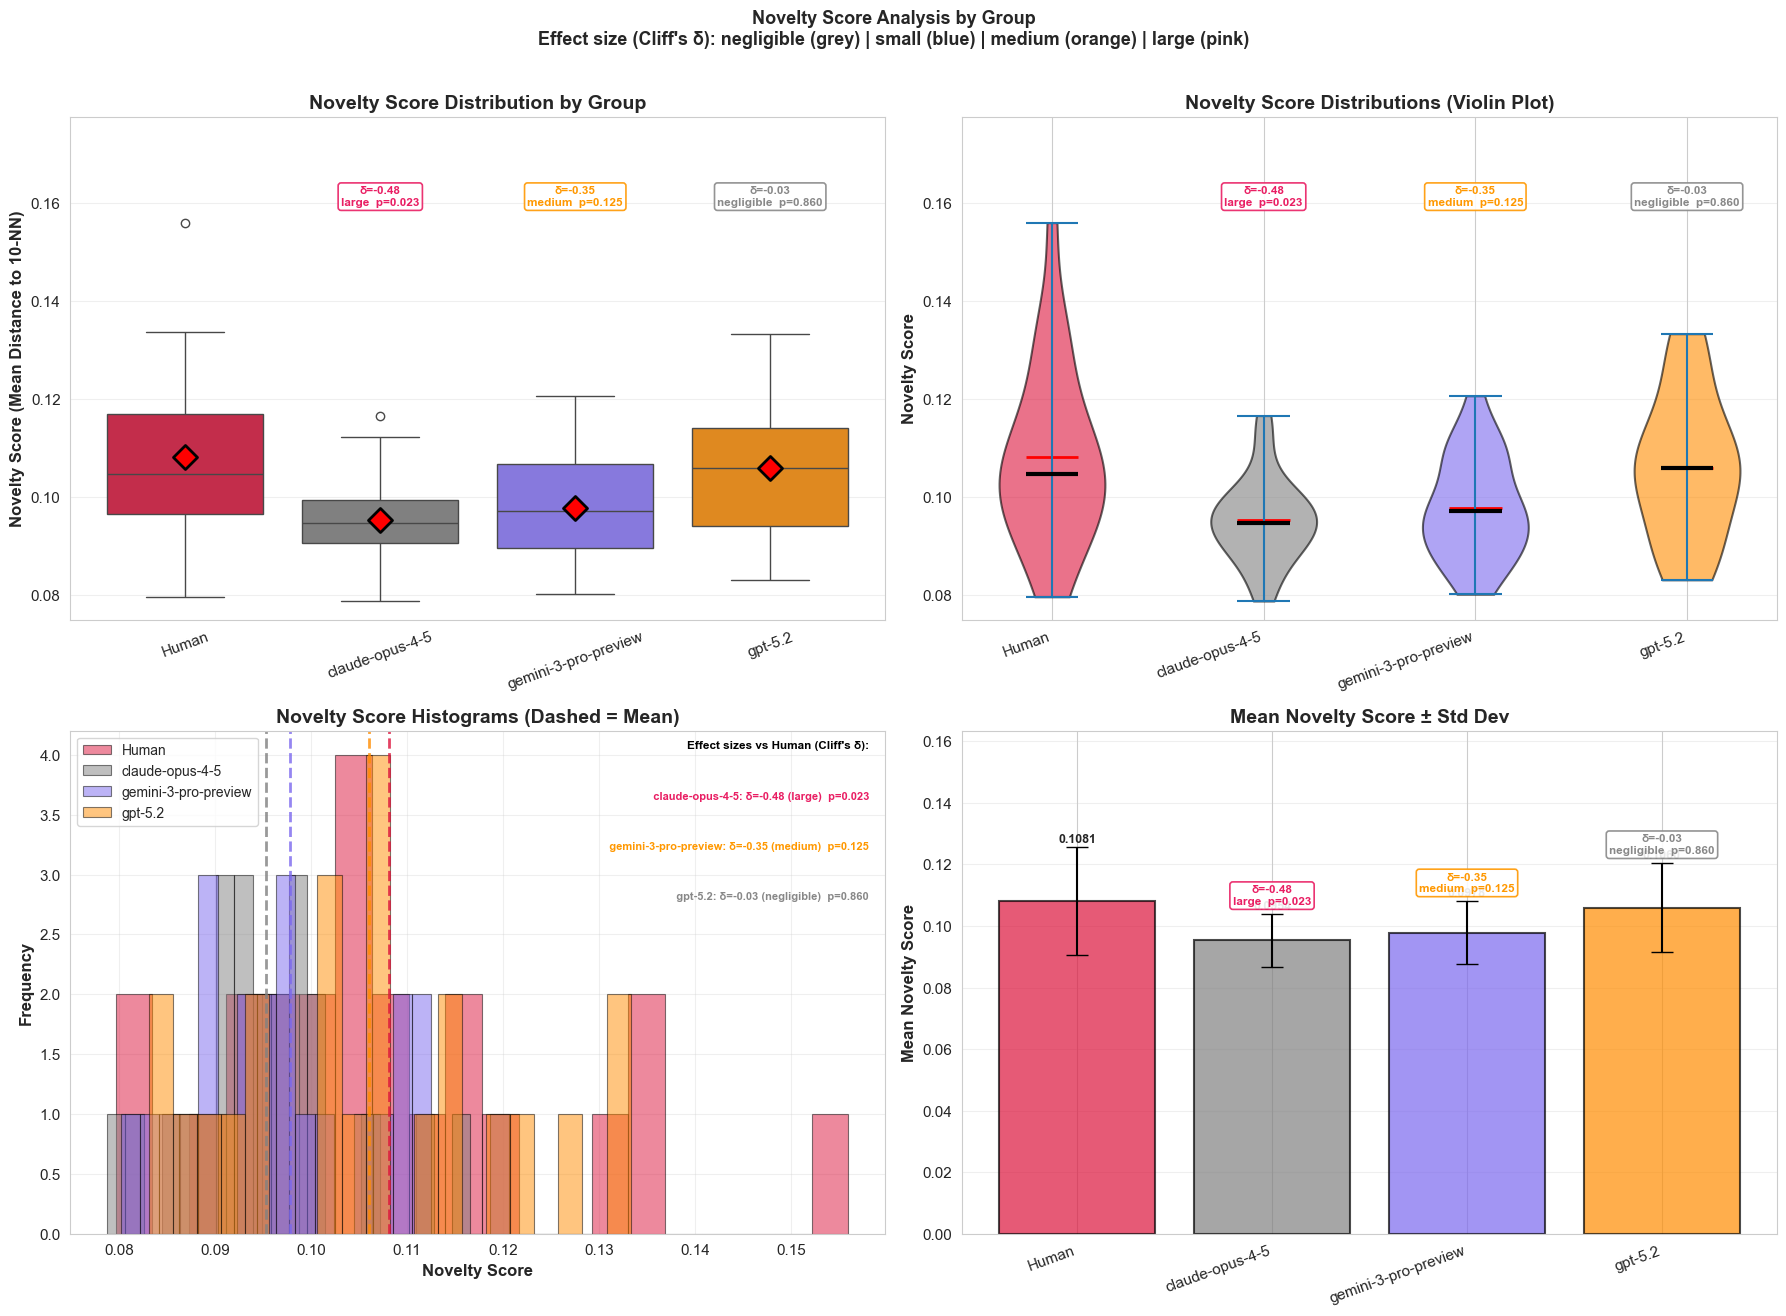


✓ Figure saved to: results/figures/rephrased/novelty_analysis.png


In [176]:
# Visualization: Novelty scores by group
# ── Build effect-size lookup from the stats cell results ──────────────────────
# novelty_comparison_results contains one dict per AI group (vs Human)
# Keys used: 'group', 'delta', 'delta_interp', 'p_value_mw_adj_holm'
_es = {r['group']: r for r in novelty_comparison_results}

_interp_rank = {'negligible': 0, 'small': 1, 'medium': 2, 'large': 3}
_interp_color = {'negligible': '#888888', 'small': '#2196F3',
                 'medium': '#FF9800', 'large': '#E91E63'}

def _es_label(group):
    """Return a two-line annotation string for a group vs Human."""
    if group == 'Human':
        return 'Human\n(reference)'
    r = _es.get(group, {})
    if not r:
        return group
    interp = r.get('delta_interp', '?')
    delta  = r.get('delta', float('nan'))
    p_adj  = r.get('p_value_mw_adj_holm', float('nan'))
    p_str  = f'p={p_adj:.3f}' if p_adj >= 0.001 else 'p<0.001'
    return f'{group}\nδ={delta:+.2f} ({interp})  {p_str}'

def _annotate_effect(ax, idx, group, y_data_top, y_step):
    """Draw a coloured badge above/below a bar or box for the effect size."""
    if group == 'Human':
        return
    r = _es.get(group, {})
    if not r:
        return
    interp = r.get('delta_interp', '?')
    delta  = r.get('delta', float('nan'))
    p_adj  = r.get('p_value_mw_adj_holm', float('nan'))
    p_str  = f'p={p_adj:.3f}' if p_adj >= 0.001 else 'p<0.001'
    badge  = f'δ={delta:+.2f}\n{interp}  {p_str}'
    col    = _interp_color.get(interp, '#555555')
    ax.text(idx, y_data_top + y_step, badge,
            ha='center', va='bottom', fontsize=8.5, color=col, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=col, linewidth=1.2, alpha=0.9))

# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

group_order = ['Human'] + [m for m in ai_models if m in model_novelty_scores]

novelty_data = []
for group in group_order:
    scores = human_novelty_scores if group == 'Human' else model_novelty_scores[group]
    for score in scores:
        novelty_data.append({'Novelty Score': score, 'Group': group})

novelty_df = pd.DataFrame(novelty_data)
palette_list = [colors.get(g, 'gray') for g in group_order]

# ── PANEL 1: Box plots ────────────────────────────────────────────────────────
ax1 = axes[0, 0]
sns.boxplot(data=novelty_df, x='Group', y='Novelty Score', ax=ax1,
            palette=palette_list, order=group_order)
ax1.set_ylabel('Novelty Score (Mean Distance to 10-NN)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax1.set_title('Novelty Score Distribution by Group', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.grid(alpha=0.3, axis='y')

# Mean markers
for idx, group in enumerate(group_order):
    mv = (human_novelty_scores if group == 'Human' else model_novelty_scores[group]).mean()
    ax1.scatter(idx, mv, color='red', s=150, marker='D', zorder=10,
                edgecolors='black', linewidth=2)

# Effect-size badges above each box
y_top1 = novelty_df['Novelty Score'].max()
y_step1 = (y_top1 - novelty_df['Novelty Score'].min()) * 0.04
for idx, group in enumerate(group_order):
    _annotate_effect(ax1, idx, group, y_top1, y_step1)
ax1.set_ylim(top=y_top1 + y_step1 * 7)

# ── PANEL 2: Violin plots ─────────────────────────────────────────────────────
ax2 = axes[0, 1]
parts = ax2.violinplot(
    [novelty_df[novelty_df['Group'] == g]['Novelty Score'].values for g in group_order],
    positions=range(len(group_order)),
    showmeans=True, showmedians=True, showextrema=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(palette_list[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)
parts['cmedians'].set_edgecolor('black')
parts['cmedians'].set_linewidth(3)
parts['cmeans'].set_edgecolor('red')
parts['cmeans'].set_linewidth(2)

ax2.set_xticks(range(len(group_order)))
ax2.set_xticklabels(group_order, rotation=20, ha='right', fontsize=11)
ax2.set_ylabel('Novelty Score', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
ax2.set_title('Novelty Score Distributions (Violin Plot)', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

y_top2 = novelty_df['Novelty Score'].max()
y_step2 = (y_top2 - novelty_df['Novelty Score'].min()) * 0.04
for idx, group in enumerate(group_order):
    _annotate_effect(ax2, idx, group, y_top2, y_step2)
ax2.set_ylim(top=y_top2 + y_step2 * 7)

# ── PANEL 3: Histograms ───────────────────────────────────────────────────────
ax3 = axes[1, 0]
for group in group_order:
    scores = human_novelty_scores if group == 'Human' else model_novelty_scores[group]
    ax3.hist(scores, bins=20, alpha=0.5, label=group,
             color=colors.get(group, 'gray'), edgecolor='black', linewidth=0.8)
    ax3.axvline(scores.mean(), color=colors.get(group, 'gray'),
                linestyle='--', linewidth=2, alpha=0.8)

ax3.set_xlabel('Novelty Score', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Novelty Score Histograms (Dashed = Mean)', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# Effect-size legend panel inside the histogram
legend_lines = ['Effect sizes vs Human (Cliff\'s δ):']
for group in group_order:
    if group == 'Human':
        continue
    r = _es.get(group, {})
    interp = r.get('delta_interp', '?')
    delta  = r.get('delta', float('nan'))
    p_adj  = r.get('p_value_mw_adj_holm', float('nan'))
    p_str  = f'p={p_adj:.3f}' if p_adj >= 0.001 else 'p<0.001'
    col    = _interp_color.get(interp, '#555555')
    legend_lines.append((f'  {group}: δ={delta:+.2f} ({interp})  {p_str}', col))

y_txt = 0.98
ax3.text(0.98, y_txt, legend_lines[0], transform=ax3.transAxes,
         fontsize=8.5, fontweight='bold', va='top', ha='right',
         color='black')
for line, col in legend_lines[1:]:
    y_txt -= 0.10
    ax3.text(0.98, y_txt, line, transform=ax3.transAxes,
             fontsize=8, va='top', ha='right', color=col, fontweight='bold')

# ── PANEL 4: Bar chart with error bars ───────────────────────────────────────
ax4 = axes[1, 1]
means, stds = [], []
for group in group_order:
    scores = human_novelty_scores if group == 'Human' else model_novelty_scores[group]
    means.append(scores.mean())
    stds.append(scores.std())

ax4.bar(range(len(group_order)), means, yerr=stds,
        color=[colors.get(g, 'gray') for g in group_order],
        edgecolor='black', linewidth=1.5, alpha=0.7, capsize=8)
ax4.set_xticks(range(len(group_order)))
ax4.set_xticklabels(group_order, rotation=20, ha='right', fontsize=11)
ax4.set_ylabel('Mean Novelty Score', fontsize=12, fontweight='bold')
ax4.set_xlabel('')
ax4.set_title('Mean Novelty Score ± Std Dev', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3, axis='y')

# Value label + effect-size badge above each bar
for i, (mv, sv) in enumerate(zip(means, stds)):
    group = group_order[i]
    ax4.text(i, mv + sv + 0.0005, f'{mv:.4f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
    _annotate_effect(ax4, i, group, mv + sv + 0.002,
                     (max(means) - min(means)) * 0.04)

ax4.set_ylim(top=max(m + s for m, s in zip(means, stds)) * 1.30)

plt.suptitle('Novelty Score Analysis by Group\n'
             'Effect size (Cliff\'s δ): '
             'negligible (grey) | small (blue) | medium (orange) | large (pink)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'novelty_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/rephrased/novelty_analysis.png")

## Step 7: Proposals in Literature Embedding Space

Visualize proposals and literature in a shared 2D embedding space. UMAP is fit on literature only; proposals are then projected into that coordinate system. Literature articles shown as gray dots; proposals colored by group.

VISUALIZING PROPOSALS IN LITERATURE EMBEDDING SPACE

Fitting UMAP on literature corpus...
Projecting proposals into literature space...
✓ Literature: 600 points  |  Proposals: 92 points


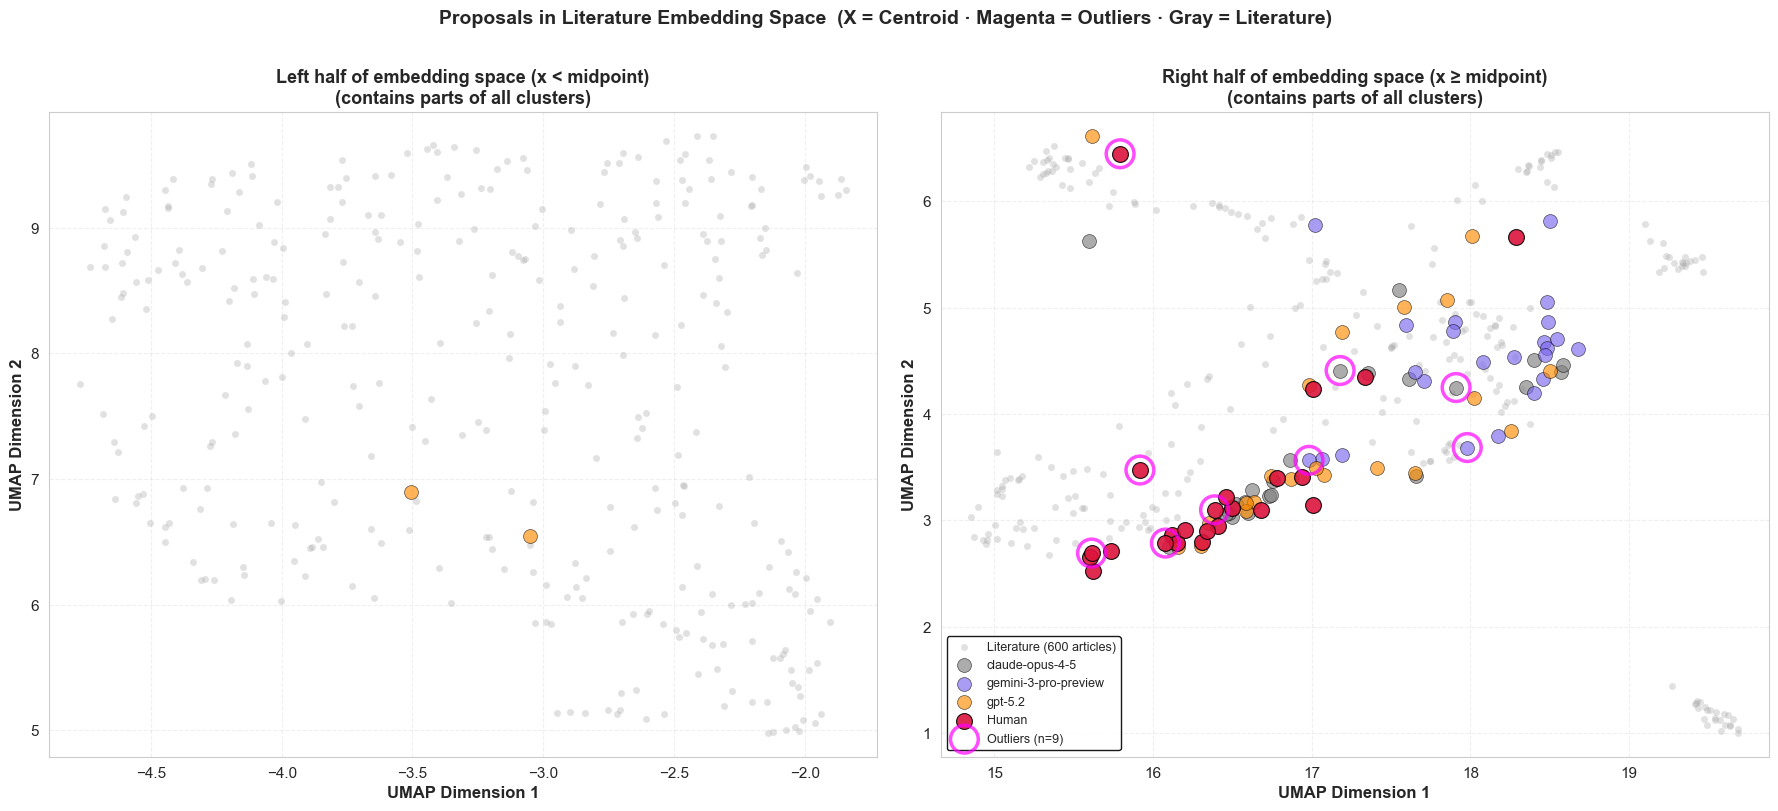


✓ Figure saved to: ../results/figures/rephrased/minimal/proposals_in_literature_space.png


In [121]:
import umap

print("="*85)
print("VISUALIZING PROPOSALS IN LITERATURE EMBEDDING SPACE")
print("="*85)

# Build aligned AI model labels
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("⚠️ Falling back to ai_df['model'] order.")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings.")

ai_models_nov = sorted(list(dict.fromkeys(ai_model_labels)))
n_human_abs   = len(human_embeddings_abstract)
n_ai_abs      = len(ai_embeddings_abstract)

# Fit UMAP on literature only; transform proposals into that space
print("\nFitting UMAP on literature corpus...")
reducer_nov = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)
literature_2d_nov = reducer_nov.fit_transform(literature_embeddings)

print("Projecting proposals into literature space...")
proposals_stacked = np.vstack([human_embeddings_abstract, ai_embeddings_abstract])
proposals_2d_nov  = reducer_nov.transform(proposals_stacked)

human_2d_nov = proposals_2d_nov[:n_human_abs]
ai_2d_nov    = proposals_2d_nov[n_human_abs:]
ai_model_arr = np.array(ai_model_labels)

print(f"✓ Literature: {len(literature_2d_nov)} points  |  Proposals: {len(proposals_2d_nov)} points")

# ── Compute tight bounding boxes for each cluster ────────────────────────────
pad = 0.08  # 8% padding around each cluster

def _bounds(pts, pad_frac):
    xmin, xmax = pts[:, 0].min(), pts[:, 0].max()
    ymin, ymax = pts[:, 1].min(), pts[:, 1].max()
    xp = (xmax - xmin) * pad_frac
    yp = (ymax - ymin) * pad_frac
    return xmin - xp, xmax + xp, ymin - yp, ymax + yp

lit_bounds  = _bounds(literature_2d_nov, pad)
prop_bounds = _bounds(proposals_2d_nov,  pad)

# ── Shared scatter helper ─────────────────────────────────────────────────────
def _draw_all(ax, legend=False):
    ax.scatter(literature_2d_nov[:, 0], literature_2d_nov[:, 1],
               c='#AAAAAA', s=25, alpha=0.35, linewidths=0,
               label=f'Literature ({len(literature_embeddings)} articles)', zorder=1)

    for model in ai_models_nov:
        mask = ai_model_arr == model
        pts  = ai_2d_nov[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'), label=model,
                   s=100, alpha=0.65, edgecolors='black', linewidth=0.5, zorder=3)

    ax.scatter(human_2d_nov[:, 0], human_2d_nov[:, 1],
               c=colors['Human'], label='Human',
               s=130, alpha=0.9, edgecolors='black', linewidth=0.8,
               marker='o', zorder=5)

    if 'outliers' in globals():
        outlier_coords_nov = proposals_2d_nov[outliers]
        ax.scatter(outlier_coords_nov[:, 0], outlier_coords_nov[:, 1],
                   s=400, facecolors='none', edgecolors='magenta',
                   linewidth=2.5, alpha=0.7,
                   label=f'Outliers (n={outliers.sum()})', zorder=8)

    ax.grid(True, alpha=0.3, linestyle='--')
    if legend:
        ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax_lit, ax_prop) = plt.subplots(1, 2, figsize=(18, 8))

_draw_all(ax_lit)
_draw_all(ax_prop, legend=True)

ax_lit.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax_lit.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax_lit.set_title('Left half of embedding space (x < midpoint)\n(contains parts of all clusters)',
                 fontsize=13, fontweight='bold')

ax_prop.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax_prop.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax_prop.set_title('Right half of embedding space (x ≥ midpoint)\n(contains parts of all clusters)',
                  fontsize=13, fontweight='bold')

fig.suptitle('Proposals in Literature Embedding Space  (X = Centroid · Magenta = Outliers · Gray = Literature)',
             fontsize=14, fontweight='bold', y=1.01)

# tight_layout first, THEN set limits — so layout engine cannot override them
plt.tight_layout()

# Split the SAME embedding canvas into left vs right halves
all_pts = np.vstack([literature_2d_nov, proposals_2d_nov])
x_all = all_pts[:, 0]
y_all = all_pts[:, 1]

# Midpoint split (keeps left vs right halves of the canvas)
xsplit = (x_all.min() + x_all.max()) / 2

# Zoom each panel to the points that fall into its half (plus padding)
zoom_pad = 0.04  # smaller = tighter zoom

def _zoom_to(ax, mask):
    pts = all_pts[mask]
    if len(pts) == 0:
        return
    xmin, xmax = pts[:, 0].min(), pts[:, 0].max()
    ymin, ymax = pts[:, 1].min(), pts[:, 1].max()
    xp = (xmax - xmin) * zoom_pad
    yp = (ymax - ymin) * zoom_pad
    ax.set_xlim(xmin - xp, xmax + xp)
    ax.set_ylim(ymin - yp, ymax + yp)

left_mask  = x_all < xsplit
right_mask = ~left_mask

_zoom_to(ax_lit, left_mask)
_zoom_to(ax_prop, right_mask)

out_path = FIGURES_DIR / 'proposals_in_literature_space.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Figure saved to: {out_path}")
print("="*85)


VISUALIZING PROPOSALS IN LITERATURE SPACE — Literature Colored by Publication Year
  ≤ 2009: 25 articles
  2010–2014: 35 articles
  2015–2018: 81 articles
  2019–2021: 143 articles
  2022–2024: 251 articles
  2025+: 65 articles


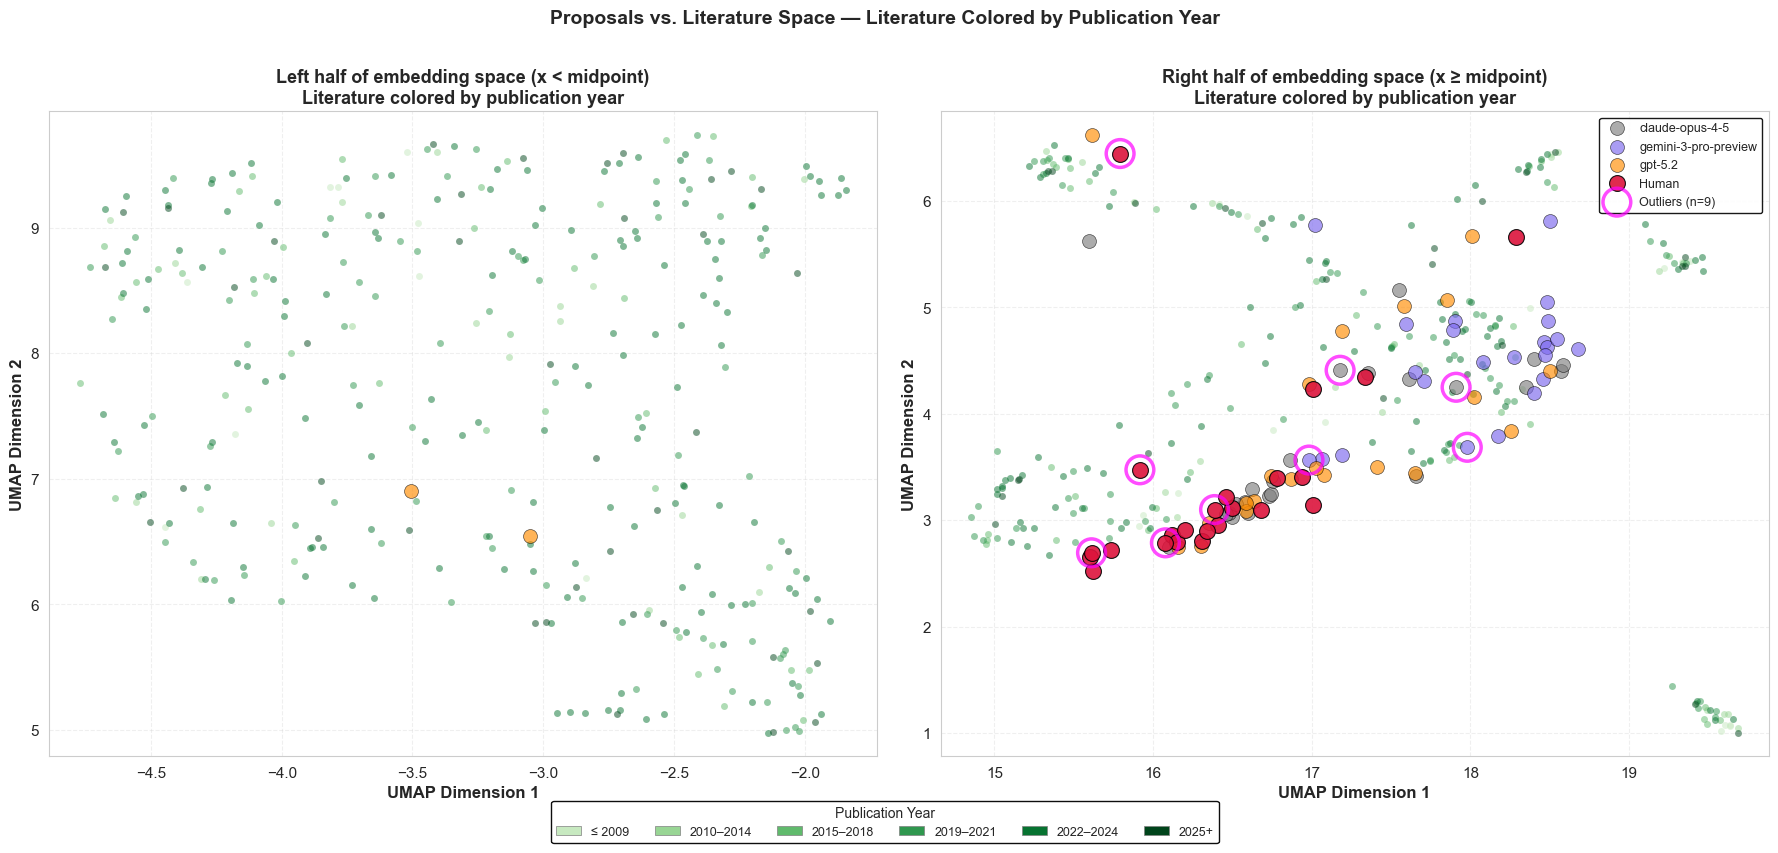


✓ Figure saved to: ../results/figures/rephrased/minimal/proposals_in_literature_space_by_year.png


In [122]:
# ── Proposals in Literature Space: Literature colored by publication year ─────
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

print("="*85)
print("VISUALIZING PROPOSALS IN LITERATURE SPACE — Literature Colored by Publication Year")
print("="*85)

# ── Extract publication year from each article ────────────────────────────────
def _parse_year(date_str):
    """Extract 4-digit year from PubMed publication_date string."""
    m = re.search(r'\b(\d{4})\b', str(date_str))
    return int(m.group(1)) if m else None

lit_years = [_parse_year(a.get('publication_date', '')) for a in articles]

# ── Define year buckets ───────────────────────────────────────────────────────
# Buckets: ≤2009 | 2010–2014 | 2015–2018 | 2019–2021 | 2022–2024 | 2025+
BUCKETS = [
    (None, 2009, "≤ 2009"),
    (2010, 2014, "2010–2014"),
    (2015, 2018, "2015–2018"),
    (2019, 2021, "2019–2021"),
    (2022, 2024, "2022–2024"),
    (2025, None, "2025+"),
]
n_buckets = len(BUCKETS)

def _bucket_idx(year):
    if year is None:
        return 0  # oldest bucket if unknown
    for i, (lo, hi, _) in enumerate(BUCKETS):
        if (lo is None or year >= lo) and (hi is None or year <= hi):
            return i
    return n_buckets - 1

bucket_indices = np.array([_bucket_idx(y) for y in lit_years])

# Bucket counts for info
for i, (lo, hi, lbl) in enumerate(BUCKETS):
    n = (bucket_indices == i).sum()
    print(f"  {lbl}: {n} articles")

# ── Green colormap: faintest=oldest, darkest/brightest=newest ─────────────────
# Use a perceptually uniform green gradient (light → dark)
green_cmap = plt.cm.Greens  # low=light, high=dark
# Map bucket index to [0.25, 1.0] so oldest is still visible (not white)
bucket_colors = [green_cmap(0.25 + 0.75 * i / (n_buckets - 1)) for i in range(n_buckets)]

# ── Reuse UMAP projection from previous cell ─────────────────────────────────
required = ['literature_2d_nov', 'proposals_2d_nov', 'human_2d_nov', 'ai_2d_nov',
            'lit_bounds', 'prop_bounds', 'ai_model_arr', 'ai_models_nov']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing variables from previous cell: {missing}. Run the UMAP cell first.")

# ── Shared draw helper ────────────────────────────────────────────────────────
def _draw_year(ax, legend=False):
    # Literature: plot oldest→newest so newest dots are on top
    for i in range(n_buckets):
        mask = bucket_indices == i
        if mask.any():
            ax.scatter(literature_2d_nov[mask, 0], literature_2d_nov[mask, 1],
                       c=[bucket_colors[i]], s=25, alpha=0.5, linewidths=0,
                       zorder=1 + i)

    # AI proposals (model colors)
    for model in ai_models_nov:
        mask = ai_model_arr == model
        pts  = ai_2d_nov[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'), label=model,
                   s=100, alpha=0.65, edgecolors='black', linewidth=0.5, zorder=20)

    # Human proposals
    ax.scatter(human_2d_nov[:, 0], human_2d_nov[:, 1],
               c=colors['Human'], label='Human',
               s=130, alpha=0.9, edgecolors='black', linewidth=0.8,
               marker='o', zorder=22)

    # Outlier rings
    if 'outliers' in globals():
        outlier_coords = proposals_2d_nov[outliers]
        ax.scatter(outlier_coords[:, 0], outlier_coords[:, 1],
                   s=400, facecolors='none', edgecolors='magenta',
                   linewidth=2.5, alpha=0.7,
                   label=f'Outliers (n={outliers.sum()})', zorder=25)

    ax.grid(True, alpha=0.3, linestyle='--')

    if legend:
        # Proposal legend
        ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax_lit, ax_prop) = plt.subplots(1, 2, figsize=(18, 8))

_draw_year(ax_lit)
_draw_year(ax_prop, legend=True)

ax_lit.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax_lit.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax_lit.set_title('Left half of embedding space (x < midpoint)\nLiterature colored by publication year',
                 fontsize=13, fontweight='bold')

ax_prop.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax_prop.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax_prop.set_title('Right half of embedding space (x ≥ midpoint)\nLiterature colored by publication year',
                  fontsize=13, fontweight='bold')

fig.suptitle('Proposals vs. Literature Space — Literature Colored by Publication Year',
             fontsize=14, fontweight='bold', y=1.01)

# ── Year legend (green gradient) as a separate inset ─────────────────────────
year_handles = [mpatches.Patch(facecolor=bucket_colors[i],
                               edgecolor='grey', linewidth=0.5,
                               label=BUCKETS[i][2])
                for i in range(n_buckets)]
fig.legend(handles=year_handles,
           title='Publication Year', title_fontsize=10,
           fontsize=9, loc='lower center', ncol=n_buckets,
           framealpha=0.95, edgecolor='black',
           bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()

# Split the SAME embedding canvas into left vs right halves, then zoom each panel
all_pts = np.vstack([literature_2d_nov, proposals_2d_nov])
x_all = all_pts[:, 0]

xsplit = (x_all.min() + x_all.max()) / 2
zoom_pad = 0.04  # smaller = tighter zoom

def _zoom_to(ax, mask):
    pts = all_pts[mask]
    if len(pts) == 0:
        return
    xmin, xmax = pts[:, 0].min(), pts[:, 0].max()
    ymin, ymax = pts[:, 1].min(), pts[:, 1].max()
    xp = (xmax - xmin) * zoom_pad
    yp = (ymax - ymin) * zoom_pad
    ax.set_xlim(xmin - xp, xmax + xp)
    ax.set_ylim(ymin - yp, ymax + yp)

left_mask  = x_all < xsplit
right_mask = ~left_mask

_zoom_to(ax_lit, left_mask)
_zoom_to(ax_prop, right_mask)

out_path = FIGURES_DIR / 'proposals_in_literature_space_by_year.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Figure saved to: {out_path}")
print("="*85)


## Additional Analysis: Examine Nearest Neighbors in Literature

For the most and least novel proposals, identify which literature articles are closest.

In [123]:
# Examine most and least novel proposals
print("="*85)
print("EXAMINING MOST AND LEAST NOVEL PROPOSALS")
print("="*85)

# Find most novel human proposal
most_novel_human_idx = human_novelty_scores.argmax()
most_novel_human_score = human_novelty_scores[most_novel_human_idx]
most_novel_human_title = human_df.iloc[most_novel_human_idx]['proposal_title']

print(f"\n🏆 MOST NOVEL HUMAN PROPOSAL:")
print(f"  Title: {most_novel_human_title}")
print(f"  Novelty Score: {most_novel_human_score:.4f}")
print(f"  Nearest neighbors in literature:")
for j, lit_idx in enumerate(human_nn_indices[most_novel_human_idx][:5]):
    lit_article = articles[lit_idx]
    dist = cosine_distances([human_embeddings_abstract[most_novel_human_idx]], [literature_embeddings[lit_idx]])[0][0]
    print(f"    {j+1}. [{lit_article['pmid']}] {lit_article['title'][:80]}...")
    print(f"       Distance: {dist:.4f}, Published: {lit_article['publication_date']}")

# Find least novel human proposal
least_novel_human_idx = human_novelty_scores.argmin()
least_novel_human_score = human_novelty_scores[least_novel_human_idx]
least_novel_human_title = human_df.iloc[least_novel_human_idx]['proposal_title']

print(f"\n📚 LEAST NOVEL HUMAN PROPOSAL:")
print(f"  Title: {least_novel_human_title}")
print(f"  Novelty Score: {least_novel_human_score:.4f}")
print(f"  Nearest neighbors in literature:")
for j, lit_idx in enumerate(human_nn_indices[least_novel_human_idx][:5]):
    lit_article = articles[lit_idx]
    dist = cosine_distances([human_embeddings_abstract[least_novel_human_idx]], [literature_embeddings[lit_idx]])[0][0]
    print(f"    {j+1}. [{lit_article['pmid']}] {lit_article['title'][:80]}...")
    print(f"       Distance: {dist:.4f}, Published: {lit_article['publication_date']}")

# Find most novel AI proposal
most_novel_ai_idx = ai_novelty_scores.argmax()
most_novel_ai_score = ai_novelty_scores[most_novel_ai_idx]
most_novel_ai_title = ai_df.iloc[most_novel_ai_idx]['title']
most_novel_ai_model = ai_df.iloc[most_novel_ai_idx]['model']

print(f"\n🏆 MOST NOVEL AI PROPOSAL:")
print(f"  Model: {most_novel_ai_model}")
print(f"  Title: {most_novel_ai_title}")
print(f"  Novelty Score: {most_novel_ai_score:.4f}")
print(f"  Nearest neighbors in literature:")
for j, lit_idx in enumerate(ai_nn_indices[most_novel_ai_idx][:5]):
    lit_article = articles[lit_idx]
    dist = cosine_distances([ai_embeddings_abstract[most_novel_ai_idx]], [literature_embeddings[lit_idx]])[0][0]
    print(f"    {j+1}. [{lit_article['pmid']}] {lit_article['title'][:80]}...")
    print(f"       Distance: {dist:.4f}, Published: {lit_article['publication_date']}")

# Find least novel AI proposal
least_novel_ai_idx = ai_novelty_scores.argmin()
least_novel_ai_score = ai_novelty_scores[least_novel_ai_idx]
least_novel_ai_title = ai_df.iloc[least_novel_ai_idx]['title']
least_novel_ai_model = ai_df.iloc[least_novel_ai_idx]['model']

print(f"\n📚 LEAST NOVEL AI PROPOSAL:")
print(f"  Model: {least_novel_ai_model}")
print(f"  Title: {least_novel_ai_title}")
print(f"  Novelty Score: {least_novel_ai_score:.4f}")
print(f"  Nearest neighbors in literature:")
for j, lit_idx in enumerate(ai_nn_indices[least_novel_ai_idx][:5]):
    lit_article = articles[lit_idx]
    dist = cosine_distances([ai_embeddings_abstract[least_novel_ai_idx]], [literature_embeddings[lit_idx]])[0][0]
    print(f"    {j+1}. [{lit_article['pmid']}] {lit_article['title'][:80]}...")
    print(f"       Distance: {dist:.4f}, Published: {lit_article['publication_date']}")

print("="*85)

EXAMINING MOST AND LEAST NOVEL PROPOSALS

🏆 MOST NOVEL HUMAN PROPOSAL:
  Title: Impact of Heat Wave Stress on Cytokinetic Bottlenecks in Cellular Division
  Novelty Score: 0.1560
  Nearest neighbors in literature:
    1. [25366827] Live-cell imaging of cyanobacteria....
       Distance: 0.1406, Published: 2015
    2. [33536648] Function and regulation of the divisome for mitochondrial fission....
       Distance: 0.1545, Published: 2021
    3. [36977834] Mechanisms underlying spindle assembly and robustness....
       Distance: 0.1569, Published: 2023 Aug
    4. [26646497] Proteostasis and aging....
       Distance: 0.1573, Published: 2015
    5. [33421755] Nuclear envelope remodelling during mitosis....
       Distance: 0.1574, Published: 2021 Jun

📚 LEAST NOVEL HUMAN PROPOSAL:
  Title: Integrated Transfer Learning for Mesoscale Organization Principles via Image Data and Biophysical Simulations
  Novelty Score: 0.0797
  Nearest neighbors in literature:
    1. [32413324] Art and Scienc

In [124]:
# Save: novelty scores from literature-based analysis (cells 47-49)
# Run this immediately after the novelty score computation cells.
import pandas as pd, numpy as np
from pathlib import Path

out_dir = TABLES_DIR
out_dir.mkdir(parents=True, exist_ok=True)

# human_df and ai_df must be in scope from data loading cells.
# Use enumerate (not iterrows index) so array subscripts are always 0-based —
# iterrows() yields the DataFrame index which may be non-contiguous if rows
# were dropped or filtered before this cell runs.
rows = []
for arr_i, (_, row) in enumerate(human_df.iterrows()):
    rows.append({
        'title':         row['proposal_title'],
        'group':         'Human',
        'raw_novelty':   float(human_novelty_scores[arr_i]),
        'novelty_z':     float(human_novelty_z[arr_i]),
        'novelty_ratio': float(human_novelty_ratio[arr_i]),
    })
for arr_i, (_, row) in enumerate(ai_df.iterrows()):
    rows.append({
        'title':         row['title'],
        'group':         row['model'],
        'raw_novelty':   float(ai_novelty_scores[arr_i]),
        'novelty_z':     float(ai_novelty_z[arr_i]),
        'novelty_ratio': float(ai_novelty_ratio[arr_i]),
    })

nov_df = pd.DataFrame(rows)
# Top-10% by raw novelty = "most novel vs literature"
thresh_raw   = np.percentile(nov_df['raw_novelty'],   90)
thresh_z     = np.percentile(nov_df['novelty_z'],     90)
thresh_ratio = np.percentile(nov_df['novelty_ratio'], 90)
nov_df['is_most_novel_raw']   = nov_df['raw_novelty']   >= thresh_raw
nov_df['is_most_novel_z']     = nov_df['novelty_z']     >= thresh_z
nov_df['is_most_novel_ratio'] = nov_df['novelty_ratio'] >= thresh_ratio

nov_df.to_csv(out_dir / 'novelty_scores_from_literature.csv', index=False)
print(f"Saved novelty_scores_from_literature.csv  ({len(nov_df)} rows)")
print(f"  Threshold (raw):   {thresh_raw:.4f}  →  {nov_df['is_most_novel_raw'].sum()} most-novel proposals")
print(f"  Threshold (z):     {thresh_z:.4f}")
print(f"  Threshold (ratio): {thresh_ratio:.4f}")
print("\nTop 10% most novel proposals:")
print(nov_df[nov_df['is_most_novel_raw']][['title','group','raw_novelty','novelty_z']].sort_values('raw_novelty', ascending=False).to_string(index=False))


Saved novelty_scores_from_literature.csv  (92 rows)
  Threshold (raw):   0.1205  →  10 most-novel proposals
  Threshold (z):     0.1557
  Threshold (ratio): 1.0878

Top 10% most novel proposals:
                                                                                                                              title                group  raw_novelty  novelty_z
                                                         Impact of Heat Wave Stress on Cytokinetic Bottlenecks in Cellular Division                Human     0.155977   0.723718
                   Integrative Multi-Omics Synthesis for the Identification of Shared Molecular Mechanisms in Mammalian Hibernation                Human     0.133709   0.367249
                                       Evolutionary Origins of Complex Protein Topologies from Knotted Structures to Pierced Lassos                Human     0.133661   0.366472
   Integration of Spatial Proteomics, Metabolomics, and Enzyme Complex Data for Mapping Mesoscale

# PART III: THEMATIC AND CLUSTER ANALYSIS

Examine whether human and AI proposals cluster in distinct semantic regions and differ in thematic coverage.

**⚠️ Sample Size Note:** With n=23 human and n=69 AI proposals, we use conservative approaches with strong regularization and permutation-based validation.

## Analysis 3.1: Topic Modeling (LDA - Exploratory)

Use Latent Dirichlet Allocation with strong priors to identify thematic topics. LDA is more stable than BERTopic for small samples.

In [125]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

print("="*85)
print("TOPIC MODELING WITH LDA (EXPLORATORY)")
print("="*85)
print("Using normalized CONTENT text (title + abstract) to reduce formatting/template confounding.")

def _normalize_topic_text(text):
    text = str(text or "")
    text = re.sub(r'\b(title|abstract|background|methods?|research questions?|outcomes?|open science|budget)\s*:', ' ', text, flags=re.I)
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

def _build_topic_text(row, is_ai=True):
    if is_ai:
        title = row.get('title', '')
        abstract = row.get('abstract', '')
    else:
        title = row.get('proposal_title', row.get('title', ''))
        abstract = row.get('abstract', '')
    return _normalize_topic_text(f"{title}. {abstract}")

ai_abstracts = [_build_topic_text(row, is_ai=True) for _, row in ai_df.iterrows()]
human_abstracts = [_build_topic_text(row, is_ai=False) for _, row in human_df.iterrows()]
all_abstracts = human_abstracts + ai_abstracts

source_labels = ['Human'] * len(human_abstracts) + ['AI'] * len(ai_abstracts)
model_labels = ['Human'] * len(human_abstracts) + ai_df['model'].tolist()

print()
print(f"✓ Prepared {len(all_abstracts)} topic-model texts")
print(f"  Human: {len(human_abstracts)}, AI: {len(ai_abstracts)}")

_unigram_probe = CountVectorizer(stop_words='english', ngram_range=(1, 1), min_df=2, max_df=1.0, max_features=5000)
_unigram_X = _unigram_probe.fit_transform(all_abstracts)
_unigram_terms = _unigram_probe.get_feature_names_out()
_unigram_df = np.asarray((_unigram_X > 0).mean(axis=0)).ravel()

auto_domain_unigram_stopwords = set(_unigram_terms[_unigram_df >= 0.50])
manual_domain_unigram_stopwords = {
    'cell', 'cells', 'protein', 'proteins',
    'title', 'abstract', 'project', 'proposal', 'outcomes',
    'background', 'method', 'methods',
    'using', 'nup', '000', 'nan', 'fg', 'npc', 'ii', 'et'
}
domain_unigram_stopwords = auto_domain_unigram_stopwords | manual_domain_unigram_stopwords

_top_common_idx = np.argsort(_unigram_df)[-20:][::-1]
print()
print("Most common unigrams in corpus (doc frequency):")
for i in _top_common_idx:
    print(f"  {_unigram_terms[i]}: {_unigram_df[i]:.2f}")
print()
print(f"✓ Domain unigram stopwords (auto+manual): {len(domain_unigram_stopwords)}")

print()
print("Creating document-term matrix...")
vectorizer = CountVectorizer(max_features=2000, min_df=2, max_df=0.7, stop_words='english', ngram_range=(1, 2))
_doc_term_matrix_full = vectorizer.fit_transform(all_abstracts)
_feature_names_full = np.array(vectorizer.get_feature_names_out())

_unigram_mask = np.array([' ' not in t for t in _feature_names_full])
_drop_mask = _unigram_mask & np.isin(_feature_names_full, list(domain_unigram_stopwords))
_keep_mask = ~_drop_mask

doc_term_matrix = _doc_term_matrix_full[:, _keep_mask]
feature_names = _feature_names_full[_keep_mask]

print(f"✓ Document-term matrix: {doc_term_matrix.shape}")
print(f"  Documents: {doc_term_matrix.shape[0]}, Vocabulary: {doc_term_matrix.shape[1]}")
print(f"  Dropped domain unigrams: {_drop_mask.sum()} (kept bigrams intact)")

print()
print("Fitting LDA with conservative parameters...")
print("  n_topics=5, alpha=0.5, beta=0.5 (strong regularization)")

n_topics = 3
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    doc_topic_prior=0.5,
    topic_word_prior=0.5,
    max_iter=100,
    learning_method='batch',
    random_state=42,
    n_jobs=-1
)
doc_topic_dist = lda_model.fit_transform(doc_term_matrix)

print("✓ LDA fitted")
print(f"  Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print(f"  Log-likelihood: {lda_model.score(doc_term_matrix):.2f}")

def display_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics.append(top_words)
    return topics

topics = display_topics(lda_model, feature_names, n_top_words=10)

print()
print("="*85)
print("TOP 10 WORDS PER TOPIC")
print("="*85)
for i, topic_words in enumerate(topics):
    print()
    print(f"Topic {i+1}: {', '.join(topic_words)}")

doc_topic_df = pd.DataFrame(doc_topic_dist, columns=[f'Topic_{i+1}' for i in range(n_topics)])
doc_topic_df['source'] = source_labels
doc_topic_df['model'] = model_labels
doc_topic_df['group'] = ['Human' if s == 'Human' else 'AI' for s in source_labels]

doc_topic_df['dominant_topic'] = doc_topic_df[[f'Topic_{i+1}' for i in range(n_topics)]].idxmax(axis=1)
doc_topic_df['dominant_topic_prob'] = doc_topic_df[[f'Topic_{i+1}' for i in range(n_topics)]].max(axis=1)

print()
print("="*85)
print("DOCUMENT-TOPIC DISTRIBUTION SUMMARY")
print("="*85)
print("Mean topic probabilities per document:")
for i in range(n_topics):
    print(f"  Topic {i+1}: {doc_topic_df[f'Topic_{i+1}'].mean():.3f} ± {doc_topic_df[f'Topic_{i+1}'].std():.3f}")

print()
print("Dominant topic assignment:")
print(doc_topic_df['dominant_topic'].value_counts().sort_index())

print()
print("⚠️ LABEL AS EXPLORATORY - Small sample size limits topic stability")
print("="*85)


TOPIC MODELING WITH LDA (EXPLORATORY)
Using normalized CONTENT text (title + abstract) to reduce formatting/template confounding.

✓ Prepared 92 topic-model texts
  Human: 23, AI: 69

Most common unigrams in corpus (doc frequency):
  data: 0.91
  ncems: 0.83
  emergent: 0.80
  project: 0.76
  datasets: 0.76
  training: 0.75
  models: 0.74
  synthesis: 0.72
  integrate: 0.70
  protein: 0.70
  available: 0.70
  cell: 0.68
  integration: 0.68
  analysis: 0.67
  publicly: 0.66
  cellular: 0.65
  support: 0.64
  molecular: 0.63
  computational: 0.63
  identify: 0.60

✓ Domain unigram stopwords (auto+manual): 56

Creating document-term matrix...
✓ Document-term matrix: (92, 1960)
  Documents: 92, Vocabulary: 1960
  Dropped domain unigrams: 40 (kept bigrams intact)

Fitting LDA with conservative parameters...
  n_topics=5, alpha=0.5, beta=0.5 (strong regularization)
✓ LDA fitted
  Perplexity: 1138.66
  Log-likelihood: -150886.32

TOP 10 WORDS PER TOPIC

Topic 1: imaging, network, rna, spatial

In [126]:
from scipy.optimize import linear_sum_assignment
from scipy.stats import chi2_contingency

print("="*85)
print("TOPIC STABILITY VALIDATION")
print("="*85)
print("Running LDA with 10 different random seeds to assess stability (with topic alignment)...")

n_stability_runs = 10
n_top_words = 10
stability_topics = []
stability_topic_dists = []

for seed in range(n_stability_runs):
    lda_temp = LatentDirichletAllocation(
        n_components=n_topics,
        doc_topic_prior=0.5,
        topic_word_prior=0.5,
        max_iter=100,
        learning_method='batch',
        random_state=seed,
        n_jobs=-1
    )
    lda_temp.fit(doc_term_matrix)

    topic_word = lda_temp.components_.astype(float)
    topic_word = topic_word / topic_word.sum(axis=1, keepdims=True)

    topics_temp = display_topics(lda_temp, feature_names, n_top_words=n_top_words)
    stability_topics.append(topics_temp)
    stability_topic_dists.append(topic_word)

print(f"✓ Completed {n_stability_runs} stability runs")

ref_words_by_topic = [set(ws) for ws in stability_topics[0]]
ref_dist = stability_topic_dists[0]

def _cosine_sim_matrix(A, B, eps=1e-12):
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + eps)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + eps)
    return A @ B.T

per_topic_overlap_all = [[] for _ in range(n_topics)]
per_topic_cos_all = [[] for _ in range(n_topics)]

print()
print("Topic stability (aligned to reference run):")
for run_idx in range(1, n_stability_runs):
    run_dist = stability_topic_dists[run_idx]
    sim = _cosine_sim_matrix(run_dist, ref_dist)

    row_ind, col_ind = linear_sum_assignment(-sim)

    aligned_words = [None] * n_topics
    aligned_cos = np.zeros(n_topics, dtype=float)
    for r_topic, ref_topic in zip(row_ind, col_ind):
        aligned_words[ref_topic] = set(stability_topics[run_idx][r_topic])
        aligned_cos[ref_topic] = sim[r_topic, ref_topic]

    overlaps = []
    for k in range(n_topics):
        overlap = len(ref_words_by_topic[k] & aligned_words[k]) / max(1, len(ref_words_by_topic[k]))
        overlaps.append(overlap)
        per_topic_overlap_all[k].append(overlap)
        per_topic_cos_all[k].append(aligned_cos[k])

    print(f"  Run {run_idx}: mean top-{n_top_words} overlap={np.mean(overlaps):.1%}, mean cosine={np.mean(aligned_cos):.3f}")

print()
print("Per-topic stability (mean across aligned runs):")
for k in range(n_topics):
    print(
        f"  Topic {k+1}: {np.mean(per_topic_overlap_all[k]):.1%} ± {np.std(per_topic_overlap_all[k]):.1%} top-{n_top_words} overlap, "
        f"{np.mean(per_topic_cos_all[k]):.3f} ± {np.std(per_topic_cos_all[k]):.3f} cosine"
    )

print()
print("="*85)
print("TOPIC COUNT SENSITIVITY (k = 4..8)")
print("="*85)

sensitivity_rows = []
for k in [4, 5, 6, 7, 8]:
    lda_k = LatentDirichletAllocation(
        n_components=k,
        doc_topic_prior=0.5,
        topic_word_prior=0.5,
        max_iter=100,
        learning_method='batch',
        random_state=42,
        n_jobs=-1
    )
    dt_k = lda_k.fit_transform(doc_term_matrix)
    dominant_k = pd.Series(dt_k.argmax(axis=1)).map(lambda x: f'Topic_{x+1}')
    cont_k = pd.crosstab(dominant_k, pd.Series(source_labels, name='group'))
    chi2_k, p_k, _, _ = chi2_contingency(cont_k)

    sensitivity_rows.append({
        'k': k,
        'perplexity': float(lda_k.perplexity(doc_term_matrix)),
        'log_likelihood': float(lda_k.score(doc_term_matrix)),
        'chi2': float(chi2_k),
        'chi2_p': float(p_k),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print(sensitivity_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print()
print("💡 If overlap/cosine are still low AFTER alignment, that reflects true instability.")
print("💡 k-sensitivity helps verify conclusions are not artifacts of a single topic count.")
print("="*85)


TOPIC STABILITY VALIDATION
Running LDA with 10 different random seeds to assess stability (with topic alignment)...
✓ Completed 10 stability runs

Topic stability (aligned to reference run):
  Run 1: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 2: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 3: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 4: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 5: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 6: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 7: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 8: mean top-10 overlap=100.0%, mean cosine=1.000
  Run 9: mean top-10 overlap=100.0%, mean cosine=1.000

Per-topic stability (mean across aligned runs):
  Topic 1: 100.0% ± 0.0% top-10 overlap, 1.000 ± 0.000 cosine
  Topic 2: 100.0% ± 0.0% top-10 overlap, 1.000 ± 0.000 cosine
  Topic 3: 100.0% ± 0.0% top-10 overlap, 1.000 ± 0.000 cosine

TOPIC COUNT SENSITIVITY (k = 4..8)
 k  perplexity  log_likelihood    chi2  chi

## Analysis 3.2: Topic Distribution Comparison

Test whether topic distributions differ between human and AI proposals using permutation tests and Fisher's exact tests.

In [127]:
from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.multitest import multipletests

print("="*85)
print("TOPIC DISTRIBUTION COMPARISON  (soft assignment: proposals with >20% probability)")
print("="*85)

threshold = 0.20
topic_cols = sorted([col for col in doc_topic_df.columns if col.startswith('Topic_')])

human_df_t = doc_topic_df[doc_topic_df['group'] == 'Human']
ai_df_t    = doc_topic_df[doc_topic_df['group'] == 'AI']

# Soft participation counts: proposals with >threshold probability for each topic.
# A single proposal can contribute to multiple topics.
soft_human = {col: int((human_df_t[col] > threshold).sum()) for col in topic_cols}
soft_ai    = {col: int((ai_df_t[col]    > threshold).sum()) for col in topic_cols}

contingency_table = pd.DataFrame({'Human': soft_human, 'AI': soft_ai})
contingency_table.index.name = 'Topic'

print("\nSoft participation table (proposals with >20% probability per topic):")
print(contingency_table)

soft_frac = contingency_table.copy().astype(float)
soft_frac['Human'] /= len(human_df_t)
soft_frac['AI']    /= len(ai_df_t)
print("\nAs fraction of group size:")
print(soft_frac.round(3))
print("\nRow proportions (fraction of soft members from each group):")
print(contingency_table.div(contingency_table.sum(axis=1), axis=0).round(3))

# Permutation test using chi-square statistic on soft counts
print("\n" + "-"*85)
print("PERMUTATION TEST: Overall soft-topic distribution difference")
print("-"*85)

def soft_chi_stat(df, topic_cols, threshold=0.20):
    h_df = df[df['group'] == 'Human']
    a_df = df[df['group'] == 'AI']
    tbl  = np.array([[int((h_df[c] > threshold).sum()), int((a_df[c] > threshold).sum())]
                     for c in topic_cols])
    if tbl.sum() == 0 or (tbl.sum(axis=0) == 0).any():
        return 0.0
    try:
        return chi2_contingency(tbl)[0]
    except Exception:
        return 0.0

observed_chi2 = soft_chi_stat(doc_topic_df, topic_cols, threshold)
print(f"Observed chi-square statistic: {observed_chi2:.4f}")

n_permutations = 10000
perm_chi2_stats = []
for _ in range(n_permutations):
    perm_df = doc_topic_df.copy()
    perm_df['group'] = np.random.permutation(perm_df['group'].values)
    perm_chi2_stats.append(soft_chi_stat(perm_df, topic_cols, threshold))

perm_chi2_stats = np.array(perm_chi2_stats)
p_value_perm = np.mean(perm_chi2_stats >= observed_chi2)

print(f"\nPermutation test results ({n_permutations:,} permutations):")
print(f"  Null mean chi-square: {perm_chi2_stats.mean():.4f} +/- {perm_chi2_stats.std():.4f}")
print(f"  Observed chi-square:  {observed_chi2:.4f}")
print(f"  p-value: {p_value_perm:.4f}")
if p_value_perm < 0.05:
    print("  -> Significant difference in soft topic distributions (p < 0.05)")
else:
    print("  -> No significant difference in soft topic distributions (p >= 0.05)")

# Per-topic Fisher's exact (binary: has >20% for topic or not)
print("\n" + "-"*85)
print("PER-TOPIC TESTS: Fisher's Exact (Human vs. All AI, soft assignment)")
print("-"*85)

n_h = len(human_df_t)
n_a = len(ai_df_t)
fisher_results = []
for col in topic_cols:
    h_yes = soft_human[col]; h_no = n_h - h_yes
    a_yes = soft_ai[col];    a_no = n_a - a_yes
    odds_ratio, p_value = fisher_exact([[h_yes, a_yes], [h_no, a_no]])
    fisher_results.append({
        'topic':       col,
        'human_count': h_yes,
        'ai_count':    a_yes,
        'human_pct':   h_yes / n_h * 100,
        'ai_pct':      a_yes / n_a * 100,
        'odds_ratio':  odds_ratio,
        'p_value':     p_value,
    })

fisher_df = pd.DataFrame(fisher_results)
fisher_df['p_value_fdr'] = multipletests(fisher_df['p_value'], method='fdr_bh', alpha=0.10)[1]

print(f"\n{'Topic':<12} {'Human %':<10} {'AI %':<10} {'OR':<8} {'p-value':<10} {'FDR q':<10} Result")
print("-"*85)
for _, row in fisher_df.iterrows():
    sig = "***" if row["p_value_fdr"]<0.01 else "**" if row["p_value_fdr"]<0.05 else "*" if row["p_value_fdr"]<0.10 else ""
    direction = "Human up" if row["odds_ratio"] > 1 else "AI up" if row["odds_ratio"] < 1 else "Equal"
    print(f"{row['topic']:<12} {row['human_pct']:<10.1f} {row['ai_pct']:<10.1f} "
          f"{row['odds_ratio']:<8.2f} {row['p_value']:<10.4f} {row['p_value_fdr']:<10.4f} {direction} {sig}")

print("\n*** p<0.01, ** p<0.05, * p<0.10 (FDR-corrected)")
print("OR > 1 = over-represented in human; OR < 1 = over-represented in AI")
print("="*85)


TOPIC DISTRIBUTION COMPARISON  (soft assignment: proposals with >20% probability)

Soft participation table (proposals with >20% probability per topic):
         Human  AI
Topic             
Topic_1     23  24
Topic_2      3  24
Topic_3      1  23

As fraction of group size:
         Human     AI
Topic                
Topic_1  1.000  0.348
Topic_2  0.130  0.348
Topic_3  0.043  0.333

Row proportions (fraction of soft members from each group):
         Human     AI
Topic                
Topic_1  0.489  0.511
Topic_2  0.111  0.889
Topic_3  0.042  0.958

-------------------------------------------------------------------------------------
PERMUTATION TEST: Overall soft-topic distribution difference
-------------------------------------------------------------------------------------
Observed chi-square statistic: 20.9993

Permutation test results (10,000 permutations):
  Null mean chi-square: 1.8808 +/- 1.8776
  Observed chi-square:  20.9993
  p-value: 0.0001
  -> Significant difference i

In [128]:
# Subsample validation -- soft assignment (proposals with >20% probability per topic)
print("="*85)
print("SUBSAMPLE VALIDATION  (soft assignment, AI subsampled to n=23)")
print("="*85)
print("Subsampling AI to n=23, repeating 1000 times...")

threshold  = 0.20
topic_cols = sorted([col for col in doc_topic_df.columns if col.startswith('Topic_')])
n_subsamples = 1000
subsample_results = {col: [] for col in topic_cols}

for _ in range(n_subsamples):
    ai_idx     = doc_topic_df[doc_topic_df['group'] == 'AI'].index
    sample_idx = np.random.choice(ai_idx, size=len(human_abstracts), replace=False)
    sampled_ai = doc_topic_df.loc[sample_idx]
    human_sub  = doc_topic_df[doc_topic_df['group'] == 'Human']
    n_h = len(human_sub); n_a = len(sampled_ai)

    for col in topic_cols:
        h_yes = int((human_sub[col]  > threshold).sum()); h_no = n_h - h_yes
        a_yes = int((sampled_ai[col] > threshold).sum()); a_no = n_a - a_yes
        _, p_val = fisher_exact([[h_yes, a_yes], [h_no, a_no]])
        subsample_results[col].append(p_val)

print("\nSubsample validation results (soft assignment):")
print(f"{'Topic':<12} {'Sig. subsamples':<22} {'Proportion':<12} Interpretation")
print("-"*85)
for col in topic_cols:
    p_vals = np.array(subsample_results[col])
    n_sig  = int((p_vals < 0.05).sum())
    prop   = n_sig / n_subsamples
    interp = "Robust" if prop > 0.8 else "Moderate" if prop > 0.5 else "Weak"
    print(f"{col:<12} {n_sig}/{n_subsamples:<17} {prop:<12.2%} {interp}")

print("\n Proportion >80% = robust difference even with balanced sample sizes")
print("="*85)


SUBSAMPLE VALIDATION  (soft assignment, AI subsampled to n=23)
Subsampling AI to n=23, repeating 1000 times...

Subsample validation results (soft assignment):
Topic        Sig. subsamples        Proportion   Interpretation
-------------------------------------------------------------------------------------
Topic_1      1000/1000              100.00%      Robust
Topic_2      227/1000              22.70%       Weak
Topic_3      721/1000              72.10%       Moderate

 Proportion >80% = robust difference even with balanced sample sizes


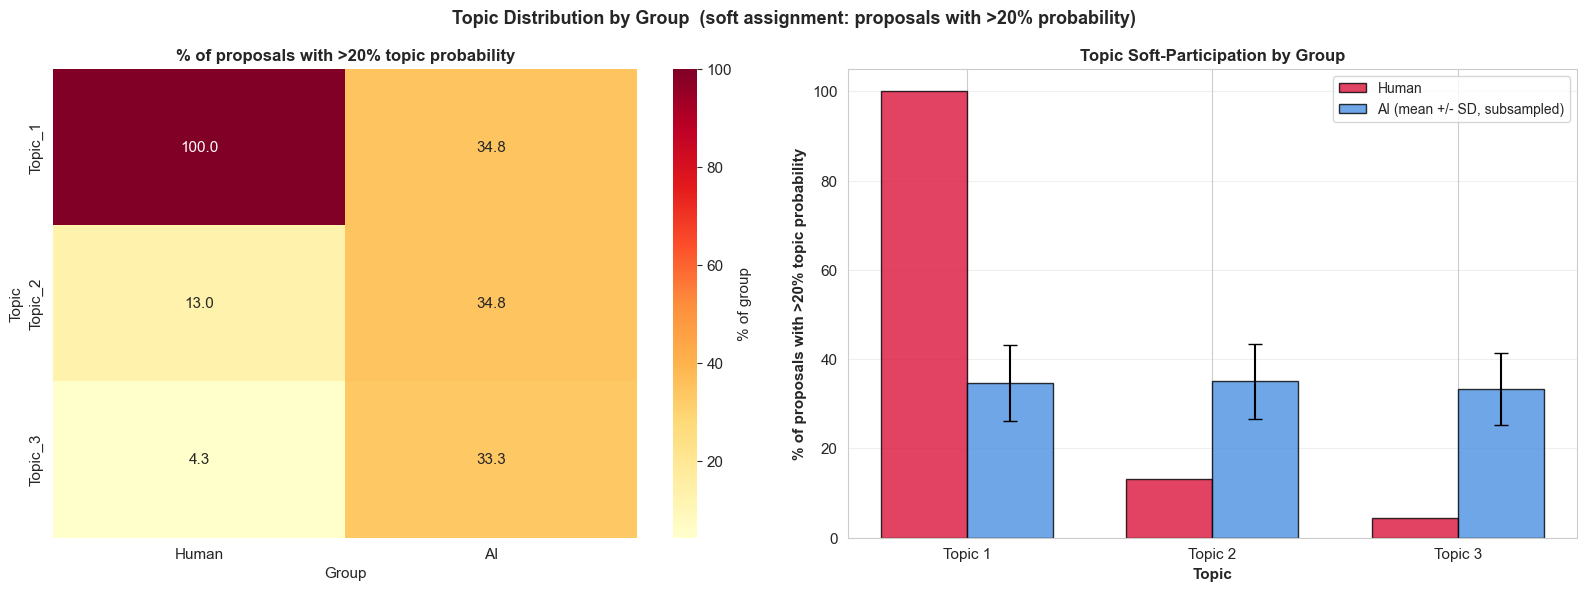

Figure saved to: results/figures/rephrased/topic_distribution_comparison.png


In [129]:
import seaborn as sns

# Visualization: Soft-assignment topic distribution by group
threshold  = 0.20
topic_cols = sorted([col for col in doc_topic_df.columns if col.startswith('Topic_')])

human_df_t = doc_topic_df[doc_topic_df['group'] == 'Human']
ai_df_t    = doc_topic_df[doc_topic_df['group'] == 'AI']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Topic Distribution by Group  (soft assignment: proposals with >20% probability)",
             fontsize=13, fontweight='bold')

# Panel 1: Heatmap -- fraction of group with >20% for each topic
soft_frac = pd.DataFrame({
    'Human': {col: (human_df_t[col] > threshold).mean() * 100 for col in topic_cols},
    'AI':    {col: (ai_df_t[col]    > threshold).mean() * 100 for col in topic_cols},
})
sns.heatmap(soft_frac, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': '% of group'})
axes[0].set_title('% of proposals with >20% topic probability', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Group', fontsize=11)
axes[0].set_ylabel('Topic', fontsize=11)

# Panel 2: Bar plot with subsample error bars
x     = np.arange(len(topic_cols))
width = 0.35
human_pcts = [(human_df_t[col] > threshold).mean() * 100 for col in topic_cols]

ai_pcts_mean, ai_pcts_std = [], []
ai_idx = ai_df_t.index
for col in topic_cols:
    vals = []
    for _ in range(500):
        s = doc_topic_df.loc[np.random.choice(ai_idx, size=len(human_df_t), replace=False)]
        vals.append((s[col] > threshold).mean() * 100)
    ai_pcts_mean.append(np.mean(vals))
    ai_pcts_std.append(np.std(vals))

axes[1].bar(x - width/2, human_pcts,  width,
            label='Human', color='#DC143C', alpha=0.8, edgecolor='black')
axes[1].bar(x + width/2, ai_pcts_mean, width, yerr=ai_pcts_std,
            label='AI (mean +/- SD, subsampled)',
            color='#4A90E2', alpha=0.8, edgecolor='black', capsize=5)
axes[1].set_xlabel('Topic', fontsize=11, fontweight='bold')
axes[1].set_ylabel('% of proposals with >20% topic probability', fontsize=11, fontweight='bold')
axes[1].set_title('Topic Soft-Participation by Group', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([c.replace('_', ' ') for c in topic_cols])
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'topic_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to: results/figures/rephrased/topic_distribution_comparison.png")


## Analysis 3.3: Topic Coverage and Entropy

Examine breadth and evenness of topic coverage with sample size corrections.

In [130]:
from scipy.stats import entropy as scipy_entropy

print("="*85)
print("TOPIC COVERAGE AND ENTROPY ANALYSIS  (soft assignment throughout)")
print("="*85)

threshold  = 0.20
topic_cols = sorted([col for col in doc_topic_df.columns if col.startswith('Topic_')])

human_doc_topics = doc_topic_df[doc_topic_df['group'] == 'Human']
ai_doc_topics    = doc_topic_df[doc_topic_df['group'] == 'AI']

# ── 1. Coverage (unchanged -- already used soft assignment) ───────────────────
def count_topics_covered(group_df, topic_cols, threshold=0.20):
    return sum(1 for col in topic_cols if (group_df[col] > threshold).any())

human_coverage = count_topics_covered(human_doc_topics, topic_cols, threshold)
ai_coverage    = count_topics_covered(ai_doc_topics,    topic_cols, threshold)

print()
print(f"1. TOPIC COVERAGE (topics with at least one proposal >{threshold*100:.0f}% probability):")
print(f"  Human: {human_coverage}/{len(topic_cols)} topics")
print(f"  AI:    {ai_coverage}/{len(topic_cols)} topics")

# ── 2. Exclusive topics -- soft, min_count=2 (was 5; too strict at n=23) ─────
def get_exclusive_topics_soft(group_df, other_df, topic_cols, threshold=0.20, min_count=2):
    """Topics where group has >=min_count proposals >threshold AND other group has 0."""
    return [(col, int((group_df[col] > threshold).sum()))
            for col in topic_cols
            if (group_df[col] > threshold).sum() >= min_count
            and (other_df[col] > threshold).sum() == 0]

human_exclusive_raw = get_exclusive_topics_soft(human_doc_topics, ai_doc_topics,    topic_cols, threshold)
ai_exclusive_raw    = get_exclusive_topics_soft(ai_doc_topics,    human_doc_topics, topic_cols, threshold)

human_exclusive = [t for t, _ in human_exclusive_raw]
ai_exclusive    = [t for t, _ in ai_exclusive_raw]

print()
print(f"2. EXCLUSIVE TOPICS (soft: >=2 proposals >{threshold*100:.0f}% probability, 0 in other group):")
print(f"  Human-exclusive: {len(human_exclusive)}")
for t, n in human_exclusive_raw:
    print(f"    {t} ({n} proposals)")
print(f"  AI-exclusive:    {len(ai_exclusive)}")
for t, n in ai_exclusive_raw:
    print(f"    {t} ({n} proposals)")

print()
print("  Permutation test for exclusive topic counts:")
n_perm    = 10000
perm_h_exc = []
perm_a_exc = []
for _ in range(n_perm):
    shuffled          = doc_topic_df.copy()
    shuffled['group'] = np.random.permutation(shuffled['group'].values)
    h = shuffled[shuffled['group'] == 'Human']
    a = shuffled[shuffled['group'] == 'AI']
    perm_h_exc.append(len(get_exclusive_topics_soft(h, a, topic_cols, threshold)))
    perm_a_exc.append(len(get_exclusive_topics_soft(a, h, topic_cols, threshold)))

perm_h_exc = np.array(perm_h_exc)
perm_a_exc = np.array(perm_a_exc)
p_human = np.mean(perm_h_exc >= len(human_exclusive))
p_ai    = np.mean(perm_a_exc >= len(ai_exclusive))
print(f"    Human: {len(human_exclusive)} observed vs. {perm_h_exc.mean():.2f} +/- {perm_h_exc.std():.2f} expected, p={p_human:.4f}")
print(f"    AI:    {len(ai_exclusive)} observed vs. {perm_a_exc.mean():.2f} +/- {perm_a_exc.std():.2f} expected, p={p_ai:.4f}")

# ── 3. Shannon entropy on MEAN SOFT TOPIC DISTRIBUTION ───────────────────────
print()
print("3. SHANNON ENTROPY on mean soft topic distribution (Miller-Madow corrected):")
print("   Uses mean LDA probability across proposals -- more informative than dominant-topic counts.")

def group_soft_entropy(group_df, topic_cols, base=2):
    mean_dist    = group_df[topic_cols].mean()
    mean_dist    = mean_dist / mean_dist.sum()
    h            = float(scipy_entropy(mean_dist, base=base))
    k            = len(topic_cols)
    n            = len(group_df)
    h_corrected  = h + (k - 1) / (2 * n)
    h_max        = np.log2(k)
    h_normalized = h_corrected / h_max if h_max > 0 else 0
    return h_corrected, h_normalized

human_entropy, human_norm_entropy = group_soft_entropy(human_doc_topics, topic_cols)
ai_entropy,    ai_norm_entropy    = group_soft_entropy(ai_doc_topics,    topic_cols)

print(f"  Human: H = {human_entropy:.4f}, H_normalized = {human_norm_entropy:.4f}")
print(f"  AI:    H = {ai_entropy:.4f}, H_normalized = {ai_norm_entropy:.4f}")

print()
print(f"  Subsample validation (AI subsampled to n={len(human_doc_topics)}, 1000 iterations):")
subsample_entropies      = []
subsample_norm_entropies = []
ai_idx = ai_doc_topics.index
for _ in range(1000):
    sampled = ai_doc_topics.loc[np.random.choice(ai_idx, size=len(human_doc_topics), replace=False)]
    h, h_norm = group_soft_entropy(sampled, topic_cols)
    subsample_entropies.append(h)
    subsample_norm_entropies.append(h_norm)

subsample_entropies      = np.array(subsample_entropies)
subsample_norm_entropies = np.array(subsample_norm_entropies)

print(f"    AI (subsampled): H = {subsample_entropies.mean():.4f} +/- {subsample_entropies.std():.4f}")
print(f"    AI (subsampled): H_normalized = {subsample_norm_entropies.mean():.4f} +/- {subsample_norm_entropies.std():.4f}")

diff        = human_entropy - subsample_entropies.mean()
p_lower     = np.mean(subsample_entropies <= human_entropy)
p_upper     = np.mean(subsample_entropies >= human_entropy)
p_two_sided = min(1.0, 2 * min(p_lower, p_upper))
p_one_sided = p_lower if human_entropy < subsample_entropies.mean() else p_upper
p_entropy   = p_two_sided

print()
print("  Comparison (subsample test):")
print(f"    Difference (Human - AI_subsample_mean): {diff:.4f}")
print(f"    p_one_sided (observed direction): {p_one_sided:.4f}")
print(f"    p_two_sided: {p_two_sided:.4f}")
if p_two_sided < 0.05:
    direction_str = "HIGHER" if human_entropy > subsample_entropies.mean() else "LOWER"
    print(f"    -> Human proposals have significantly {direction_str} entropy")
else:
    print("    -> No significant difference in entropy")

print()
print("  Higher entropy = more even spread of probability mass across topics")
print("  Soft entropy avoids the dominant-topic discretization artifact.")
print("="*85)


TOPIC COVERAGE AND ENTROPY ANALYSIS  (soft assignment throughout)

1. TOPIC COVERAGE (topics with at least one proposal >20% probability):
  Human: 3/3 topics
  AI:    3/3 topics

2. EXCLUSIVE TOPICS (soft: >=2 proposals >20% probability, 0 in other group):
  Human-exclusive: 0
  AI-exclusive:    0

  Permutation test for exclusive topic counts:
    Human: 0 observed vs. 0.00 +/- 0.00 expected, p=1.0000
    AI:    0 observed vs. 0.00 +/- 0.02 expected, p=1.0000

3. SHANNON ENTROPY on mean soft topic distribution (Miller-Madow corrected):
   Uses mean LDA probability across proposals -- more informative than dominant-topic counts.
  Human: H = 0.5543, H_normalized = 0.3497
  AI:    H = 1.5990, H_normalized = 1.0089

  Subsample validation (AI subsampled to n=23, 1000 iterations):
    AI (subsampled): H = 1.5876 +/- 0.0414
    AI (subsampled): H_normalized = 1.0017 +/- 0.0261

  Comparison (subsample test):
    Difference (Human - AI_subsample_mean): -1.0333
    p_one_sided (observed dir

## Analysis 3.4: Cluster Composition/Segregation Analysis

Examine whether human and AI proposals segregate into distinct clusters in embedding space using Gaussian Mixture Models.

In [131]:
from pathlib import Path

emb_path = REPHRASED_EMBEDDINGS_FILE
if not emb_path.exists():
    legacy_paths = sorted(emb_path.parent.glob('proposal_embeddings_[0-9]*.pkl'))
    if not legacy_paths:
        raise FileNotFoundError(f"No embedding pickle found at {emb_path}. Run the embedding generation cell first.")
    emb_path = legacy_paths[-1]

embeddings_data = retrieve_embeddings(str(emb_path))

ai_embeddings = embeddings_data['ai_embeddings']
human_embeddings = embeddings_data['human_embeddings']
# ai_metadata = embeddings_data['ai_metadata']
# human_metadata = embeddings_data['human_metadata']

print(f"✓ Loaded embeddings from: {emb_path}")
print(f"  AI: {ai_embeddings.shape}, Human: {human_embeddings.shape}")


✓ Loaded embeddings from: ../data/embeddings/rephrased/proposal_embeddings_human_ai_rephrased_minimal.pkl
  AI: (69, 1024), Human: (23, 1024)


CLUSTER ANALYSIS: STEP 1 - OPTIMAL k SELECTION

Using embeddings: (92, 1024)
  Human: 23, AI: 69

Testing k = [3, 4, 5, 6, 7, 8]...

k     Silhouette   Davies-Bouldin   BIC         
--------------------------------------------------
3     0.1053       2.4585           6050100.93  
4     0.0742       2.5413           8426794.57  
5     0.0488       2.6805           10791702.83 
6     0.0510       2.5890           13170080.67 
7     0.0539       2.5791           15546280.71 
8     0.0388       2.3251           17918336.20 

✓ Best k by BIC (elbow method): 3
✓ Best k by Silhouette score: 3

→ Selected k = 3 (using BIC)


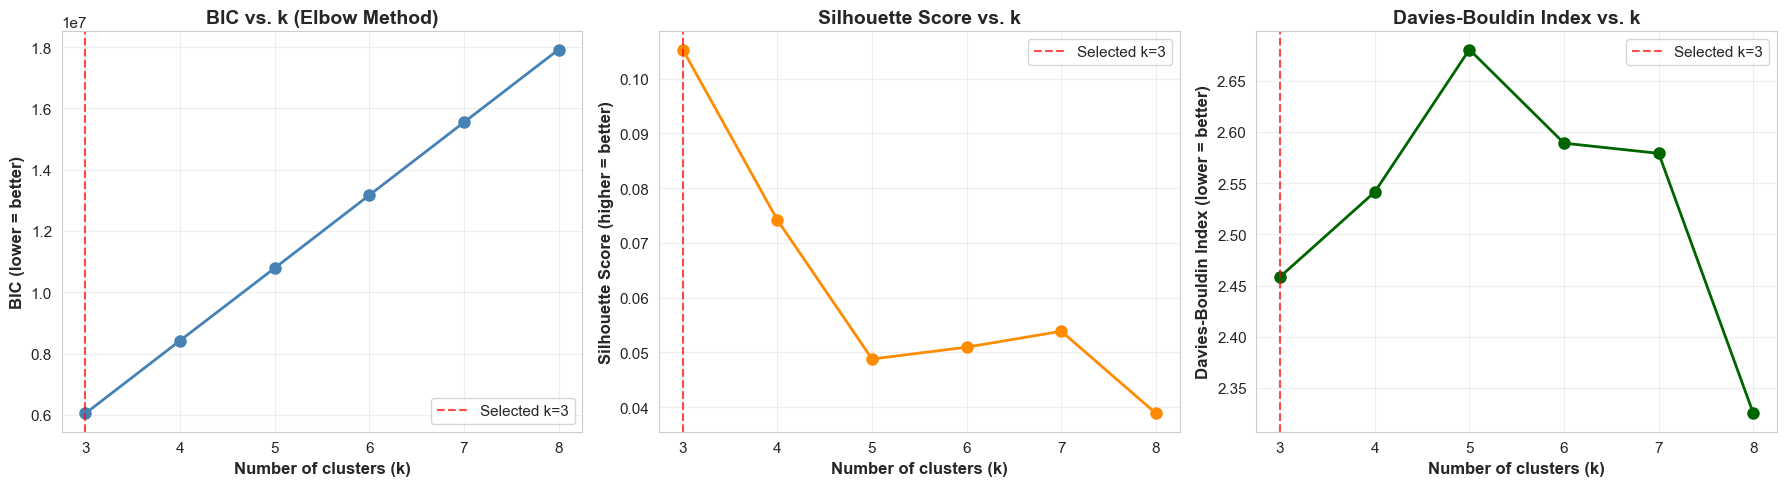

✓ Figure saved to: results/figures/rephrased/cluster_k_selection.png


In [132]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, normalized_mutual_info_score, adjusted_rand_score

print("="*85)
print("CLUSTER ANALYSIS: STEP 1 - OPTIMAL k SELECTION")
print("="*85)

# Use embeddings from diversity analysis (already computed)
all_embeddings_cluster = np.vstack([human_embeddings, ai_embeddings])
source_labels_cluster = np.array(['Human'] * len(human_embeddings) + ['AI'] * len(ai_embeddings))

print(f"\nUsing embeddings: {all_embeddings_cluster.shape}")
print(f"  Human: {len(human_embeddings)}, AI: {len(ai_embeddings)}")

# Test different values of k
k_values = [3, 4, 5, 6, 7, 8]
metrics_results = []

print(f"\nTesting k = {k_values}...")
print(f"\n{'k':<5} {'Silhouette':<12} {'Davies-Bouldin':<16} {'BIC':<12}")
print("-"*50)

for k in k_values:
    # Fit GMM
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=10
    )
    cluster_labels = gmm.fit_predict(all_embeddings_cluster)
    
    # Compute metrics
    silhouette = silhouette_score(all_embeddings_cluster, cluster_labels)
    davies_bouldin = davies_bouldin_score(all_embeddings_cluster, cluster_labels)
    bic = gmm.bic(all_embeddings_cluster)
    
    metrics_results.append({
        'k': k,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'bic': bic
    })
    
    print(f"{k:<5} {silhouette:<12.4f} {davies_bouldin:<16.4f} {bic:<12.2f}")

metrics_df = pd.DataFrame(metrics_results)

# Select best k using BIC (lower is better)
best_k_bic = metrics_df.loc[metrics_df['bic'].idxmin(), 'k']
best_k_silhouette = metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k']

print(f"\n✓ Best k by BIC (elbow method): {best_k_bic}")
print(f"✓ Best k by Silhouette score: {best_k_silhouette}")

# Use BIC as primary criterion
best_k = int(best_k_bic)
print(f"\n→ Selected k = {best_k} (using BIC)")

# Visualize selection metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: BIC
ax1 = axes[0]
ax1.plot(metrics_df['k'], metrics_df['bic'], 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax1.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('BIC (lower = better)', fontsize=12, fontweight='bold')
ax1.set_title('BIC vs. k (Elbow Method)', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend()

# Panel 2: Silhouette
ax2 = axes[1]
ax2.plot(metrics_df['k'], metrics_df['silhouette'], 'o-', linewidth=2, markersize=8, color='darkorange')
ax2.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax2.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Silhouette Score (higher = better)', fontsize=12, fontweight='bold')
ax2.set_title('Silhouette Score vs. k', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend()

# Panel 3: Davies-Bouldin
ax3 = axes[2]
ax3.plot(metrics_df['k'], metrics_df['davies_bouldin'], 'o-', linewidth=2, markersize=8, color='darkgreen')
ax3.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax3.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Davies-Bouldin Index (lower = better)', fontsize=12, fontweight='bold')
ax3.set_title('Davies-Bouldin Index vs. k', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/rephrased/cluster_k_selection.png")
print("="*85)

In [133]:
print("="*85)
print(f"CLUSTER ANALYSIS: STEP 2 - CLUSTERING WITH k={best_k}")
print("="*85)

# Fit final GMM with best k
gmm_final = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    random_state=42,
    n_init=10
)

cluster_labels_final = gmm_final.fit_predict(all_embeddings_cluster)
cluster_probs_final = gmm_final.predict_proba(all_embeddings_cluster)

print(f"\n✓ Clustered {len(all_embeddings_cluster)} proposals into {best_k} clusters")
print(f"  Cluster sizes: {np.bincount(cluster_labels_final)}")

# Cluster composition analysis
print(f"\n" + "-"*85)
print("CLUSTER COMPOSITION ANALYSIS")
print("-"*85)

cluster_composition = []

for cluster_id in range(best_k):
    cluster_mask = cluster_labels_final == cluster_id
    cluster_sources = source_labels_cluster[cluster_mask]
    
    n_total = len(cluster_sources)
    n_human = (cluster_sources == 'Human').sum()
    n_ai = (cluster_sources == 'AI').sum()
    
    pct_human = n_human / n_total * 100 if n_total > 0 else 0
    pct_ai = n_ai / n_total * 100 if n_total > 0 else 0
    
    # Classify cluster dominance (baseline: 25% human, 75% AI)
    if pct_human > 60:
        dominance = 'Human-dominated'
    elif pct_human < 15:  # Less than expected given 25% baseline
        dominance = 'AI-dominated'
    else:
        dominance = 'Mixed'
    
    cluster_composition.append({
        'cluster': cluster_id,
        'total': n_total,
        'human': n_human,
        'ai': n_ai,
        'pct_human': pct_human,
        'pct_ai': pct_ai,
        'dominance': dominance
    })

composition_df = pd.DataFrame(cluster_composition)

print(f"\n{'Cluster':<10} {'Total':<8} {'Human':<8} {'AI':<8} {'%Human':<10} {'%AI':<10} {'Dominance'}")
print("-"*85)

for _, row in composition_df.iterrows():
    print(f"{row['cluster']:<10} {row['total']:<8} {row['human']:<8} {row['ai']:<8} "
          f"{row['pct_human']:<10.1f} {row['pct_ai']:<10.1f} {row['dominance']}")

print(f"\n{'Dominance':<20} {'Count'}")
print("-"*30)
dominance_counts = composition_df['dominance'].value_counts()
for dom, count in dominance_counts.items():
    print(f"{dom:<20} {count}")

print(f"\n💡 Baseline: 25% human, 75% AI")
print(f"   Human-dominated: >60% human")
print(f"   AI-dominated: <15% human")
print(f"   Mixed: 15-60% human")
print("="*85)

CLUSTER ANALYSIS: STEP 2 - CLUSTERING WITH k=3

✓ Clustered 92 proposals into 3 clusters
  Cluster sizes: [41 11 40]

-------------------------------------------------------------------------------------
CLUSTER COMPOSITION ANALYSIS
-------------------------------------------------------------------------------------

Cluster    Total    Human    AI       %Human     %AI        Dominance
-------------------------------------------------------------------------------------
0          41       9        32       22.0       78.0       Mixed
1          11       7        4        63.6       36.4       Human-dominated
2          40       7        33       17.5       82.5       Mixed

Dominance            Count
------------------------------
Mixed                2
Human-dominated      1

💡 Baseline: 25% human, 75% AI
   Human-dominated: >60% human
   AI-dominated: <15% human
   Mixed: 15-60% human


In [134]:
print("="*85)
print("CLUSTER ANALYSIS: STEP 3 - SEGREGATION METRICS (with Permutation Tests)")
print("="*85)

# Convert source labels to binary (0 = Human, 1 = AI)
source_binary = (source_labels_cluster == 'AI').astype(int)

# 1. Normalized Mutual Information (NMI)
nmi_observed = normalized_mutual_info_score(cluster_labels_final, source_binary)

print(f"\n1. NORMALIZED MUTUAL INFORMATION (NMI):")
print(f"   Observed NMI: {nmi_observed:.4f}")

# Permutation test for NMI
n_perm_seg = 10000
nmi_null = []

for _ in range(n_perm_seg):
    shuffled_sources = np.random.permutation(source_binary)
    nmi_perm = normalized_mutual_info_score(cluster_labels_final, shuffled_sources)
    nmi_null.append(nmi_perm)

nmi_null = np.array(nmi_null)
p_nmi = np.mean(nmi_null >= nmi_observed)

print(f"   Null distribution: {nmi_null.mean():.4f} ± {nmi_null.std():.4f}")
print(f"   p-value: {p_nmi:.4f}")

if p_nmi < 0.05:
    print(f"   → Significant segregation: clusters predict source better than chance")
else:
    print(f"   → No significant segregation: clustering independent of source")

# 2. Adjusted Rand Index (ARI)
ari_observed = adjusted_rand_score(cluster_labels_final, source_binary)

print(f"\n2. ADJUSTED RAND INDEX (ARI):")
print(f"   Observed ARI: {ari_observed:.4f}")

# Permutation test for ARI
ari_null = []

for _ in range(n_perm_seg):
    shuffled_sources = np.random.permutation(source_binary)
    ari_perm = adjusted_rand_score(cluster_labels_final, shuffled_sources)
    ari_null.append(ari_perm)

ari_null = np.array(ari_null)
p_ari = np.mean(ari_null >= ari_observed)

print(f"   Null distribution: {ari_null.mean():.4f} ± {ari_null.std():.4f}")
print(f"   p-value: {p_ari:.4f}")

if p_ari < 0.05:
    print(f"   → Significant agreement: cluster assignments correlate with source")
else:
    print(f"   → No significant agreement: random overlap")

# 3. Within-group vs. Between-group distances
print(f"\n3. WITHIN-GROUP VS. BETWEEN-GROUP DISTANCES:")

# Calculate pairwise distances
from sklearn.metrics.pairwise import cosine_distances

distances_all = cosine_distances(all_embeddings_cluster)

# Within-human distances
human_mask = source_labels_cluster == 'Human'
within_human_dists = distances_all[np.ix_(human_mask, human_mask)]
within_human_dists = within_human_dists[np.triu_indices_from(within_human_dists, k=1)]

# Within-AI distances
ai_mask = source_labels_cluster == 'AI'
within_ai_dists = distances_all[np.ix_(ai_mask, ai_mask)]
within_ai_dists = within_ai_dists[np.triu_indices_from(within_ai_dists, k=1)]

# Between human-AI distances
between_dists = distances_all[np.ix_(human_mask, ai_mask)].flatten()

print(f"   Within-human mean distance: {within_human_dists.mean():.4f} ± {within_human_dists.std():.4f}")
print(f"   Within-AI mean distance: {within_ai_dists.mean():.4f} ± {within_ai_dists.std():.4f}")
print(f"   Between human-AI mean distance: {between_dists.mean():.4f} ± {between_dists.std():.4f}")

# Ratio of between to within
within_mean = np.mean([within_human_dists.mean(), within_ai_dists.mean()])
between_within_ratio = between_dists.mean() / within_mean

print(f"\n   Between/Within ratio: {between_within_ratio:.4f}")

# Permutation test for between/within ratio
ratio_null = []

for _ in range(n_perm_seg):
    shuffled = np.random.permutation(source_labels_cluster)
    h_mask = shuffled == 'Human'
    a_mask = shuffled == 'AI'
    
    within_h = distances_all[np.ix_(h_mask, h_mask)]
    within_h = within_h[np.triu_indices_from(within_h, k=1)]
    
    within_a = distances_all[np.ix_(a_mask, a_mask)]
    within_a = within_a[np.triu_indices_from(within_a, k=1)]
    
    between = distances_all[np.ix_(h_mask, a_mask)].flatten()
    
    within_m = np.mean([within_h.mean(), within_a.mean()])
    ratio_perm = between.mean() / within_m
    ratio_null.append(ratio_perm)

ratio_null = np.array(ratio_null)
p_ratio = np.mean(ratio_null >= between_within_ratio)

print(f"   Null distribution: {ratio_null.mean():.4f} ± {ratio_null.std():.4f}")
print(f"   p-value: {p_ratio:.4f}")

if p_ratio < 0.05:
    if between_within_ratio > 1:
        print(f"   → Human and AI proposals are significantly MORE distant from each other than within groups")
    else:
        print(f"   → Human and AI proposals are significantly CLOSER to each other than within groups")
else:
    print(f"   → No significant difference in between vs. within-group distances")

print("\n" + "="*85)
print("INTERPRETATION SUMMARY")
print("="*85)

if p_nmi < 0.05 or p_ari < 0.05:
    print("✓ SEGREGATION: Human and AI proposals cluster in distinct semantic regions")
    print("  → They generate different KINDS of ideas")
elif p_nmi > 0.10 and p_ari > 0.10:
    print("✓ INTEGRATION: Human and AI proposals intermixed in embedding space")
    print("  → Ideas are similar regardless of source")
else:
    print("✓ INTERMEDIATE: Some thematic clustering but not strictly by source")

print("="*85)

CLUSTER ANALYSIS: STEP 3 - SEGREGATION METRICS (with Permutation Tests)

1. NORMALIZED MUTUAL INFORMATION (NMI):
   Observed NMI: 0.0621
   Null distribution: 0.0153 ± 0.0155
   p-value: 0.0161
   → Significant segregation: clusters predict source better than chance

2. ADJUSTED RAND INDEX (ARI):
   Observed ARI: 0.0732
   Null distribution: 0.0003 ± 0.0214
   p-value: 0.0063
   → Significant agreement: cluster assignments correlate with source

3. WITHIN-GROUP VS. BETWEEN-GROUP DISTANCES:
   Within-human mean distance: 0.3637 ± 0.3231
   Within-AI mean distance: 0.1136 ± 0.2133
   Between human-AI mean distance: 0.2711 ± 0.3143

   Between/Within ratio: 1.1359
   Null distribution: 1.0014 ± 0.0284
   p-value: 0.0008
   → Human and AI proposals are significantly MORE distant from each other than within groups

INTERPRETATION SUMMARY
✓ SEGREGATION: Human and AI proposals cluster in distinct semantic regions
  → They generate different KINDS of ideas


CLUSTER ANALYSIS: STEP 4 - VISUALIZATION
Reducing to 2D with UMAP for visualization...
✓ UMAP projection complete: (92, 2)


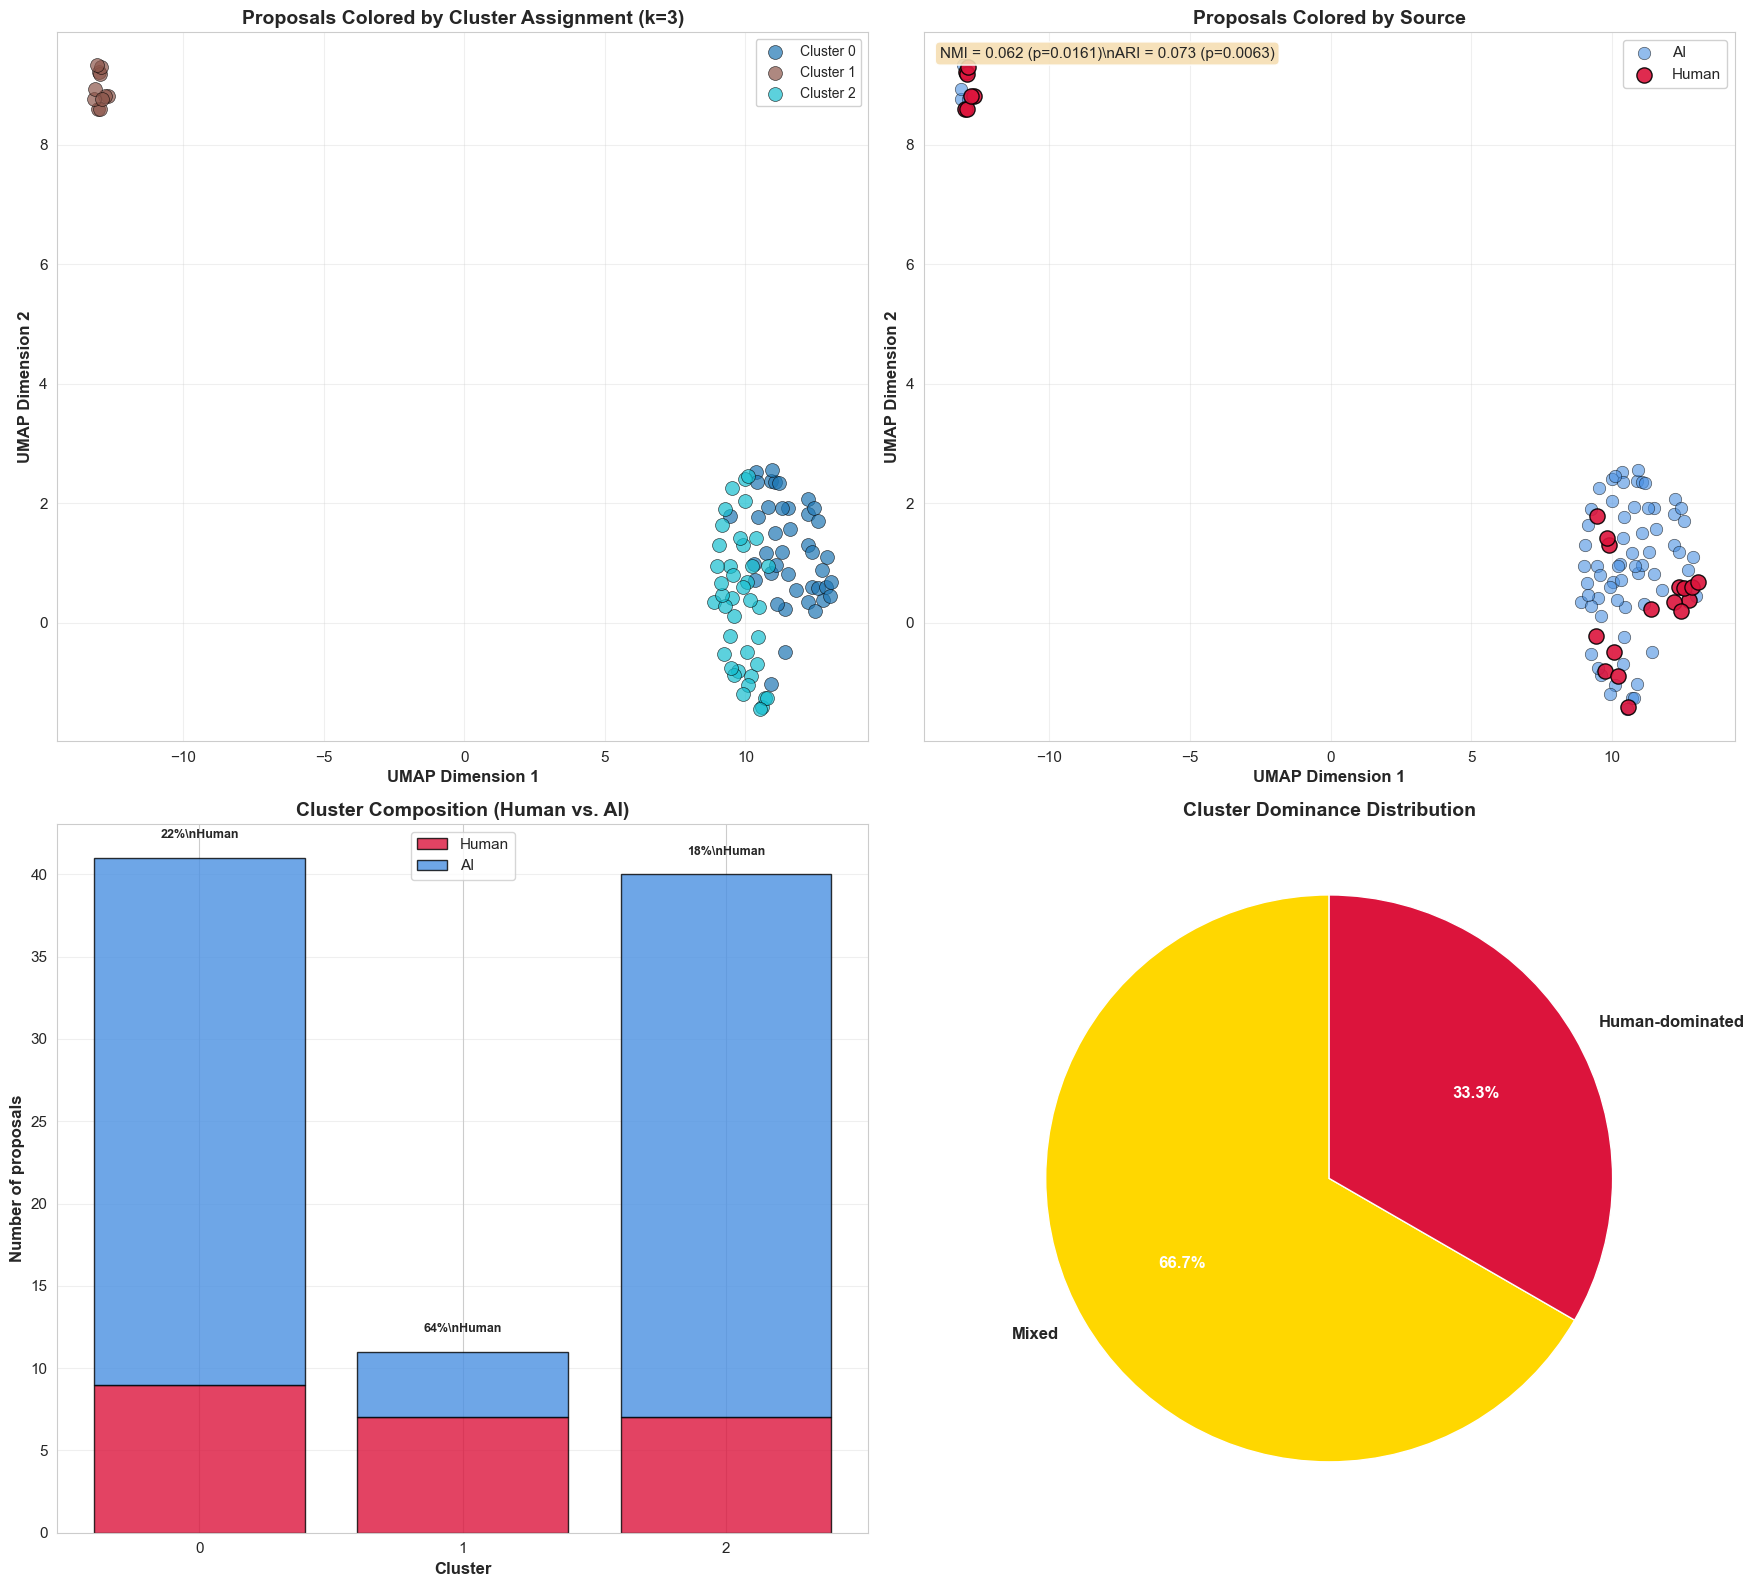

✓ Figure saved to: results/figures/rephrased/cluster_analysis_visualization.png


In [135]:
import umap
# Visualization: Cluster analysis in 2D embedding space
print("="*85)
print("CLUSTER ANALYSIS: STEP 4 - VISUALIZATION")
print("="*85)

# Use existing UMAP projection from earlier analysis
# Apply UMAP if not already done for this combined set
print("Reducing to 2D with UMAP for visualization...")

reducer_cluster = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

embeddings_2d_cluster = reducer_cluster.fit_transform(all_embeddings_cluster)

print(f"✓ UMAP projection complete: {embeddings_2d_cluster.shape}")

# Create 2x2 visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Color schemes
source_colors = {'Human': '#DC143C', 'AI': '#4A90E2'}
cluster_colors = plt.cm.tab10(np.linspace(0, 1, best_k))

# Panel 1: Colored by cluster assignment
ax1 = axes[0, 0]
for cluster_id in range(best_k):
    mask = cluster_labels_final == cluster_id
    ax1.scatter(embeddings_2d_cluster[mask, 0], embeddings_2d_cluster[mask, 1],
               c=[cluster_colors[cluster_id]], label=f'Cluster {cluster_id}',
               s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax1.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax1.set_title(f'Proposals Colored by Cluster Assignment (k={best_k})', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10, framealpha=0.9)
ax1.grid(alpha=0.3)

# Panel 2: Colored by source (Human vs. AI)
ax2 = axes[0, 1]
for source in ['AI', 'Human']:  # Plot AI first, Human on top
    mask = source_labels_cluster == source
    ax2.scatter(embeddings_2d_cluster[mask, 0], embeddings_2d_cluster[mask, 1],
               c=source_colors[source], label=source,
               s=120 if source == 'Human' else 80, 
               alpha=0.9 if source == 'Human' else 0.6,
               edgecolors='black', linewidth=1.0 if source == 'Human' else 0.5)

ax2.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax2.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax2.set_title('Proposals Colored by Source', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=11, framealpha=0.9)
ax2.grid(alpha=0.3)

# Add NMI and ARI as text
textstr = f'NMI = {nmi_observed:.3f} (p={p_nmi:.4f})\\nARI = {ari_observed:.3f} (p={p_ari:.4f})'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax2.text(0.02, 0.98, textstr, transform=ax2.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Panel 3: Cluster composition (stacked bar chart)
ax3 = axes[1, 0]
cluster_ids = composition_df['cluster'].values
human_counts = composition_df['human'].values
ai_counts = composition_df['ai'].values

ax3.bar(cluster_ids, human_counts, label='Human', color='#DC143C', alpha=0.8, edgecolor='black')
ax3.bar(cluster_ids, ai_counts, bottom=human_counts, label='AI', color='#4A90E2', alpha=0.8, edgecolor='black')

ax3.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of proposals', fontsize=12, fontweight='bold')
ax3.set_title('Cluster Composition (Human vs. AI)', fontsize=14, fontweight='bold')
ax3.set_xticks(cluster_ids)
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, cluster_id in enumerate(cluster_ids):
    total = composition_df.loc[i, 'total']
    pct_h = composition_df.loc[i, 'pct_human']
    ax3.text(cluster_id, total + 1, f'{pct_h:.0f}%\\nHuman', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 4: Cluster dominance pie chart
ax4 = axes[1, 1]
dominance_counts = composition_df['dominance'].value_counts()
colors_pie = {'Human-dominated': '#DC143C', 'AI-dominated': '#4A90E2', 'Mixed': '#FFD700'}
pie_colors = [colors_pie.get(d, 'gray') for d in dominance_counts.index]

wedges, texts, autotexts = ax4.pie(dominance_counts.values, labels=dominance_counts.index, 
                                     autopct='%1.1f%%', startangle=90,
                                     colors=pie_colors, textprops={'fontsize': 12, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax4.set_title('Cluster Dominance Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cluster_analysis_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/rephrased/cluster_analysis_visualization.png")
print("="*85)

### PART III Summary

In [136]:
print("="*85)
print("ANALYSIS 2.3: THEMATIC AND CLUSTER ANALYSIS - COMPREHENSIVE SUMMARY")
print("="*85)

if 'p_entropy' not in globals():
    p_entropy = p_two_sided if 'p_two_sided' in globals() else np.nan

print()
print("="*85)
print("1. TOPIC MODELING (LDA with n=5 topics)")
print("="*85)
print("  Model: Latent Dirichlet Allocation")
print("  Parameters: alpha=0.5, beta=0.5 (strong regularization)")
print(f"  Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print("  Topics identified:")
for i, topic_words in enumerate(topics):
    print(f"    Topic {i+1}: {', '.join(topic_words[:5])}...")

print()
print("="*85)
print("2. TOPIC DISTRIBUTION COMPARISON")
print("="*85)
print("  Overall distribution test (permutation):")
print(f"    Chi-square: {observed_chi2:.4f}, p={p_value_perm:.4f}")
if p_value_perm < 0.05:
    print("    → Significant difference in topic distributions")
else:
    print("    → No significant difference in topic distributions")

print("  Per-topic tests (Fisher's exact with FDR correction):")
significant_topics = fisher_df[fisher_df['p_value_fdr'] < 0.10]
if len(significant_topics) > 0:
    print(f"    {len(significant_topics)} topics show significant over/under-representation:")
    for _, row in significant_topics.iterrows():
        direction = 'Human' if row['odds_ratio'] > 1 else 'AI'
        print(f"      {row['topic']}: OR={row['odds_ratio']:.2f}, p_fdr={row['p_value_fdr']:.4f} ({direction}↑)")
else:
    print("    No topics show significant over/under-representation (FDR q=0.10)")

print()
print("="*85)
print("3. TOPIC COVERAGE AND ENTROPY")
print("="*85)
print("  Coverage (topics with >20% probability):")
print(f"    Human: {human_coverage}/{n_topics} topics")
print(f"    AI: {ai_coverage}/{n_topics} topics")
print("  Exclusive topics (≥5 proposals):")
print(f"    Human-exclusive: {len(human_exclusive)} (p={p_human:.4f})")
print(f"    AI-exclusive: {len(ai_exclusive)} (p={p_ai:.4f})")
print("  Shannon entropy (Miller-Madow corrected):")
print(f"    Human: H={human_entropy:.4f}, H_norm={human_norm_entropy:.4f}")
print(f"    AI (subsampled): H={subsample_entropies.mean():.4f}±{subsample_entropies.std():.4f}")
print(f"    Difference (two-sided): p={p_entropy:.4f}")

print()
print("="*85)
print(f"4. CLUSTER ANALYSIS (GMM with k={best_k})")
print("="*85)
print("  Model selection:")
print(f"    Best k by BIC: {best_k}")
print(f"    Silhouette score: {metrics_df.loc[metrics_df['k']==best_k, 'silhouette'].values[0]:.4f}")
print("  Cluster composition:")
print(f"    Human-dominated clusters: {(composition_df['dominance']=='Human-dominated').sum()}")
print(f"    AI-dominated clusters: {(composition_df['dominance']=='AI-dominated').sum()}")
print(f"    Mixed clusters: {(composition_df['dominance']=='Mixed').sum()}")
print("  Segregation metrics:")
print(f"    NMI: {nmi_observed:.4f} (null: {nmi_null.mean():.4f}±{nmi_null.std():.4f}, p={p_nmi:.4f})")
print(f"    ARI: {ari_observed:.4f} (null: {ari_null.mean():.4f}±{ari_null.std():.4f}, p={p_ari:.4f})")
print(f"    Between/Within distance ratio: {between_within_ratio:.4f} (p={p_ratio:.4f})")

print()
print("="*85)
print("OVERALL INTERPRETATION")
print("="*85)
if p_value_perm < 0.05:
    print("✓ Topics: Human and AI differ in topic distributions")
else:
    print("✓ Topics: No significant difference in topic distributions")

if np.isfinite(p_entropy) and p_entropy < 0.05:
    if diff > 0:
        print("✓ Entropy: Human proposals show higher thematic diversity")
    else:
        print("✓ Entropy: AI proposals show higher thematic diversity")
else:
    print("✓ Entropy: Similar thematic diversity between groups")

if p_nmi < 0.05 or p_ari < 0.05:
    print("✓ Clustering: SEGREGATION - Human and AI occupy distinct semantic regions")
    print("  → Generate different KINDS of ideas")
elif p_nmi > 0.10 and p_ari > 0.10:
    print("✓ Clustering: INTEGRATION - Human and AI ideas are intermixed")
    print("  → Similar ideas regardless of source")
else:
    print("✓ Clustering: INTERMEDIATE - Some thematic patterns but not strict segregation")

print()
print("⚠️  LIMITATIONS:")
print("  • Small sample size (n=23 human, n=69 AI)")
print("  • Topic modeling labeled as EXPLORATORY")
print("  • Results should be validated with larger samples")
print("  • Segregation may reflect prompt differences, not inherent ideation differences")

print()
print("="*85)
print("📊 FIGURES GENERATED:")
print("="*85)
print("  1. results/figures/rephrased/cluster_k_selection.png")
print("  2. results/figures/rephrased/topic_distribution_comparison.png")
print("  3. results/figures/rephrased/cluster_analysis_visualization.png")
print("="*85)


ANALYSIS 2.3: THEMATIC AND CLUSTER ANALYSIS - COMPREHENSIVE SUMMARY

1. TOPIC MODELING (LDA with n=5 topics)
  Model: Latent Dirichlet Allocation
  Parameters: alpha=0.5, beta=0.5 (strong regularization)
  Perplexity: 1138.66
  Topics identified:
    Topic 1: imaging, network, rna, spatial, networks...
    Topic 2: emergence, working group, ai, collaborative, science...
    Topic 3: organization, aim, interaction, institutions, spanning...

2. TOPIC DISTRIBUTION COMPARISON
  Overall distribution test (permutation):
    Chi-square: 20.9993, p=0.0001
    → Significant difference in topic distributions
  Per-topic tests (Fisher's exact with FDR correction):
    3 topics show significant over/under-representation:
      Topic_1: OR=inf, p_fdr=0.0000 (Human↑)
      Topic_2: OR=0.28, p_fdr=0.0641 (AI↑)
      Topic_3: OR=0.09, p_fdr=0.0082 (AI↑)

3. TOPIC COVERAGE AND ENTROPY
  Coverage (topics with >20% probability):
    Human: 3/3 topics
    AI: 3/3 topics
  Exclusive topics (≥5 proposals):

----------------------------
# PART IV Style Baseline

Before interpreting embedding distances, clustering segregation (NMI/ARI), or topic separation as “conceptual” differences, quantify how much **purely stylistic** signals can separate Human vs. AI. If a style-only model predicts source well, then a substantial portion of downstream “segregation/diversity” effects may be stylistic rather than conceptual.

### Exract stylistic features

In [137]:
# =============================================================================
# ANALYSIS 2.3.5–2.3.6: STYLE VS CONTENT (Baseline + Style-Controlled Sensitivity)
# Text scope: full proposals (full_text)
# =============================================================================

import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# ----------------------------
# Style feature extraction
# ----------------------------

_HEDGE_WORDS = {
    'may','might','could','can','suggest','suggests','suggested','potential','potentially',
    'likely','unlikely','possibly','possible','approximately','estimate','estimated',
    'hypothesize','hypothesis','we propose','we aim','we will','we plan'
}

def _tokenize_words(text: str):
    return re.findall(r"[A-Za-z']+", text.lower())

def _split_sentences(text: str):
    # lightweight sentence split for readability/stylistic counts
    sents = re.split(r"[.!?]+\s+|\n+", text.strip())
    return [s for s in (sent.strip() for sent in sents) if s]

def _count_syllables(word: str) -> int:
    # heuristic syllable counter (good enough for comparative readability proxies)
    w = re.sub(r"[^a-z]", "", word.lower())
    if not w:
        return 0
    w = re.sub(r"e$", "", w)  # silent e
    groups = re.findall(r"[aeiouy]+", w)
    return max(1, len(groups))

def _flesch_kincaid(text: str):
    words = _tokenize_words(text)
    n_words = len(words)
    sents = _split_sentences(text)
    n_sents = len(sents)
    if n_words == 0 or n_sents == 0:
        return np.nan, np.nan
    syllables = sum(_count_syllables(w) for w in words)

    # Flesch Reading Ease & FK Grade Level (English)
    fre = 206.835 - 1.015 * (n_words / n_sents) - 84.6 * (syllables / n_words)
    fkgl = 0.39 * (n_words / n_sents) + 11.8 * (syllables / n_words) - 15.59
    return fre, fkgl

def extract_style_features(text: str) -> dict:
    text = text or ""
    words = _tokenize_words(text)
    n_words = len(words)
    n_chars = len(text)
    sents = _split_sentences(text)
    n_sents = len(sents)

    uniq = len(set(words)) if n_words else 0
    ttr = (uniq / n_words) if n_words else 0.0

    stop_ct = sum(1 for w in words if w in ENGLISH_STOP_WORDS)
    stop_rate = (stop_ct / n_words) if n_words else 0.0

    avg_word_len = (np.mean([len(w) for w in words]) if n_words else 0.0)
    avg_sent_len = (n_words / n_sents) if n_sents else 0.0

    # punctuation / formatting (normalized)
    punct = {
        'comma': text.count(','),
        'semicolon': text.count(';'),
        'colon': text.count(':'),
        'dash': text.count('-') + text.count('–') + text.count('—'),
        'paren': text.count('(') + text.count(')'),
        'quote': text.count('"') + text.count("'"),
        'newline': text.count('\n'),
        'bullet': len(re.findall(r"(^|\n)\s*[-*•]\s+", text))
    }
    punct_rate = {f"{k}_per_1k_chars": (v / max(1, n_chars)) * 1000.0 for k, v in punct.items()}

    # hedging / stance
    low = text.lower()
    hedge_hits = 0
    # count single-token hedges
    hedge_hits += sum(1 for w in words if w in _HEDGE_WORDS)
    # count a few multiword patterns
    hedge_hits += len(re.findall(r"\bwe\s+(propose|aim|plan|will)\b", low))
    hedge_rate = (hedge_hits / n_words) if n_words else 0.0

    # simple headers / sectioning markers (your full_text includes e.g., "Title:", "Abstract:")
    header_lines = 0
    for line in (ln.strip() for ln in text.splitlines()):
        if re.match(r"^[A-Z][A-Za-z0-9 /-]{1,40}:\s+", line):
            header_lines += 1
    header_rate = header_lines

    fre, fkgl = _flesch_kincaid(text)

    feats = {
        'n_words': n_words,
        'n_chars': n_chars,
        'n_sents': n_sents,
        'avg_word_len': avg_word_len,
        'avg_sent_len_words': avg_sent_len,
        'type_token_ratio': ttr,
        'stopword_rate': stop_rate,
        'hedge_rate': hedge_rate,
        'flesch_reading_ease': fre,
        'fk_grade_level': fkgl,
    }
    feats.update(punct_rate)
    return feats

# Build style feature table (full proposals)
human_texts_style = human_df['full_text'].fillna('').tolist()
ai_texts_style = ai_df['full_text'].fillna('').tolist()
all_texts_style = human_texts_style + ai_texts_style

style_rows = [extract_style_features(t) for t in all_texts_style]
style_df = pd.DataFrame(style_rows)
style_df['group'] = (['Human'] * len(human_texts_style)) + (['AI'] * len(ai_texts_style))
style_df['is_ai'] = (style_df['group'] == 'AI').astype(int)

print("="*85)
print("STYLE FEATURES: EXTRACTED")
print("="*85)
print(f"✓ Built style feature table: {style_df.shape[0]} docs × {style_df.shape[1]-2} features")
print(style_df.groupby('group')[['avg_sent_len_words','stopword_rate','hedge_rate','fk_grade_level']].mean().round(3))


STYLE FEATURES: EXTRACTED
✓ Built style feature table: 92 docs × 18 features
       avg_sent_len_words  stopword_rate  hedge_rate  fk_grade_level
group                                                               
AI                 16.022          0.291         0.0          17.021
Human              15.727          0.292         0.0          16.453


In [138]:
# Save: style features with titles
import pandas as pd; from pathlib import Path
out_dir = TABLES_DIR; out_dir.mkdir(parents=True, exist_ok=True)
titles = ([r.get('proposal_title', r.get('title','')) for r in human_metadata]
        + [r.get('title', r.get('proposal_title','')) for r in ai_metadata])
out = style_df.copy().reset_index(drop=True)
out.insert(0, 'title', titles)
out.to_csv(out_dir/'style_features.csv', index=False)
print(f"Saved style_features.csv  ({len(out)} rows x {len(out.columns)} cols)")


Saved style_features.csv  (92 rows x 21 cols)


#### Visualization: Style feature distributions by group (Human vs each AI model)

**How to read:** Each subplot is one style feature.
- The **box** shows median (center line) and IQR (25th–75th percentile).
- The **black diamond** is the mean, and the **error bar** is ±1 standard deviation.

This makes it easy to compare **median vs mean** (skew/outliers) and overall spread across Human and each AI model.

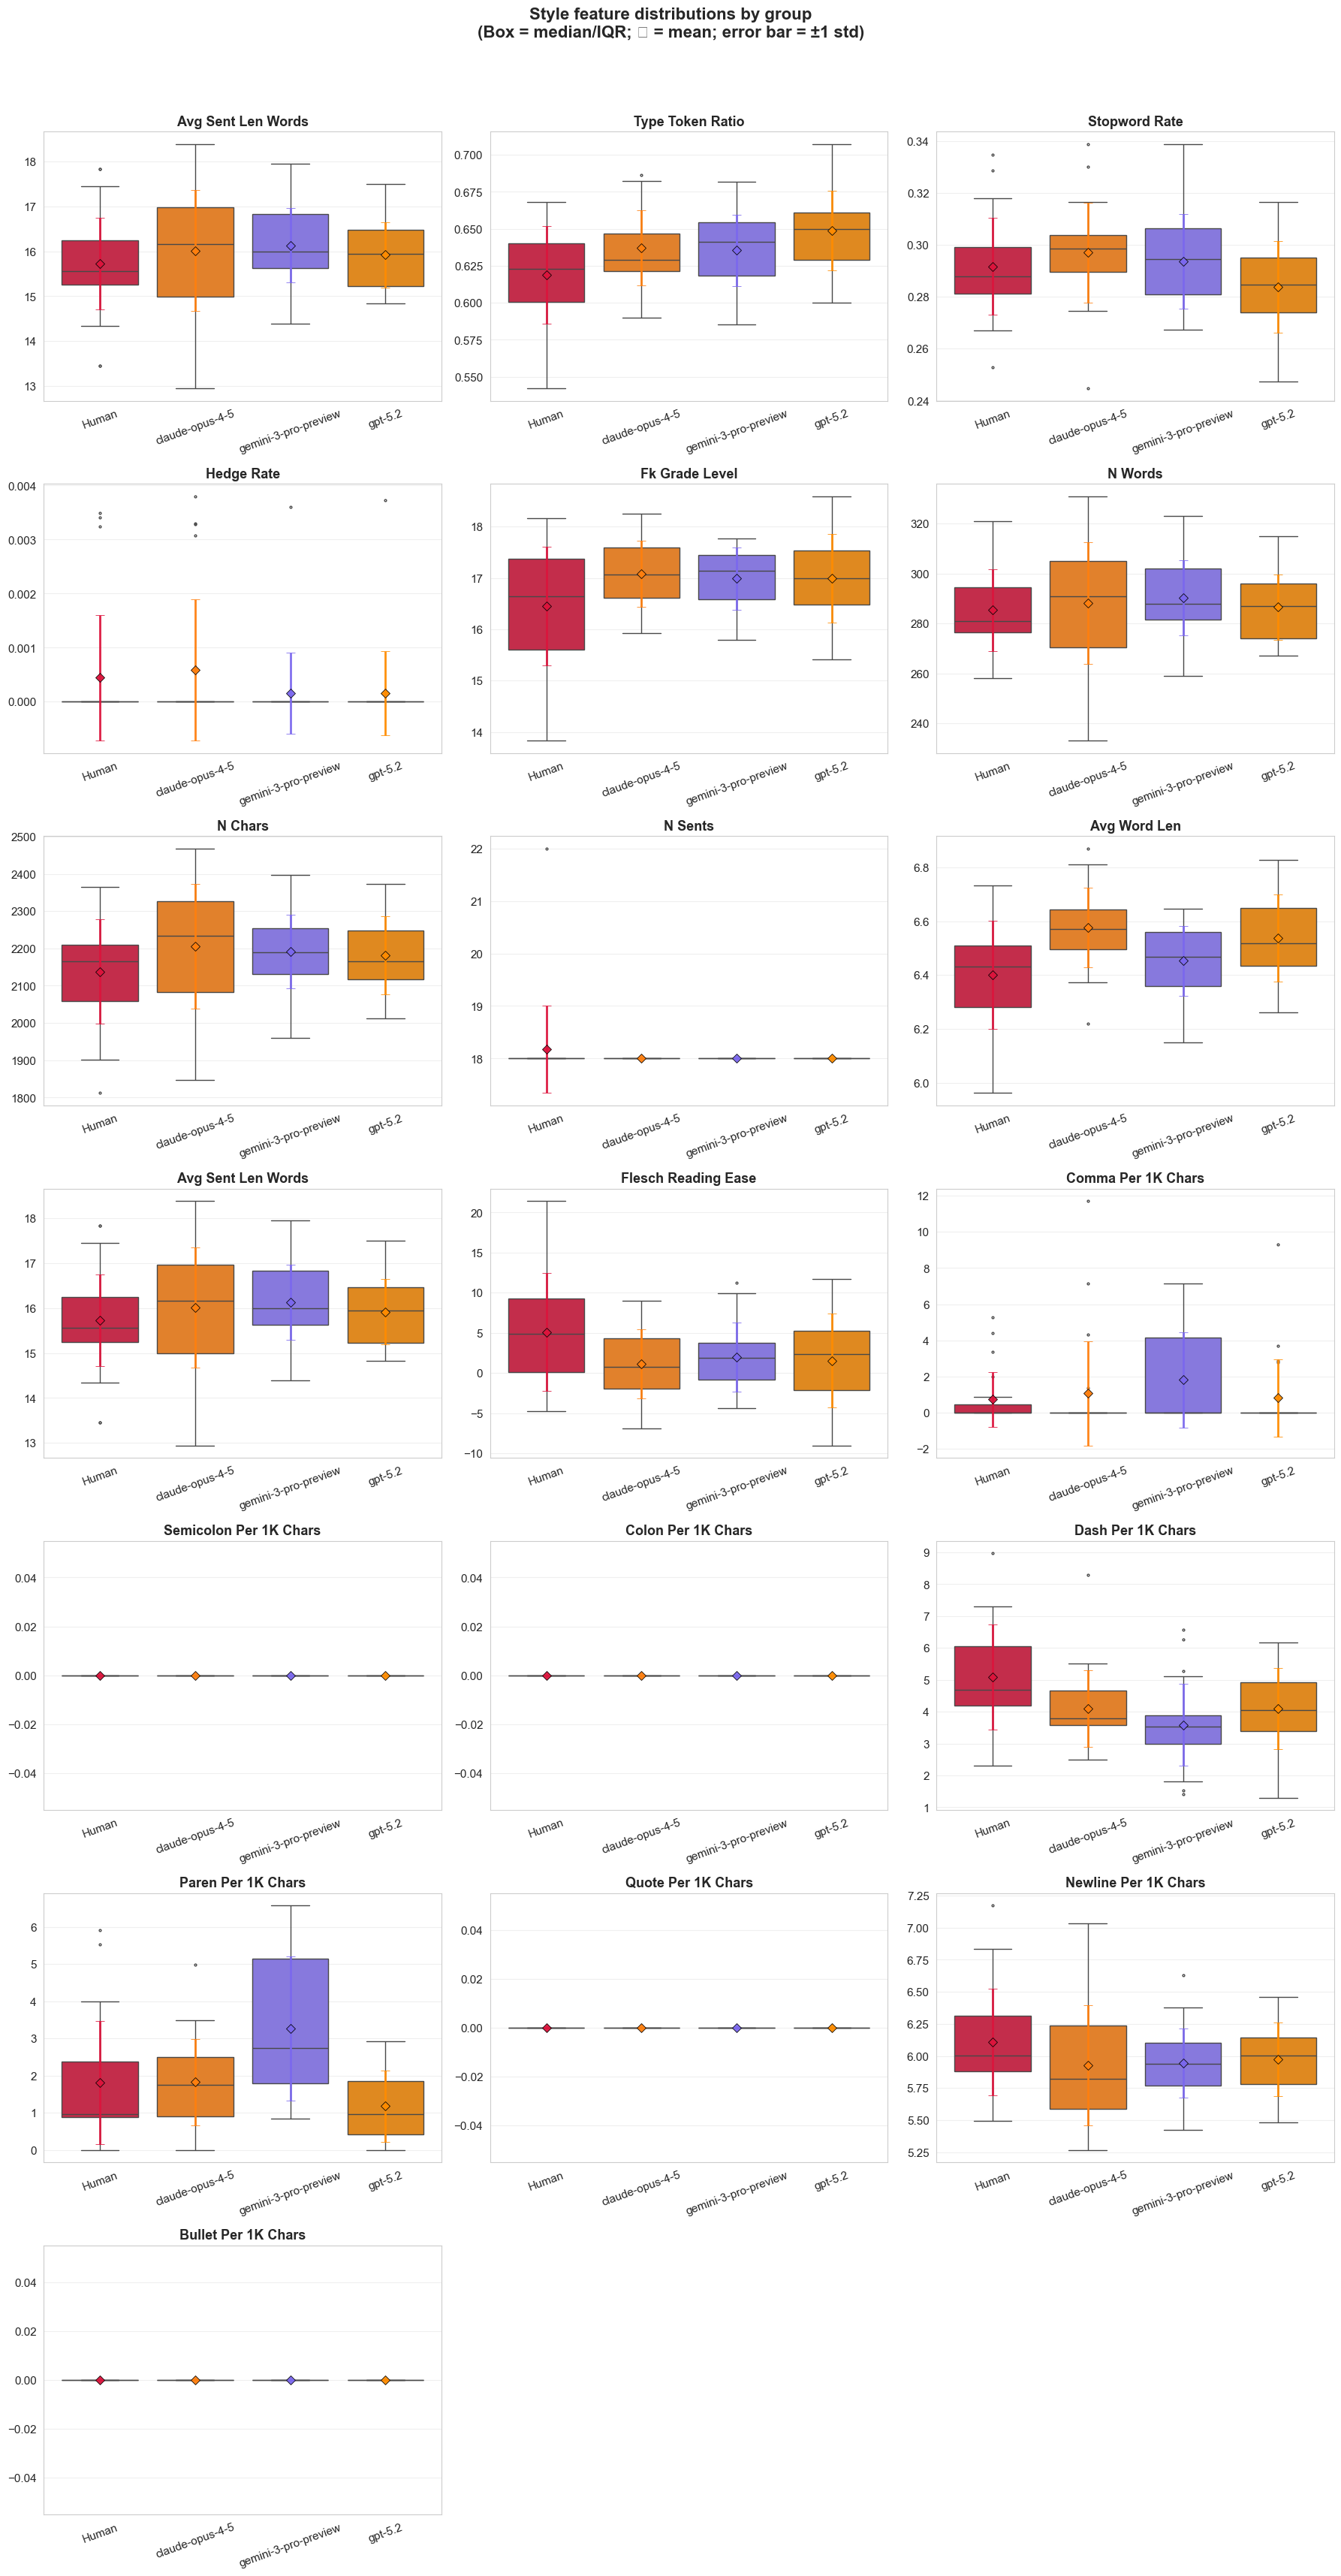

✓ Figure saved to: ../results/figures/rephrased/minimal/style_features_by_model_boxplots.png

Summary (mean / median / std) by group:
                     avg_sent_len_words                type_token_ratio               stopword_rate               hedge_rate               fk_grade_level                 n_words                  n_chars                  n_sents               avg_word_len               avg_sent_len_words                flesch_reading_ease               comma_per_1k_chars               semicolon_per_1k_chars             colon_per_1k_chars             dash_per_1k_chars               paren_per_1k_chars               quote_per_1k_chars             newline_per_1k_chars               bullet_per_1k_chars            
                                   mean  median    std             mean median    std          mean median    std       mean median    std           mean  median    std     mean median     std      mean  median      std    mean median    std         mean median    st

In [139]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots per feature across Human and each AI model
# Box = median/IQR, whiskers = spread, ◆ = mean, error bar = ±1 std

if 'style_df' not in globals():
    raise RuntimeError("style_df not found. Run the style feature extraction cell first.")
if 'ai_df' not in globals():
    raise RuntimeError("ai_df not found. Run the AI proposal loading cell first.")

# Reconstruct per-model labels aligned to style_df construction order: Human rows first, then AI rows
n_h = int((style_df['group'] == 'Human').sum()) if 'group' in style_df.columns else 0
if n_h == 0:
    n_h = len(human_df)

ai_model_labels = ai_df['model'].tolist()
expected_ai = len(style_df) - n_h
if len(ai_model_labels) != expected_ai:
    raise ValueError(
        f"Alignment error: style_df has {len(style_df)} rows with n_h={n_h}, expected {expected_ai} AI rows, "
        f"but ai_df['model'] has {len(ai_model_labels)} labels."
    )

style_plot = style_df.copy()
style_plot['group_model'] = (['Human'] * n_h) + ai_model_labels

# Compact, interpretable features for quick comparison
features_to_plot = [
    'avg_sent_len_words',
    'type_token_ratio',
    'stopword_rate',
    'hedge_rate',
    'fk_grade_level',
    'header_lines', 'n_words', 'n_chars', 'n_sents', 'avg_word_len', 'avg_sent_len_words', 'flesch_reading_ease', 'comma_per_1k_chars', 'semicolon_per_1k_chars', 'colon_per_1k_chars', 'dash_per_1k_chars', 'paren_per_1k_chars', 'quote_per_1k_chars', 'newline_per_1k_chars', 'bullet_per_1k_chars'
]
# features_to_plot = [f for f in features_to_plot if f in style_plot.columns]
features_to_plot = [f for f in features_to_plot if f in style_plot.columns]
# Prepare long DF
long_df = style_plot[['group_model'] + features_to_plot].replace([np.inf, -np.inf], np.nan)
for f in features_to_plot:
    long_df[f] = long_df[f].fillna(long_df[f].median())
long_df = long_df.melt(id_vars='group_model', var_name='feature', value_name='value')

# Group order (Human first, then models)
if 'ai_models' in globals():
    group_order = ['Human'] + [m for m in ai_models if m in set(style_plot['group_model'])]
else:
    group_order = ['Human'] + sorted([m for m in style_plot['group_model'].unique() if m != 'Human'])

# Plot subplots
n_feat = len(features_to_plot)
ncols = 3
nrows = int(np.ceil(n_feat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.8 * nrows))
axes = np.array(axes).reshape(-1)

# Use consistent group colors if defined earlier in the notebook
if 'colors' in globals() and isinstance(colors, dict):
    colors_local = dict(colors)
else:
    colors_local = {}

# Ensure every group has a color (fallback for any missing keys)
for idx, g in enumerate(group_order):
    colors_local.setdefault(g, f"C{idx % 10}")

palette_dict = {g: colors_local[g] for g in group_order}

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    df_f = long_df[long_df['feature'] == feat]

    # Boxes colored by group
    sns.boxplot(
        data=df_f, x='group_model', y='value', order=group_order,
        ax=ax, palette=palette_dict, fliersize=2
    )

    # Overlay mean ± std as colored diamonds (matches group color)
    stats = df_f.groupby('group_model')['value'].agg(['mean', 'std']).reindex(group_order)
    for xpos, g in enumerate(group_order):
        if g not in stats.index or pd.isna(stats.loc[g, 'mean']):
            continue
        m = float(stats.loc[g, 'mean'])
        s = float(stats.loc[g, 'std']) if not pd.isna(stats.loc[g, 'std']) else 0.0
        ax.errorbar(
            xpos, m, yerr=s,
            fmt='D',
            color=colors_local[g], ecolor=colors_local[g],
            elinewidth=2, capsize=4,
            markersize=6,
            markeredgecolor='black', markeredgewidth=0.6,
            alpha=0.95,
            zorder=10
        )

    ax.set_title(feat.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Style feature distributions by group\n(Box = median/IQR; ◆ = mean; error bar = ±1 std)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

out_path = FIGURES_DIR / 'style_features_by_model_boxplots.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {out_path}")

# Print a compact table of mean/median/std
summary = style_plot.groupby('group_model')[features_to_plot].agg(['mean', 'median', 'std']).round(3)
print("\nSummary (mean / median / std) by group:")
print(summary.to_string())

### Analysis 2.3.5: Style-only baseline (can style predict source?)

In [140]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

print("="*85)
print("STYLE-ONLY BASELINE: HUMAN VS AI")
print("="*85)

feature_cols = [c for c in style_df.columns if c not in {'group','is_ai'}]
print(f"features: {feature_cols}")
X = style_df[feature_cols].replace([np.inf, -np.inf], np.nan).values
y = style_df['is_ai'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced', solver='liblinear', random_state=42)
)

auc_scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
bal_scores = cross_val_score(clf, X, y, cv=cv, scoring='balanced_accuracy')

print(f"CV AUROC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
print(f"CV balanced accuracy: {bal_scores.mean():.3f} ± {bal_scores.std():.3f}")

obs_score, perm_scores, p_value = permutation_test_score(
    clf, X, y, cv=cv, scoring='roc_auc', n_permutations=1000, n_jobs=-1, random_state=42
)

print()
print("Permutation test (AUROC, 1,000 label shuffles):")
print(f"  Observed AUROC: {obs_score:.3f}")
print(f"  Null mean AUROC: {perm_scores.mean():.3f} ± {perm_scores.std():.3f}")
print(f"  p-value: {p_value:.4f}")
print("  Note: Imputation now occurs INSIDE each CV fold (no leakage).")

if obs_score >= 0.80:
    print("  → Strong evidence that style alone separates Human vs AI.")
elif obs_score >= 0.60:
    print("  → Moderate evidence that style contributes to separation.")
else:
    print("  → Style-only separation is weak; downstream separation is less likely to be purely stylistic.")


STYLE-ONLY BASELINE: HUMAN VS AI
features: ['n_words', 'n_chars', 'n_sents', 'avg_word_len', 'avg_sent_len_words', 'type_token_ratio', 'stopword_rate', 'hedge_rate', 'flesch_reading_ease', 'fk_grade_level', 'comma_per_1k_chars', 'semicolon_per_1k_chars', 'colon_per_1k_chars', 'dash_per_1k_chars', 'paren_per_1k_chars', 'quote_per_1k_chars', 'newline_per_1k_chars', 'bullet_per_1k_chars']
CV AUROC: 0.695 ± 0.098
CV balanced accuracy: 0.667 ± 0.072

Permutation test (AUROC, 1,000 label shuffles):
  Observed AUROC: 0.695
  Null mean AUROC: 0.504 ± 0.096
  p-value: 0.0190
  Note: Imputation now occurs INSIDE each CV fold (no leakage).
  → Moderate evidence that style contributes to separation.


In [141]:
# ── Most predictive STYLE features (interpretable coefficients) ───────────────
import numpy as np
import pandas as pd

print("="*85)
print("TOP STYLE FEATURES PREDICTING AI VS HUMAN (LogReg coefficients)")
print("="*85)

# Fit the SAME pipeline on all data for interpretation
clf.fit(X, y)

# Pull fitted components
imputer = clf.named_steps['simpleimputer']
scaler  = clf.named_steps['standardscaler']
logreg  = clf.named_steps['logisticregression']

# Feature names from the current cell
feature_names = list(feature_cols)

# Coefs correspond to *scaled* features (comparable magnitudes)
coefs = logreg.coef_.ravel()  # shape: (n_features,)

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

k = min(15, len(coef_df))

print(f"\nTop {k} strongest predictors (by |coef|):")
print(coef_df.head(k)[['feature','coef']].to_string(index=False))

# Directional lists
ai_like = coef_df.sort_values('coef', ascending=False).head(k)[['feature','coef']]
human_like = coef_df.sort_values('coef', ascending=True).head(k)[['feature','coef']]

print(f"\nTop {k} features pushing prediction toward AI (positive coef):")
print(ai_like.to_string(index=False))

print(f"\nTop {k} features pushing prediction toward Human (negative coef):")
print(human_like.to_string(index=False))

print("\nNote: coefficients are on standardized features (after imputation + scaling).")
print("      Positive = more AI-like; Negative = more Human-like.")


TOP STYLE FEATURES PREDICTING AI VS HUMAN (LogReg coefficients)

Top 15 strongest predictors (by |coef|):
               feature      coef
      type_token_ratio  0.952736
     dash_per_1k_chars -0.862503
          avg_word_len  0.736641
    avg_sent_len_words  0.471680
               n_sents -0.423071
   flesch_reading_ease  0.403077
               n_words  0.353078
            hedge_rate -0.237505
        fk_grade_level -0.232815
               n_chars  0.231593
    comma_per_1k_chars  0.106999
    paren_per_1k_chars  0.072680
         stopword_rate  0.053844
  newline_per_1k_chars  0.007648
semicolon_per_1k_chars  0.000000

Top 15 features pushing prediction toward AI (positive coef):
               feature      coef
      type_token_ratio  0.952736
          avg_word_len  0.736641
    avg_sent_len_words  0.471680
   flesch_reading_ease  0.403077
               n_words  0.353078
               n_chars  0.231593
    comma_per_1k_chars  0.106999
    paren_per_1k_chars  0.072680
      

#### Visualization: Style-only baseline results (CV + permutation test)

**How to read:** Left panel shows cross-validation fold performance (each dot = one CV fold; box = distribution). Right panel shows the permutation-test *null* distribution of AUROC when Human/AI labels are shuffled; the vertical red line is the observed AUROC—if it sits far in the right tail, style alone separates groups beyond chance (small p-value).

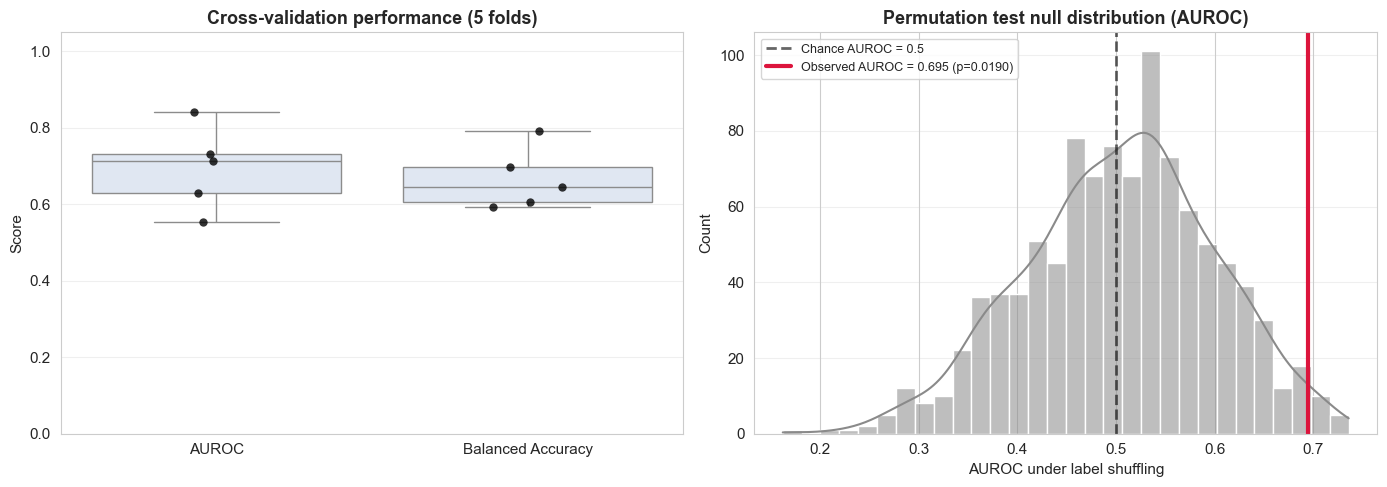

✓ Figure saved to: ../results/figures/rephrased/minimal/style_only_baseline_viz.png

Interpretation:
- Left: tighter boxes/points = stable CV estimates; higher = better separation.
- Right: if the red line is far to the right of the gray histogram, the result is unlikely under chance (small p).


In [142]:
# Visualization for style-only baseline results
import matplotlib.pyplot as plt

# 1) CV fold distributions (AUROC + balanced accuracy)
cv_plot_df = pd.DataFrame({
    'Fold': np.arange(1, len(auc_scores) + 1),
    'AUROC': auc_scores,
    'Balanced Accuracy': bal_scores,
})
cv_long = cv_plot_df.melt(id_vars='Fold', var_name='Metric', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CV score distributions
ax = axes[0]
sns.boxplot(data=cv_long, x='Metric', y='Score', ax=ax, color='#DDE6F5', fliersize=2)
sns.stripplot(data=cv_long, x='Metric', y='Score', ax=ax, color='black', size=6, jitter=0.12, alpha=0.8)
ax.set_title('Cross-validation performance (5 folds)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0.0, 1.05)
ax.grid(axis='y', alpha=0.3)

# Right: permutation null distribution
ax = axes[1]
sns.histplot(perm_scores, bins=30, kde=True, ax=ax, color='#8A8A8A', alpha=0.55)
ax.axvline(0.5, color='black', linestyle='--', linewidth=2, alpha=0.6, label='Chance AUROC = 0.5')
ax.axvline(obs_score, color='crimson', linestyle='-', linewidth=3,
           label=f'Observed AUROC = {obs_score:.3f} (p={p_value:.4f})')
ax.set_title('Permutation test null distribution (AUROC)', fontsize=13, fontweight='bold')
ax.set_xlabel('AUROC under label shuffling')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()

out_path = FIGURES_DIR / 'style_only_baseline_viz.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {out_path}")
print("\nInterpretation:")
print("- Left: tighter boxes/points = stable CV estimates; higher = better separation.")
print("- Right: if the red line is far to the right of the gray histogram, the result is unlikely under chance (small p).")

### Analysis 2.3.6A: Style-controlled sensitivity via residualization

In [143]:
import pickle
from pathlib import Path
import numpy as np

# ── Load embeddings from cache if not already in scope ───────────────────────
if 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    _emb_path = REPHRASED_EMBEDDINGS_FILE
    if not _emb_path.exists():
        legacy_paths = sorted(_emb_path.parent.glob('proposal_embeddings_[0-9]*.pkl'))
        if not legacy_paths:
            raise FileNotFoundError(f"No embedding cache found at {_emb_path}. Run the embedding cell first.")
        _emb_path = legacy_paths[-1]
    _data = pickle.load(open(_emb_path, 'rb'))
    human_embeddings = _data['human_embeddings']
    ai_embeddings    = _data['ai_embeddings']
    human_metadata   = _data['human_metadata']
    ai_metadata      = _data['ai_metadata']
    print(f"Loaded embeddings from {_emb_path.name}  "
          f"(human={human_embeddings.shape}, ai={ai_embeddings.shape})")

from sklearn.metrics.pairwise import cosine_distances

print("="*85)
print("STYLE-CONTROLLED EMBEDDING OUTCOMES (RESIDUALIZATION)")
print("="*85)

if 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found in workspace variables (expected `human_embeddings` and `ai_embeddings`).")
else:
    # Align document order: Human first, then AI (matches style_df build above)
    E_h = np.asarray(human_embeddings)
    E_a = np.asarray(ai_embeddings)
    E = np.vstack([E_h, E_a])
    group = np.array([0] * len(E_h) + [1] * len(E_a))  # 0=Human, 1=AI

    # Style covariates (compact set)
    cov_cols = [c for c in style_df.columns if c not in {'group', 'is_ai'}]  # all style features
    cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    cov = StandardScaler().fit_transform(cov)

    # Outcomes from embeddings
    centroid_all = E.mean(axis=0, keepdims=True)
    dist_to_all = cosine_distances(E, centroid_all).ravel()

    centroid_h = E_h.mean(axis=0, keepdims=True)
    centroid_a = E_a.mean(axis=0, keepdims=True)
    dist_to_group = np.where(group == 0,
                             cosine_distances(E, centroid_h).ravel(),
                             cosine_distances(E, centroid_a).ravel())

    def _ols_group_coef(y, g, covariates):
        X = np.column_stack([np.ones(len(y)), g.astype(float), covariates])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        return beta[1], beta

    def perm_test_group_coef(y, g, covariates, n_perm=5000, seed=42):
        rng = np.random.default_rng(seed)
        obs_coef, _ = _ols_group_coef(y, g, covariates)
        null = np.zeros(n_perm, dtype=float)
        for i in range(n_perm):
            g_perm = rng.permutation(g)
            null[i], _ = _ols_group_coef(y, g_perm, covariates)
        p_two = (np.mean(np.abs(null) >= abs(obs_coef)) + 1) / (n_perm + 1)
        return obs_coef, null, p_two

    def summarize_outcome(name, y):
        mean_h = float(np.mean(y[group == 0]))
        mean_a = float(np.mean(y[group == 1]))
        print(f"\nOutcome: {name}")
        print(f"  Unadjusted means: Human={mean_h:.4f}, AI={mean_a:.4f}, (AI-Human)={mean_a-mean_h:+.4f}")
        coef, null, p = perm_test_group_coef(y, group, cov, n_perm=5000, seed=42)
        print(f"  Style-adjusted group coef (AI indicator): {coef:+.6f}")
        print(f"  Permutation p (two-sided, 5,000 shuffles): {p:.4f}")

    summarize_outcome('Cosine distance to overall centroid', dist_to_all)
    summarize_outcome('Cosine distance to own-group centroid', dist_to_group)


STYLE-CONTROLLED EMBEDDING OUTCOMES (RESIDUALIZATION)

Outcome: Cosine distance to overall centroid
  Unadjusted means: Human=0.2115, AI=0.0602, (AI-Human)=-0.1513
  Style-adjusted group coef (AI indicator): -0.128136
  Permutation p (two-sided, 5,000 shuffles): 0.0002

Outcome: Cosine distance to own-group centroid
  Unadjusted means: Human=0.1927, AI=0.0577, (AI-Human)=-0.1351
  Style-adjusted group coef (AI indicator): -0.121963
  Permutation p (two-sided, 5,000 shuffles): 0.0002


### Style-adjusted centroid dispersion (All Groups vs Human)


These tests repeat the same Mann–Whitney U, Cliff’s delta, and permutation test comparisons as the unadjusted centroid-dispersion section, but using **style-adjusted (residualized)** distances-to-own-group-centroid.

Compute each proposal’s distance-to-its-group-centroid (y_raw).
Fit a simple linear model: y_raw ~ (style features).
Subtract the model’s prediction from y_raw to get a residual.
Add back the overall mean (just to keep numbers on a similar scale).
Result: y_adj = “dispersion after removing what style can explain”.
Statistical tests on style-adjusted dispersion:
Same tests, just run on y_adj instead of y_raw.
So your MW / Cliff’s delta / permutation test become: “Are groups still different in dispersion after removing style effects?”

In [144]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

print("\n" + "="*85)
print("STATISTICAL TESTS: Style-adjusted Centroid Dispersion (All Groups vs Human)")
print("="*85)

# ---- helpers (define if not already in notebook) ----
if 'cliffs_delta' not in globals():
    def cliffs_delta(x, y):
        """Cliff's delta: P(x>y) - P(x<y)."""
        x = np.asarray(x)
        y = np.asarray(y)
        gt = 0
        lt = 0
        for xi in x:
            gt += np.sum(xi > y)
            lt += np.sum(xi < y)
        return (gt - lt) / (len(x) * len(y))

if 'interpret_cliffs_delta' not in globals():
    def interpret_cliffs_delta(d):
        ad = abs(d)
        if ad < 0.147:
            return 'negligible'
        if ad < 0.33:
            return 'small'
        if ad < 0.474:
            return 'medium'
        return 'large'

def _perm_test_mean_diff(x, y, n_perm=10000, seed=42):
    """Two-sided permutation test on mean difference: mean(x)-mean(y).

    Named uniquely to avoid conflicts with any earlier `permutation_test()` defined elsewhere in the notebook.
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    obs = float(np.mean(x) - np.mean(y))
    pooled = np.concatenate([x, y])
    n_x = len(x)
    null = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm = rng.permutation(pooled)
        null[i] = float(np.mean(perm[:n_x]) - np.mean(perm[n_x:]))
    p = (np.mean(np.abs(null) >= abs(obs)) + 1) / (n_perm + 1)
    return p, obs, null

# ---- compute y_adj robustly (don’t assume previous cell variables exist) ----
if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
elif 'ai_df' not in globals() or 'model_embeddings_dict' not in globals():
    print("⚠️ ai_df/model_embeddings_dict not found. Run the proposal loading/embedding setup cells first.")
else:
    # Align document order: Human first, then AI (matches style_df build above)
    E_h = np.asarray(human_embeddings)
    E_a = np.asarray(ai_embeddings)
    E = np.vstack([E_h, E_a])
    n_h, n_a = len(E_h), len(E_a)

    # Labels (Human first, then AI per-model)
    ai_model_labels = ai_df['model'].tolist()
    assert len(ai_model_labels) == n_a, "ai_df['model'] length must match ai_embeddings"
    labels = np.array((['Human'] * n_h) + ai_model_labels)

    # Group order consistent with earlier analyses
    if 'ai_models' in globals():
        ai_models_local = list(ai_models)
    else:
        ai_models_local = sorted(ai_df['model'].dropna().unique().tolist())
    group_order = ['Human'] + [m for m in ai_models_local if m in set(ai_model_labels)]

    # Raw distance-to-own-group-centroid
    y_raw = np.zeros(len(labels), dtype=float)
    for g in group_order:
        idx = np.where(labels == g)[0]
        if len(idx) == 0:
            continue
        centroid = E[idx].mean(axis=0, keepdims=True)
        y_raw[idx] = cosine_distances(E[idx], centroid).ravel()

    # Style residualization on y_raw
    cov_cols = [c for c in style_df.columns if c not in {'group', 'is_ai'}]  # all style features
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(y_raw)), X_cov])
    beta, *_ = np.linalg.lstsq(X, y_raw, rcond=None)
    y_pred = X @ beta
    y_adj = (y_raw - y_pred) + y_raw.mean()

    # Split adjusted distances
    human_adj = y_adj[labels == 'Human']
    ai_adj = y_adj[labels != 'Human']

    model_adj = {m: y_adj[labels == m] for m in group_order if m != 'Human'}

    # ---- tests ----
    adj_comparison_results = []

    print("\n" + "-"*85)
    print("Comparison: All AI (combined) vs Human [STYLE-ADJUSTED]")
    print("-"*85)

    u_stat, p_mw = mannwhitneyu(ai_adj, human_adj, alternative='two-sided')
    d = cliffs_delta(ai_adj, human_adj)
    d_interp = interpret_cliffs_delta(d)
    p_perm, obs_diff, _ = _perm_test_mean_diff(ai_adj, human_adj, n_perm=10000, seed=42)

    print("\nMann-Whitney U Test:")
    print(f"  U-statistic: {u_stat:,.0f}, p-value: {p_mw:.4e}")
    print("\nCliff's Delta:")
    print(f"  δ = {d:.4f} ({d_interp} effect)")
    if d > 0:
        print("  → All AI proposals are MORE dispersed from center (after style adjustment)")
    else:
        print("  → Human proposals are MORE dispersed from center (after style adjustment)")
    print("\nPermutation Test (10,000 permutations):")
    print(f"  Observed difference (mean AI - mean Human): {obs_diff:.4f}, p-value: {p_perm:.4f}")

    adj_comparison_results.append({
        'group': 'All AI',
        'u_stat': u_stat,
        'p_value_mw': p_mw,
        'delta': d,
        'delta_interp': d_interp,
        'p_value_perm': p_perm
    })

    for model in group_order:
        if model == 'Human':
            continue
        vals = model_adj.get(model)
        if vals is None or len(vals) == 0:
            continue

        print("\n" + "-"*85)
        print(f"Comparison: {model} vs Human [STYLE-ADJUSTED]")
        print("-"*85)

        u_stat_m, p_mw_m = mannwhitneyu(vals, human_adj, alternative='two-sided')
        d_m = cliffs_delta(vals, human_adj)
        d_interp_m = interpret_cliffs_delta(d_m)
        p_perm_m, obs_diff_m, _ = _perm_test_mean_diff(vals, human_adj, n_perm=10000, seed=42)

        print("\nMann-Whitney U Test:")
        print(f"  U-statistic: {u_stat_m:,.0f}, p-value: {p_mw_m:.4e}")
        print("\nCliff's Delta:")
        print(f"  δ = {d_m:.4f} ({d_interp_m} effect)")
        if d_m > 0:
            print(f"  → {model} proposals are MORE dispersed from center (after style adjustment)")
        else:
            print("  → Human proposals are MORE dispersed from center (after style adjustment)")
        print("\nPermutation Test (10,000 permutations):")
        print(f"  Observed difference (mean {model} - mean Human): {obs_diff_m:.4f}, p-value: {p_perm_m:.4f}")

        adj_comparison_results.append({
            'group': model,
            'u_stat': u_stat_m,
            'p_value_mw': p_mw_m,
            'delta': d_m,
            'delta_interp': d_interp_m,
            'p_value_perm': p_perm_m
        })

    # Summary table
    print("\n" + "="*85)
    print("SUMMARY: Effect Sizes (Cliff's Delta) - Style-adjusted Centroid Dispersion")
    print("="*85)
    print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
    print("-"*85)
    for r in adj_comparison_results:
        print(f"{r['group']:<30} {r['delta']:<12.4f} {r['delta_interp']:<20} {r['p_value_mw']:<15.4e}")
    print("="*85)
    print("\n💡 Positive δ = AI more dispersed; Negative δ = Human more dispersed (style-adjusted)")
    print("="*85)



STATISTICAL TESTS: Style-adjusted Centroid Dispersion (All Groups vs Human)

-------------------------------------------------------------------------------------
Comparison: All AI (combined) vs Human [STYLE-ADJUSTED]
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 418, p-value: 7.2127e-04

Cliff's Delta:
  δ = -0.4732 (medium effect)
  → Human proposals are MORE dispersed from center (after style adjustment)

Permutation Test (10,000 permutations):
  Observed difference (mean AI - mean Human): -0.0765, p-value: 0.0001

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human [STYLE-ADJUSTED]
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 183, p-value: 7.5157e-02

Cliff's Delta:
  δ = -0.3081 (small effect)
  → Human proposals are MORE dispersed from center (after style 

CENTROID DISPERSION: UNADJUSTED vs STYLE-ADJUSTED (RESIDUALIZED)


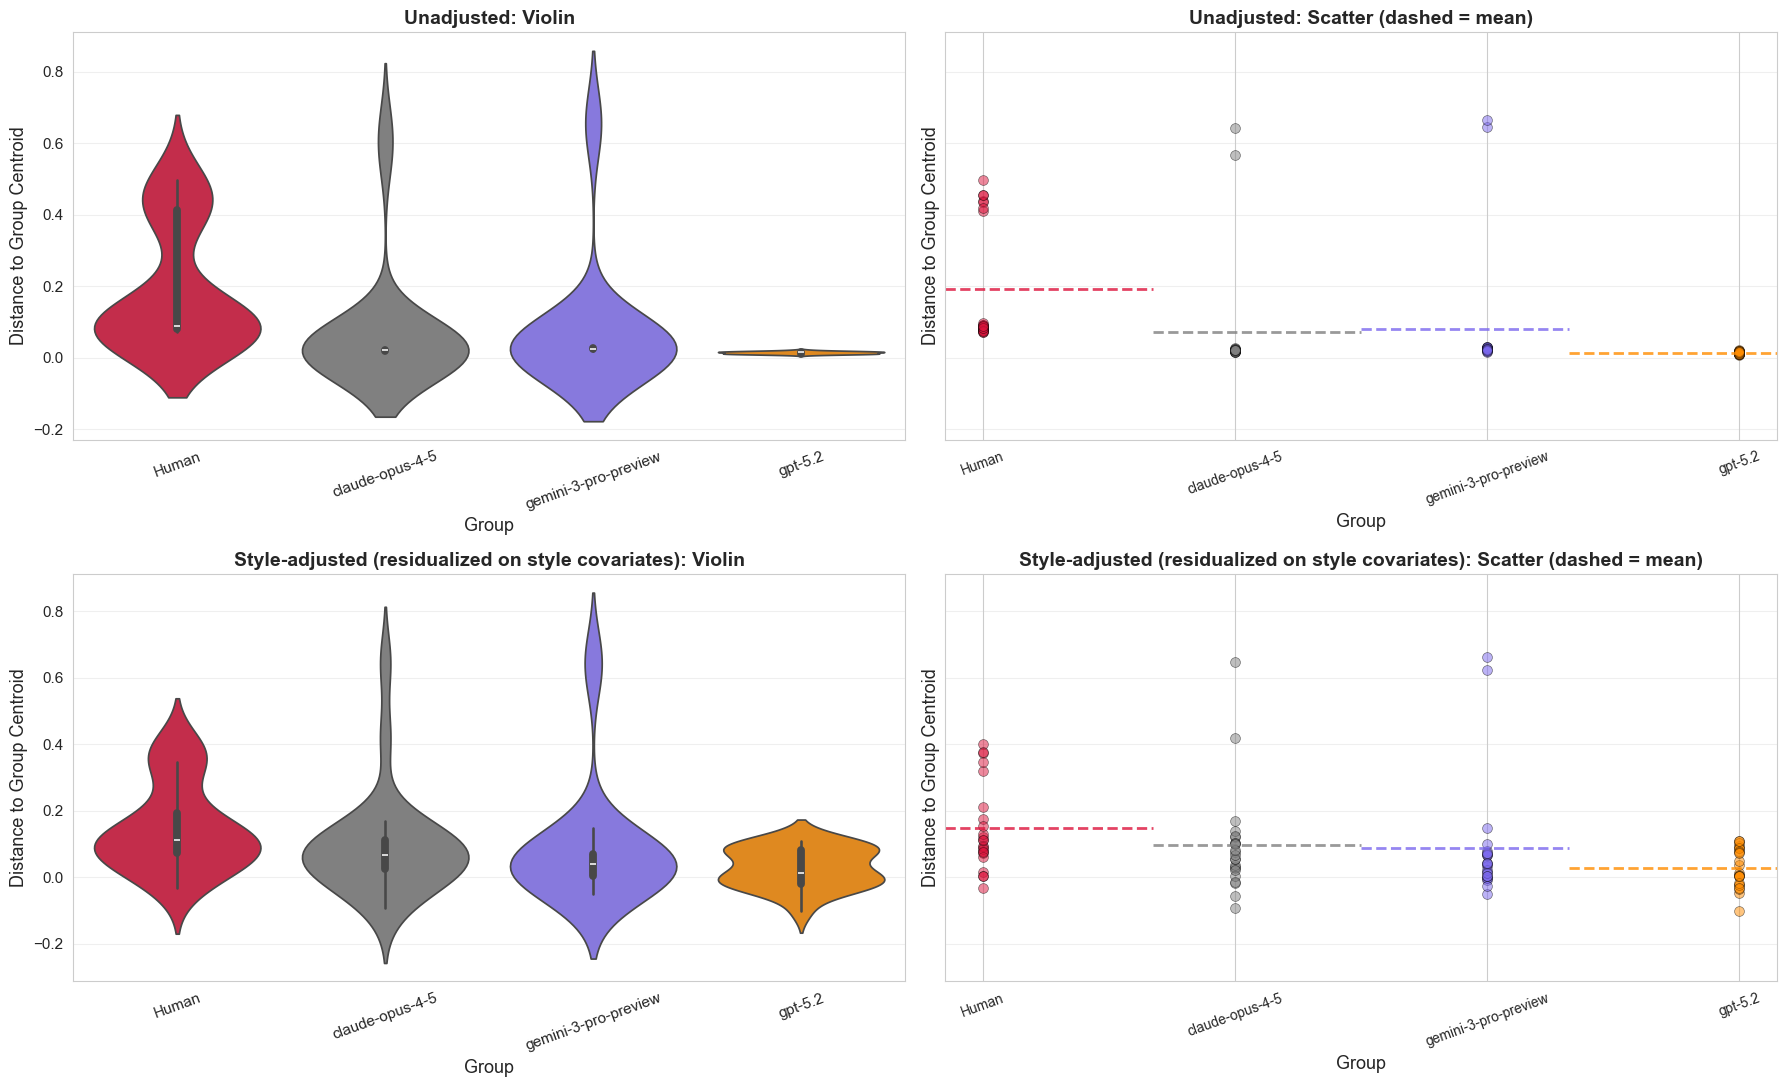

✓ Figure saved to: ../results/figures/rephrased/minimal/centroid_dispersion_style_adjusted.png

Note: 'Style-adjusted' removes linear effects of selected style covariates (not group).


In [145]:
# ----------------------------
# Visualization: centroid dispersion before vs after style residualization
# ----------------------------

from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler

print("="*85)
print("CENTROID DISPERSION: UNADJUSTED vs STYLE-ADJUSTED (RESIDUALIZED)")
print("="*85)

if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
else:
    # Labels (Human first, then AI) — match the style_df construction order
    n_h = len(human_embeddings)
    n_a = len(ai_embeddings)

    # Prefer the notebook's model list if available; otherwise derive from ai_df
    if 'ai_models' in globals():
        ai_models_local = list(ai_models)
    else:
        ai_models_local = sorted(ai_df['model'].dropna().unique().tolist())

    ai_model_labels = ai_df['model'].tolist()
    assert len(ai_model_labels) == n_a, "ai_df['model'] length must match ai_embeddings"

    labels = np.array((['Human'] * n_h) + ai_model_labels)

    # Embeddings matrix
    E = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])

    # Compute distance-to-own-group-centroid for each proposal (Human + each AI model)
    group_order = ['Human'] + [m for m in ai_models_local if m in set(ai_model_labels)]

    y_raw = np.zeros(len(labels), dtype=float)
    for g in group_order:
        idx = np.where(labels == g)[0]
        if len(idx) == 0:
            continue
        centroid = E[idx].mean(axis=0, keepdims=True)
        y_raw[idx] = cosine_distances(E[idx], centroid).ravel()

    # Style residualization (remove linear effect of style covariates; keep scale comparable)
    cov_cols = [c for c in style_df.columns if c not in {'group', 'is_ai'}]  # all style features
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(y_raw)), X_cov])
    beta, *_ = np.linalg.lstsq(X, y_raw, rcond=None)
    y_pred = X @ beta
    y_adj = (y_raw - y_pred) + y_raw.mean()  # residuals shifted back to original mean

    # Colors: reuse if present, else define a fallback
    if 'colors' in globals() and isinstance(colors, dict):
        colors_local = colors
    else:
        colors_local = {'Human': '#DC143C'}
        for i, m in enumerate(group_order[1:]):
            colors_local[m] = f"C{(i+1)%10}"

    def _plot_row(ax_violin, ax_scatter, y, row_title):
        # Build long DF
        plot_df = pd.DataFrame({'Group': labels, 'Distance to Centroid': y})

        palette_list = [colors_local.get(g, 'gray') for g in group_order]

        sns.violinplot(
            data=plot_df, x='Group', y='Distance to Centroid',
            order=group_order, palette=palette_list, ax=ax_violin
        )
        ax_violin.set_ylabel('Distance to Group Centroid', fontsize=13)
        ax_violin.set_xlabel('Group', fontsize=13)
        ax_violin.set_title(f'{row_title}: Violin', fontsize=14, fontweight='bold')
        ax_violin.tick_params(axis='x', rotation=20)
        ax_violin.grid(alpha=0.3, axis='y')

        # Scatter with per-group mean lines
        for xpos, g in enumerate(group_order):
            vals = plot_df.loc[plot_df['Group'] == g, 'Distance to Centroid'].values
            if len(vals) == 0:
                continue
            ax_scatter.scatter(
                [xpos] * len(vals), vals,
                alpha=0.5, color=colors_local.get(g, 'gray'),
                s=50, edgecolors='black', linewidth=0.5
            )
            ax_scatter.axhline(
                np.mean(vals),
                xmin=xpos/len(group_order), xmax=(xpos+1)/len(group_order),
                color=colors_local.get(g, 'gray'), linestyle='--', linewidth=2, alpha=0.8
            )

        ax_scatter.set_xticks(range(len(group_order)))
        ax_scatter.set_xticklabels(group_order, rotation=20, fontsize=10)
        ax_scatter.set_ylabel('Distance to Group Centroid', fontsize=13)
        ax_scatter.set_xlabel('Group', fontsize=13)
        ax_scatter.set_title(f'{row_title}: Scatter (dashed = mean)', fontsize=14, fontweight='bold')
        ax_scatter.grid(alpha=0.3, axis='y')

    fig, axes = plt.subplots(2, 2, figsize=(18, 11), sharey='row')
    _plot_row(axes[0, 0], axes[0, 1], y_raw, 'Unadjusted')
    _plot_row(axes[1, 0], axes[1, 1], y_adj, 'Style-adjusted (residualized on style covariates)')

    plt.tight_layout()
    out_path = FIGURES_DIR / 'centroid_dispersion_style_adjusted.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Figure saved to: {out_path}")
    print("\nNote: 'Style-adjusted' removes linear effects of selected style covariates (not group).")


### Style-adjust nearest-neighbor (NN) distances by residualizing embeddings


This removes the *linear* contribution of selected style covariates from the embedding vectors (dimension-wise OLS), then recomputes cosine NN distances on the residual embeddings (renormalized).

STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS (Metadata-aligned)

COMPUTING STYLE-ADJUSTED NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.3739     0.3448     0.1743     0.7176    

claude-opus-4-5                     23       0.4080     0.3895     0.1009     0.7402    
gemini-3-pro-preview                23       0.4289     0.4020     0.1599     0.7736    
gpt-5.2                             23       0.4356     0.3683     0.1009     0.7733    

All AI (combined)                   69       0.4242     0.3800     0.1009     0.7736    

💡 INTERPRETATION:
   - Higher mean NN distance = more isolated proposals (outliers)
   - Lower mean NN distance = proposals cluster together
   - Distances are computed AFTER removing linear embedding variation explained by style covariates

O

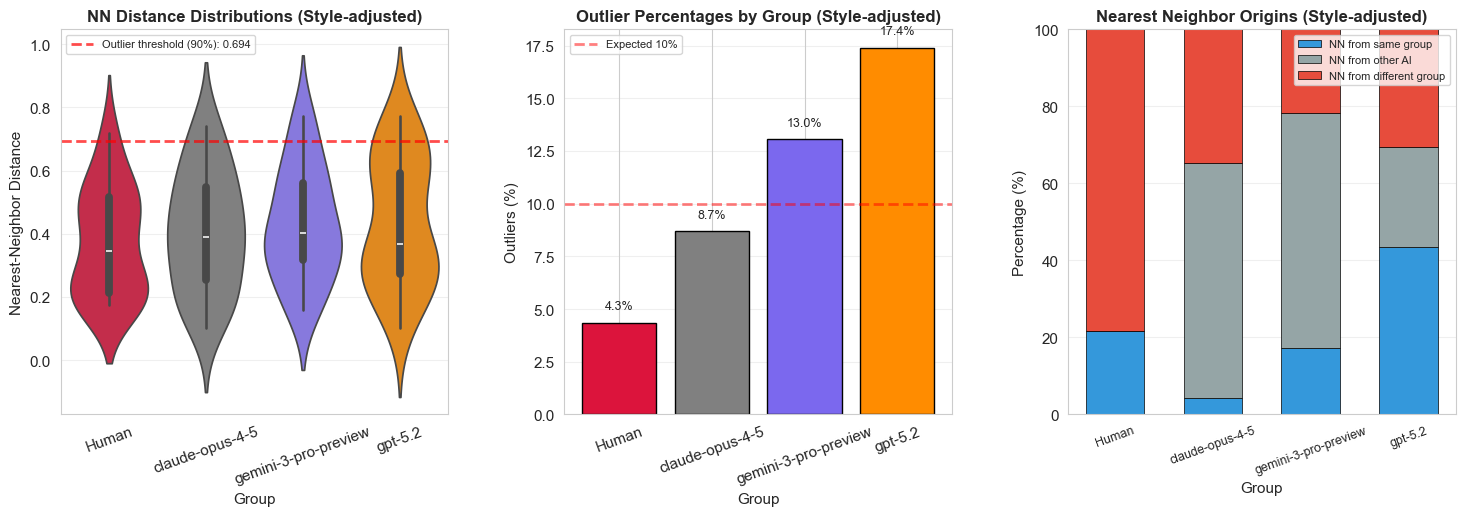


✓ Figure saved to: ../results/figures/rephrased/minimal/nearest_neighbor_by_model_style_adjusted.png

Note: This mirrors the unadjusted NN pipeline, but all distances are computed in residual (style-adjusted) embedding space.


In [146]:
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

print("="*85)
print("STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS (Metadata-aligned)")
print("="*85)

if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
else:
    # ----------------------------
    # 0) Build per-row labels that match embedding order
    # ----------------------------
    n_human = len(human_embeddings)
    n_ai = len(ai_embeddings)

    if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == n_ai:
        ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
    elif 'ai_df' in globals() and len(ai_df) == n_ai and 'model' in ai_df.columns:
        print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
        ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
    else:
        raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

    labels = np.array((['Human'] * n_human) + ai_model_labels)

    # Stable group order
    if 'ai_models' in globals():
        ai_models_local = [m for m in list(ai_models) if m in set(ai_model_labels)]
    else:
        ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

    group_order = ['Human'] + ai_models_local

    # ----------------------------
    # 1) Build embedding matrix (Human first, then AI) and residualize on style
    # ----------------------------
    all_embeddings = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])

    cov_cols = [c for c in style_df.columns if c not in {'group', 'is_ai'}]  # all style features
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(X_cov)), X_cov])

    B, *_ = np.linalg.lstsq(X, all_embeddings, rcond=None)
    all_embeddings_resid = all_embeddings - (X @ B)
    all_embeddings_resid = all_embeddings_resid / (np.linalg.norm(all_embeddings_resid, axis=1, keepdims=True) + 1e-12)

    # ----------------------------
    # 2) Compute full distance matrix + NN distances (STYLE-ADJUSTED)
    # ----------------------------
    print("\n" + "="*85)
    print("COMPUTING STYLE-ADJUSTED NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS")
    print("="*85)

    all_distances_adj = cosine_distances(all_embeddings_resid)
    np.fill_diagonal(all_distances_adj, np.inf)
    nn_distances_adj = all_distances_adj.min(axis=1)

    # Group-wise NN distances
    human_nn_dists_adj = nn_distances_adj[labels == 'Human']
    ai_nn_dists_adj = nn_distances_adj[labels != 'Human']

    model_nn_dists_adj = {g: nn_distances_adj[labels == g] for g in ai_models_local}

    # Print statistics table
    print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
    print("-"*85)
    print(f"{'Human':<35} {len(human_nn_dists_adj):<8} {human_nn_dists_adj.mean():<10.4f} {np.median(human_nn_dists_adj):<10.4f} {human_nn_dists_adj.min():<10.4f} {human_nn_dists_adj.max():<10.4f}")
    print()
    for model in ai_models_local:
        dists = model_nn_dists_adj[model]
        print(f"{model:<35} {len(dists):<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.min():<10.4f} {dists.max():<10.4f}")
    print()
    print(f"{'All AI (combined)':<35} {len(ai_nn_dists_adj):<8} {ai_nn_dists_adj.mean():<10.4f} {np.median(ai_nn_dists_adj):<10.4f} {ai_nn_dists_adj.min():<10.4f} {ai_nn_dists_adj.max():<10.4f}")

    print("="*85)
    print("\n💡 INTERPRETATION:")
    print("   - Higher mean NN distance = more isolated proposals (outliers)")
    print("   - Lower mean NN distance = proposals cluster together")
    print("   - Distances are computed AFTER removing linear embedding variation explained by style covariates")
    print("="*85)

    # ----------------------------
    # 3) Outlier detection (top 10% NN distances) - STYLE-ADJUSTED
    # ----------------------------
    threshold_adj = np.percentile(nn_distances_adj, 90)
    outliers_adj = nn_distances_adj > threshold_adj

    human_outliers_adj = int(outliers_adj[labels == 'Human'].sum())
    ai_outliers_adj = int(outliers_adj[labels != 'Human'].sum())
    model_outliers_adj = {g: int(outliers_adj[labels == g].sum()) for g in ai_models_local}

    print("\n" + "="*85)
    print("OUTLIER DETECTION (Top 10% NN distance) — STYLE-ADJUSTED")
    print("="*85)
    print(f"Threshold distance: {threshold_adj:.4f}")
    print()
    print(f"{'GROUP':<35} {'Outliers':<15} {'Total':<10} {'Percentage':<15}")
    print("-"*85)
    print(f"{'Human':<35} {human_outliers_adj:<15} {n_human:<10} {human_outliers_adj/n_human*100:<15.1f}%")
    print()
    for model in ai_models_local:
        n_model = int((labels == model).sum())
        print(f"{model:<35} {model_outliers_adj[model]:<15} {n_model:<10} {model_outliers_adj[model]/n_model*100:<15.1f}%")
    print()
    print(f"{'All AI (combined)':<35} {ai_outliers_adj:<15} {n_ai:<10} {ai_outliers_adj/n_ai*100:<15.1f}%")
    print("="*85)

    # ----------------------------
    # 4) Nearest-neighbor origin analysis — STYLE-ADJUSTED
    # ----------------------------
    nn_indices_adj = all_distances_adj.argmin(axis=1)
    nn_labels_adj = labels[nn_indices_adj]

    human_nn_same_group_adj = int((nn_labels_adj[labels == 'Human'] == 'Human').sum())
    human_nn_diff_group_adj = int(n_human - human_nn_same_group_adj)

    ai_nn_same_group_adj = int((nn_labels_adj[labels != 'Human'] != 'Human').sum())
    ai_nn_diff_group_adj = int(n_ai - ai_nn_same_group_adj)

    model_nn_analysis_adj = {}
    for model in ai_models_local:
        mask = labels == model
        total = int(mask.sum())
        nn_from_human = int((nn_labels_adj[mask] == 'Human').sum())
        nn_from_same_model = int((nn_labels_adj[mask] == model).sum())
        nn_from_other_ai = int(total - nn_from_human - nn_from_same_model)
        model_nn_analysis_adj[model] = {
            'from_human': nn_from_human,
            'from_same_model': nn_from_same_model,
            'from_other_ai': nn_from_other_ai,
            'total': total
        }

    print("\n" + "="*85)
    print("NEAREST NEIGHBOR GROUP ANALYSIS — STYLE-ADJUSTED")
    print("="*85)

    print(f"\n{'Human proposals:':<50}")
    print(f"  NN from same group (human): {human_nn_same_group_adj} ({human_nn_same_group_adj/n_human*100:.1f}%)")
    print(f"  NN from different group (AI): {human_nn_diff_group_adj} ({human_nn_diff_group_adj/n_human*100:.1f}%)")

    print(f"\n{'All AI proposals (combined):':<50}")
    print(f"  NN from same group (AI): {ai_nn_same_group_adj} ({ai_nn_same_group_adj/n_ai*100:.1f}%)")
    print(f"  NN from different group (human): {ai_nn_diff_group_adj} ({ai_nn_diff_group_adj/n_ai*100:.1f}%)")

    print("\n" + "-"*85)
    print("Per-Model NN Group Breakdown:")
    print("-"*85)

    for model in ai_models_local:
        data = model_nn_analysis_adj[model]
        print(f"\n{model}:")
        print(f"  NN from Human: {data['from_human']} ({data['from_human']/data['total']*100:.1f}%)")
        print(f"  NN from same model: {data['from_same_model']} ({data['from_same_model']/data['total']*100:.1f}%)")
        print(f"  NN from other AI models: {data['from_other_ai']} ({data['from_other_ai']/data['total']*100:.1f}%)")

    print("\n" + "="*85)
    print("\n💡 INTERPRETATION:")
    print("   - High 'NN from same model' = model produces similar proposals")
    print("   - High 'NN from Human' = model proposals resemble human work")
    print("   - All computed in style-adjusted residual embedding space")
    print("="*85)

    # ----------------------------
    # 5) Statistical tests vs Human (same tests) — STYLE-ADJUSTED
    # ----------------------------
    print("\n" + "="*85)
    print("STATISTICAL TESTS: NN Distances (All Groups vs Human) — STYLE-ADJUSTED")
    print("="*85)

    nn_comparison_results_adj = []

    print("\n" + "-"*85)
    print("Comparison: All AI (combined) vs Human")
    print("-"*85)

    u_stat_nn, p_value_nn = mannwhitneyu(ai_nn_dists_adj, human_nn_dists_adj, alternative='two-sided')
    delta_nn = cliffs_delta(ai_nn_dists_adj, human_nn_dists_adj)
    delta_nn_interp = interpret_cliffs_delta(delta_nn)
    p_value_perm_nn, obs_diff_nn, _ = permutation_test(ai_nn_dists_adj, human_nn_dists_adj)

    print(f"\nMann-Whitney U Test:")
    print(f"  U-statistic: {u_stat_nn:,.0f}, p-value: {p_value_nn:.4e}")
    print(f"\nCliff's Delta:")
    print(f"  δ = {delta_nn:.4f} ({delta_nn_interp} effect)")
    if delta_nn > 0:
        print(f"  → All AI proposals have MORE unique/outlier ideas (style-adjusted)")
    else:
        print(f"  → Human proposals have MORE unique/outlier ideas (style-adjusted)")
    print(f"\nPermutation Test (10,000 permutations):")
    print(f"  Observed difference: {obs_diff_nn:.4f}, p-value: {p_value_perm_nn:.4f}")

    nn_comparison_results_adj.append({
        'group': 'All AI',
        'u_stat': u_stat_nn,
        'p_value_mw': p_value_nn,
        'delta': delta_nn,
        'delta_interp': delta_nn_interp,
        'p_value_perm': p_value_perm_nn
    })

    for model in ai_models_local:
        if model in model_nn_dists_adj:
            print("\n" + "-"*85)
            print(f"Comparison: {model} vs Human")
            print("-"*85)

            u_stat_model, p_value_mw_model = mannwhitneyu(model_nn_dists_adj[model], human_nn_dists_adj, alternative='two-sided')
            delta_model = cliffs_delta(model_nn_dists_adj[model], human_nn_dists_adj)
            delta_interp_model = interpret_cliffs_delta(delta_model)
            p_value_perm_model, obs_diff_model, _ = permutation_test(model_nn_dists_adj[model], human_nn_dists_adj)

            print(f"\nMann-Whitney U Test:")
            print(f"  U-statistic: {u_stat_model:,.0f}, p-value: {p_value_mw_model:.4e}")
            print(f"\nCliff's Delta:")
            print(f"  δ = {delta_model:.4f} ({delta_interp_model} effect)")
            if delta_model > 0:
                print(f"  → {model} proposals have MORE unique/outlier ideas (style-adjusted)")
            else:
                print(f"  → Human proposals have MORE unique/outlier ideas (style-adjusted)")
            print(f"\nPermutation Test (10,000 permutations):")
            print(f"  Observed difference: {obs_diff_model:.4f}, p-value: {p_value_perm_model:.4f}")

            nn_comparison_results_adj.append({
                'group': model,
                'u_stat': u_stat_model,
                'p_value_mw': p_value_mw_model,
                'delta': delta_model,
                'delta_interp': delta_interp_model,
                'p_value_perm': p_value_perm_model
            })

    print("\n" + "="*85)
    print("SUMMARY: Effect Sizes (Cliff's Delta) - NN Distances (Style-adjusted)")
    print("="*85)
    print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
    print("-"*85)
    for result in nn_comparison_results_adj:
        print(f"{result['group']:<30} {result['delta']:<12.4f} {result['delta_interp']:<20} {result['p_value_mw']:<15.4e}")
    print("="*85)
    print("\n💡 Positive δ = AI more outlier-prone; Negative δ = Human more outlier-prone (style-adjusted)")
    print("="*85)

    # ----------------------------
    # 6) Visualization (same 3-panel layout) — STYLE-ADJUSTED
    # ----------------------------
    fig = plt.figure(figsize=(18, 5))
    gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

    # Colors (reuse global mapping)
    if 'colors' in globals() and isinstance(colors, dict):
        colors_local = dict(colors)
    else:
        colors_local = {'Human': 'steelblue'}

    # 1. NN distance distributions by group
    ax1 = fig.add_subplot(gs[0, 0])
    nn_data = []
    for dist, label in [(human_nn_dists_adj, 'Human')] + [(model_nn_dists_adj[m], m) for m in ai_models_local if m in model_nn_dists_adj]:
        for val in dist:
            nn_data.append({'NN Distance': val, 'Group': label})

    nn_df = pd.DataFrame(nn_data)
    group_order_viz = ['Human'] + [m for m in ai_models_local if m in model_nn_dists_adj]
    palette_list = [colors_local.get(g, 'gray') for g in group_order_viz]

    sns.violinplot(data=nn_df, x='Group', y='NN Distance', ax=ax1, palette=palette_list,
                   order=group_order_viz, cut=0)  # cut=0 clips KDE at data min/max (prevents negative bleed)
    ax1.axhline(threshold_adj, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Outlier threshold (90%): {threshold_adj:.3f}')
    ax1.set_ylim(bottom=0)  # hard floor at 0 as a second safety net
    ax1.set_ylabel('Nearest-Neighbor Distance', fontsize=11)
    ax1.set_xlabel('Group', fontsize=11)
    ax1.set_title('NN Distance Distributions (Style-adjusted)', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='x', rotation=20)
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3, axis='y')

    # 2. Outlier counts by group
    ax2 = fig.add_subplot(gs[0, 1])
    outlier_data = []
    outlier_data.append({'Group': 'Human', 'Outliers': human_outliers_adj, 'Total': n_human, 'Percentage': human_outliers_adj/n_human*100})
    for model in ai_models_local:
        if model in model_outliers_adj:
            n_model = len(model_embeddings_dict.get(model, []))
            outlier_data.append({'Group': model, 'Outliers': model_outliers_adj[model], 'Total': n_model, 'Percentage': model_outliers_adj[model]/n_model*100})

    outlier_df = pd.DataFrame(outlier_data)
    bars = ax2.bar(outlier_df['Group'], outlier_df['Percentage'], color=[colors_local.get(g, 'gray') for g in outlier_df['Group']], edgecolor='black', linewidth=1)
    ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected 10%')
    ax2.set_ylabel('Outliers (%)', fontsize=11)
    ax2.set_xlabel('Group', fontsize=11)
    ax2.set_title('Outlier Percentages by Group (Style-adjusted)', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', rotation=20)
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3, axis='y')

    for bar, pct in zip(bars, outlier_df['Percentage']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

    # 3. NN origins (stacked bar)
    ax3 = fig.add_subplot(gs[0, 2])

    groups = ['Human'] + [m for m in ai_models_local if m in model_nn_analysis_adj]
    nn_from_human_pcts = [human_nn_diff_group_adj/n_human*100]
    nn_from_same_pcts = [human_nn_same_group_adj/n_human*100]
    nn_from_other_ai_pcts = [0]

    for model in [m for m in ai_models_local if m in model_nn_analysis_adj]:
        data = model_nn_analysis_adj[model]
        nn_from_human_pcts.append(data['from_human']/data['total']*100)
        nn_from_same_pcts.append(data['from_same_model']/data['total']*100)
        nn_from_other_ai_pcts.append(data['from_other_ai']/data['total']*100)

    x_pos = np.arange(len(groups))
    width = 0.6

    p1 = ax3.bar(x_pos, nn_from_same_pcts, width, label='NN from same group', color='#3498db', edgecolor='black', linewidth=0.5)
    p2 = ax3.bar(x_pos, nn_from_other_ai_pcts, width, bottom=nn_from_same_pcts, label='NN from other AI', color='#95a5a6', edgecolor='black', linewidth=0.5)
    bottom = np.array(nn_from_same_pcts) + np.array(nn_from_other_ai_pcts)
    p3 = ax3.bar(x_pos, nn_from_human_pcts, width, bottom=bottom, label='NN from different group', color='#e74c3c', edgecolor='black', linewidth=0.5)

    ax3.set_ylabel('Percentage (%)', fontsize=11)
    ax3.set_xlabel('Group', fontsize=11)
    ax3.set_title('Nearest Neighbor Origins (Style-adjusted)', fontsize=12, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(groups, rotation=20, fontsize=9)
    ax3.legend(fontsize=8, loc='upper right')
    ax3.grid(alpha=0.3, axis='y')
    ax3.set_ylim([0, 100])

    plt.tight_layout()
    out_fig = FIGURES_DIR / 'nearest_neighbor_by_model_style_adjusted.png'
    plt.savefig(out_fig, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Figure saved to: {out_fig}")
    print("\nNote: This mirrors the unadjusted NN pipeline, but all distances are computed in residual (style-adjusted) embedding space.")

### Visualization: Style-adjusted NN analysis in 2D (UMAP on residual embeddings)

This mirrors the unadjusted UMAP plot, but uses **style-residualized embeddings** (the same ones used to compute style-adjusted NN distances/outliers). It also prints a small diagnostic showing that style covariates have much weaker linear association with the embedding coordinates after residualization.

STYLE-ADJUSTED: UMAP PROJECTION FOR NN/OUTLIER ANALYSIS

Style-adjustment diagnostic (lower is better):
  Mean |corr(style covariate, PC score)| (raw embeddings):  0.1037
  Mean |corr(style covariate, PC score)| (residual embeddings): 0.0462

Reducing residual embeddings to 2D using UMAP...
✓ UMAP completed: 92 proposals reduced to 2D


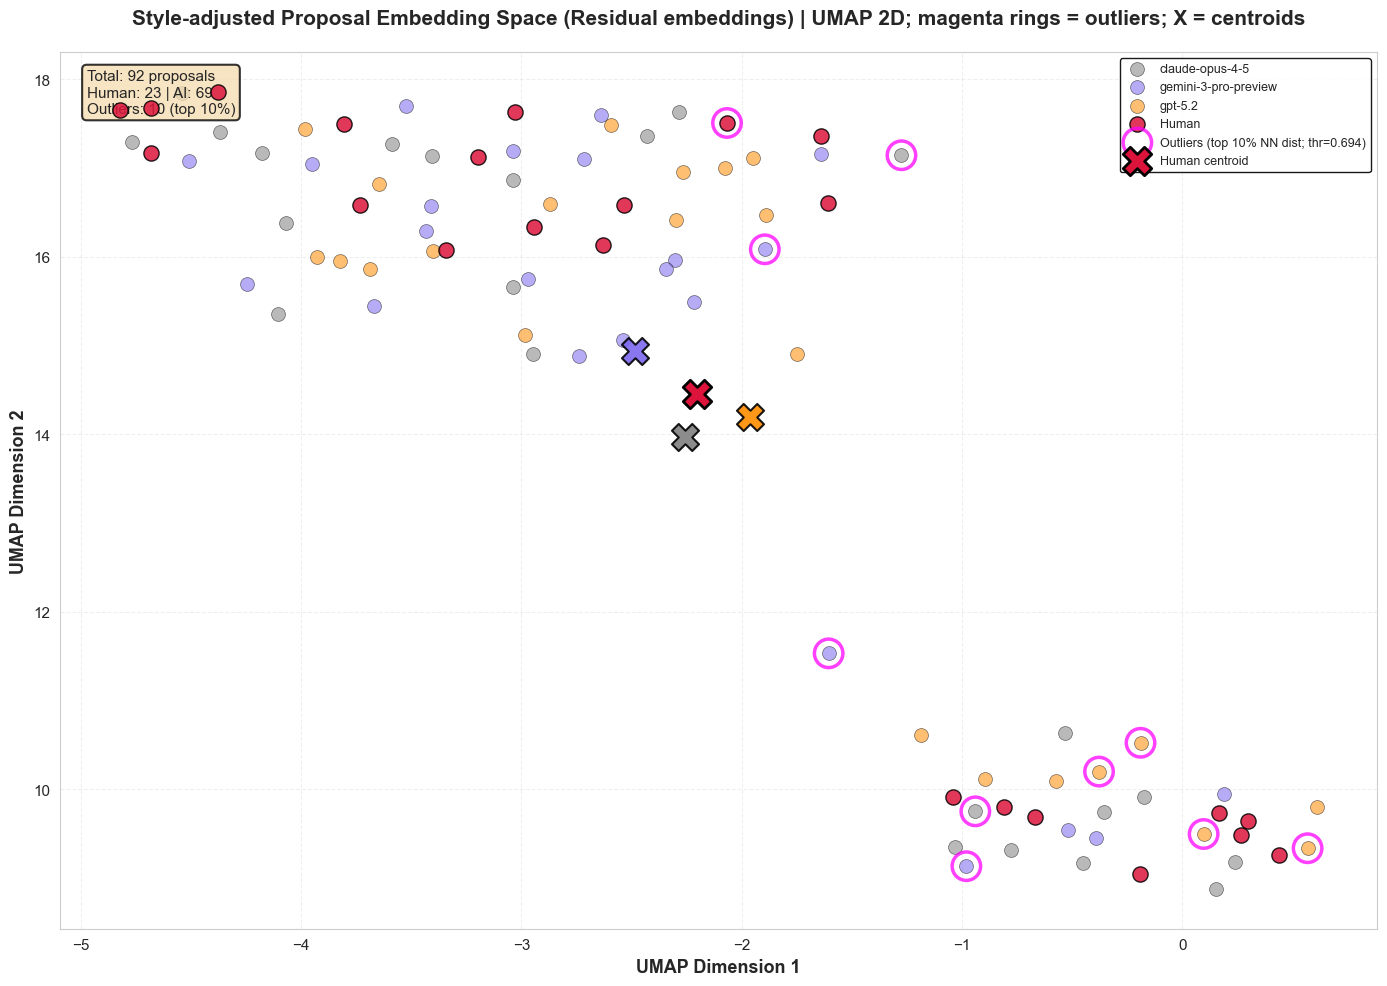


✓ Figure saved to: ../results/figures/rephrased/minimal/embedding_space_2d_style_adjusted.png
💡 INTERPRETATION:
   - Clusters = similar proposals in style-adjusted residual space
   - Magenta rings = outliers by NN distance in residual space
   - X markers = group centroids in residual space


In [147]:
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("="*85)
print("STYLE-ADJUSTED: UMAP PROJECTION FOR NN/OUTLIER ANALYSIS")
print("="*85)

required_vars = ['all_embeddings_resid', 'outliers_adj', 'threshold_adj', 'n_human', 'n_ai', 'ai_models_local', 'model_embeddings_dict', 'labels']
missing = [v for v in required_vars if v not in globals()]
if missing:
    print(f"⚠️ Missing variables from prior style-adjusted NN cell: {missing}")
    print("Run the 'STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS' cell first.")
else:
    try:
        cov_cols = [c for c in style_df.columns if c not in {'group', 'is_ai'}]  # all style features
        X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
        X_cov = StandardScaler().fit_transform(X_cov)

        E_raw = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])
        E_raw = E_raw / (np.linalg.norm(E_raw, axis=1, keepdims=True) + 1e-12)
        E_adj = np.asarray(all_embeddings_resid)

        pca = PCA(n_components=10, random_state=42)
        Z_raw = pca.fit_transform(E_raw)
        Z_adj = pca.fit_transform(E_adj)

        def _mean_abs_corr(Z, X):
            corrs = []
            for i in range(Z.shape[1]):
                zi = Z[:, i]
                for j in range(X.shape[1]):
                    xj = X[:, j]
                    c = np.corrcoef(zi, xj)[0, 1]
                    if np.isfinite(c):
                        corrs.append(abs(c))
            return float(np.mean(corrs)) if corrs else np.nan

        raw_corr = _mean_abs_corr(Z_raw, X_cov)
        adj_corr = _mean_abs_corr(Z_adj, X_cov)

        print()
        print("Style-adjustment diagnostic (lower is better):")
        print(f"  Mean |corr(style covariate, PC score)| (raw embeddings):  {raw_corr:.4f}")
        print(f"  Mean |corr(style covariate, PC score)| (residual embeddings): {adj_corr:.4f}")
    except Exception as e:
        print()
        print(f"⚠️ Diagnostic skipped due to error: {e}")

    print()
    print("Reducing residual embeddings to 2D using UMAP...")
    reducer_adj = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric='cosine', random_state=42)
    embeddings_2d_adj = reducer_adj.fit_transform(all_embeddings_resid)

    human_2d_adj = embeddings_2d_adj[:n_human]
    ai_2d_adj = embeddings_2d_adj[n_human:]
    model_2d_adj = {model: embeddings_2d_adj[labels == model] for model in ai_models_local}

    print(f"✓ UMAP completed: {len(embeddings_2d_adj)} proposals reduced to 2D")

    outlier_indices_adj = np.where(outliers_adj)[0]
    outlier_coords_adj = embeddings_2d_adj[outlier_indices_adj]

    colors_local = dict(colors) if 'colors' in globals() and isinstance(colors, dict) else {'Human': '#DC143C'}

    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    for model in ai_models_local:
        mask = labels == model
        if mask.any():
            pts = embeddings_2d_adj[mask]
            ax.scatter(pts[:, 0], pts[:, 1], c=colors_local.get(model, '#808080'), label=model, s=100, alpha=0.55, edgecolors='black', linewidth=0.5)

    ax.scatter(human_2d_adj[:, 0], human_2d_adj[:, 1], c=colors_local.get('Human', '#DC143C'), label='Human', s=120, alpha=0.85, edgecolors='black', linewidth=1.0, marker='o', zorder=10)
    ax.scatter(outlier_coords_adj[:, 0], outlier_coords_adj[:, 1], s=420, facecolors='none', edgecolors='magenta', linewidth=2.5, alpha=0.75, label=f'Outliers (top 10% NN dist; thr={threshold_adj:.3f})', zorder=12)

    human_centroid_2d = human_2d_adj.mean(axis=0)
    ax.scatter(human_centroid_2d[0], human_centroid_2d[1], c=colors_local.get('Human', '#DC143C'), s=420, marker='X', edgecolors='black', linewidth=2, alpha=1.0, zorder=15, label='Human centroid')

    for model in ai_models_local:
        if model in model_2d_adj and len(model_2d_adj[model]) > 0:
            c2d = model_2d_adj[model].mean(axis=0)
            ax.scatter(c2d[0], c2d[1], c=colors_local.get(model, '#808080'), s=380, marker='X', edgecolors='black', linewidth=1.5, alpha=0.9, zorder=14)

    ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
    ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
    ax.set_title('Style-adjusted Proposal Embedding Space (Residual embeddings) | UMAP 2D; magenta rings = outliers; X = centroids', fontsize=15, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')
    ax.grid(True, alpha=0.3, linestyle='--')

    textstr = '\n'.join([
        f'Total: {len(embeddings_2d_adj)} proposals',
        f'Human: {n_human} | AI: {n_ai}',
        f'Outliers: {len(outlier_indices_adj)} (top 10%)'
    ])
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=props)

    plt.tight_layout()
    out_path = FIGURES_DIR / 'embedding_space_2d_style_adjusted.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    print()
    print(f"✓ Figure saved to: {out_path}")
    print("💡 INTERPRETATION:")
    print("   - Clusters = similar proposals in style-adjusted residual space")
    print("   - Magenta rings = outliers by NN distance in residual space")
    print("   - X markers = group centroids in residual space")
    print("="*85)


#### Outlier proposals (style-adjusted NN)

Print the titles of proposals flagged as **outliers** in the style-adjusted NN analysis (top 10% NN distance), along with whether they are Human or which AI model generated them.

In [148]:
import pandas as pd
import numpy as np

print("\n" + "="*85)
print("STYLE-ADJUSTED NN OUTLIERS: TITLES + AUTHOR")
print("="*85)

required = ['outliers_adj', 'threshold_adj', 'n_human']
missing = [v for v in required if v not in globals()]
if missing:
    print(f"⚠️ Missing variables: {missing}")
    print("Run the style-adjusted NN analysis cell first.")
else:
    outlier_indices = np.where(outliers_adj)[0]
    n_total = int(len(outliers_adj))
    n_ai = int(n_total - n_human)

    # Get style-adjusted NN distances if available; otherwise recompute quickly
    if 'nn_distances_adj' in globals():
        nn_d = np.asarray(nn_distances_adj)
    elif 'all_distances_adj' in globals():
        nn_d = np.min(np.asarray(all_distances_adj), axis=1)
    elif 'all_embeddings_resid' in globals():
        from sklearn.metrics.pairwise import cosine_distances
        D = cosine_distances(np.asarray(all_embeddings_resid))
        np.fill_diagonal(D, np.inf)
        nn_d = D.min(axis=1)
    else:
        nn_d = None

    # Prefer metadata saved alongside embeddings (guaranteed to match embedding order)
    use_metadata = ('ai_metadata' in globals()) and ('human_metadata' in globals())
    if use_metadata:
        if len(human_metadata) != n_human or len(ai_metadata) != n_ai:
            print("⚠️ Metadata lengths do not match embedding counts; falling back to df-based lookup.")
            use_metadata = False

    rows = []
    for idx in outlier_indices:
        if idx < n_human:
            who = 'Human'
            model = 'Human'
            if use_metadata:
                rec = human_metadata[idx]
                title = rec.get('proposal_title', rec.get('title', ''))
            else:
                title = human_df.iloc[idx].get('proposal_title', human_df.iloc[idx].get('title', '')) if 'human_df' in globals() else ''
        else:
            ai_idx = idx - n_human
            who = 'AI'
            if use_metadata:
                rec = ai_metadata[ai_idx]
                model = str(rec.get('model', 'AI'))
                title = str(rec.get('title', ''))
            else:
                model = str(ai_df.iloc[ai_idx].get('model', '')) if 'ai_df' in globals() else 'AI'
                title = str(ai_df.iloc[ai_idx].get('title', '')) if 'ai_df' in globals() else ''

        rows.append({
            'global_index': int(idx),
            'who': who,
            'model': model,
            'nn_distance_style_adj': float(nn_d[idx]) if nn_d is not None else np.nan,
            'title': title
        })

    out_df = pd.DataFrame(rows).sort_values('nn_distance_style_adj', ascending=False)

    print(f"Outlier threshold (90th percentile): {threshold_adj:.4f}")
    print(f"Total outliers: {len(out_df)} / {n_total} ({len(out_df)/n_total*100:.1f}%)")
    print("Outliers by source (model):")
    print(out_df['model'].value_counts().to_string())

    with pd.option_context('display.max_colwidth', 140):
        display(out_df.reset_index(drop=True))



STYLE-ADJUSTED NN OUTLIERS: TITLES + AUTHOR
Outlier threshold (90th percentile): 0.6940
Total outliers: 10 / 92 (10.9%)
Outliers by source (model):
model
gpt-5.2                 4
gemini-3-pro-preview    3
claude-opus-4-5         2
Human                   1


,global_index,who,model,nn_distance_style_adj,title
0,46,AI,gemini-3-pro-preview,0.773576,Sequence Grammar of Mesoscale Viscoelasticity in Biomolecular Condensates
1,33,AI,gpt-5.2,0.773304,"Integration of Spatial Proteomics, Imaging, and Ubiquitinome Data for Mesoscale Proteasome and Autophagy Hub Organization"
2,59,AI,gemini-3-pro-preview,0.740164,Symmetry Breaking in the Centrosome and the Emergence of Spindle Bipolarity
3,91,AI,claude-opus-4-5,0.740164,Integration of Damage Proteomics and Chromatin Data for Modeling Emergent DNA Repair Pathway Choice
4,87,AI,claude-opus-4-5,0.725509,Integration of Structural and Proteomic Data for Decoding Emergent Specificity in Ubiquitin Chain Recognition
5,20,Human,Human,0.717601,The Role of Transposable Elements in the Emergence of Genomic Innovation
6,28,AI,gpt-5.2,0.715309,"Integration of Cryo-EM Intermediates, rRNA Processing Maps, and Proteomics for Explaining Emergent Ribosome Assembly Robustness"
7,39,AI,gpt-5.2,0.710648,Mesoscale Organization of Metabolic Enzyme Filaments: A Cross-Species Synthesis of Cytoophidia and Emergent Metabolic Regulation
8,66,AI,gemini-3-pro-preview,0.704959,Thylakoid Stacking and the Emergence of Photosynthetic Robustness in Plant Systems
9,27,AI,gpt-5.2,0.695193,"Protein Crowding as an Emergent Mesoscale Regulator of Cytoplasmic Viscosity, Diffusion, and Reaction Rates"


# PART V: Review Score Prediction and Outlier Validation

## Overview

This section links the embedding and style metrics computed above to the AI-generated review scores in `data/reviews/ai_reviews/ai_reviews_rephrased_*.json`.

**Two primary goals:**
1. **Metric validation** — test whether computed metrics (semantic diversity, style features) predict review scores on specific criteria. If novelty-related embedding metrics predict "Novelty & Significance" scores, this validates that the metrics capture meaningful signal.
2. **Outlier validation** — test whether proposals identified as most semantically unique (top-10% nearest-neighbor distance) actually received higher scores on "Novelty & Significance."

**Review data structure:**
- 92 proposals × 3 AI evaluators (GPT, Gemini, Claude) = 276 reviews
- 7 scored criteria: Relevance to Emergent Phenomena, Novelty & Significance, Rigor of Approach, Scope & Timeline, Synthesis Focus, Data Identification, Open Science Commitment

### Load and flatten review scores

In [149]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

# ── Load most recent rephrased review file ────────────────────────────────────
review_dir = Path('../data/reviews/ai_reviews')
review_files = sorted(review_dir.glob('ai_reviews_rephrased_*.json'))
if not review_files:
    raise FileNotFoundError(f"No rephrased review files found in {review_dir}")
review_path = review_files[-1]
print(f"Loading: {review_path.name}")

with open(review_path) as f:
    review_data = json.load(f)

print(f"Total review entries: {len(review_data['reviews'])}")
print(f"Evaluators: {review_data['evaluators']}")

# ── Flatten to one row per (proposal, evaluator, criterion) ──────────────────
rows = []
for entry in review_data['reviews']:
    title   = entry.get('title', '')
    author  = entry.get('author', '')
    evaluator = entry.get('evaluator', '')
    evals   = entry.get('evaluations', {})
    criteria_scores = evals.get('evaluation', {}).get('criteria_scores', [])

    for cat in criteria_scores:
        for sub in cat.get('subcriteria', []):
            rows.append({
                'title':     title,
                'author':    author,
                'evaluator': evaluator,
                'category':  cat['category'],
                'criterion': sub['criterion'],
                'score':     sub['score'],
            })

reviews_df = pd.DataFrame(rows)
print(f"\nFlattened rows: {len(reviews_df)}")
print("Criteria:", reviews_df['criterion'].unique().tolist())
print("\nScore distribution:")
print(reviews_df.groupby('criterion')['score'].describe().round(2))


Loading: ai_reviews_rephrased_20260314_144505.json
Total review entries: 276
Evaluators: ['gpt-5.2', 'gemini-3-pro-preview', 'claude-opus-4-5']

Flattened rows: 1932
Criteria: ['Relevance to Emergent Phenomena', 'Novelty & Significance', 'Rigor of Approach', 'Scope & Timeline', 'Synthesis Focus', 'Data Identification', 'Open Science Commitment']

Score distribution:
                                 count  mean   std  min  25%  50%  75%  max
criterion                                                                  
Data Identification              276.0  3.68  0.78  2.0  3.0  4.0  4.0  5.0
Novelty & Significance           276.0  3.98  0.34  2.0  4.0  4.0  4.0  5.0
Open Science Commitment          276.0  3.94  0.82  1.0  4.0  4.0  4.0  5.0
Relevance to Emergent Phenomena  276.0  4.46  0.92  1.0  4.0  5.0  5.0  5.0
Rigor of Approach                276.0  3.42  0.69  2.0  3.0  3.0  4.0  5.0
Scope & Timeline                 276.0  3.20  0.64  1.0  3.0  3.0  4.0  4.0
Synthesis Focus        

In [150]:
# Average scores across evaluators → one row per proposal per criterion
scores_avg = (
    reviews_df
    .groupby(['title', 'author', 'criterion'])['score']
    .mean()
    .reset_index()
    .rename(columns={'score': 'avg_score'})
)

# Pivot to wide format: one row per proposal, one column per criterion
scores_wide = scores_avg.pivot_table(
    index=['title', 'author'], columns='criterion', values='avg_score'
).reset_index()
scores_wide.columns.name = None

# Tidy column names
scores_wide.columns = [
    c.lower().replace(' ', '_').replace('&', 'and').replace('/', '_')
    for c in scores_wide.columns
]
print(scores_wide.shape)
print(scores_wide.columns.tolist())
scores_wide.head()


(92, 9)
['title', 'author', 'data_identification', 'novelty_and_significance', 'open_science_commitment', 'relevance_to_emergent_phenomena', 'rigor_of_approach', 'scope_and_timeline', 'synthesis_focus']


,title,author,data_identification,novelty_and_significance,open_science_commitment,relevance_to_emergent_phenomena,rigor_of_approach,scope_and_timeline,synthesis_focus
0,A Cross-Cell-Type Atlas of Biomolecular Conden...,gpt-5.2,3.666667,4.000000,4.000000,5.000000,3.333333,3.333333,5.000000
1,A Unified Analytical Framework for the Dynamic...,human-y2,4.000000,3.666667,4.000000,2.666667,3.666667,3.333333,5.000000
2,An Artificial Intelligence Framework for Predi...,human-y2,3.333333,4.000000,4.000000,4.000000,3.333333,2.666667,2.333333
3,Data-Driven Modeling of Emergent Molecular Sel...,gemini-3-pro-preview,3.333333,4.000000,4.000000,5.000000,3.333333,3.333333,4.666667
4,Decoding Signaling Fidelity through Integrated...,claude-opus-4-5,3.333333,3.666667,3.666667,4.333333,3.000000,3.000000,4.666667


---
## Analysis 3.1: Metric–Score Correlation

For each of the 7 review criteria, compute Spearman correlations with all computed metrics.
Present as a heatmap. Apply Holm correction across the full matrix.

**Theoretically motivated pairs:**
| Metric | Criterion |
|---|---|
| NN distance (semantic uniqueness) | Novelty & Significance |
| Centroid distance | Novelty & Significance |
| Pairwise diversity | Novelty & Significance |


Matched proposals: 92 / 92
Score columns: ['data_identification', 'novelty_and_significance', 'open_science_commitment', 'relevance_to_emergent_phenomena', 'rigor_of_approach', 'scope_and_timeline', 'synthesis_focus']


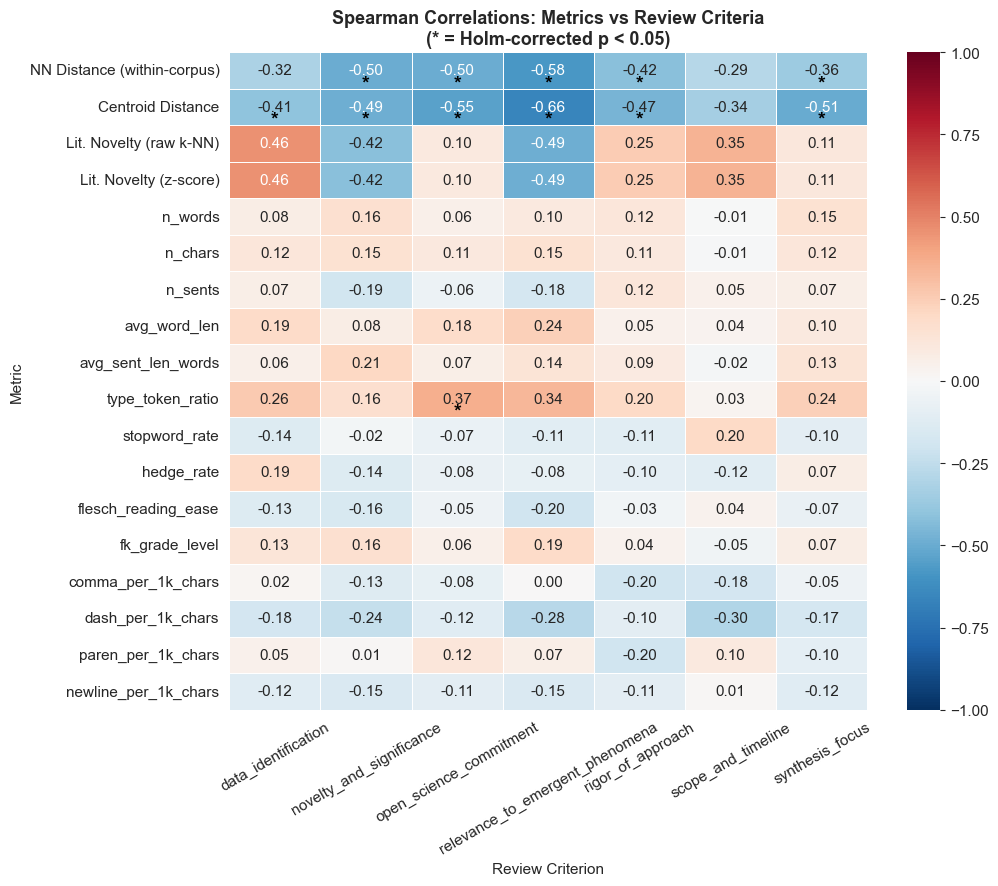


Top correlations (|r| > 0.2):
  NN Distance (within-corpus)         x data_identification                  r=-0.319
  NN Distance (within-corpus)         x novelty_and_significance             r=-0.498*
  NN Distance (within-corpus)         x open_science_commitment              r=-0.498*
  NN Distance (within-corpus)         x relevance_to_emergent_phenomena      r=-0.585*
  NN Distance (within-corpus)         x rigor_of_approach                    r=-0.419*
  NN Distance (within-corpus)         x scope_and_timeline                   r=-0.285
  NN Distance (within-corpus)         x synthesis_focus                      r=-0.365*
  Centroid Distance                   x data_identification                  r=-0.405*
  Centroid Distance                   x novelty_and_significance             r=-0.492*
  Centroid Distance                   x open_science_commitment              r=-0.546*
  Centroid Distance                   x relevance_to_emergent_phenomena      r=-0.659*
  Centroid Dis

In [151]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

# ── Load saved tables (no in-scope dependencies) ─────────────────────────────
tables = TABLES_DIR
nn_df       = pd.read_csv(tables / 'nn_distances.csv')
centroid_df = pd.read_csv(tables / 'centroid_distances.csv')
style_csv   = pd.read_csv(tables / 'style_features.csv')
nov_df      = pd.read_csv(tables / 'novelty_scores_from_literature.csv')
# scores_wide is built by the cells above (review load + pivot)
if 'scores_wide' not in globals():
    raise RuntimeError("Run the review-loading cells above (Part V cells 1-2) first.")

# Save scores_wide for reference by later cells
scores_wide.to_csv(tables / 'review_scores_wide.csv', index=False)

def norm(s): return str(s).strip().lower()
for df in [nn_df, centroid_df, style_csv, nov_df, scores_wide]:
    df['title_norm'] = df['title'].map(norm)

feature_cols = [c for c in style_csv.columns if c not in {'title', 'group', 'is_ai', 'title_norm'}]
score_cols = [c for c in scores_wide.columns if c not in {'title', 'title_norm', 'author'}]

merged = (nn_df[['title_norm', 'group', 'nn_dist', 'is_outlier', 'threshold']]
          .merge(centroid_df[['title_norm', 'centroid_dist']], on='title_norm', how='left')
          .merge(nov_df[['title_norm', 'raw_novelty', 'novelty_z']],  on='title_norm', how='left')
          .merge(style_csv[['title_norm'] + feature_cols],            on='title_norm', how='left')
          .merge(scores_wide[['title_norm'] + score_cols],            on='title_norm', how='inner'))
print(f"Matched proposals: {len(merged)} / {len(nn_df)}")
print(f"Score columns: {score_cols}")

# ── Spearman correlation heatmap ──────────────────────────────────────────────
# Metrics: NN distance, centroid distance, literature novelty (raw + z), then style features
metric_features = ['nn_dist', 'centroid_dist', 'raw_novelty', 'novelty_z'] + feature_cols
corr_mat = pd.DataFrame(index=metric_features, columns=score_cols, dtype=float)
pval_mat = pd.DataFrame(index=metric_features, columns=score_cols, dtype=float)

for m in metric_features:
    for s in score_cols:
        valid = merged[[m, s]].dropna()
        if len(valid) < 5:
            corr_mat.loc[m, s] = np.nan; pval_mat.loc[m, s] = np.nan
        else:
            r, p = stats.spearmanr(valid[m], valid[s])
            corr_mat.loc[m, s] = r; pval_mat.loc[m, s] = p

# Drop rows where every score column is NaN (feature had no valid pairs with any criterion)
valid_rows = corr_mat.notna().any(axis=1)
corr_mat  = corr_mat[valid_rows]
pval_mat  = pval_mat[valid_rows]
metric_features = [m for m in metric_features if valid_rows[m]]

flat_p = pval_mat.values.flatten()
valid_mask = ~np.isnan(flat_p)
corrected = np.full_like(flat_p, np.nan)
if valid_mask.sum() > 0:
    _, corrected[valid_mask], _, _ = multipletests(flat_p[valid_mask], method='holm')
sig_mat = pd.DataFrame(corrected.reshape(pval_mat.shape) < 0.05,
                       index=pval_mat.index, columns=pval_mat.columns)

# Pretty row labels
row_labels = {
    'nn_dist':      'NN Distance (within-corpus)',
    'centroid_dist':'Centroid Distance',
    'raw_novelty':  'Lit. Novelty (raw k-NN)',
    'novelty_z':    'Lit. Novelty (z-score)',
}
display_index = [row_labels.get(m, m) for m in metric_features]

corr_display = corr_mat.copy()
corr_display.index = display_index

fig, ax = plt.subplots(figsize=(max(10, len(score_cols)*1.5), max(8, len(metric_features)*0.5)))
sns.heatmap(corr_display.astype(float), annot=True, fmt='.2f', center=0,
            cmap='RdBu_r', vmin=-1, vmax=1, ax=ax, linewidths=0.5)
for i, m in enumerate(metric_features):
    for j, s in enumerate(score_cols):
        if sig_mat.loc[m, s]:
            ax.text(j+0.5, i+0.85, '*', ha='center', va='center', fontsize=14, fontweight='bold', color='black')
ax.set_title("Spearman Correlations: Metrics vs Review Criteria\n(* = Holm-corrected p < 0.05)",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Review Criterion', fontsize=11)
ax.set_ylabel('Metric', fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'metric_score_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTop correlations (|r| > 0.2):")
for m in metric_features:
    for s in score_cols:
        r = corr_mat.loc[m, s]
        if abs(r) > 0.2:
            sig = '*' if sig_mat.loc[m, s] else ''
            print(f"  {row_labels.get(m,m):<35} x {s:<35}  r={r:+.3f}{sig}")


In [152]:
# ── Diagnostic: which features have data in human vs AI subsets? ──────────────
print("Non-NaN value counts per feature per group (before correlation threshold)\n")
print(f"{'Feature':<40} {'Human non-NaN':>15} {'AI non-NaN':>12}  Notes")
print("-" * 80)
for m in metric_features_base:
    h_n = human_sub[m].notna().sum() if m in human_sub.columns else 0
    a_n = ai_sub[m].notna().sum()    if m in ai_sub.columns    else 0
    note = ''
    if h_n > 0 and a_n == 0:
        note = '← ALL NaN for AI  (reindex will add phantom row)'
    elif h_n == 0 and a_n > 0:
        note = '← ALL NaN for Human'
    elif h_n < 5 or a_n < 5:
        note = f'← below corr threshold (need >=5)'
    print(f"{m:<40} {h_n:>15} {a_n:>12}  {note}")

Non-NaN value counts per feature per group (before correlation threshold)

Feature                                    Human non-NaN   AI non-NaN  Notes
--------------------------------------------------------------------------------
nn_dist                                                0           69  ← ALL NaN for Human
centroid_dist                                          0           69  ← ALL NaN for Human
raw_novelty                                            0            0  ← below corr threshold (need >=5)
novelty_z                                              0            0  ← below corr threshold (need >=5)
n_words                                                0           69  ← ALL NaN for Human
n_chars                                                0           69  ← ALL NaN for Human
n_sents                                                0           69  ← ALL NaN for Human
avg_word_len                                           0           69  ← ALL NaN for Human
avg_sent_le

Human proposals: 23  |  AI proposals: 69


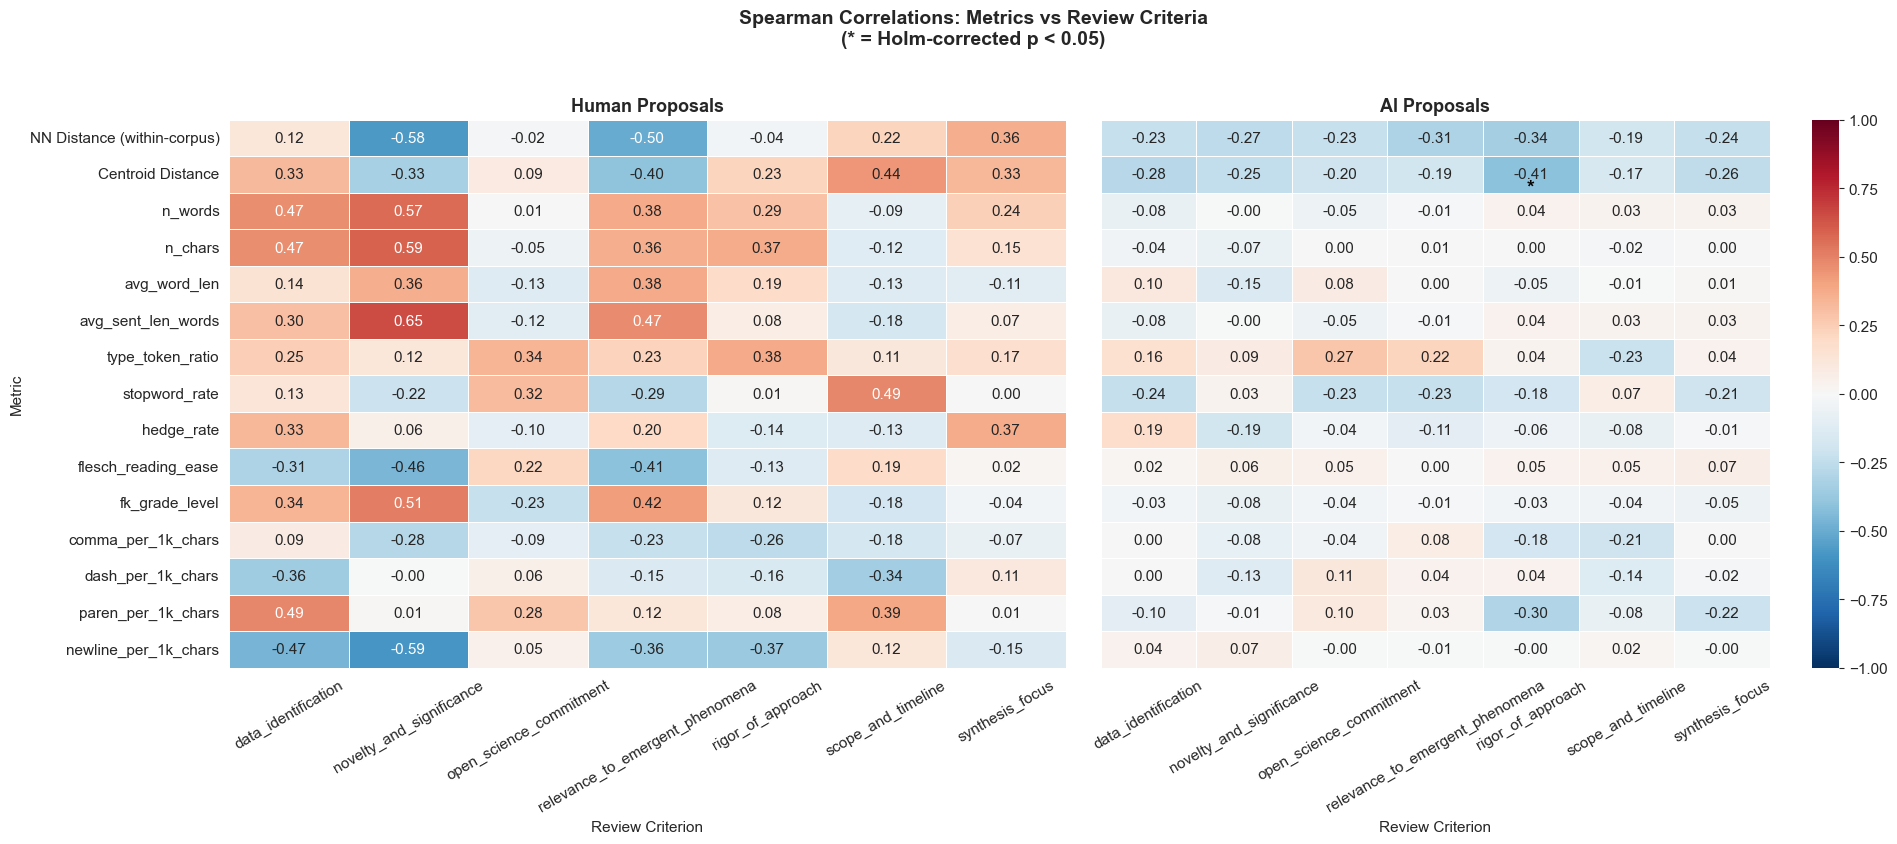


Top correlations (|r| > 0.2):

  [HUMAN]
    NN Distance (within-corpus)         x novelty_and_significance             r=-0.576
    NN Distance (within-corpus)         x relevance_to_emergent_phenomena      r=-0.503
    NN Distance (within-corpus)         x scope_and_timeline                   r=+0.222
    NN Distance (within-corpus)         x synthesis_focus                      r=+0.363
    Centroid Distance                   x data_identification                  r=+0.328
    Centroid Distance                   x novelty_and_significance             r=-0.332
    Centroid Distance                   x relevance_to_emergent_phenomena      r=-0.404
    Centroid Distance                   x rigor_of_approach                    r=+0.225
    Centroid Distance                   x scope_and_timeline                   r=+0.444
    Centroid Distance                   x synthesis_focus                      r=+0.332
    n_words                             x data_identification                 

In [153]:
# ── Spearman correlation heatmap: Human vs AI proposals (side-by-side) ───────

def compute_corr(subset, metric_features, score_cols):
    """Return (corr_mat, sig_mat) with empty-row filtering and Holm correction."""
    corr_mat = pd.DataFrame(index=metric_features, columns=score_cols, dtype=float)
    pval_mat = pd.DataFrame(index=metric_features, columns=score_cols, dtype=float)
    for m in metric_features:
        for s in score_cols:
            valid = subset[[m, s]].dropna()
            if len(valid) < 5:
                corr_mat.loc[m, s] = np.nan
                pval_mat.loc[m, s] = np.nan
            else:
                r, p = stats.spearmanr(valid[m], valid[s])
                corr_mat.loc[m, s] = r
                pval_mat.loc[m, s] = p

    # Drop all-NaN rows
    valid_rows = corr_mat.notna().any(axis=1)
    corr_mat = corr_mat[valid_rows]
    pval_mat = pval_mat[valid_rows]
    kept_feats = [m for m in metric_features if valid_rows[m]]

    # Holm correction
    flat_p = pval_mat.values.flatten()
    valid_mask = ~np.isnan(flat_p)
    corrected = np.full_like(flat_p, np.nan)
    if valid_mask.sum() > 0:
        _, corrected[valid_mask], _, _ = multipletests(flat_p[valid_mask], method='holm')
    sig_mat = pd.DataFrame(
        corrected.reshape(pval_mat.shape) < 0.05,
        index=pval_mat.index, columns=pval_mat.columns
    )
    return corr_mat, sig_mat, kept_feats


metric_features_base = ['nn_dist', 'centroid_dist', 'raw_novelty', 'novelty_z'] + feature_cols

# is_ai is excluded from feature_cols so it is not in merged — re-join it from style_csv
_is_ai = style_csv[['title_norm', 'is_ai']].drop_duplicates('title_norm')
merged_split = merged.merge(_is_ai, on='title_norm', how='left')

human_sub = merged_split[merged_split['is_ai'] == False]
ai_sub    = merged_split[merged_split['is_ai'] == True]
print(f"Human proposals: {len(human_sub)}  |  AI proposals: {len(ai_sub)}")

corr_h, sig_h, feats_h = compute_corr(human_sub, metric_features_base, score_cols)
corr_a, sig_a, feats_a = compute_corr(ai_sub,    metric_features_base, score_cols)

row_labels = {
    'nn_dist':      'NN Distance (within-corpus)',
    'centroid_dist':'Centroid Distance',
    'raw_novelty':  'Lit. Novelty (raw k-NN)',
    'novelty_z':    'Lit. Novelty (z-score)',
}

def make_display(corr_mat, feats):
    d = corr_mat.copy()
    d.index = [row_labels.get(m, m) for m in feats]
    return d

corr_h_disp = make_display(corr_h, feats_h)
corr_a_disp = make_display(corr_a, feats_a)

# Align rows so both panels share the same y-axis labels.
# Use INTERSECTION of kept features so features with no data in one panel don't
# create phantom all-NaN rows (the union approach caused blank rows for e.g.
# Lit. Novelty and n_sents when those features had no valid AI pairs).
feats_h_labels = {row_labels.get(m, m) for m in feats_h}
feats_a_labels = {row_labels.get(m, m) for m in feats_a}
all_labels = [row_labels.get(m, m) for m in metric_features_base
              if row_labels.get(m, m) in feats_h_labels and row_labels.get(m, m) in feats_a_labels]
all_labels = list(dict.fromkeys(all_labels))  # preserve order, deduplicate

if not all_labels:
    print("WARNING: no features in common between human and AI panels — check data coverage.")

corr_h_disp = corr_h_disp.reindex(all_labels)
corr_a_disp = corr_a_disp.reindex(all_labels)
# Keep sig_mats indexed by original feature names for star placement
feats_shared_h = [m for m in feats_h if row_labels.get(m, m) in all_labels]
feats_shared_a = [m for m in feats_a if row_labels.get(m, m) in all_labels]
sig_h = sig_h.reindex(feats_shared_h)
sig_a = sig_a.reindex(feats_shared_a)

n_rows = len(all_labels)
n_cols = len(score_cols)
fig, axes = plt.subplots(
    1, 2,
    figsize=(max(18, n_cols * 2.8), max(6, n_rows * 0.55)),
    sharey=True
)

heatmap_kw = dict(annot=True, fmt='.2f', center=0, cmap='RdBu_r',
                  vmin=-1, vmax=1, linewidths=0.5)

for ax, corr_disp, sig_mat, feats, title in [
    (axes[0], corr_h_disp, sig_h, feats_shared_h, 'Human Proposals'),
    (axes[1], corr_a_disp, sig_a, feats_shared_a, 'AI Proposals'),
]:
    sns.heatmap(corr_disp.astype(float), ax=ax, **heatmap_kw,
                cbar=(ax is axes[1]))   # colorbar only on right panel

    # Significance stars — iterate over the filtered feature list
    label_to_row = {row_labels.get(m, m): i for i, m in enumerate(all_labels)}
    for i_feat, m in enumerate(feats):
        label = row_labels.get(m, m)
        row_pos = list(corr_disp.index).index(label) if label in corr_disp.index else None
        if row_pos is None:
            continue
        for j, s in enumerate(score_cols):
            if s in sig_mat.columns and sig_mat.loc[m, s]:
                ax.text(j + 0.5, row_pos + 0.85, '*',
                        ha='center', va='center', fontsize=14,
                        fontweight='bold', color='black')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Review Criterion', fontsize=11)
    ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Metric', fontsize=11)
axes[1].set_ylabel('')

fig.suptitle(
    "Spearman Correlations: Metrics vs Review Criteria\n(* = Holm-corrected p < 0.05)",
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'metric_score_correlation_heatmap_by_group.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlations (|r| > 0.2):")
for label, corr_mat, sig_mat, feats in [('HUMAN', corr_h, sig_h, feats_shared_h),
                                          ('AI',    corr_a, sig_a, feats_shared_a)]:
    print(f"\n  [{label}]")
    for m in feats:
        for s in score_cols:
            r = corr_mat.loc[m, s]
            if pd.notna(r) and abs(r) > 0.2:
                sig = '*' if (s in sig_mat.columns and sig_mat.loc[m, s]) else ''
                print(f"    {row_labels.get(m,m):<35} x {s:<35}  r={r:+.3f}{sig}")


---
## Analysis 3.2: Binary Review Score Prediction

Convert each evaluator's criterion score to a binary label (`1` if score >= 4, else `0`) and fit grouped logistic regression models.
The predictors combine style metrics, embedding metrics, and two explicit binary novelty flags:
- `is_nn_outlier`: proposal is a within-corpus NN outlier
- `is_literature_outlier`: proposal is in the top-10% of literature novelty (`is_most_novel_raw`)

Cross-validation is grouped by proposal title so the same proposal never appears in both train and test folds when using evaluator-level review rows.



In [154]:
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from pathlib import Path

try:
    from sklearn.model_selection import StratifiedGroupKFold
except ImportError:
    StratifiedGroupKFold = None

if 'reviews_df' not in globals():
    raise RuntimeError("Run the review-loading cells above first to build 'reviews_df'.")

tables = TABLES_DIR

def norm(s):
    return str(s).strip().lower()

nn_df       = pd.read_csv(tables / 'nn_distances.csv')
centroid_df = pd.read_csv(tables / 'centroid_distances.csv')
style_csv   = pd.read_csv(tables / 'style_features.csv')
nov_df      = pd.read_csv(tables / 'novelty_scores_from_literature.csv')

for df in [nn_df, centroid_df, style_csv, nov_df]:
    df['title_norm'] = df['title'].map(norm)

style_feature_cols = [c for c in style_csv.columns if c not in {'title', 'group', 'is_ai', 'title_norm'}]
predictor_cols = style_feature_cols + [
    'nn_dist', 'centroid_dist', 'raw_novelty', 'novelty_z',
    'is_nn_outlier', 'is_literature_outlier'
]

proposal_features = (
    nn_df[['title_norm', 'group', 'nn_dist', 'is_outlier']]
    .merge(centroid_df[['title_norm', 'centroid_dist']], on='title_norm', how='left')
    .merge(nov_df[['title_norm', 'raw_novelty', 'novelty_z', 'is_most_novel_raw']], on='title_norm', how='left')
    .merge(style_csv[['title_norm'] + style_feature_cols], on='title_norm', how='left')
    .drop_duplicates('title_norm')
)
proposal_features['is_nn_outlier'] = proposal_features['is_outlier'].fillna(False).astype(int)
proposal_features['is_literature_outlier'] = proposal_features['is_most_novel_raw'].fillna(False).astype(int)

review_binary = reviews_df.copy()
review_binary['title_norm'] = review_binary['title'].map(norm)
review_binary['criterion_slug'] = (
    review_binary['criterion']
    .str.lower()
    .str.replace(' ', '_', regex=False)
    .str.replace('&', 'and', regex=False)
    .str.replace('/', '_', regex=False)
)
review_binary['score_binary'] = (review_binary['score'] >= 4).astype(int)

review_binary_wide = (
    review_binary
    .pivot_table(
        index=['title_norm', 'title', 'author', 'evaluator'],
        columns='criterion_slug',
        values='score_binary',
        aggfunc='first'
    )
    .reset_index()
)
review_binary_wide.columns.name = None
criterion_cols = [c for c in review_binary_wide.columns if c not in {'title_norm', 'title', 'author', 'evaluator'}]

logit_df = review_binary_wide.merge(proposal_features[['title_norm'] + predictor_cols], on='title_norm', how='inner')
print(f"Evaluator-level rows matched: {len(logit_df)}")
print(f"Criteria modeled: {criterion_cols}")

pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        solver='liblinear',
        random_state=42,
    )
)

results_rows = []
coef_rows = []

for criterion in criterion_cols:
    valid = logit_df[criterion].notna()
    X = logit_df.loc[valid, predictor_cols].replace([np.inf, -np.inf], np.nan)
    y = logit_df.loc[valid, criterion].astype(int).values
    groups = logit_df.loc[valid, 'title_norm'].values

    if len(np.unique(y)) < 2:
        print(f"Skipping {criterion}: only one class present.")
        continue

    if StratifiedGroupKFold is not None:
        splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
        split_iter = splitter.split(X, y, groups)
    else:
        splitter = GroupKFold(n_splits=5)
        split_iter = splitter.split(X, y, groups)

    oof_pred = np.full(len(y), np.nan)
    for train_idx, test_idx in split_iter:
        model = clone(pipe)
        model.fit(X.iloc[train_idx], y[train_idx])
        oof_pred[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]

    oof_auc = roc_auc_score(y, oof_pred)
    oof_bal = balanced_accuracy_score(y, (oof_pred >= 0.5).astype(int))
    pos_rate = y.mean()

    final_model = clone(pipe)
    final_model.fit(X, y)
    coefs = final_model.named_steps['logisticregression'].coef_.ravel()

    results_rows.append({
        'criterion': criterion,
        'n_reviews': len(y),
        'n_proposals': int(pd.Series(groups).nunique()),
        'positive_rate': pos_rate,
        'oof_auc': oof_auc,
        'oof_bal_acc': oof_bal,
    })

    for feat, coef in zip(predictor_cols, coefs):
        coef_rows.append({
            'criterion': criterion,
            'feature': feat,
            'coef': coef,
            'abs_coef': abs(coef),
            'odds_ratio_per_sd': np.exp(coef),
        })

    print(
        f"{criterion:<34} OOF AUROC={oof_auc:.3f}  "
        f"Balanced Acc={oof_bal:.3f}  Positive rate={pos_rate:.3f}"
    )

logit_results_df = pd.DataFrame(results_rows).sort_values('oof_auc', ascending=False)
logit_coef_df = pd.DataFrame(coef_rows).sort_values(['criterion', 'abs_coef'], ascending=[True, False])
logit_importance_df = (
    logit_coef_df
    .groupby('feature', as_index=False)
    .agg(mean_abs_coef=('abs_coef', 'mean'), mean_coef=('coef', 'mean'), criteria_count=('criterion', 'nunique'))
    .sort_values('mean_abs_coef', ascending=False)
)

logit_results_df.to_csv(tables / 'binary_review_logistic_results.csv', index=False)
logit_coef_df.to_csv(tables / 'binary_review_logistic_coefficients.csv', index=False)
logit_importance_df.to_csv(tables / 'binary_review_logistic_feature_importance.csv', index=False)
print("\nSaved binary_review_logistic_*.csv tables")

print("\nTop overall features:")
print(logit_importance_df.head(12).to_string(index=False))

print("\nTop features for novelty_and_significance:")
print(
    logit_coef_df.loc[logit_coef_df['criterion'] == 'novelty_and_significance', ['feature', 'coef', 'odds_ratio_per_sd']]
    .head(12)
    .to_string(index=False)
)



Evaluator-level rows matched: 276
Criteria modeled: ['data_identification', 'novelty_and_significance', 'open_science_commitment', 'relevance_to_emergent_phenomena', 'rigor_of_approach', 'scope_and_timeline', 'synthesis_focus']
data_identification                OOF AUROC=0.603  Balanced Acc=0.597  Positive rate=0.587
novelty_and_significance           OOF AUROC=0.778  Balanced Acc=0.724  Positive rate=0.938
open_science_commitment            OOF AUROC=0.839  Balanced Acc=0.715  Positive rate=0.833
relevance_to_emergent_phenomena    OOF AUROC=0.880  Balanced Acc=0.790  Positive rate=0.855
rigor_of_approach                  OOF AUROC=0.520  Balanced Acc=0.523  Positive rate=0.406
scope_and_timeline                 OOF AUROC=0.486  Balanced Acc=0.486  Positive rate=0.308
synthesis_focus                    OOF AUROC=0.207  Balanced Acc=0.399  Positive rate=0.967

Saved binary_review_logistic_*.csv tables

Top overall features:
              feature  mean_abs_coef  mean_coef  criteria_coun

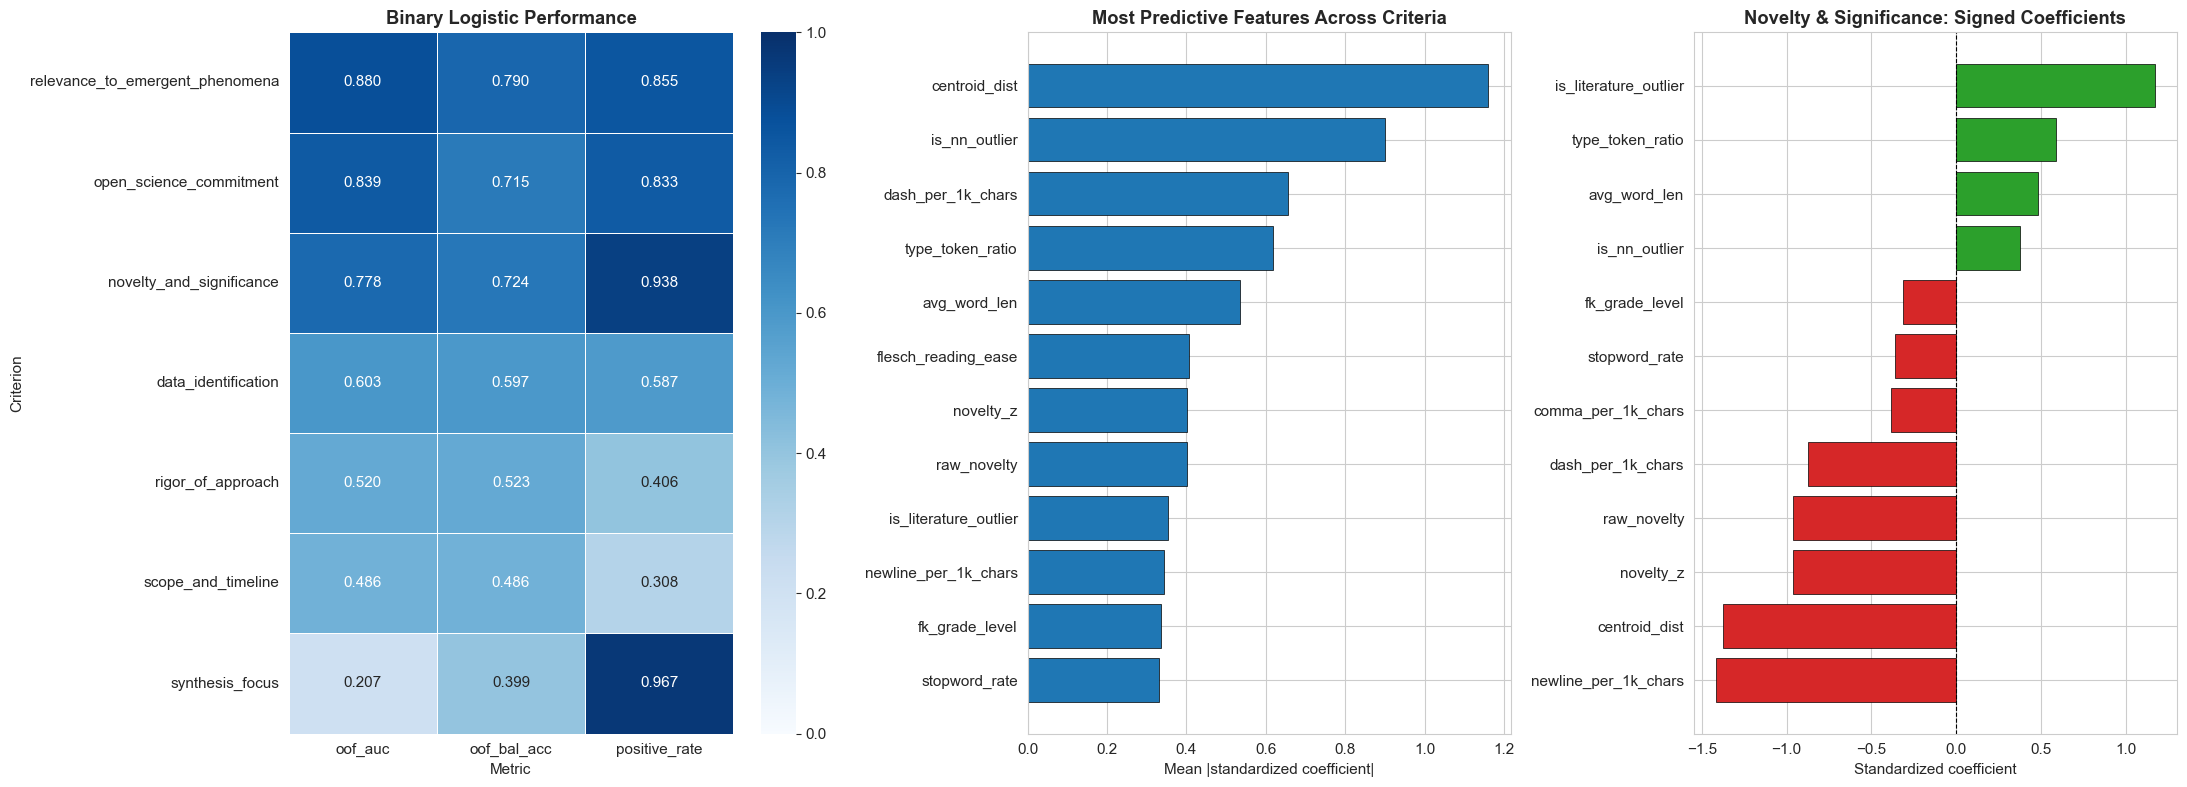

                      criterion  positive_rate  oof_auc  oof_bal_acc
relevance_to_emergent_phenomena       0.855072 0.879767     0.790466
        open_science_commitment       0.833333 0.838563     0.715217
       novelty_and_significance       0.938406 0.778333     0.724165
            data_identification       0.586957 0.603151     0.596816
              rigor_of_approach       0.405797 0.519599     0.523193
             scope_and_timeline       0.307971 0.486418     0.485864
                synthesis_focus       0.967391 0.207241     0.398876


In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'logit_results_df' not in globals() or 'logit_coef_df' not in globals():
    raise RuntimeError("Run the binary logistic modeling cell first.")

metric_plot_df = logit_results_df.set_index('criterion')[['oof_auc', 'oof_bal_acc', 'positive_rate']]
metric_plot_df = metric_plot_df.loc[metric_plot_df.index]

novelty_coef_df = (
    logit_coef_df[logit_coef_df['criterion'] == 'novelty_and_significance']
    .nlargest(12, 'abs_coef')
    .sort_values('coef')
)

overall_top_df = logit_importance_df.head(12).sort_values('mean_abs_coef')

fig, axes = plt.subplots(1, 3, figsize=(22, 8), gridspec_kw={'width_ratios': [1.15, 1, 1]})

sns.heatmap(
    metric_plot_df,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Binary Logistic Performance', fontweight='bold')
axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Criterion')

axes[1].barh(overall_top_df['feature'], overall_top_df['mean_abs_coef'], color='#1f77b4', edgecolor='black', linewidth=0.5)
axes[1].set_title('Most Predictive Features Across Criteria', fontweight='bold')
axes[1].set_xlabel('Mean |standardized coefficient|')
axes[1].set_ylabel('')

coef_colors = np.where(novelty_coef_df['coef'] >= 0, '#2ca02c', '#d62728')
axes[2].barh(novelty_coef_df['feature'], novelty_coef_df['coef'], color=coef_colors, edgecolor='black', linewidth=0.5)
axes[2].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title("Novelty & Significance: Signed Coefficients", fontweight='bold')
axes[2].set_xlabel('Standardized coefficient')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'binary_review_logistic_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(logit_results_df[['criterion', 'positive_rate', 'oof_auc', 'oof_bal_acc']].to_string(index=False))



---
## Analysis 3.3: Outlier Validation

Test whether proposals flagged as semantic outliers (top-10% NN distance globally)
received higher scores on "Novelty & Significance."
Run the same test for all 7 criteria to check whether outlier status is novelty-specific.

Outlier threshold: 0.1215  |  Outliers in merged: 9 / 92
data_identification                      outlier=3.30  non-outlier=3.72  δ=-0.530  p=0.9966
novelty_and_significance                 outlier=3.70  non-outlier=4.01  δ=-0.726  p=1.0000
open_science_commitment                  outlier=3.41  non-outlier=4.00  δ=-0.490  p=0.9957
relevance_to_emergent_phenomena          outlier=3.52  non-outlier=4.56  δ=-0.614  p=0.9996
rigor_of_approach                        outlier=3.19  non-outlier=3.45  δ=-0.461  p=0.9949
scope_and_timeline                       outlier=3.00  non-outlier=3.22  δ=-0.182  p=0.8989
synthesis_focus                          outlier=4.70  non-outlier=4.80  δ=-0.361  p=0.9859

Saved outlier_score_comparison.csv


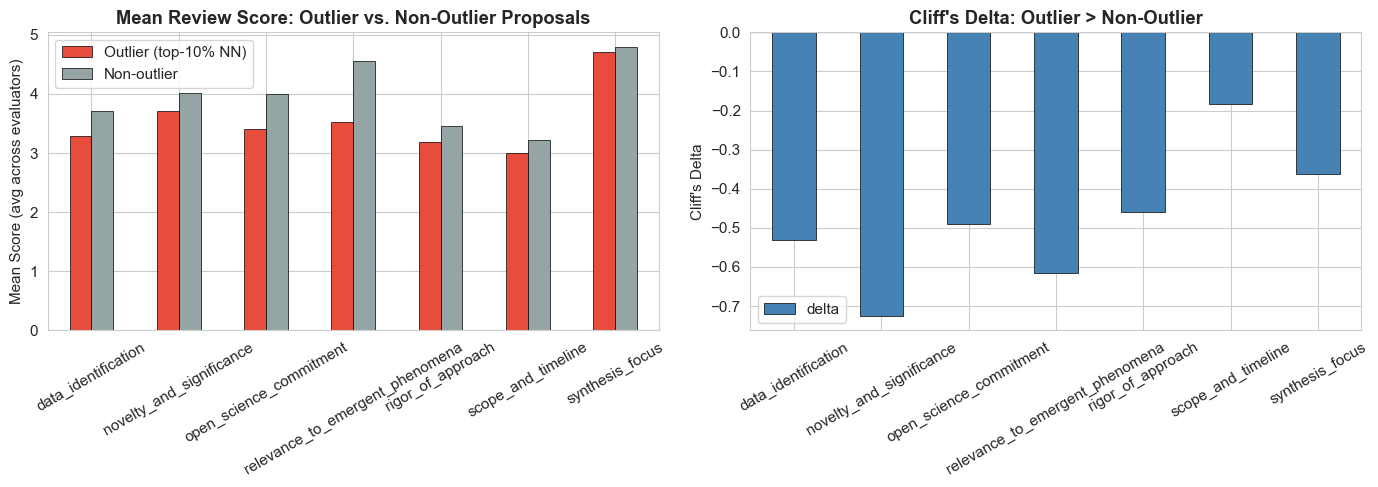

                      criterion  outlier_mean  nonout_mean     delta  p_value  p_holm
            data_identification      3.296296     3.718876 -0.530120 0.996564     1.0
       novelty_and_significance      3.703704     4.008032 -0.725569 0.999998     1.0
        open_science_commitment      3.407407     3.995984 -0.489960 0.995658     1.0
relevance_to_emergent_phenomena      3.518519     4.562249 -0.614458 0.999649     1.0
              rigor_of_approach      3.185185     3.449799 -0.460509 0.994941     1.0
             scope_and_timeline      3.000000     3.224900 -0.182062 0.898924     1.0
                synthesis_focus      4.703704     4.803213 -0.361446 0.985924     1.0


In [156]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def cliffs_delta_simple(x, y):
    x, y = np.asarray(x), np.asarray(y)
    dom = sum(1 if xi > yi else (-1 if xi < yi else 0) for xi in x for yi in y)
    return dom / (len(x) * len(y))

if 'merged' not in globals():
    raise RuntimeError("Run cell 3.1 first to build 'merged'.")

tables = TABLES_DIR
threshold_val = merged['threshold'].iloc[0]
n_outliers = merged['is_outlier'].sum()
print(f"Outlier threshold: {threshold_val:.4f}  |  Outliers in merged: {n_outliers} / {len(merged)}")

if n_outliers < 2:
    print("\n\u26a0\ufe0f  Fewer than 2 outliers. nn_dist summary:")
    print(merged[['group','nn_dist','is_outlier']].groupby('group').agg({'nn_dist':'mean','is_outlier':'sum'}))
else:
    outlier_results = []
    for criterion in score_cols:
        out_scores    = merged.loc[merged['is_outlier'],  criterion].dropna()
        nonout_scores = merged.loc[~merged['is_outlier'], criterion].dropna()
        if len(out_scores) < 2 or len(nonout_scores) < 2: continue
        u_stat, p_val = mannwhitneyu(out_scores, nonout_scores, alternative='greater')
        delta = cliffs_delta_simple(out_scores, nonout_scores)
        outlier_results.append({'criterion': criterion,
                                'outlier_mean': out_scores.mean(), 'nonout_mean': nonout_scores.mean(),
                                'delta': delta, 'p_value': p_val,
                                'n_outlier': len(out_scores), 'n_nonout': len(nonout_scores)})
        print(f"{criterion:<40} outlier={out_scores.mean():.2f}  non-outlier={nonout_scores.mean():.2f}  "
              f"\u03b4={delta:+.3f}  p={p_val:.4f}")

    if not outlier_results:
        print("\n\u26a0\ufe0f  No criteria had enough observations.")
    else:
        outlier_df = pd.DataFrame(outlier_results)
        _, outlier_df['p_holm'], _, _ = multipletests(outlier_df['p_value'], method='holm')
        outlier_df.to_csv(tables/'outlier_score_comparison.csv', index=False)
        print("\nSaved outlier_score_comparison.csv")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        outlier_df.plot(x='criterion', y=['outlier_mean','nonout_mean'], kind='bar',
                        ax=axes[0], color=['#E74C3C','#95A5A6'], edgecolor='black', linewidth=0.5)
        axes[0].set_title("Mean Review Score: Outlier vs. Non-Outlier Proposals", fontweight='bold')
        axes[0].set_xlabel(''); axes[0].set_ylabel('Mean Score (avg across evaluators)')
        axes[0].tick_params(axis='x', rotation=30)
        axes[0].legend(['Outlier (top-10% NN)', 'Non-outlier'])

        outlier_df.plot(x='criterion', y='delta', kind='bar',
                        ax=axes[1], color='steelblue', edgecolor='black', linewidth=0.5)
        axes[1].axhline(0, color='black', linewidth=0.8)
        axes[1].set_title("Cliff's Delta: Outlier > Non-Outlier", fontweight='bold')
        axes[1].set_xlabel(''); axes[1].set_ylabel("Cliff's Delta")
        axes[1].tick_params(axis='x', rotation=30)
        for i, (_, row) in enumerate(outlier_df.iterrows()):
            if row['p_holm'] < 0.05:
                axes[1].text(i, row['delta']+0.01, '*', ha='center', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'outlier_score_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(outlier_df[['criterion','outlier_mean','nonout_mean','delta','p_value','p_holm']].to_string(index=False))


---
## Analysis 3.3b: Literature-Novel Proposals vs. Review Scores

Same test as 3.3 but using **literature-based novelty** (top-10% by raw k-NN distance to literature corpus) instead of within-corpus NN outliers. Tests whether proposals most novel *relative to existing literature* received higher scores, especially on Novelty & Significance.

Matched proposals: 23  |  Lit-most-novel (top-10%): 5
Novelty threshold (90th pct): 0.1205

Key criterion to watch: 'novelty_and_significance'

ANALYSIS 3.3b: LIT-NOVEL (top-10%) vs REST — REVIEW SCORES
H1 (one-sided): literature-novel proposals score HIGHER (alternative='greater')
  data_identification                        novel=3.40  rest=3.31  δ=+0.100  p=0.3757
  novelty_and_significance                   novel=3.73  rest=3.81  δ=-0.256  p=0.8480  ← NOVELTY CRITERION
  open_science_commitment                    novel=3.33  rest=3.26  δ=-0.078  p=0.6214
  relevance_to_emergent_phenomena            novel=2.73  rest=3.33  δ=-0.422  p=0.9298
  rigor_of_approach                          novel=3.33  rest=3.20  δ=+0.122  p=0.3303
  scope_and_timeline                         novel=3.20  rest=2.94  δ=+0.222  p=0.2243
  synthesis_focus                            novel=4.47  rest=4.35  δ=+0.122  p=0.3502

Saved lit_novel_score_comparison_33b.csv


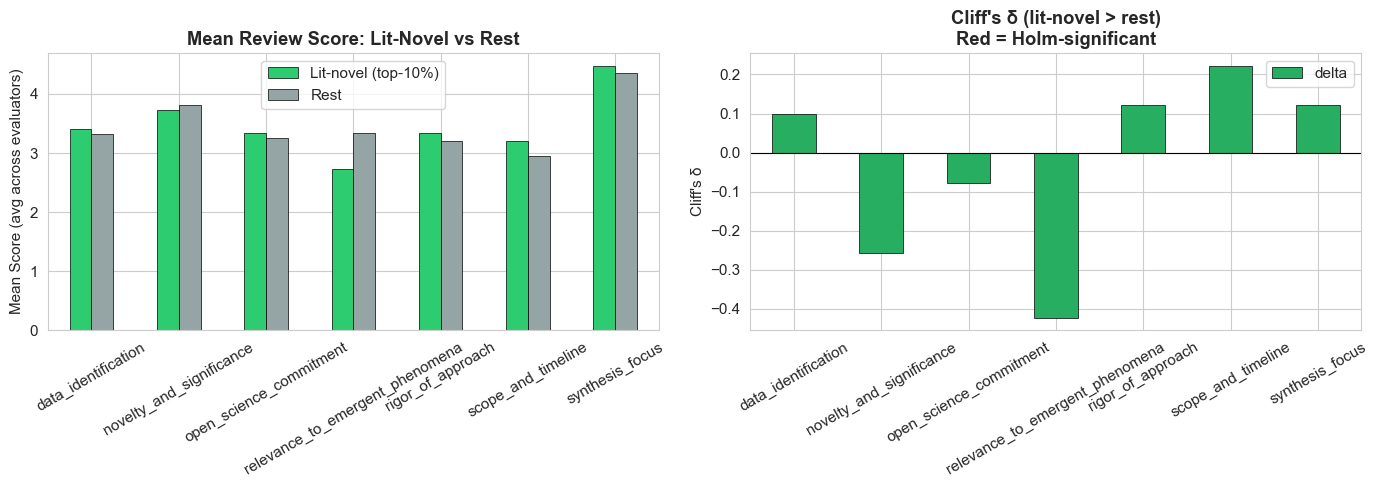

In [157]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def cliffs_delta_simple(x, y):
    x, y = np.asarray(x), np.asarray(y)
    dom = sum(1 if xi > yi else (-1 if xi < yi else 0) for xi in x for yi in y)
    return dom / (len(x) * len(y))

tables = TABLES_DIR

# ── Load saved tables (fully file-based) ─────────────────────────────────────
nov_df    = pd.read_csv(tables / 'novelty_scores_from_literature.csv')
scores_df = pd.read_csv(tables / 'review_scores_wide.csv')

def norm(s): return str(s).strip().lower()
nov_df['title_norm']    = nov_df['title'].map(norm)
scores_df['title_norm'] = scores_df['title'].map(norm)
score_cols_local = [c for c in scores_df.columns if c not in {'title', 'title_norm', 'author'}]

merged_33b = (nov_df[['title_norm', 'raw_novelty', 'is_most_novel_raw']]
              .merge(scores_df[['title_norm'] + score_cols_local], on='title_norm', how='inner'))
n_novel = int(merged_33b['is_most_novel_raw'].sum())
print(f"Matched proposals: {len(merged_33b)}  |  Lit-most-novel (top-10%): {n_novel}")
lit_threshold = np.percentile(nov_df['raw_novelty'], 90)
print(f"Novelty threshold (90th pct): {lit_threshold:.4f}\n")

novelty_col = next((c for c in score_cols_local if 'novelty' in c.lower()), None)
if novelty_col:
    print(f"Key criterion to watch: '{novelty_col}'\n")

if n_novel < 2:
    print("⚠️  Fewer than 2 literature-most-novel proposals in merged set; cannot run test.")
else:
    print("="*70)
    print("ANALYSIS 3.3b: LIT-NOVEL (top-10%) vs REST — REVIEW SCORES")
    print("H1 (one-sided): literature-novel proposals score HIGHER (alternative='greater')")
    print("="*70)

    lit_results = []
    for criterion in score_cols_local:
        novel_s = merged_33b.loc[ merged_33b['is_most_novel_raw'], criterion].dropna()
        rest_s  = merged_33b.loc[~merged_33b['is_most_novel_raw'], criterion].dropna()
        if len(novel_s) < 2 or len(rest_s) < 2: continue
        u, p  = mannwhitneyu(novel_s, rest_s, alternative='greater')
        delta = cliffs_delta_simple(novel_s, rest_s)
        marker = "  ← NOVELTY CRITERION" if criterion == novelty_col else ""
        print(f"  {criterion:<42} novel={novel_s.mean():.2f}  rest={rest_s.mean():.2f}  "
              f"δ={delta:+.3f}  p={p:.4f}{marker}")
        lit_results.append({'criterion': criterion,
                            'novel_mean': novel_s.mean(), 'rest_mean': rest_s.mean(),
                            'delta': delta, 'p_value': p,
                            'n_novel': len(novel_s), 'n_rest': len(rest_s)})

    if lit_results:
        lit_df = pd.DataFrame(lit_results)
        _, lit_df['p_holm'], _, _ = multipletests(lit_df['p_value'], method='holm')
        lit_df.to_csv(tables / 'lit_novel_score_comparison_33b.csv', index=False)
        print("\nSaved lit_novel_score_comparison_33b.csv")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        lit_df.plot(x='criterion', y=['novel_mean', 'rest_mean'], kind='bar',
                    ax=axes[0], color=['#2ECC71', '#95A5A6'], edgecolor='black', linewidth=0.5)
        axes[0].set_title("Mean Review Score: Lit-Novel vs Rest", fontweight='bold')
        axes[0].set_xlabel(''); axes[0].set_ylabel('Mean Score (avg across evaluators)')
        axes[0].tick_params(axis='x', rotation=30)
        axes[0].legend(["Lit-novel (top-10%)", "Rest"])

        colors_33b = ['#E74C3C' if sig else '#27AE60'
                      for sig in (lit_df['p_holm'] < 0.05)]
        lit_df.plot(x='criterion', y='delta', kind='bar',
                    ax=axes[1], color=colors_33b, edgecolor='black', linewidth=0.5)
        axes[1].axhline(0, color='black', linewidth=0.8)
        axes[1].set_title("Cliff's δ (lit-novel > rest)\nRed = Holm-significant", fontweight='bold')
        axes[1].set_xlabel(''); axes[1].set_ylabel("Cliff's δ")
        axes[1].tick_params(axis='x', rotation=30)

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'lit_novel_score_comparison_33b.png',
                    dpi=150, bbox_inches='tight')
        plt.show()


The Mann-Whitney test was run as alternative='greater' — testing whether outliers score higher. All p-values ≈ 1.0 means there is zero
  evidence for that. The negative Cliff's deltas tell you the actual direction: outlier proposals consistently scored lower than non-outliers
  on every single criterion.

Semantically isolated proposals (high NN distance = far from everything in embedding space) received lower scores across all criteria, with
  the strongest penalty on Novelty & Significance and Relevance. This is the opposite of your hypothesis.

Two possible interpretations:

  1. Semantic outliers are outliers for bad reasons — proposals that are far from everything may be off-topic, unfocused, or poorly aligned
  with the call rather than genuinely innovative. Reviewers penalize this.
  2. The embedding metric and reviewer "novelty" capture different things — reviewer novelty rewards ideas that are new within the established
   research space; embedding distance may be flagging proposals that simply use different vocabulary or address tangential topics.

  The mean scores make the gap concrete: outliers averaged 3.70 on Novelty vs 4.01 for non-outliers, and 3.52 vs 4.56 on Relevance — nearly a
  full point lower on relevance for the most isolated proposals.

---
## Analysis 3.4: Human vs. AI Outlier Comparison

Among outlier proposals only, compare "Novelty & Significance" scores between human and AI outliers.
Also compute the correlation between NN distance and novelty score separately within each group.

Using criterion: novelty_and_significance

=== Among outlier proposals: Human vs AI Novelty & Significance ===
  Human outliers  n=5  mean=3.67
  AI outliers     n=4  mean=3.75
  Mann-Whitney U=8  p=0.6605  Cliff's δ=-0.200

=== Spearman: NN distance ~ Novelty score by group ===
  Human                     n=23  r=-0.576  p=0.0040
  gpt-5.2                   n=23  r=-0.239  p=0.2722
  gemini-3-pro-preview      n=23  r=-0.348  p=0.1040
  claude-opus-4-5           n=23  r=-0.350  p=0.1011

Saved nn_novelty_correlation_by_group.csv


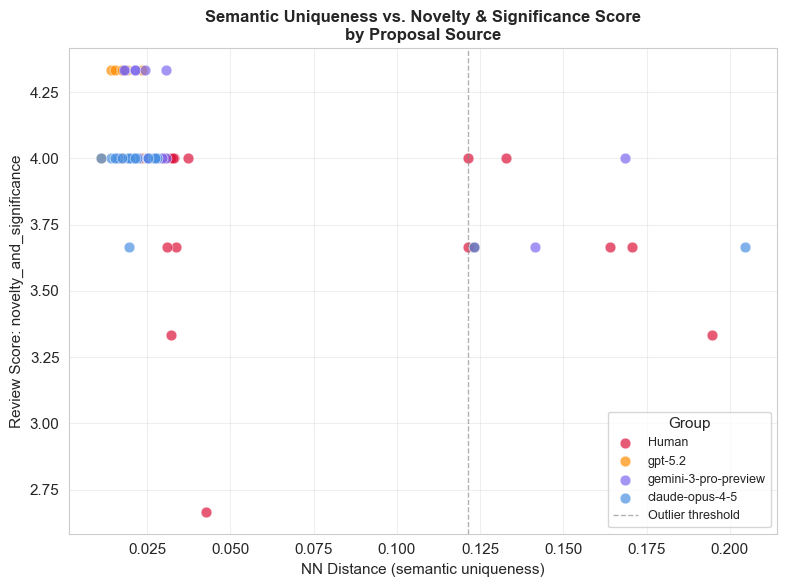

In [158]:
from scipy.stats import mannwhitneyu
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

if 'merged' not in globals():
    raise RuntimeError("Run cell 3.1 first to build 'merged'.")
if 'cliffs_delta_simple' not in globals():
    def cliffs_delta_simple(x, y):
        x, y = np.asarray(x), np.asarray(y)
        dom = sum(1 if xi > yi else (-1 if xi < yi else 0) for xi in x for yi in y)
        return dom / (len(x) * len(y))

tables = TABLES_DIR
novelty_col = next((c for c in score_cols if 'novelty' in c.lower()), None)
if not novelty_col:
    print("Could not find 'Novelty' column. Available:", score_cols)
else:
    print(f"Using criterion: {novelty_col}\n")
    outliers_only = merged[merged['is_outlier']].copy()
    outliers_only['is_human'] = outliers_only['group'].str.lower().str.startswith('human')
    h_scores = outliers_only.loc[outliers_only['is_human'],  novelty_col].dropna()
    a_scores = outliers_only.loc[~outliers_only['is_human'], novelty_col].dropna()

    print("=== Among outlier proposals: Human vs AI Novelty & Significance ===")
    print(f"  Human outliers  n={len(h_scores)}  mean={h_scores.mean():.2f}" if len(h_scores) else "  No human outliers.")
    print(f"  AI outliers     n={len(a_scores)}  mean={a_scores.mean():.2f}" if len(a_scores) else "  No AI outliers.")
    if len(h_scores) >= 2 and len(a_scores) >= 2:
        u, p = mannwhitneyu(h_scores, a_scores, alternative='two-sided')
        delta = cliffs_delta_simple(h_scores, a_scores)
        print(f"  Mann-Whitney U={u:.0f}  p={p:.4f}  Cliff's \u03b4={delta:+.3f}")

    print("\n=== Spearman: NN distance ~ Novelty score by group ===")
    group_corr_rows = []
    for grp in merged['group'].unique():
        sub = merged[merged['group'] == grp][[novelty_col,'nn_dist']].dropna()
        if len(sub) < 4: continue
        r, p = stats.spearmanr(sub['nn_dist'], sub[novelty_col])
        group_corr_rows.append({'group': grp, 'n': len(sub), 'r': r, 'p': p})
        print(f"  {grp:<25} n={len(sub):2d}  r={r:+.3f}  p={p:.4f}")
    pd.DataFrame(group_corr_rows).to_csv(tables/'nn_novelty_correlation_by_group.csv', index=False)
    print("\nSaved nn_novelty_correlation_by_group.csv")

    group_colors = {'Human':'#DC143C','human-y1':'#DC143C','human-y2':'#DC143C',
                    'claude-opus-4-5':'#4A90E2','gemini-3-pro-preview':'#7B68EE','gpt-5.2':'#FF8C00'}
    fig, ax = plt.subplots(figsize=(8, 6))
    for grp in merged['group'].unique():
        sub = merged[merged['group'] == grp]
        ax.scatter(sub['nn_dist'], sub[novelty_col],
                   color=group_colors.get(grp,'gray'),
                   label='Human' if 'human' in grp.lower() else grp,
                   alpha=0.7, edgecolors='white', linewidth=0.5, s=60)
    ax.axvline(merged['threshold'].iloc[0], color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Outlier threshold')
    ax.set_xlabel('NN Distance (semantic uniqueness)', fontsize=11)
    ax.set_ylabel(f'Review Score: {novelty_col}', fontsize=11)
    ax.set_title('Semantic Uniqueness vs. Novelty & Significance Score\nby Proposal Source',
                 fontsize=12, fontweight='bold')
    ax.legend(title='Group', fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'nn_dist_vs_novelty_score.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Analysis 3.5: NN Outliers vs. Literature-Novel Proposals

**Two questions:**
1. Are the proposals flagged as NN outliers (top-10% nearest-neighbor distance *among the 92 proposals*, the magenta rings in the UMAP) the *same* proposals as those with the highest novelty scores vs. the literature corpus (computed in cells 47–49, examined in cell 60)?
2. Does the outlier→review-score pattern from Analysis 3.3 hold when we use literature-based novelty to define "most novel" instead of within-corpus isolation?

  nn_df  : 'a cross-cell-type atlas of biomolecular condensate material states and their emergent regulation of gene expression noise'
  closest: 'a unified analytical framework for the dynamics of proteome turnover'
  nn_df  : 'data-driven modeling of emergent molecular selectivity within the nuclear pore complex'
  closest: 'the role of transposable elements in the emergence of genomic innovation'
  nn_df  : 'decoding signaling fidelity through integrated phosphoproteomics and structural analysis of kinase-substrate networks'
  closest: 'mechanisms of emergent assembly in bacterial microcompartment synthesis'
  nn_df  : 'design rules for bacterial microcompartments: integrating genomes, structures, and metabolic flux to predict organelle function'
  closest: 'a unified analytical framework for the dynamics of proteome turnover'
  nn_df  : 'discovery of long-range communication networks in protein complexes via structural database mining'
  closest: 'energetic origins of connectivity 

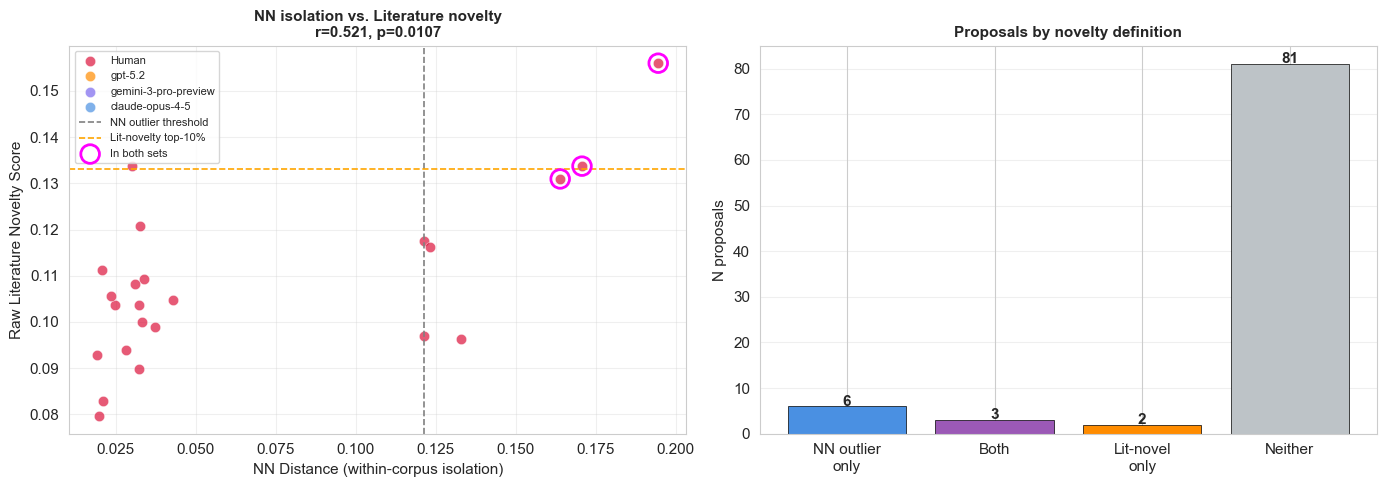

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

tables = TABLES_DIR

# ── Load saved tables (no kernel dependencies) ───────────────────────────────
nn_df     = pd.read_csv(tables / 'nn_distances.csv')
nov_df    = pd.read_csv(tables / 'novelty_scores_from_literature.csv')
scores_df = pd.read_csv(tables / 'review_scores_wide.csv')

def norm(s): return str(s).strip().lower()
for df in [nn_df, nov_df, scores_df]:
    df['title_norm'] = df['title'].map(norm)

score_cols = [c for c in scores_df.columns if c not in {'title', 'title_norm', 'author'}]

# ── Title-match diagnostic (runs every time; zero-cost if everything is fine) ─
nn_titles  = set(nn_df['title_norm'])
nov_titles = set(nov_df['title_norm'])
unmatched_in_nn  = nn_titles  - nov_titles   # in nn_df but missing from nov_df → will get NaN
unmatched_in_nov = nov_titles - nn_titles    # in nov_df but not in nn_df → will be dropped
if unmatched_in_nn:
    print(f"WARNING: {len(unmatched_in_nn)} titles in nn_df have NO match in nov_df (will get NaN novelty):")
    for t in sorted(unmatched_in_nn):
        print(f"  nn_df  : {repr(t)}")
        # Show closest nov_df title for comparison
        closest = min(nov_titles, key=lambda x: sum(a!=b for a,b in zip(x,t)))
        print(f"  closest: {repr(closest)}")
else:
    print(f"✓ All {len(nn_titles)} nn_df titles matched in nov_df")
if unmatched_in_nov:
    print(f"NOTE: {len(unmatched_in_nov)} nov_df titles not in nn_df (will be silently dropped by inner/left join)")

merged = (nn_df[['title_norm', 'group', 'nn_dist', 'is_outlier', 'threshold']]
          .merge(nov_df[['title_norm', 'raw_novelty', 'novelty_z', 'novelty_ratio',
                         'is_most_novel_raw', 'is_most_novel_z']], on='title_norm', how='left')
          .merge(scores_df[['title_norm'] + score_cols], on='title_norm', how='inner'))

# Proposals without literature novelty scores (e.g. AI proposals not run through
# the lit-novelty pipeline) come back with NaN from the left join.
# Fill boolean flags with False so ~mask and set operations don't raise TypeError.
merged['is_most_novel_raw'] = merged['is_most_novel_raw'].fillna(False).astype(bool)
merged['is_most_novel_z']   = merged['is_most_novel_z'].fillna(False).astype(bool)
merged['is_outlier']        = merged['is_outlier'].fillna(False).astype(bool)

n_missing_novelty = merged['raw_novelty'].isna().sum()
print(f"Merged rows: {len(merged)}  (of which {n_missing_novelty} have no literature novelty score)")

# ── (1) Overlap ──────────────────────────────────────────────────────────────
nn_set  = set(merged.loc[merged['is_outlier'],          'title_norm'])
lit_set = set(merged.loc[merged['is_most_novel_raw'],   'title_norm'])
overlap = nn_set & lit_set
jaccard = len(overlap) / len(nn_set | lit_set) if (nn_set | lit_set) else 0

print("="*70)
print("OVERLAP: NN OUTLIERS (within-corpus) vs MOST NOVEL (vs literature)")
print("="*70)
print(f"  NN outliers (magenta rings in UMAP):  {len(nn_set):3d} proposals")
print(f"  Most novel vs literature (top-10%):   {len(lit_set):3d} proposals")
print(f"  Shared:                               {len(overlap):3d} proposals")
print(f"  Jaccard similarity:                   {jaccard:.3f}")
print()

if overlap:
    print("Proposals in BOTH sets (isolated among proposals AND novel vs literature):")
    both = merged[merged['title_norm'].isin(overlap)][
        ['title_norm','group','nn_dist','raw_novelty','novelty_z']].sort_values('raw_novelty', ascending=False)
    print(both.to_string(index=False))
else:
    print("No overlap — the two definitions identify different proposals.")
print()

print("NN outliers NOT in top-10% lit-novelty (isolated among proposals, but NOT novel vs literature):")
only_nn = merged[merged['is_outlier'] & ~merged['is_most_novel_raw']][
    ['title_norm','group','nn_dist','raw_novelty','novelty_z']].sort_values('nn_dist', ascending=False)
print(only_nn.to_string(index=False))
print()

print("Top-10% lit-novelty NOT in NN outliers (novel vs literature, but NOT isolated among proposals):")
only_lit = merged[~merged['is_outlier'] & merged['is_most_novel_raw']][
    ['title_norm','group','nn_dist','raw_novelty','novelty_z']].sort_values('raw_novelty', ascending=False)
print(only_lit.to_string(index=False))

# ── Spearman: are the two metrics correlated at all? ────────────────────────
# Drop rows where either metric is NaN before computing correlation
valid_both = merged[['nn_dist', 'raw_novelty']].dropna()
if len(valid_both) >= 5:
    r, p = spearmanr(valid_both['nn_dist'], valid_both['raw_novelty'])
    print(f"\nSpearman(nn_dist, raw_novelty): r={r:.3f}, p={p:.4f}  (n={len(valid_both)})")
else:
    r, p = np.nan, np.nan
    print(f"\nSpearman(nn_dist, raw_novelty): insufficient data (n={len(valid_both)})")
print("  → If low/non-significant: the two novelty metrics are measuring different things.")

# ── Scatter ──────────────────────────────────────────────────────────────────
group_colors = {'Human':'#DC143C','human-y1':'#DC143C','human-y2':'#DC143C',
                'claude-opus-4-5':'#4A90E2','gemini-3-pro-preview':'#7B68EE','gpt-5.2':'#FF8C00'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for grp in merged['group'].unique():
    sub = merged[merged['group'] == grp]
    axes[0].scatter(sub['nn_dist'], sub['raw_novelty'],
                    color=group_colors.get(grp, 'gray'),
                    label='Human' if 'human' in grp.lower() else grp,
                    alpha=0.7, s=55, edgecolors='white', linewidth=0.4)

threshold_val = merged['threshold'].iloc[0]
lit_thresh    = np.nanpercentile(merged['raw_novelty'], 90)
axes[0].axvline(threshold_val, color='gray',   linestyle='--', lw=1.2, label='NN outlier threshold')
axes[0].axhline(lit_thresh,    color='orange', linestyle='--', lw=1.2, label='Lit-novelty top-10%')
# Mark overlap in magenta
if overlap:
    ov_pts = merged[merged['title_norm'].isin(overlap)]
    axes[0].scatter(ov_pts['nn_dist'], ov_pts['raw_novelty'],
                    s=180, facecolors='none', edgecolors='magenta', linewidth=2, zorder=10, label='In both sets')
axes[0].set_xlabel('NN Distance (within-corpus isolation)', fontsize=11)
axes[0].set_ylabel('Raw Literature Novelty Score', fontsize=11)
axes[0].set_title(f'NN isolation vs. Literature novelty\nr={r:.3f}, p={p:.4f}', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Bar: proposal counts per category
cats   = ['NN outlier\nonly', 'Both', 'Lit-novel\nonly', 'Neither']
counts = [len(only_nn), len(overlap), len(only_lit),
          len(merged) - len(nn_set | lit_set)]
bars = axes[1].bar(cats, counts,
                   color=['#4A90E2','#9B59B6','#FF8C00','#BDC3C7'],
                   edgecolor='black', linewidth=0.5)
axes[1].set_title('Proposals by novelty definition', fontsize=11, fontweight='bold')
axes[1].set_ylabel('N proposals'); axes[1].grid(alpha=0.3, axis='y')
for bar, v in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.15, str(v),
                 ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nn_vs_lit_novelty_overlap.png', dpi=150, bbox_inches='tight')
plt.show()


In [160]:
from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
from pathlib import Path

tables = TABLES_DIR

if 'merged' not in globals():
    raise RuntimeError("Run cell 3.5 above first to build 'merged'.")

def cliffs_delta_simple(x, y):
    x, y = np.asarray(x), np.asarray(y)
    dom = sum(1 if xi > yi else (-1 if xi < yi else 0) for xi in x for yi in y)
    return dom / (len(x) * len(y))

print("="*70)
print("(2a) REVIEW SCORES: LIT-MOST-NOVEL vs REST")
print("(same test as 3.3 but using literature-based novelty top-10%)")
print("="*70)
lit_results = []
for criterion in score_cols:
    out_s    = merged.loc[merged['is_most_novel_raw'],  criterion].dropna()
    nonout_s = merged.loc[~merged['is_most_novel_raw'], criterion].dropna()
    if len(out_s) < 2 or len(nonout_s) < 2: continue
    u, p  = mannwhitneyu(out_s, nonout_s, alternative='greater')
    delta = cliffs_delta_simple(out_s, nonout_s)
    lit_results.append({'criterion': criterion,
                        'novel_mean': out_s.mean(), 'rest_mean': nonout_s.mean(),
                        'delta': delta, 'p_value': p,
                        'n_novel': len(out_s), 'n_rest': len(nonout_s)})

lit_df = pd.DataFrame(lit_results)
if not lit_df.empty:
    _, lit_df['p_holm'], _, _ = multipletests(lit_df['p_value'], method='holm')
    print(lit_df[['criterion','novel_mean','rest_mean','delta','p_value','p_holm']].to_string(index=False))
    lit_df.to_csv(tables / 'lit_novel_score_comparison.csv', index=False)
    print("\nSaved lit_novel_score_comparison.csv")

print("\n" + "="*70)
print("(2b) SPEARMAN: RAW LIT-NOVELTY SCORE vs EACH REVIEW CRITERION")
print("="*70)
corr_rows = []
for criterion in score_cols:
    valid = merged[['raw_novelty', criterion]].dropna()
    if len(valid) < 5: continue
    r, p = spearmanr(valid['raw_novelty'], valid[criterion])
    corr_rows.append({'criterion': criterion, 'r': r, 'p': p})
    print(f"  {criterion:<42} r={r:+.3f}  p={p:.4f}")
corr_df = pd.DataFrame(corr_rows)
if not corr_df.empty:
    _, corr_df['p_holm'], _, _ = multipletests(corr_df['p'], method='holm')
    corr_df.to_csv(tables / 'lit_novelty_score_correlations.csv', index=False)
    print("\nSaved lit_novelty_score_correlations.csv")


(2a) REVIEW SCORES: LIT-MOST-NOVEL vs REST
(same test as 3.3 but using literature-based novelty top-10%)
                      criterion  novel_mean  rest_mean     delta  p_value  p_holm
            data_identification    3.400000   3.693487 -0.317241 0.892549     1.0
       novelty_and_significance    3.733333   3.992337 -0.547126 0.995787     1.0
        open_science_commitment    3.333333   3.973180 -0.577011 0.990895     1.0
relevance_to_emergent_phenomena    2.733333   4.559387 -0.880460 0.999895     1.0
              rigor_of_approach    3.333333   3.429119 -0.186207 0.788439     1.0
             scope_and_timeline    3.200000   3.203065 -0.057471 0.624453     1.0
                synthesis_focus    4.466667   4.812261 -0.360920 0.953242     1.0

Saved lit_novel_score_comparison.csv

(2b) SPEARMAN: RAW LIT-NOVELTY SCORE vs EACH REVIEW CRITERION
  data_identification                        r=+0.456  p=0.0289
  novelty_and_significance                   r=-0.418  p=0.0473
  open_sci

---
## Analysis 3.6: Export — Full Proposals for NN Outliers and Literature-Most-Novel Proposals

In [165]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

tables = TABLES_DIR
out_dir = tables

# ── Load saved tables ─────────────────────────────────────────────────────────
nov_df     = pd.read_csv(tables / 'novelty_scores_from_literature.csv')
nn_df      = pd.read_csv(tables / 'nn_distances.csv')
scores_wide = pd.read_csv(tables / 'review_scores_wide.csv')

def norm(s): return str(s).strip().lower()
for df in [nov_df, nn_df, scores_wide]:
    df['title_norm'] = df['title'].map(norm)

score_cols_local = [c for c in scores_wide.columns if c not in {'title','title_norm','author'}]

combined = (nn_df[['title_norm','group','nn_dist','is_outlier','threshold']]
            .merge(nov_df[['title_norm','raw_novelty','novelty_z','novelty_ratio',
                           'is_most_novel_raw','is_most_novel_z']], on='title_norm', how='left'))

# bool columns from CSV can come back as pd.NA (not np.nan) when values are missing;
# bool(pd.NA) raises TypeError — fill before any boolean operations or bool() calls.
for col in ('is_outlier', 'is_most_novel_raw', 'is_most_novel_z'):
    combined[col] = combined[col].fillna(False).astype(bool)

# Target = NN outlier OR lit-most-novel (top-10%)
target_norms = set(combined.loc[combined['is_outlier'] | combined['is_most_novel_raw'], 'title_norm'])
print(f"Target proposals (NN outlier OR lit-most-novel): {len(target_norms)}")

# ── Load AI reviews ───────────────────────────────────────────────────────────
review_dir   = Path('../data/reviews/ai_reviews')
review_files = sorted(review_dir.glob('ai_reviews_rephrased_*.json'))
if not review_files: raise FileNotFoundError("No rephrased review files found.")
reviews_raw = json.load(open(review_files[-1]))['reviews']

review_lookup = {}
for entry in reviews_raw:
    tn = norm(entry.get('title',''))
    evaluator = entry.get('evaluator','')
    ev = entry.get('evaluations',{}).get('evaluation',{})
    criteria = [{'category': cat['category'], 'criterion': sub['criterion'],
                 'score': sub['score'], 'justification': sub.get('justification','')}
                for cat in ev.get('criteria_scores',[])
                for sub in cat.get('subcriteria',[])]
    review_lookup.setdefault(tn, []).append({'evaluator': evaluator, 'criteria': criteria})

# ── Load rephrased proposals ──────────────────────────────────────────────────
ai_reph_dir = Path('../data/ai-proposals/rephrased/v3-minimal')
ai_files = sorted(ai_reph_dir.glob('ai_proposals_rephrased_*.csv'))
if not ai_files: raise FileNotFoundError("No rephrased AI CSVs found.")
ai_df_reph = pd.read_csv(ai_files[-1])
ai_df_reph['title_norm'] = ai_df_reph['title'].map(norm)

human_reph_dir = Path('../data/human-proposals/rephrased')
human_reph = {}
for cohort in ['y1','y2']:
    files = sorted(human_reph_dir.glob(f'*{cohort}*.json'))
    if files:
        for p in json.load(open(files[-1])).get('proposals',[]):
            human_reph[norm(p.get('proposal_title',''))] = {'cohort': cohort, **p}

human_orig = {}
for cohort, fname in [('y1','human-proposals-y1.json'),('y2','human-proposals-y2.json')]:
    fpath = Path('../data/human-proposals') / fname
    if fpath.exists():
        for p in json.load(open(fpath)).get('proposals',[]):
            human_orig[norm(p.get('proposal_title',''))] = {'cohort': cohort, **p}

# ── Build records ─────────────────────────────────────────────────────────────
output_records = []
for _, row in combined.iterrows():
    tn = row['title_norm']
    if tn not in target_norms: continue

    grp = row['group']
    rec = {
        'title_norm':        tn,
        'group':             grp,
        'is_nn_outlier':     bool(row['is_outlier']),
        'is_lit_most_novel': bool(row['is_most_novel_raw']),
        'nn_dist':           float(row['nn_dist']) if pd.notna(row['nn_dist']) else None,
        'raw_novelty':       float(row['raw_novelty']) if pd.notna(row['raw_novelty']) else None,
        'novelty_z':         float(row['novelty_z'])   if pd.notna(row['novelty_z'])   else None,
        'novelty_ratio':     float(row['novelty_ratio']) if pd.notna(row['novelty_ratio']) else None,
    }

    if 'human' in grp.lower():
        orig = human_orig.get(tn, {})
        reph = human_reph.get(tn, {})
        rec.update({
            'title':               orig.get('proposal_title', tn),
            'author':              grp,
            'authors':             orig.get('authors', []),
            'authors_departments': orig.get('authors_departments', ''),
            'proposal_status':     orig.get('proposal_status', ''),
            'ranking':             orig.get('ranking', None),
            'abstract_original':   orig.get('abstract', ''),
            'full_draft_original': orig.get('full_draft', ''),
            'standardized_text':   reph.get('standardized_text', ''),
        })
    else:
        ai_row = ai_df_reph[ai_df_reph['title_norm'] == tn]
        if not ai_row.empty:
            r = ai_row.iloc[0]
            rec.update({
                'title':               r.get('title', tn),
                'author':              r.get('model', grp),
                'authors':             [r.get('model', grp)],
                'abstract_original':   str(r.get('abstract', '')),
                'full_draft_original': str(r.get('background_and_significance', '')),
                'standardized_text':   str(r.get('standardized_text', '')),
            })
        else:
            rec.update({'title': tn, 'author': grp, 'authors': [grp]})

    rec['ai_reviews'] = review_lookup.get(tn, [])
    scores_row = scores_wide[scores_wide['title_norm'] == tn]
    rec['avg_review_scores'] = (
        {c: (float(scores_row.iloc[0][c]) if pd.notna(scores_row.iloc[0][c]) else None)
         for c in score_cols_local}
        if not scores_row.empty else {}
    )
    output_records.append(rec)

output_records.sort(key=lambda x: -(x['raw_novelty'] or 0))

out_path = out_dir / 'outlier_and_novel_proposals.json'
with open(out_path, 'w') as f:
    json.dump(output_records, f, indent=2, ensure_ascii=False)

print(f"Saved {len(output_records)} proposals → {out_path.name}")
print()
for r in output_records:
    tag = ('NN+LIT' if r['is_nn_outlier'] and r['is_lit_most_novel']
           else 'NN only' if r['is_nn_outlier'] else 'LIT only')
    z_str  = f"{r['novelty_z']:+.2f}"  if r['novelty_z']  is not None else '   N/A'
    nn_str = f"{r['nn_dist']:.4f}"     if r['nn_dist']    is not None else '  N/A'
    print(f"  {tag:<8}  {r['group']:<25}  z={z_str}  nn={nn_str}  {r.get('title','')[:55]}")


Target proposals (NN outlier OR lit-most-novel): 11
Saved 11 proposals → outlier_and_novel_proposals.json

  NN+LIT    Human                      z=+0.72  nn=0.1946  impact of heat wave stress on cytokinetic bottlenecks i
  NN+LIT    Human                      z=+0.37  nn=0.1707  integrative multi-omics synthesis for the identificatio
  LIT only  Human                      z=+0.37  nn=0.0301  evolutionary origins of complex protein topologies from
  NN+LIT    Human                      z=+0.32  nn=0.1639  intelligent metadata compilation for enhanced reusabili
  LIT only  Human                      z=+0.16  nn=0.0327  the role of transposable elements in the emergence of g
  NN only   Human                      z=+0.09  nn=0.1233  discovery and functional characterization of bacterial 
  NN only   Human                      z=-0.23  nn=0.1328  synthesis of gene expression data for the construction 
  NN only   gemini-3-pro-preview       z=   N/A  nn=0.1415  mapping transient metabolons